**RLMC** : Régression linéaire aux moindres carrés

On effectue cette méthode sur la _matrice de comparaisons_
des protéines du jeu de données où figurent les valeurs
des distances de Wasserstein 2 entre les barcodes.

La RLMC permettra d'effectuer des *Clusterisations* au sein de la matrice,
nous permettant ensuite d'organiser les protéines 

L'objectif est d'identifier et de quantifier le lien
entre la RLMC issue de la comparaison des barcodes
avec l'**arbre phylogénique** ci-contre.


In [1]:
import numpy as np
from scipy import stats
import pandas as pd

from anytree import Node, RenderTree

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch


### Importations, définitions

faites défiler jusqu'à la fin des définitions et importations

In [68]:


def texte_vers_anytree(texte_arbre):
   
    lignes = texte_arbre.strip().split('\n')
    
    lignes = [l.rstrip(')').strip() for l in lignes if l.strip()]
    
    racine = None
    pile = []  # (node, niveau)
    
    for ligne in lignes:
        
        prefix = ligne[:ligne.find('├')] if '├' in ligne else \
                 ligne[:ligne.find('└')] if '└' in ligne else \
                 ligne[:ligne.find('│')] if '│' in ligne else ''
        
    
        niveau = prefix.count('│') + (prefix.count(' ') // 3)
        
        
        nom = ligne
        for sep in ['├── ', '└── ', '│   ']:
            if sep in ligne:
                nom = ligne.split(sep)[-1]
                break
        
        nom = nom.strip()
        
        # Créer le nœud
        node = Node(nom)
        
        if racine is None:
            racine = node
            pile = [(node, niveau)]
        else:
            # Remonter dans la pile jusqu'au parent
            while pile and pile[-1][1] >= niveau:
                pile.pop()
            
            if pile:
                parent = pile[-1][0]
                node.parent = parent
            else:
                node.parent = racine
            
            pile.append((node, niveau))
    
    return racine

#  texte 
texte_arbre = """
Metazoaire
├── Deuterostomiens
│   └── Chordés
│       ├── Céphalochordés
│       │   └── Amphioxus
│       │       ├── AF-Q17134-F1-model_v6.pdb 
│       │       ├── AF-O47431-F1-model_v6.pdb 
│       │       ├── AF-F2Q9Y0-F1-model_v6.pdb 
│       │       ├── AF-F2Q9X8-F1-model_v6.pdb 
│       │       ├── AF-F2Q9X7-F1-model_v6.pdb 
│       │       ├── AF-F2Q9X6-F1-model_v6.pdb 
│       │       ├── AF-F2Q9X5-F1-model_v6.pdb 
│       │       ├── AF-F2Q9X4-F1-model_v6.pdb 
│       │       ├── AF-F2Q9X3-F1-model_v6.pdb 
│       │       ├── AF-F2Q9X2-F1-model_v6.pdb 
│       │       ├── AF-F2Q9X1-F1-model_v6.pdb 
│       │       ├── AF-F2Q9X0-F1-model_v6.pdb 
│       │       ├── AF-F2Q9W9-F1-model_v6.pdb 
│       │       ├── AF-F2Q9W8-F1-model_v6.pdb 
│       │       ├── AF-F2Q9W7-F1-model_v6.pdb 
│       │       ├── AF-F2Q9W6-F1-model_v6.pdb 
│       │       ├── AF-C3YWU0-F1-model_v6.pdb 
│       │       └── AF-C3Y097-F1-model_v6.pdb 
│       ├── Urochordés
│       │   └── Cione_jaune
│       │       ├── AF-Q70T64-F1-model_v6.pdb 
│       │       ├── AF-Q70T63-F1-model_v6.pdb 
│       │       ├── AF-Q70T62-F1-model_v6.pdb 
│       │       ├── AF-Q70PH6-F1-model_v6.pdb 
│       │       ├── AF-Q9NL48-F1-model_v6.pdb 
│       │       ├── AF-Q4H3K6-F1-model_v6.pdb 
│       │       ├── AF-P61802-F1-model_v6.pdb 
│       │       └── AF-F6U472-F1-model_v6.pdb 
│       └── Vertébrés
│           ├── Agnathes (Petromyozontidae)
│           │   ├── Lamproie_marine
│           │   │   ├── AF-Q98980-F1-model_v6.pdb 
│           │   │   ├── AF-Q9PVD5-F1-model_v6.pdb 
│           │   │   ├── AF-Q9I9I3-F1-model_v6.pdb 
│           │   │   ├── AF-P09968-F1-model_v6.pdb 
│           │   │   ├── AF-P09967-F1-model_v6.pdb 
│           │   │   ├── AF-P02208-F1-model_v6.pdb 
│           │   │   ├── AF-A0AAJ7U215-F1-model_v6.pdb 
│           │   │   ├── AF-A0AAJ7TMY1-F1-model_v6.pdb 
│           │   │   ├── AF-A0AAJ7T5N9-F1-model_v6.pdb 
│           │   │   └── AF-A0AAJ7SV95-F1-model_v6.pdb 
│           │   └── Lamproie_de_planer
│           │       └── AF-A0A0A8WJC6-F1-model_v6.pdb 
│           └── Gnathostomes
│               ├── Chondrichtyens
│               │   ├── Squaliformes
│               │   │   └── Requin_du_groenland
│               │   │       ├── AF-Q8AXK2-F1-model_v6.pdb 
│               │   │       ├── AF-C0HJZ4-F1-model_v6.pdb 
│               │   │       ├── AF-C0HJZ3-F1-model_v6.pdb 
│               │   │       ├── AF-A0A2H4ZEZ2-F1-model_v6.pdb 
│               │   │       ├── AF-Q9NPG2-F1-model_v6.pdb 
│               │   │       ├── AF-Q8WY91-F1-model_v6.pdb 
│               │   │       ├── AF-Q8WWM9-F1-model_v6.pdb 
│               │   │       ├── AF-Q8N7X0-F1-model_v6.pdb 
│               │   │       ├── AF-Q6B0K9-F1-model_v6.pdb 
│               │   │       ├── AF-P69905-F1-model_v6.pdb 
│               │   │       ├── AF-P69892-F1-model_v6.pdb 
│               │   │       ├── AF-P69891-F1-model_v6.pdb 
│               │   │       ├── AF-P68871-F1-model_v6.pdb 
│               │   │       ├── AF-P09105-F1-model_v6.pdb 
│               │   │       ├── AF-P02144-F1-model_v6.pdb 
│               │   │       ├── AF-P02100-F1-model_v6.pdb 
│               │   │       ├── AF-P02042-F1-model_v6.pdb 
│               │   │       ├── AF-P02008-F1-model_v6.pdb 
│               │   │       ├── AF-A8MTQ0-F1-model_v6.pdb 
│               │   │       └── AF-A0AVK6-F1-model_v6.pdb 
│               │   └── Batoïdes
│               │       └── Torpille_marbrée
│               │           ├── AF-P20245-F1-model_v6.pdb 
│               │           └── AF-P20244-F1-model_v6.pdb 
│               └── Ostéichtyens
│                   ├── Actinoptérygiens
│                   │   └── Poisson_zèbre
│                   │       ├── AF-Q90487-F1-model_v6.pdb 
│                   │       ├── AF-Q90486-F1-model_v6.pdb 
│                   │       ├── AF-Q90485-F1-model_v6.pdb 
│                   │       ├── AF-Q90259-F1-model_v6.pdb 
│                   │       ├── AF-Q575S8-F1-model_v6.pdb 
│                   │       ├── AF-Q90YJ2-F1-model_v6.pdb 
│                   │       ├── AF-Q9DDJ0-F1-model_v6.pdb 
│                   │       ├── AF-Q8UUR3-F1-model_v6.pdb 
│                   │       ├── AF-Q7ZT21-F1-model_v6.pdb 
│                   │       ├── AF-Q6VN46-F1-model_v6.pdb 
│                   │       ├── AF-Q2XNF5-F1-model_v6.pdb 
│                   │       ├── AF-Q2WG80-F1-model_v6.pdb 
│                   │       ├── AF-P0DM64-F1-model_v6.pdb 
│                   │       ├── AF-O93548-F1-model_v6.pdb 
│                   │       ├── AF-O42145-F1-model_v6.pdb 
│                   │       └── AF-A3KNI8-F1-model_v6.pdb 
│                   └── Sarcoptérygiens
│                       └── Tétrapodes
│                           ├── Mammifères
│                           │   ├── Euthériens (placentaires)
│                           │   │   ├── Homo_sapiens
│                           │   │   └── Mus_musculus
│                           │   │       ├── AF-Q9ER97-F1-model_v6.pdb 
│                           │   │       ├── AF-Q9CX80-F1-model_v6.pdb 
│                           │   │       ├── AF-Q9CQE0-F1-model_v6.pdb 
│                           │   │       ├── AF-Q7TPG1-F1-model_v6.pdb 
│                           │   │       ├── AF-P06467-F1-model_v6.pdb 
│                           │   │       ├── AF-P04444-F1-model_v6.pdb 
│                           │   │       ├── AF-P04443-F1-model_v6.pdb 
│                           │   │       ├── AF-P04247-F1-model_v6.pdb 
│                           │   │       ├── AF-P02762-F1-model_v6.pdb 
│                           │   │       ├── AF-P02104-F1-model_v6.pdb 
│                           │   │       ├── AF-P02089-F1-model_v6.pdb 
│                           │   │       ├── AF-P02088-F1-model_v6.pdb 
│                           │   │       ├── AF-P01942-F1-model_v6.pdb 
│                           │   │       └── AF-G3UZ78-F1-model_v6.pdb 
│                           │   └── Métathériens (marsupiaux)
│                           │       └── Oppossum_gris
│                           │           ├── AF-Q95J88-F1-model_v6.pdb 
│                           │           ├── AF-Q9GL60-F1-model_v6.pdb 
│                           │           ├── AF-Q8HY34-F1-model_v6.pdb 
│                           │           ├── AF-Q3KN63-F1-model_v6.pdb 
│                           │           ├── AF-P49141-F1-model_v6.pdb 
│                           │           ├── AF-P48798-F1-model_v6.pdb 
│                           │           ├── AF-F7GH03-F1-model_v6.pdb 
│                           │           ├── AF-F6YXK6-F1-model_v6.pdb 
│                           │           ├── AF-F6YMJ4-F1-model_v6.pdb 
│                           │           ├── AF-F6WYU4-F1-model_v6.pdb 
│                           │           └── AF-F6WII6-F1-model_v6.pdb 
│                           └── Oiseaux
│                               ├── Gallus_gallus
│                               │   ├── AF-Q90864-F1-model_v6.pdb 
│                               │   ├── AF-Q5QSB1-F1-model_v6.pdb 
│                               │   ├── AF-P02197-F1-model_v6.pdb 
│                               │   ├── AF-P02128-F1-model_v6.pdb 
│                               │   ├── AF-P02127-F1-model_v6.pdb 
│                               │   ├── AF-P02112-F1-model_v6.pdb 
│                               │   ├── AF-P02007-F1-model_v6.pdb 
│                               │   ├── AF-P02001-F1-model_v6.pdb 
│                               │   └── AF-P01994-F1-model_v6.pdb 
│                               └── Aves (autre)
└── Protostomiens
    ├── Arthropodes
    │   ├── D._melanogaster (mouche)
    │   └── D._pseudoobscura
    │       ├── AF-Q3MQ62-F1-model_v6.pdb 
    │       ├── AF-Q24570-F1-model_v6.pdb 
    │       ├── AF-Q9VNE2-F1-model_v6.pdb 
    │       ├── AF-Q9I7P6-F1-model_v6.pdb 
    │       ├── AF-Q7KLI1-F1-model_v6.pdb 
    │       └── AF-Q4V6L1-F1-model_v6.pdb 
    └── Nématodes
        └── C._elegans
            ├── AF-Q23117-F1-model_v6.pdb 
            ├── AF-Q22663-F1-model_v6.pdb 
            ├── AF-Q21978-F1-model_v6.pdb 
            ├── AF-Q21618-F1-model_v6.pdb 
            ├── AF-Q20638-F1-model_v6.pdb 
            ├── AF-Q20623-F1-model_v6.pdb 
            ├── AF-Q20015-F1-model_v6.pdb 
            ├── AF-Q19601-F1-model_v6.pdb 
            ├── AF-Q18311-F1-model_v6.pdb 
            ├── AF-Q18086-F1-model_v6.pdb 
            ├── AF-Q17884-F1-model_v6.pdb 
            ├── AF-Q17727-F1-model_v6.pdb 
            ├── AF-Q09514-F1-model_v6.pdb 
            ├── AF-Q09240-F1-model_v6.pdb 
            ├── AF-Q966A3-F1-model_v6.pdb 
            ├── AF-Q9XXI2-F1-model_v6.pdb 
            ├── AF-Q9U2R5-F1-model_v6.pdb 
            ├── AF-Q9GYP4-F1-model_v6.pdb 
            ├── AF-Q8MPY8-F1-model_v6.pdb 
            ├── AF-Q7YZV1-F1-model_v6.pdb 
            ├── AF-Q7YWV3-F1-model_v6.pdb 
            ├── AF-P30627-F1-model_v6.pdb 
            ├── AF-O76629-F1-model_v6.pdb 
            ├── AF-O62089-F1-model_v6.pdb 
            ├── AF-O17824-F1-model_v6.pdb 
            ├── AF-H9G343-F1-model_v6.pdb 
            ├── AF-G5EGB6-F1-model_v6.pdb 
            ├── AF-G5EF00-F1-model_v6.pdb 
            ├── AF-E1NZ07-F1-model_v6.pdb 
            ├── AF-D0VWM4-F1-model_v6.pdb 
            ├── AF-C1P638-F1-model_v6.pdb 
            ├── AF-B6EU61-F1-model_v6.pdb 
            ├── AF-B3WFV2-F1-model_v6.pdb 
            ├── AF-B3GWE1-F1-model_v6.pdb 
            ├── AF-A8UWQ7-F1-model_v6.pdb 
            ├── AF-A3RMS5-F1-model_v6.pdb 
            └── AF-A0A0K3AT43-F1-model_v6.pdb 
"""

# Convertir
arbre = texte_vers_anytree(texte_arbre)

# Afficher l'arbre converti
print("\n" + "=" * 60)
print("ARBRE CONVERTI AVEC ANYTREE")
print("=" * 60)
for pre, fill, node in RenderTree(arbre):
    print(f"{pre}{node.name}")

# Statistiques
print("\n" + "=" * 60)
print("STATISTIQUES")
print("=" * 60)
print(f"Nombre total de nœuds : {sum(1 for _ in arbre.descendants) + 1}")
print(f"Nombre de feuilles : {sum(1 for _ in arbre.leaves)}")
print(f"Hauteur de l'arbre : {arbre.height}")

# Accès aux nœuds
print("\n" + "=" * 60)
print("ACCÈS AUX NŒUDS")
print("=" * 60)
print(f"Racine : {arbre.name}")
print(f"Enfants de la racine : {[c.name for c in arbre.children]}")


ARBRE CONVERTI AVEC ANYTREE
Metazoaire
├── Deuterostomiens
│   └── Chordés
│       ├── Céphalochordés
│       │   └── Amphioxus
│       │       ├── AF-Q17134-F1-model_v6.pdb
│       │       ├── AF-O47431-F1-model_v6.pdb
│       │       ├── AF-F2Q9Y0-F1-model_v6.pdb
│       │       ├── AF-F2Q9X8-F1-model_v6.pdb
│       │       ├── AF-F2Q9X7-F1-model_v6.pdb
│       │       ├── AF-F2Q9X6-F1-model_v6.pdb
│       │       ├── AF-F2Q9X5-F1-model_v6.pdb
│       │       ├── AF-F2Q9X4-F1-model_v6.pdb
│       │       ├── AF-F2Q9X3-F1-model_v6.pdb
│       │       ├── AF-F2Q9X2-F1-model_v6.pdb
│       │       ├── AF-F2Q9X1-F1-model_v6.pdb
│       │       ├── AF-F2Q9X0-F1-model_v6.pdb
│       │       ├── AF-F2Q9W9-F1-model_v6.pdb
│       │       ├── AF-F2Q9W8-F1-model_v6.pdb
│       │       ├── AF-F2Q9W7-F1-model_v6.pdb
│       │       ├── AF-F2Q9W6-F1-model_v6.pdb
│       │       ├── AF-C3YWU0-F1-model_v6.pdb
│       │       └── AF-C3Y097-F1-model_v6.pdb
│       ├── Urochordés
│       │   └── Cion

In [3]:
# Parcourir l'arbre pour trouver un fichier spécifique
def trouver_fichier(arbre, nom_fichier):
    for node in arbre.descendants:
        if node.name == nom_fichier:
            # Remonter la chaîne parentale
            chemin = []
            n = node
            while n:
                chemin.append(n.name)
                n = n.parent
            return " → ".join(reversed(chemin))
    return None

# Exemple
chemin = trouver_fichier(arbre, "AF-P02001-F1-model_v6.pdb")
print(chemin)

Metazoaire → Deuterostomiens → Chordés → Vertébrés → Gnathostomes → Ostéichtyens → Sarcoptérygiens → Tétrapodes → Oiseaux → Gallus_gallus → AF-P02001-F1-model_v6.pdb


**Matrice des distances de wasserstein**

In [4]:
matrice_liste = [[0.0, np.float64(48.471798), np.float64(38.417022), np.float64(496.734513), np.float64(190.111737), np.float64(132.524522), np.float64(7.829175), np.float64(430.813553), np.float64(9.745056), np.float64(34.179894), np.float64(171.006954), np.float64(15.13407), np.float64(12.10144), np.float64(206.678928), np.float64(11.057141), np.float64(9.57806), np.float64(9.607801), np.float64(49.14206), np.float64(12.116533), np.float64(35.117279), np.float64(80.061926), np.float64(324.070449), np.float64(10.193652), np.float64(10.983156), np.float64(24.402928), np.float64(10.796801), np.float64(10.467522), np.float64(21.951507), np.float64(9.306679), np.float64(10.836631), np.float64(11.202236), np.float64(8.698351), np.float64(8.83559), np.float64(80.477806), np.float64(12.853074), np.float64(8.630009), np.float64(20.649827), np.float64(10.775317), np.float64(11.238903), np.float64(9.874641), np.float64(209.308756), np.float64(11.00802), np.float64(571.716797), np.float64(107.753759), np.float64(12.322274), np.float64(411.534801), np.float64(196.256467), np.float64(108.946325), np.float64(27.618073), np.float64(93.2033), np.float64(8.217782), np.float64(9.34979), np.float64(9.438192), np.float64(10.174158), np.float64(10.703596), np.float64(10.162439), np.float64(9.877475), np.float64(11.559198), np.float64(12.03378), np.float64(11.548504), np.float64(10.88731), np.float64(11.279649), np.float64(10.666898), np.float64(11.481904), np.float64(10.908535), np.float64(10.482686), np.float64(10.983324), np.float64(10.406022), np.float64(13.282793), np.float64(10.507645), np.float64(11.521691), np.float64(10.82363), np.float64(9.659164), np.float64(8.54971), np.float64(10.209729), np.float64(10.332166), np.float64(172.032365), np.float64(9.832846), np.float64(9.798112), np.float64(11.989008), np.float64(20.553074), np.float64(13.730411), np.float64(188.559358), np.float64(12.291662), np.float64(11.074533), np.float64(11.169483), np.float64(9.592724), np.float64(64.204042), np.float64(64.005321), np.float64(261.413664), np.float64(12.266498), np.float64(387.389145), np.float64(334.464193), np.float64(11.73078), np.float64(159.249523), np.float64(11.813792), np.float64(108.390381), np.float64(109.636396), np.float64(238.561879), np.float64(147.459212), np.float64(9.278818), np.float64(11.84297), np.float64(93.392758), np.float64(42.15807), np.float64(9.946982), np.float64(11.718757), np.float64(9.010953), np.float64(182.970765), np.float64(10.577262), np.float64(10.310255), np.float64(11.666447), np.float64(9.044567), np.float64(10.151161), np.float64(45.941722), np.float64(8.950645), np.float64(8.958596), np.float64(9.143047), np.float64(173.592834), np.float64(48.83991), np.float64(16.185368), np.float64(166.839294), np.float64(10.409443), np.float64(14.306959), np.float64(9.30629), np.float64(326.15659), np.float64(415.316098), np.float64(10.963487), np.float64(9.337478), np.float64(365.121636), np.float64(186.523784), np.float64(10.105358), np.float64(10.28636), np.float64(10.608866), np.float64(10.905963), np.float64(9.929537), np.float64(29.118504), np.float64(90.350764), np.float64(30.825834), np.float64(60.111601), np.float64(8.654449), np.float64(10.980581), np.float64(11.128008), np.float64(12.772613), np.float64(194.104051), np.float64(10.254746), np.float64(10.597419), np.float64(49.401442), np.float64(11.41932), np.float64(13.13483), np.float64(89.708663), np.float64(25.058068), np.float64(10.896533), np.float64(14.366598)], [np.float64(48.471798), 0.0, np.float64(65.815762), np.float64(494.127046), np.float64(195.025115), np.float64(135.210861), np.float64(48.445916), np.float64(429.885835), np.float64(48.262382), np.float64(42.426207), np.float64(178.776635), np.float64(48.293436), np.float64(44.3431), np.float64(210.277839), np.float64(46.526492), np.float64(48.500133), np.float64(49.223325), np.float64(62.148403), np.float64(43.737729), np.float64(41.5009), np.float64(92.028882), np.float64(326.550614), np.float64(47.211412), np.float64(48.343411), np.float64(49.04818), np.float64(48.338309), np.float64(48.32101), np.float64(46.738147), np.float64(49.32481), np.float64(48.931695), np.float64(47.651781), np.float64(49.678435), np.float64(49.701649), np.float64(96.480518), np.float64(46.16437), np.float64(49.381128), np.float64(44.956095), np.float64(49.791626), np.float64(49.809248), np.float64(49.922227), np.float64(210.633281), np.float64(49.264535), np.float64(568.467052), np.float64(115.139001), np.float64(48.571267), np.float64(413.403839), np.float64(201.59413), np.float64(109.455582), np.float64(37.435289), np.float64(104.278984), np.float64(47.978271), np.float64(49.02158), np.float64(49.790734), np.float64(49.954755), np.float64(50.287258), np.float64(50.265046), np.float64(49.936722), np.float64(50.11244), np.float64(50.261361), np.float64(50.048925), np.float64(49.317782), np.float64(49.538691), np.float64(49.203478), np.float64(49.087337), np.float64(49.400421), np.float64(48.90979), np.float64(49.581722), np.float64(49.020216), np.float64(46.238712), np.float64(48.885888), np.float64(49.704455), np.float64(49.479929), np.float64(49.718502), np.float64(49.256077), np.float64(48.928189), np.float64(49.168454), np.float64(180.042827), np.float64(49.782467), np.float64(49.938879), np.float64(47.922535), np.float64(53.939846), np.float64(51.336789), np.float64(191.980346), np.float64(50.087399), np.float64(49.485551), np.float64(49.380677), np.float64(50.006304), np.float64(79.641111), np.float64(76.46465), np.float64(264.246782), np.float64(45.483105), np.float64(388.932475), np.float64(337.595066), np.float64(46.667472), np.float64(162.651954), np.float64(45.097145), np.float64(118.048519), np.float64(117.083804), np.float64(242.41671), np.float64(151.146049), np.float64(49.425899), np.float64(48.956953), np.float64(103.241519), np.float64(55.095757), np.float64(46.661782), np.float64(49.415094), np.float64(48.912179), np.float64(178.30042), np.float64(47.850638), np.float64(46.00982), np.float64(49.830451), np.float64(49.278652), np.float64(49.031477), np.float64(56.38581), np.float64(47.081671), np.float64(47.576721), np.float64(47.887509), np.float64(160.176753), np.float64(50.663364), np.float64(44.928574), np.float64(170.742833), np.float64(49.946405), np.float64(46.358212), np.float64(49.871944), np.float64(327.618868), np.float64(410.413274), np.float64(46.730209), np.float64(47.630087), np.float64(366.591144), np.float64(192.063699), np.float64(48.509321), np.float64(48.605048), np.float64(50.196766), np.float64(49.135215), np.float64(48.098888), np.float64(46.764953), np.float64(100.657432), np.float64(42.556675), np.float64(75.418072), np.float64(47.501284), np.float64(49.117613), np.float64(49.806367), np.float64(44.836457), np.float64(197.794386), np.float64(48.307338), np.float64(48.99965), np.float64(56.288061), np.float64(49.523156), np.float64(49.769806), np.float64(99.351837), np.float64(42.582034), np.float64(48.863398), np.float64(52.682212)], [np.float64(38.417022), np.float64(65.815762), 0.0, np.float64(494.694986), np.float64(193.931353), np.float64(137.998173), np.float64(39.244612), np.float64(428.357765), np.float64(39.637652), np.float64(55.268071), np.float64(158.982323), np.float64(40.299025), np.float64(41.08116), np.float64(207.969808), np.float64(40.141285), np.float64(38.796741), np.float64(38.26117), np.float64(62.567009), np.float64(40.960323), np.float64(57.653498), np.float64(75.328026), np.float64(319.933233), np.float64(39.140803), np.float64(39.209979), np.float64(38.233031), np.float64(38.096345), np.float64(38.95501), np.float64(39.782175), np.float64(37.855271), np.float64(38.14473), np.float64(38.845615), np.float64(37.909506), np.float64(38.050632), np.float64(57.650727), np.float64(40.198235), np.float64(37.878771), np.float64(45.597589), np.float64(38.395439), np.float64(38.351813), np.float64(37.84072), np.float64(212.77799), np.float64(38.314774), np.float64(570.969617), np.float64(106.126232), np.float64(40.048682), np.float64(413.370235), np.float64(199.970776), np.float64(117.756379), np.float64(52.129101), np.float64(90.695491), np.float64(39.284382), np.float64(38.763509), np.float64(38.205812), np.float64(38.145301), np.float64(37.406719), np.float64(37.764086), np.float64(37.754246), np.float64(38.077883), np.float64(37.932524), np.float64(38.158391), np.float64(38.473396), np.float64(38.526319), np.float64(38.293955), np.float64(38.157731), np.float64(38.107768), np.float64(38.684427), np.float64(38.484251), np.float64(38.662116), np.float64(41.238393), np.float64(38.637471), np.float64(38.548924), np.float64(38.585618), np.float64(37.942874), np.float64(38.24788), np.float64(38.766916), np.float64(38.613927), np.float64(171.904419), np.float64(38.612753), np.float64(38.384153), np.float64(39.124593), np.float64(37.090285), np.float64(36.846305), np.float64(191.126245), np.float64(38.263798), np.float64(38.563763), np.float64(38.478942), np.float64(38.161487), np.float64(53.237601), np.float64(54.798057), np.float64(258.27242), np.float64(42.375769), np.float64(388.65593), np.float64(335.684712), np.float64(40.60528), np.float64(164.21318), np.float64(40.28207), np.float64(100.796176), np.float64(116.851678), np.float64(241.309128), np.float64(151.245111), np.float64(38.810361), np.float64(39.565918), np.float64(95.104603), np.float64(50.475881), np.float64(39.87159), np.float64(37.48274), np.float64(38.287296), np.float64(174.84979), np.float64(39.187922), np.float64(39.157828), np.float64(37.299671), np.float64(37.943292), np.float64(38.51509), np.float64(60.356763), np.float64(39.665444), np.float64(39.685718), np.float64(39.306587), np.float64(180.531203), np.float64(61.466019), np.float64(42.207669), np.float64(169.546887), np.float64(37.719831), np.float64(41.512629), np.float64(38.095322), np.float64(328.092569), np.float64(406.71034), np.float64(38.992483), np.float64(39.178053), np.float64(364.501044), np.float64(186.955701), np.float64(38.937285), np.float64(38.964832), np.float64(37.740807), np.float64(38.350648), np.float64(38.089075), np.float64(43.356585), np.float64(76.88545), np.float64(44.465227), np.float64(67.512858), np.float64(38.634896), np.float64(39.273037), np.float64(37.353182), np.float64(41.814141), np.float64(194.565298), np.float64(39.373242), np.float64(38.63558), np.float64(50.053803), np.float64(37.219312), np.float64(39.900962), np.float64(96.964527), np.float64(48.360682), np.float64(39.024015), np.float64(35.012285)], [np.float64(496.734513), np.float64(494.127046), np.float64(494.694986), 0.0, np.float64(466.195855), np.float64(482.570716), np.float64(496.640288), np.float64(402.576377), np.float64(496.583428), np.float64(494.662962), np.float64(449.324597), np.float64(496.308123), np.float64(496.232526), np.float64(458.067278), np.float64(496.466348), np.float64(496.806441), np.float64(496.844924), np.float64(493.953978), np.float64(496.208983), np.float64(494.819474), np.float64(488.885705), np.float64(393.071775), np.float64(496.567213), np.float64(496.525846), np.float64(496.851029), np.float64(496.66418), np.float64(496.457643), np.float64(496.52858), np.float64(496.791288), np.float64(496.846279), np.float64(496.587809), np.float64(496.814448), np.float64(496.834752), np.float64(490.487878), np.float64(496.162671), np.float64(496.832217), np.float64(495.885316), np.float64(496.752529), np.float64(496.776536), np.float64(496.747511), np.float64(466.579661), np.float64(496.744705), np.float64(341.810106), np.float64(481.86018), np.float64(496.535748), np.float64(434.069447), np.float64(463.81495), np.float64(505.081282), np.float64(495.185114), np.float64(477.189432), np.float64(496.614998), np.float64(496.683714), np.float64(496.772028), np.float64(496.758456), np.float64(496.836027), np.float64(496.794749), np.float64(496.777056), np.float64(496.807371), np.float64(496.78049), np.float64(496.779044), np.float64(496.747996), np.float64(496.77792), np.float64(496.760161), np.float64(496.745358), np.float64(496.782802), np.float64(496.624528), np.float64(496.579796), np.float64(496.595434), np.float64(496.640484), np.float64(496.605455), np.float64(496.755609), np.float64(496.774178), np.float64(496.785524), np.float64(496.805234), np.float64(496.569377), np.float64(496.599395), np.float64(436.550145), np.float64(496.809271), np.float64(496.791987), np.float64(496.714842), np.float64(496.737163), np.float64(497.176461), np.float64(454.97843), np.float64(496.811212), np.float64(496.760143), np.float64(496.778021), np.float64(496.755016), np.float64(490.016003), np.float64(489.601622), np.float64(390.814284), np.float64(496.332563), np.float64(436.748463), np.float64(358.096859), np.float64(496.283721), np.float64(470.486123), np.float64(496.414374), np.float64(484.075317), np.float64(472.484382), np.float64(430.859155), np.float64(473.771196), np.float64(496.729257), np.float64(496.605059), np.float64(483.376432), np.float64(496.860299), np.float64(496.417062), np.float64(496.614116), np.float64(496.631284), np.float64(459.585819), np.float64(496.635046), np.float64(496.413206), np.float64(496.677435), np.float64(496.768052), np.float64(496.748044), np.float64(493.747065), np.float64(496.567992), np.float64(496.526502), np.float64(496.554001), np.float64(447.609091), np.float64(489.78289), np.float64(496.456767), np.float64(467.611145), np.float64(496.782425), np.float64(496.28182), np.float64(496.768172), np.float64(434.109289), np.float64(461.614139), np.float64(496.536127), np.float64(496.40234), np.float64(337.049666), np.float64(460.132003), np.float64(496.731216), np.float64(496.727286), np.float64(496.771169), np.float64(496.760638), np.float64(496.661089), np.float64(496.68065), np.float64(486.534767), np.float64(492.97884), np.float64(491.572688), np.float64(496.570774), np.float64(496.707603), np.float64(496.628877), np.float64(496.187591), np.float64(464.355188), np.float64(496.810982), np.float64(496.599201), np.float64(490.382517), np.float64(496.688145), np.float64(496.621746), np.float64(484.205532), np.float64(495.275704), np.float64(496.594134), np.float64(497.357736)], [np.float64(190.111737), np.float64(195.025115), np.float64(193.931353), np.float64(466.195855), 0.0, np.float64(136.540525), np.float64(190.083645), np.float64(385.043572), np.float64(190.007986), np.float64(192.48654), np.float64(128.427133), np.float64(190.341564), np.float64(190.209691), np.float64(186.149527), np.float64(190.074767), np.float64(190.088961), np.float64(190.077746), np.float64(196.245135), np.float64(190.087067), np.float64(192.771423), np.float64(205.8178), np.float64(241.406295), np.float64(190.083335), np.float64(190.018496), np.float64(190.835011), np.float64(190.219414), np.float64(190.04388), np.float64(190.842429), np.float64(190.160114), np.float64(190.064859), np.float64(190.097843), np.float64(190.164737), np.float64(190.131379), np.float64(206.379862), np.float64(189.920913), np.float64(190.20226), np.float64(190.631112), np.float64(190.104349), np.float64(190.125991), np.float64(190.183704), np.float64(34.516071), np.float64(190.158482), np.float64(532.463086), np.float64(183.588949), np.float64(190.111037), np.float64(403.970345), np.float64(23.588958), np.float64(218.485252), np.float64(191.684574), np.float64(203.528223), np.float64(190.062192), np.float64(190.099471), np.float64(190.104942), np.float64(190.133528), np.float64(190.229653), np.float64(190.180361), np.float64(190.180656), np.float64(190.132001), np.float64(190.187192), np.float64(190.153604), np.float64(190.102287), np.float64(190.096971), np.float64(190.127717), np.float64(190.154324), np.float64(190.15594), np.float64(190.141892), np.float64(190.185617), np.float64(190.053999), np.float64(190.311014), np.float64(190.14263), np.float64(190.09861), np.float64(190.112849), np.float64(190.144882), np.float64(190.11137), np.float64(190.054961), np.float64(190.044877), np.float64(201.863504), np.float64(190.066999), np.float64(190.097634), np.float64(190.137882), np.float64(190.807472), np.float64(190.349065), np.float64(83.150112), np.float64(190.156265), np.float64(190.07529), np.float64(190.057771), np.float64(190.132393), np.float64(200.123883), np.float64(200.299875), np.float64(192.367795), np.float64(190.239966), np.float64(393.10734), np.float64(259.232012), np.float64(189.93858), np.float64(70.680585), np.float64(190.200095), np.float64(182.35671), np.float64(129.133541), np.float64(198.874664), np.float64(184.459146), np.float64(190.028555), np.float64(190.017373), np.float64(188.082462), np.float64(194.026076), np.float64(190.090029), np.float64(190.264882), np.float64(190.098998), np.float64(184.764377), np.float64(190.145647), np.float64(189.960742), np.float64(190.255974), np.float64(190.108967), np.float64(190.039537), np.float64(194.665526), np.float64(190.067455), np.float64(190.146315), np.float64(190.112497), np.float64(167.94006), np.float64(188.717767), np.float64(190.325455), np.float64(103.989602), np.float64(190.154701), np.float64(190.16858), np.float64(190.130839), np.float64(264.485686), np.float64(386.567444), np.float64(190.151122), np.float64(189.96823), np.float64(310.174399), np.float64(158.213553), np.float64(190.125038), np.float64(190.127954), np.float64(190.151408), np.float64(190.136579), np.float64(190.114041), np.float64(191.226239), np.float64(210.200017), np.float64(191.923237), np.float64(199.144841), np.float64(190.083071), np.float64(190.202195), np.float64(190.19857), np.float64(190.153214), np.float64(208.714563), np.float64(190.184827), np.float64(190.054129), np.float64(195.521109), np.float64(190.22396), np.float64(190.205285), np.float64(129.824979), np.float64(191.330707), np.float64(190.065785), np.float64(190.638075)], [np.float64(132.524522), np.float64(135.210861), np.float64(137.998173), np.float64(482.570716), np.float64(136.540525), 0.0, np.float64(132.482699), np.float64(403.591442), np.float64(132.262116), np.float64(133.565171), np.float64(137.764314), np.float64(132.657283), np.float64(132.224582), np.float64(156.471394), np.float64(132.327727), np.float64(132.450223), np.float64(132.521421), np.float64(130.743419), np.float64(132.456856), np.float64(136.11959), np.float64(113.485109), np.float64(316.313363), np.float64(132.287194), np.float64(132.410507), np.float64(133.081076), np.float64(132.410369), np.float64(132.430762), np.float64(133.26045), np.float64(132.556953), np.float64(132.428687), np.float64(132.526375), np.float64(132.669958), np.float64(132.546343), np.float64(103.435833), np.float64(132.272573), np.float64(132.70049), np.float64(133.222578), np.float64(132.482264), np.float64(132.543549), np.float64(132.57306), np.float64(160.026909), np.float64(132.530683), np.float64(549.994262), np.float64(60.733177), np.float64(132.474891), np.float64(389.976607), np.float64(136.406816), np.float64(170.381674), np.float64(134.583843), np.float64(134.285748), np.float64(132.449928), np.float64(132.425293), np.float64(132.517711), np.float64(132.510629), np.float64(132.569734), np.float64(132.529764), np.float64(132.541967), np.float64(132.52181), np.float64(132.59918), np.float64(132.543882), np.float64(132.477649), np.float64(132.484444), np.float64(132.489709), np.float64(132.55328), np.float64(132.518004), np.float64(132.557967), np.float64(132.571636), np.float64(132.433961), np.float64(132.773604), np.float64(132.552853), np.float64(132.534909), np.float64(132.515562), np.float64(132.504951), np.float64(132.520111), np.float64(132.376715), np.float64(132.424285), np.float64(158.703282), np.float64(132.475644), np.float64(132.490515), np.float64(132.417834), np.float64(133.485133), np.float64(132.925914), np.float64(117.991327), np.float64(132.57373), np.float64(132.46441), np.float64(132.46593), np.float64(132.528971), np.float64(110.200261), np.float64(109.957201), np.float64(246.103991), np.float64(132.514009), np.float64(407.479821), np.float64(322.335056), np.float64(132.483651), np.float64(73.581564), np.float64(132.353885), np.float64(61.733317), np.float64(140.187879), np.float64(213.137142), np.float64(103.416373), np.float64(132.397538), np.float64(132.41081), np.float64(70.204047), np.float64(132.269216), np.float64(132.405407), np.float64(132.64749), np.float64(132.483113), np.float64(137.617875), np.float64(132.455928), np.float64(132.249248), np.float64(132.623184), np.float64(132.488893), np.float64(132.407498), np.float64(130.045808), np.float64(132.431721), np.float64(132.501362), np.float64(132.504975), np.float64(167.058251), np.float64(139.683707), np.float64(132.852954), np.float64(71.790203), np.float64(132.583021), np.float64(132.612189), np.float64(132.54958), np.float64(348.718544), np.float64(383.750134), np.float64(132.299618), np.float64(132.539342), np.float64(336.432756), np.float64(138.375806), np.float64(132.503997), np.float64(132.501796), np.float64(132.58593), np.float64(132.48906), np.float64(132.455169), np.float64(131.866674), np.float64(86.70035), np.float64(132.948131), np.float64(136.574427), np.float64(132.365054), np.float64(132.656783), np.float64(132.601451), np.float64(132.587798), np.float64(151.875983), np.float64(132.577199), np.float64(132.426258), np.float64(139.853335), np.float64(132.604231), np.float64(132.606563), np.float64(88.5429), np.float64(133.949602), np.float64(132.351546), np.float64(133.391793)], [np.float64(7.829175), np.float64(48.445916), np.float64(39.244612), np.float64(496.640288), np.float64(190.083645), np.float64(132.482699), 0.0, np.float64(430.805123), np.float64(9.391423), np.float64(33.613712), np.float64(171.247553), np.float64(13.870124), np.float64(12.285141), np.float64(206.756281), np.float64(9.868943), np.float64(9.508211), np.float64(9.753054), np.float64(49.166654), np.float64(12.589288), np.float64(33.514133), np.float64(79.882176), np.float64(324.08113), np.float64(10.385515), np.float64(10.318779), np.float64(25.081677), np.float64(10.315158), np.float64(9.66419), np.float64(24.009146), np.float64(9.563218), np.float64(11.540907), np.float64(10.673081), np.float64(8.599466), np.float64(8.870179), np.float64(80.926855), np.float64(13.29272), np.float64(9.269354), np.float64(18.69249), np.float64(10.29868), np.float64(10.91231), np.float64(9.470434), np.float64(209.321038), np.float64(11.251944), np.float64(571.618841), np.float64(107.757154), np.float64(10.538948), np.float64(411.494721), np.float64(196.268036), np.float64(108.640554), np.float64(26.323813), np.float64(93.142763), np.float64(8.349713), np.float64(9.852516), np.float64(9.141265), np.float64(9.68054), np.float64(11.327253), np.float64(10.156128), np.float64(9.89814), np.float64(11.712425), np.float64(12.255485), np.float64(11.60545), np.float64(10.388182), np.float64(10.299192), np.float64(10.427832), np.float64(11.413462), np.float64(10.857162), np.float64(9.484621), np.float64(10.027661), np.float64(10.224924), np.float64(14.22362), np.float64(9.74085), np.float64(11.278607), np.float64(10.492384), np.float64(9.182839), np.float64(8.634427), np.float64(10.104792), np.float64(10.102461), np.float64(172.232937), np.float64(10.276967), np.float64(9.705488), np.float64(12.054848), np.float64(20.632723), np.float64(14.903835), np.float64(188.485141), np.float64(12.289078), np.float64(10.645929), np.float64(10.604715), np.float64(9.284543), np.float64(64.052631), np.float64(64.061183), np.float64(261.371605), np.float64(12.36387), np.float64(387.35776), np.float64(334.439343), np.float64(10.152859), np.float64(159.247597), np.float64(11.925679), np.float64(108.278884), np.float64(109.566433), np.float64(238.538375), np.float64(147.449732), np.float64(7.636968), np.float64(10.88798), np.float64(93.883524), np.float64(42.956381), np.float64(10.49681), np.float64(11.318002), np.float64(8.686839), np.float64(182.843604), np.float64(11.171832), np.float64(9.934356), np.float64(11.418474), np.float64(8.883392), np.float64(10.378862), np.float64(45.327004), np.float64(8.655596), np.float64(9.10196), np.float64(8.431515), np.float64(173.231946), np.float64(48.07259), np.float64(15.463398), np.float64(166.769276), np.float64(10.967663), np.float64(13.814274), np.float64(9.06291), np.float64(326.119008), np.float64(415.161428), np.float64(12.015883), np.float64(9.010112), np.float64(365.042084), np.float64(186.650225), np.float64(10.585579), np.float64(10.543234), np.float64(10.605185), np.float64(10.822034), np.float64(9.693284), np.float64(29.306339), np.float64(90.430918), np.float64(29.613114), np.float64(60.257099), np.float64(8.156522), np.float64(10.930474), np.float64(11.143909), np.float64(11.397622), np.float64(194.063268), np.float64(11.016903), np.float64(10.324466), np.float64(48.168335), np.float64(11.128212), np.float64(12.400071), np.float64(89.548311), np.float64(23.619965), np.float64(10.550744), np.float64(16.680467)], [np.float64(430.813553), np.float64(429.885835), np.float64(428.357765), np.float64(402.576377), np.float64(385.043572), np.float64(403.591442), np.float64(430.805123), 0.0, np.float64(430.757666), np.float64(430.474659), np.float64(367.869286), np.float64(430.954228), np.float64(430.728554), np.float64(356.67477), np.float64(430.736479), np.float64(430.837871), np.float64(430.864246), np.float64(430.092695), np.float64(430.7296), np.float64(431.649838), np.float64(429.71293), np.float64(393.415302), np.float64(430.765264), np.float64(430.808161), np.float64(430.751018), np.float64(430.848277), np.float64(430.791138), np.float64(430.67036), np.float64(430.900103), np.float64(430.876698), np.float64(430.796319), np.float64(430.872254), np.float64(430.860651), np.float64(426.090602), np.float64(430.793719), np.float64(430.869174), np.float64(431.016305), np.float64(430.920227), np.float64(430.942397), np.float64(430.921655), np.float64(385.174094), np.float64(430.913896), np.float64(368.3013), np.float64(412.834136), np.float64(430.859284), np.float64(536.205931), np.float64(384.618872), np.float64(443.391171), np.float64(431.031117), np.float64(417.240578), np.float64(430.790896), np.float64(430.841925), np.float64(430.906842), np.float64(430.922364), np.float64(430.95217), np.float64(430.941787), np.float64(430.912652), np.float64(430.948171), np.float64(430.996731), np.float64(430.978288), np.float64(430.901115), np.float64(430.908047), np.float64(430.904492), np.float64(430.89572), np.float64(430.923368), np.float64(430.886393), np.float64(430.907595), np.float64(430.890973), np.float64(430.773332), np.float64(430.883362), np.float64(430.929027), np.float64(430.903582), np.float64(430.905035), np.float64(430.869316), np.float64(430.888844), np.float64(430.887835), np.float64(410.495623), np.float64(430.892618), np.float64(430.90074), np.float64(430.851633), np.float64(430.503654), np.float64(431.007584), np.float64(373.918467), np.float64(430.979398), np.float64(430.903546), np.float64(430.909282), np.float64(430.918157), np.float64(426.768985), np.float64(426.57416), np.float64(334.517363), np.float64(430.685813), np.float64(540.940485), np.float64(395.392073), np.float64(430.740526), np.float64(390.980682), np.float64(430.704818), np.float64(413.49216), np.float64(407.555335), np.float64(308.519754), np.float64(383.40826), np.float64(430.863649), np.float64(430.879865), np.float64(414.256163), np.float64(426.748758), np.float64(430.806108), np.float64(430.953643), np.float64(430.846396), np.float64(369.711591), np.float64(430.495644), np.float64(430.735732), np.float64(430.930349), np.float64(430.870662), np.float64(430.895771), np.float64(429.898033), np.float64(430.790317), np.float64(430.748515), np.float64(430.811948), np.float64(394.265959), np.float64(429.355043), np.float64(430.840784), np.float64(391.656865), np.float64(430.946579), np.float64(430.837212), np.float64(430.921208), np.float64(463.772632), np.float64(268.481538), np.float64(430.756364), np.float64(430.751077), np.float64(336.72481), np.float64(352.242499), np.float64(430.839574), np.float64(430.84564), np.float64(430.942192), np.float64(430.907023), np.float64(430.847793), np.float64(430.424686), np.float64(420.458369), np.float64(429.102302), np.float64(429.469685), np.float64(430.83132), np.float64(430.844234), np.float64(430.941671), np.float64(430.778016), np.float64(368.267265), np.float64(430.842057), np.float64(430.894197), np.float64(429.754873), np.float64(430.938615), np.float64(430.945362), np.float64(404.998467), np.float64(431.05263), np.float64(430.813054), np.float64(431.082826)], [np.float64(9.745056), np.float64(48.262382), np.float64(39.637652), np.float64(496.583428), np.float64(190.007986), np.float64(132.262116), np.float64(9.391423), np.float64(430.757666), 0.0, np.float64(33.225062), np.float64(171.297903), np.float64(12.608768), np.float64(11.4443), np.float64(206.714931), np.float64(8.977489), np.float64(10.172688), np.float64(10.060874), np.float64(49.342576), np.float64(12.09798), np.float64(33.311946), np.float64(79.765361), np.float64(324.028799), np.float64(9.161196), np.float64(9.170564), np.float64(24.879635), np.float64(10.360716), np.float64(9.194064), np.float64(24.969507), np.float64(10.273872), np.float64(10.795203), np.float64(10.448491), np.float64(11.195891), np.float64(10.573617), np.float64(81.049442), np.float64(12.318491), np.float64(11.376561), np.float64(18.125238), np.float64(9.845605), np.float64(10.141373), np.float64(10.13439), np.float64(209.35504), np.float64(9.989089), np.float64(571.560886), np.float64(107.749957), np.float64(9.828524), np.float64(411.518129), np.float64(196.1686), np.float64(108.550823), np.float64(26.511959), np.float64(93.053183), np.float64(9.560771), np.float64(8.24336), np.float64(9.812854), np.float64(9.447032), np.float64(10.83446), np.float64(10.658866), np.float64(10.149068), np.float64(10.372186), np.float64(10.876136), np.float64(10.238443), np.float64(9.743535), np.float64(9.388116), np.float64(9.570053), np.float64(10.675927), np.float64(9.960011), np.float64(10.003485), np.float64(10.903264), np.float64(9.447138), np.float64(13.960428), np.float64(10.12118), np.float64(10.007517), np.float64(9.89786), np.float64(9.991501), np.float64(9.978283), np.float64(9.373092), np.float64(9.281372), np.float64(172.307447), np.float64(9.672742), np.float64(9.9208), np.float64(10.650833), np.float64(19.368708), np.float64(14.797598), np.float64(188.304804), np.float64(10.783226), np.float64(9.098745), np.float64(9.29847), np.float64(9.744234), np.float64(64.024537), np.float64(63.843143), np.float64(261.288386), np.float64(11.946882), np.float64(387.345112), np.float64(334.428062), np.float64(11.006125), np.float64(159.084045), np.float64(11.895763), np.float64(108.246019), np.float64(109.654934), np.float64(238.475756), np.float64(147.324953), np.float64(8.647073), np.float64(9.447693), np.float64(93.790801), np.float64(42.977318), np.float64(9.763126), np.float64(11.750624), np.float64(10.13069), np.float64(182.798307), np.float64(11.210797), np.float64(9.371888), np.float64(11.699171), np.float64(9.552709), np.float64(8.7738), np.float64(45.302335), np.float64(8.951056), np.float64(9.826373), np.float64(9.340606), np.float64(173.335471), np.float64(47.305246), np.float64(15.50367), np.float64(166.784024), np.float64(10.94169), np.float64(11.932254), np.float64(9.975935), np.float64(326.118324), np.float64(415.183961), np.float64(10.666077), np.float64(10.293511), np.float64(365.057805), np.float64(186.658617), np.float64(9.519963), np.float64(9.69069), np.float64(10.782464), np.float64(9.549055), np.float64(10.324708), np.float64(29.02716), np.float64(90.298861), np.float64(29.199786), np.float64(60.273411), np.float64(8.701744), np.float64(11.752644), np.float64(11.59736), np.float64(11.516659), np.float64(194.010963), np.float64(12.179681), np.float64(9.441675), np.float64(47.229288), np.float64(11.699141), np.float64(11.316786), np.float64(89.584784), np.float64(23.13529), np.float64(9.124719), np.float64(18.118156)], [np.float64(34.179894), np.float64(42.426207), np.float64(55.268071), np.float64(494.662962), np.float64(192.48654), np.float64(133.565171), np.float64(33.613712), np.float64(430.474659), np.float64(33.225062), 0.0, np.float64(174.319044), np.float64(32.636089), np.float64(31.549156), np.float64(205.60081), np.float64(32.696556), np.float64(34.191521), np.float64(34.567409), np.float64(41.501549), np.float64(30.510425), np.float64(32.27442), np.float64(81.606371), np.float64(324.703643), np.float64(33.584246), np.float64(32.922768), np.float64(43.183194), np.float64(34.523883), np.float64(33.009158), np.float64(40.506955), np.float64(34.631913), np.float64(35.826269), np.float64(33.595498), np.float64(35.195809), np.float64(34.734675), np.float64(89.842061), np.float64(33.408808), np.float64(35.139247), np.float64(32.201678), np.float64(34.428201), np.float64(34.840587), np.float64(34.481238), np.float64(210.942825), np.float64(34.753497), np.float64(568.201654), np.float64(104.466242), np.float64(32.760787), np.float64(412.541957), np.float64(198.643091), np.float64(107.399515), np.float64(27.213859), np.float64(96.259621), np.float64(33.731082), np.float64(33.874502), np.float64(34.074881), np.float64(34.483552), np.float64(35.507032), np.float64(34.938074), np.float64(34.593017), np.float64(35.447594), np.float64(35.559969), np.float64(35.264662), np.float64(34.035818), np.float64(34.282327), np.float64(34.545683), np.float64(34.881394), np.float64(34.807743), np.float64(33.889955), np.float64(33.798706), np.float64(33.81745), np.float64(34.26678), np.float64(33.70484), np.float64(34.77073), np.float64(34.630635), np.float64(34.417128), np.float64(34.792649), np.float64(33.678081), np.float64(33.869728), np.float64(171.0756), np.float64(35.350817), np.float64(35.365085), np.float64(35.023752), np.float64(41.387569), np.float64(39.233808), np.float64(188.509181), np.float64(35.492467), np.float64(34.165649), np.float64(34.416082), np.float64(34.326321), np.float64(69.531995), np.float64(69.759552), np.float64(261.648892), np.float64(31.106555), np.float64(387.900244), np.float64(335.836985), np.float64(32.508659), np.float64(161.457583), np.float64(32.127059), np.float64(112.846459), np.float64(113.37502), np.float64(240.644471), np.float64(146.993246), np.float64(34.465304), np.float64(34.070149), np.float64(99.74156), np.float64(57.305414), np.float64(32.302516), np.float64(34.428059), np.float64(34.175734), np.float64(176.045614), np.float64(34.433401), np.float64(33.256966), np.float64(34.351752), np.float64(34.16963), np.float64(34.961274), np.float64(36.517071), np.float64(32.886744), np.float64(33.012823), np.float64(32.70207), np.float64(165.674779), np.float64(37.466106), np.float64(34.789858), np.float64(163.652835), np.float64(35.127386), np.float64(32.049771), np.float64(34.509965), np.float64(326.333353), np.float64(410.736001), np.float64(33.948448), np.float64(33.49899), np.float64(365.116417), np.float64(190.550598), np.float64(34.327544), np.float64(34.285758), np.float64(35.146829), np.float64(34.451793), np.float64(33.892501), np.float64(44.382464), np.float64(94.412203), np.float64(35.748401), np.float64(54.509209), np.float64(33.717415), np.float64(34.742581), np.float64(34.618245), np.float64(31.987335), np.float64(194.063012), np.float64(34.891813), np.float64(33.920983), np.float64(48.785818), np.float64(34.781691), np.float64(34.80277), np.float64(94.6341), np.float64(27.761904), np.float64(33.993969), np.float64(39.914195)], [np.float64(171.006954), np.float64(178.776635), np.float64(158.982323), np.float64(449.324597), np.float64(128.427133), np.float64(137.764314), np.float64(171.247553), np.float64(367.869286), np.float64(171.297903), np.float64(174.319044), 0.0, np.float64(171.62983), np.float64(171.561515), np.float64(133.531629), np.float64(171.384643), np.float64(171.159878), np.float64(171.022684), np.float64(170.810105), np.float64(171.581455), np.float64(176.158849), np.float64(157.095303), np.float64(257.63725), np.float64(171.201585), np.float64(171.245988), np.float64(171.276049), np.float64(171.081857), np.float64(171.230559), np.float64(171.408516), np.float64(171.052893), np.float64(171.003953), np.float64(171.207038), np.float64(170.995259), np.float64(171.011284), np.float64(153.734562), np.float64(171.390593), np.float64(171.000329), np.float64(172.769204), np.float64(171.150044), np.float64(171.132958), np.float64(171.061039), np.float64(138.426287), np.float64(171.119666), np.float64(514.70406), np.float64(157.696028), np.float64(171.494342), np.float64(409.554947), np.float64(135.628254), np.float64(203.832129), np.float64(174.346816), np.float64(155.574752), np.float64(171.231667), np.float64(171.125623), np.float64(171.111933), np.float64(171.139738), np.float64(171.026896), np.float64(171.076637), np.float64(171.053137), np.float64(171.069152), np.float64(171.09276), np.float64(171.130393), np.float64(171.156532), np.float64(171.152554), np.float64(171.103889), np.float64(171.113235), np.float64(171.087743), np.float64(171.184081), np.float64(171.17976), np.float64(171.140732), np.float64(171.590089), np.float64(171.142929), np.float64(171.169928), np.float64(171.169832), np.float64(171.050432), np.float64(171.080326), np.float64(171.164479), np.float64(171.140563), np.float64(160.451043), np.float64(171.182375), np.float64(171.122979), np.float64(171.291299), np.float64(171.163766), np.float64(170.759363), np.float64(117.018304), np.float64(171.105686), np.float64(171.164791), np.float64(171.147857), np.float64(171.138002), np.float64(155.984746), np.float64(155.800207), np.float64(213.913042), np.float64(171.770104), np.float64(419.38237), np.float64(276.735601), np.float64(171.595327), np.float64(132.010649), np.float64(171.490935), np.float64(157.744712), np.float64(129.628271), np.float64(166.535025), np.float64(143.642227), np.float64(171.207131), np.float64(171.368961), np.float64(155.898208), np.float64(174.169076), np.float64(171.339841), np.float64(171.012756), np.float64(171.113658), np.float64(130.792018), np.float64(169.623443), np.float64(171.198549), np.float64(170.971492), np.float64(171.07205), np.float64(171.090145), np.float64(171.895806), np.float64(171.317288), np.float64(171.270971), np.float64(171.223817), np.float64(172.060153), np.float64(167.822086), np.float64(171.804998), np.float64(126.70841), np.float64(171.052038), np.float64(171.766717), np.float64(171.128814), np.float64(334.958822), np.float64(355.211131), np.float64(171.170898), np.float64(171.255446), np.float64(332.801412), np.float64(133.692425), np.float64(171.252492), np.float64(171.254711), np.float64(171.080353), np.float64(171.131131), np.float64(171.027377), np.float64(172.297706), np.float64(156.021332), np.float64(171.132934), np.float64(167.099158), np.float64(171.142059), np.float64(171.242881), np.float64(170.998357), np.float64(171.783185), np.float64(134.976282), np.float64(171.246045), np.float64(171.13728), np.float64(168.320501), np.float64(170.947778), np.float64(171.45824), np.float64(133.724059), np.float64(173.502483), np.float64(171.236805), np.float64(170.456177)], [np.float64(15.13407), np.float64(48.293436), np.float64(40.299025), np.float64(496.308123), np.float64(190.341564), np.float64(132.657283), np.float64(13.870124), np.float64(430.954228), np.float64(12.608768), np.float64(32.636089), np.float64(171.62983), 0.0, np.float64(14.427601), np.float64(207.144178), np.float64(13.061603), np.float64(15.66821), np.float64(13.889332), np.float64(49.783162), np.float64(13.666199), np.float64(30.195996), np.float64(80.289341), np.float64(324.265288), np.float64(13.633367), np.float64(12.337956), np.float64(26.01446), np.float64(13.418445), np.float64(11.569239), np.float64(26.716192), np.float64(13.699322), np.float64(16.720891), np.float64(14.625815), np.float64(14.727939), np.float64(14.653476), np.float64(81.614634), np.float64(15.542815), np.float64(15.272896), np.float64(16.955672), np.float64(11.773358), np.float64(12.096407), np.float64(12.384955), np.float64(209.532843), np.float64(12.009883), np.float64(571.299604), np.float64(108.269572), np.float64(10.778849), np.float64(411.631049), np.float64(196.291598), np.float64(107.860409), np.float64(25.759612), np.float64(93.70244), np.float64(14.911468), np.float64(12.536449), np.float64(12.800948), np.float64(11.94424), np.float64(12.920241), np.float64(12.622271), np.float64(12.546736), np.float64(12.076057), np.float64(11.621416), np.float64(11.448451), np.float64(12.032838), np.float64(11.915715), np.float64(11.968309), np.float64(12.472106), np.float64(12.033545), np.float64(12.742193), np.float64(12.266571), np.float64(11.726471), np.float64(18.962496), np.float64(12.996229), np.float64(12.185647), np.float64(12.254296), np.float64(13.066595), np.float64(13.911159), np.float64(11.811178), np.float64(11.891062), np.float64(172.497772), np.float64(13.903556), np.float64(13.19351), np.float64(14.954313), np.float64(17.514376), np.float64(18.173713), np.float64(188.10577), np.float64(12.301969), np.float64(12.1266), np.float64(12.427518), np.float64(12.37638), np.float64(64.636737), np.float64(64.512199), np.float64(261.37143), np.float64(16.384284), np.float64(387.479496), np.float64(334.553969), np.float64(15.392007), np.float64(159.696852), np.float64(14.997056), np.float64(108.622708), np.float64(110.354347), np.float64(238.674865), np.float64(147.580027), np.float64(13.436837), np.float64(12.532168), np.float64(94.722007), np.float64(44.389902), np.float64(12.254357), np.float64(12.936897), np.float64(13.161526), np.float64(182.359068), np.float64(16.518769), np.float64(14.358439), np.float64(12.826149), np.float64(12.593042), np.float64(12.919663), np.float64(44.593783), np.float64(13.793263), np.float64(14.367159), np.float64(13.409758), np.float64(172.642474), np.float64(45.202188), np.float64(20.474392), np.float64(167.202817), np.float64(12.334495), np.float64(13.001474), np.float64(12.810882), np.float64(326.186325), np.float64(414.741242), np.float64(14.604122), np.float64(14.579448), np.float64(365.03358), np.float64(186.799354), np.float64(13.032589), np.float64(12.940212), np.float64(12.197939), np.float64(11.834832), np.float64(13.499724), np.float64(30.578312), np.float64(91.013219), np.float64(27.238587), np.float64(60.340028), np.float64(13.273244), np.float64(13.270912), np.float64(12.738479), np.float64(15.093647), np.float64(194.319999), np.float64(18.805313), np.float64(11.716569), np.float64(44.570082), np.float64(12.962277), np.float64(12.241355), np.float64(90.238019), np.float64(19.400133), np.float64(13.759805), np.float64(19.866761)], [np.float64(12.10144), np.float64(44.3431), np.float64(41.08116), np.float64(496.232526), np.float64(190.209691), np.float64(132.224582), np.float64(12.285141), np.float64(430.728554), np.float64(11.4443), np.float64(31.549156), np.float64(171.561515), np.float64(14.427601), 0.0, np.float64(206.698485), np.float64(10.823061), np.float64(13.069453), np.float64(12.851644), np.float64(49.347684), np.float64(11.391338), np.float64(31.93176), np.float64(80.162709), np.float64(324.06717), np.float64(11.322609), np.float64(12.140901), np.float64(26.75242), np.float64(11.854419), np.float64(12.368923), np.float64(24.775843), np.float64(13.729481), np.float64(14.572974), np.float64(12.85267), np.float64(13.738192), np.float64(13.26635), np.float64(81.714345), np.float64(13.979471), np.float64(13.838179), np.float64(19.002816), np.float64(13.214264), np.float64(13.606372), np.float64(13.09264), np.float64(209.053506), np.float64(13.103295), np.float64(571.154186), np.float64(107.740929), np.float64(12.591117), np.float64(411.568404), np.float64(196.25683), np.float64(107.642905), np.float64(24.542279), np.float64(93.432961), np.float64(13.12442), np.float64(12.126226), np.float64(12.761867), np.float64(12.912658), np.float64(14.199607), np.float64(13.379041), np.float64(12.809212), np.float64(13.548828), np.float64(14.305856), np.float64(13.718971), np.float64(13.508699), np.float64(13.114047), np.float64(12.798258), np.float64(13.286081), np.float64(13.252061), np.float64(12.859018), np.float64(12.811524), np.float64(12.539339), np.float64(15.757251), np.float64(12.732783), np.float64(14.055508), np.float64(13.612737), np.float64(12.842348), np.float64(13.253779), np.float64(12.294011), np.float64(12.469136), np.float64(172.624543), np.float64(13.098719), np.float64(12.879837), np.float64(13.865751), np.float64(22.107297), np.float64(17.559682), np.float64(188.151073), np.float64(14.026394), np.float64(13.065977), np.float64(13.156133), np.float64(12.705368), np.float64(64.785604), np.float64(63.850394), np.float64(261.237352), np.float64(12.258577), np.float64(387.359396), np.float64(334.516296), np.float64(13.531919), np.float64(159.093798), np.float64(12.356611), np.float64(108.490034), np.float64(109.665701), np.float64(238.61969), np.float64(147.125713), np.float64(12.827601), np.float64(13.461881), np.float64(94.197073), np.float64(43.565986), np.float64(9.873657), np.float64(13.621593), np.float64(12.829609), np.float64(181.728172), np.float64(13.259664), np.float64(11.176705), np.float64(12.836901), np.float64(12.648468), np.float64(13.060991), np.float64(45.374694), np.float64(10.563477), np.float64(10.889229), np.float64(12.143338), np.float64(171.78047), np.float64(45.904221), np.float64(16.657505), np.float64(166.783697), np.float64(13.292643), np.float64(13.459712), np.float64(13.22618), np.float64(326.154147), np.float64(414.612444), np.float64(12.110835), np.float64(12.629665), np.float64(365.073281), np.float64(186.989341), np.float64(12.884169), np.float64(12.948057), np.float64(13.430116), np.float64(12.999674), np.float64(11.81555), np.float64(30.198432), np.float64(90.411596), np.float64(28.494477), np.float64(60.303332), np.float64(11.703855), np.float64(13.971944), np.float64(12.951191), np.float64(12.727771), np.float64(194.093385), np.float64(14.860989), np.float64(12.534309), np.float64(47.11256), np.float64(13.175683), np.float64(15.148418), np.float64(89.678522), np.float64(21.558855), np.float64(12.709115), np.float64(19.840569)], [np.float64(206.678928), np.float64(210.277839), np.float64(207.969808), np.float64(458.067278), np.float64(186.149527), np.float64(156.471394), np.float64(206.756281), np.float64(356.67477), np.float64(206.714931), np.float64(205.60081), np.float64(133.531629), np.float64(207.144178), np.float64(206.698485), 0.0, np.float64(206.67124), np.float64(206.757353), np.float64(206.882784), np.float64(211.518715), np.float64(206.736594), np.float64(208.833695), np.float64(189.773363), np.float64(297.910041), np.float64(206.708742), np.float64(206.833836), np.float64(208.045738), np.float64(206.907836), np.float64(206.827258), np.float64(207.776881), np.float64(206.952522), np.float64(206.821898), np.float64(206.801096), np.float64(206.874011), np.float64(206.89041), np.float64(186.893887), np.float64(206.951241), np.float64(206.906882), np.float64(207.372431), np.float64(207.027005), np.float64(207.064868), np.float64(207.091053), np.float64(201.759899), np.float64(206.944622), np.float64(512.22814), np.float64(169.118963), np.float64(206.950885), np.float64(416.499986), np.float64(186.030034), np.float64(232.38816), np.float64(207.391063), np.float64(204.291134), np.float64(206.686256), np.float64(206.855832), np.float64(207.019294), np.float64(207.079114), np.float64(207.116293), np.float64(207.112899), np.float64(207.044428), np.float64(207.035509), np.float64(207.1089), np.float64(207.111215), np.float64(206.997817), np.float64(207.009215), np.float64(206.931478), np.float64(206.913427), np.float64(206.943284), np.float64(206.950128), np.float64(207.014722), np.float64(206.976875), np.float64(206.752733), np.float64(206.949163), np.float64(207.078233), np.float64(206.986898), np.float64(206.992088), np.float64(206.885969), np.float64(206.962264), np.float64(206.999813), np.float64(223.29098), np.float64(206.926323), np.float64(206.941764), np.float64(206.84087), np.float64(207.969217), np.float64(207.122296), np.float64(115.255889), np.float64(207.054706), np.float64(206.988389), np.float64(206.982772), np.float64(207.053465), np.float64(188.797337), np.float64(188.376272), np.float64(247.688738), np.float64(206.527232), np.float64(438.607802), np.float64(311.870558), np.float64(206.774691), np.float64(156.307835), np.float64(206.537265), np.float64(168.123215), np.float64(205.466068), np.float64(153.556031), np.float64(108.571792), np.float64(206.868763), np.float64(206.909207), np.float64(170.973193), np.float64(210.891835), np.float64(206.776362), np.float64(207.122348), np.float64(206.881864), np.float64(128.910738), np.float64(206.665914), np.float64(206.712719), np.float64(207.084462), np.float64(206.919835), np.float64(206.949124), np.float64(210.66174), np.float64(206.723453), np.float64(206.627724), np.float64(206.767811), np.float64(223.603887), np.float64(209.85759), np.float64(206.844112), np.float64(147.540738), np.float64(207.130879), np.float64(206.925725), np.float64(207.01719), np.float64(385.863124), np.float64(326.883903), np.float64(206.776156), np.float64(206.715645), np.float64(337.021816), np.float64(81.392865), np.float64(206.82562), np.float64(206.840937), np.float64(207.126803), np.float64(206.927553), np.float64(206.856602), np.float64(208.532962), np.float64(180.721423), np.float64(208.007728), np.float64(212.844552), np.float64(206.710921), np.float64(206.899507), np.float64(207.08912), np.float64(206.776141), np.float64(78.686357), np.float64(206.680836), np.float64(206.98445), np.float64(206.426262), np.float64(207.104519), np.float64(207.123283), np.float64(172.273915), np.float64(207.481584), np.float64(206.814089), np.float64(207.188084)], [np.float64(11.057141), np.float64(46.526492), np.float64(40.141285), np.float64(496.466348), np.float64(190.074767), np.float64(132.327727), np.float64(9.868943), np.float64(430.736479), np.float64(8.977489), np.float64(32.696556), np.float64(171.384643), np.float64(13.061603), np.float64(10.823061), np.float64(206.67124), 0.0, np.float64(10.820777), np.float64(10.829439), np.float64(49.239039), np.float64(12.085366), np.float64(33.010112), np.float64(79.916544), np.float64(324.047277), np.float64(9.627519), np.float64(10.410833), np.float64(25.486812), np.float64(10.529808), np.float64(10.560795), np.float64(25.212125), np.float64(11.629331), np.float64(11.699367), np.float64(11.336527), np.float64(12.229991), np.float64(11.956977), np.float64(81.303048), np.float64(12.54373), np.float64(12.77306), np.float64(18.052094), np.float64(11.236696), np.float64(11.463488), np.float64(11.654982), np.float64(209.255182), np.float64(10.43475), np.float64(571.407355), np.float64(107.737553), np.float64(10.257203), np.float64(411.558688), np.float64(196.234244), np.float64(108.173967), np.float64(25.296922), np.float64(93.155702), np.float64(10.097034), np.float64(9.804797), np.float64(11.168563), np.float64(11.366278), np.float64(12.407283), np.float64(12.191258), np.float64(11.590131), np.float64(11.658127), np.float64(12.225345), np.float64(11.466771), np.float64(11.584494), np.float64(10.996122), np.float64(10.792372), np.float64(11.318024), np.float64(10.918585), np.float64(11.399296), np.float64(11.835068), np.float64(10.515032), np.float64(13.440847), np.float64(11.570193), np.float64(11.375574), np.float64(11.243496), np.float64(11.195171), np.float64(10.811545), np.float64(10.56745), np.float64(10.325057), np.float64(172.431178), np.float64(10.546892), np.float64(10.905987), np.float64(11.08073), np.float64(20.075847), np.float64(15.820121), np.float64(188.170276), np.float64(11.685981), np.float64(10.730652), np.float64(10.951395), np.float64(11.518669), np.float64(64.267288), np.float64(63.88106), np.float64(261.22438), np.float64(12.460211), np.float64(387.355037), np.float64(334.479651), np.float64(11.051802), np.float64(159.041987), np.float64(11.21204), np.float64(108.345114), np.float64(109.565948), np.float64(238.531199), np.float64(147.243734), np.float64(10.27298), np.float64(11.262839), np.float64(93.643259), np.float64(43.453573), np.float64(10.020661), np.float64(12.163838), np.float64(10.251126), np.float64(182.402458), np.float64(10.505802), np.float64(10.690606), np.float64(12.563761), np.float64(10.95718), np.float64(11.399789), np.float64(45.251129), np.float64(10.050699), np.float64(10.400291), np.float64(10.939267), np.float64(172.746624), np.float64(46.769817), np.float64(14.164121), np.float64(166.744762), np.float64(11.754183), np.float64(12.067085), np.float64(11.266516), np.float64(326.124348), np.float64(414.977342), np.float64(10.013614), np.float64(11.495213), np.float64(365.032468), np.float64(186.778042), np.float64(10.355067), np.float64(10.467574), np.float64(11.550191), np.float64(10.769923), np.float64(10.460846), np.float64(28.909558), np.float64(90.291009), np.float64(29.191551), np.float64(60.328249), np.float64(9.870903), np.float64(12.140136), np.float64(12.186945), np.float64(11.867398), np.float64(194.110123), np.float64(12.686593), np.float64(10.301635), np.float64(47.343744), np.float64(12.395953), np.float64(12.287706), np.float64(89.47464), np.float64(22.902317), np.float64(11.262441), np.float64(18.002381)], [np.float64(9.57806), np.float64(48.500133), np.float64(38.796741), np.float64(496.806441), np.float64(190.088961), np.float64(132.450223), np.float64(9.508211), np.float64(430.837871), np.float64(10.172688), np.float64(34.191521), np.float64(171.159878), np.float64(15.66821), np.float64(13.069453), np.float64(206.757353), np.float64(10.820777), 0.0, np.float64(6.622349), np.float64(49.488249), np.float64(12.566199), np.float64(35.919818), np.float64(80.062529), np.float64(324.092698), np.float64(12.119855), np.float64(11.420961), np.float64(25.004969), np.float64(12.177233), np.float64(11.028448), np.float64(23.275112), np.float64(11.037373), np.float64(10.289673), np.float64(10.536196), np.float64(11.047877), np.float64(9.749482), np.float64(80.608459), np.float64(13.463834), np.float64(10.586907), np.float64(19.96826), np.float64(10.268533), np.float64(10.392387), np.float64(10.414251), np.float64(209.346996), np.float64(9.997414), np.float64(571.703183), np.float64(107.69591), np.float64(11.213964), np.float64(411.592616), np.float64(196.279488), np.float64(109.091626), np.float64(27.866667), np.float64(93.243071), np.float64(9.870131), np.float64(8.614692), np.float64(9.446244), np.float64(10.260318), np.float64(11.253274), np.float64(10.795233), np.float64(10.178074), np.float64(10.609626), np.float64(12.214202), np.float64(11.656722), np.float64(9.724554), np.float64(9.957755), np.float64(9.517273), np.float64(10.138976), np.float64(9.955432), np.float64(10.866903), np.float64(12.048941), np.float64(10.541973), np.float64(12.510646), np.float64(11.002632), np.float64(10.609584), np.float64(9.811953), np.float64(9.521459), np.float64(8.935592), np.float64(10.383456), np.float64(10.588949), np.float64(172.10797), np.float64(9.281898), np.float64(9.372129), np.float64(11.319803), np.float64(19.953524), np.float64(13.59232), np.float64(188.598074), np.float64(11.238986), np.float64(9.99558), np.float64(9.464603), np.float64(10.149073), np.float64(64.368512), np.float64(64.190629), np.float64(261.362568), np.float64(13.280426), np.float64(387.359037), np.float64(334.531551), np.float64(11.411609), np.float64(159.15814), np.float64(12.851288), np.float64(108.347934), np.float64(109.563994), np.float64(238.580974), np.float64(147.479616), np.float64(10.389476), np.float64(12.876094), np.float64(93.103579), np.float64(42.235115), np.float64(10.92755), np.float64(13.283291), np.float64(10.75903), np.float64(183.00163), np.float64(11.453889), np.float64(10.89589), np.float64(12.633555), np.float64(9.330752), np.float64(10.298309), np.float64(45.991369), np.float64(10.300655), np.float64(9.871737), np.float64(9.451016), np.float64(173.797975), np.float64(49.234685), np.float64(15.866506), np.float64(166.867387), np.float64(11.051991), np.float64(13.91193), np.float64(9.96026), np.float64(326.190468), np.float64(415.398765), np.float64(12.64641), np.float64(10.887117), np.float64(365.127177), np.float64(186.517406), np.float64(8.853785), np.float64(9.021507), np.float64(11.093338), np.float64(9.704017), np.float64(10.090296), np.float64(28.677997), np.float64(90.46035), np.float64(31.151184), np.float64(60.374784), np.float64(10.299396), np.float64(11.082084), np.float64(12.861124), np.float64(12.960611), np.float64(194.076036), np.float64(10.549678), np.float64(10.637071), np.float64(49.282918), np.float64(12.456792), np.float64(12.000055), np.float64(89.536975), np.float64(25.784185), np.float64(11.620619), np.float64(15.583139)], [np.float64(9.607801), np.float64(49.223325), np.float64(38.26117), np.float64(496.844924), np.float64(190.077746), np.float64(132.521421), np.float64(9.753054), np.float64(430.864246), np.float64(10.060874), np.float64(34.567409), np.float64(171.022684), np.float64(13.889332), np.float64(12.851644), np.float64(206.882784), np.float64(10.829439), np.float64(6.622349), 0.0, np.float64(49.669658), np.float64(12.652787), np.float64(36.174656), np.float64(79.98709), np.float64(324.119391), np.float64(12.045703), np.float64(10.629805), np.float64(23.8254), np.float64(11.322823), np.float64(10.231196), np.float64(23.065254), np.float64(10.032371), np.float64(11.165148), np.float64(10.885568), np.float64(10.65817), np.float64(9.668335), np.float64(80.414311), np.float64(13.19829), np.float64(10.130393), np.float64(19.364348), np.float64(8.503763), np.float64(8.773528), np.float64(8.902132), np.float64(209.41303), np.float64(8.116382), np.float64(571.820079), np.float64(107.785913), np.float64(10.529399), np.float64(411.580378), np.float64(196.225206), np.float64(109.165833), np.float64(28.081293), np.float64(93.218683), np.float64(10.856227), np.float64(8.013084), np.float64(8.350725), np.float64(8.746558), np.float64(9.461603), np.float64(9.347169), np.float64(8.790612), np.float64(8.752917), np.float64(9.897997), np.float64(9.334309), np.float64(8.073222), np.float64(8.257497), np.float64(7.865666), np.float64(8.76472), np.float64(8.126693), np.float64(10.279807), np.float64(11.11641), np.float64(9.210342), np.float64(13.740175), np.float64(10.529392), np.float64(9.010674), np.float64(8.421462), np.float64(8.366787), np.float64(7.896222), np.float64(9.263608), np.float64(9.189283), np.float64(172.000507), np.float64(8.078755), np.float64(7.926857), np.float64(10.971022), np.float64(17.802784), np.float64(12.468504), np.float64(188.519215), np.float64(9.556849), np.float64(8.170504), np.float64(7.824098), np.float64(8.716672), np.float64(64.268589), np.float64(64.349924), np.float64(261.363506), np.float64(12.987563), np.float64(387.369626), np.float64(334.522395), np.float64(11.840573), np.float64(159.483713), np.float64(13.822304), np.float64(108.35521), np.float64(109.758748), np.float64(238.514192), np.float64(147.560821), np.float64(10.062415), np.float64(11.585823), np.float64(93.367478), np.float64(41.989236), np.float64(10.611163), np.float64(11.944714), np.float64(10.096206), np.float64(183.266203), np.float64(12.069112), np.float64(11.075328), np.float64(11.417397), np.float64(8.211683), np.float64(8.72325), np.float64(45.507297), np.float64(11.075745), np.float64(10.833784), np.float64(9.98872), np.float64(173.978273), np.float64(49.221481), np.float64(16.992062), np.float64(166.998262), np.float64(8.793712), np.float64(13.302993), np.float64(9.010402), np.float64(326.179063), np.float64(415.438364), np.float64(11.760904), np.float64(11.253904), np.float64(365.128915), np.float64(186.429672), np.float64(8.169524), np.float64(8.038317), np.float64(8.738813), np.float64(8.035535), np.float64(10.074748), np.float64(28.19716), np.float64(90.496251), np.float64(30.688346), np.float64(60.226298), np.float64(10.103053), np.float64(10.472444), np.float64(11.246527), np.float64(13.422617), np.float64(194.118593), np.float64(11.664501), np.float64(9.280121), np.float64(48.557553), np.float64(11.078925), np.float64(11.100819), np.float64(89.634494), np.float64(25.399794), np.float64(10.881065), np.float64(14.936075)], [np.float64(49.14206), np.float64(62.148403), np.float64(62.567009), np.float64(493.953978), np.float64(196.245135), np.float64(130.743419), np.float64(49.166654), np.float64(430.092695), np.float64(49.342576), np.float64(41.501549), np.float64(170.810105), np.float64(49.783162), np.float64(49.347684), np.float64(211.518715), np.float64(49.239039), np.float64(49.488249), np.float64(49.669658), 0.0, np.float64(48.986812), np.float64(57.480878), np.float64(59.537543), np.float64(325.781865), np.float64(49.284274), np.float64(49.308699), np.float64(54.462635), np.float64(49.219088), np.float64(49.072481), np.float64(53.85357), np.float64(49.386628), np.float64(50.258493), np.float64(49.150719), np.float64(49.332432), np.float64(49.359309), np.float64(76.166793), np.float64(50.419186), np.float64(49.425097), np.float64(52.061252), np.float64(49.69122), np.float64(49.852633), np.float64(49.400301), np.float64(214.551337), np.float64(49.684782), np.float64(568.459191), np.float64(109.422687), np.float64(49.60126), np.float64(414.381114), np.float64(202.056148), np.float64(117.560589), np.float64(52.636834), np.float64(99.599576), np.float64(49.096452), np.float64(49.32154), np.float64(49.539364), np.float64(49.552744), np.float64(49.694332), np.float64(49.665731), np.float64(49.452036), np.float64(49.996283), np.float64(50.065606), np.float64(49.988164), np.float64(49.523474), np.float64(49.662535), np.float64(49.55288), np.float64(49.67397), np.float64(49.651142), np.float64(49.514054), np.float64(49.572368), np.float64(49.720622), np.float64(50.126038), np.float64(49.538117), np.float64(50.06129), np.float64(49.725361), np.float64(49.359425), np.float64(49.677418), np.float64(49.676483), np.float64(49.695181), np.float64(171.250733), np.float64(50.020569), np.float64(49.930055), np.float64(50.231553), np.float64(53.589867), np.float64(51.344367), np.float64(194.132207), np.float64(50.144537), np.float64(49.732995), np.float64(49.791536), np.float64(49.511411), np.float64(62.860947), np.float64(62.232233), np.float64(262.012938), np.float64(49.02017), np.float64(388.70797), np.float64(337.120361), np.float64(49.44931), np.float64(166.165505), np.float64(49.152552), np.float64(115.859707), np.float64(119.568816), np.float64(243.4698), np.float64(151.781075), np.float64(49.459117), np.float64(50.024843), np.float64(105.771967), np.float64(51.40911), np.float64(49.353521), np.float64(49.485221), np.float64(49.475429), np.float64(175.621555), np.float64(49.681203), np.float64(49.349989), np.float64(49.613687), np.float64(49.162174), np.float64(49.960183), np.float64(24.095979), np.float64(49.082444), np.float64(48.920621), np.float64(48.965241), np.float64(165.134554), np.float64(61.13607), np.float64(51.089618), np.float64(158.261192), np.float64(49.891323), np.float64(49.894869), np.float64(49.595693), np.float64(325.373209), np.float64(410.858236), np.float64(49.578382), np.float64(49.114282), np.float64(366.978466), np.float64(192.942957), np.float64(49.480655), np.float64(49.501636), np.float64(49.777041), np.float64(49.515342), np.float64(49.20558), np.float64(56.426778), np.float64(88.537023), np.float64(56.104753), np.float64(42.876787), np.float64(48.740503), np.float64(49.900055), np.float64(49.518082), np.float64(49.837477), np.float64(196.333994), np.float64(49.99175), np.float64(49.776648), np.float64(62.528166), np.float64(49.644824), np.float64(50.581461), np.float64(101.961512), np.float64(52.343655), np.float64(49.673957), np.float64(51.025293)], [np.float64(12.116533), np.float64(43.737729), np.float64(40.960323), np.float64(496.208983), np.float64(190.087067), np.float64(132.456856), np.float64(12.589288), np.float64(430.7296), np.float64(12.09798), np.float64(30.510425), np.float64(171.581455), np.float64(13.666199), np.float64(11.391338), np.float64(206.736594), np.float64(12.085366), np.float64(12.566199), np.float64(12.652787), np.float64(48.986812), 0.0, np.float64(31.050087), np.float64(80.08728), np.float64(324.060344), np.float64(12.206478), np.float64(10.920187), np.float64(25.895913), np.float64(13.31779), np.float64(11.137788), np.float64(22.9825), np.float64(13.176014), np.float64(14.468367), np.float64(11.177541), np.float64(13.977929), np.float64(13.329653), np.float64(81.738229), np.float64(12.394144), np.float64(13.498848), np.float64(17.870636), np.float64(13.115172), np.float64(13.344504), np.float64(13.294288), np.float64(209.106046), np.float64(12.781525), np.float64(571.205907), np.float64(107.708854), np.float64(12.167571), np.float64(411.542872), np.float64(196.222117), np.float64(107.616833), np.float64(23.391038), np.float64(93.579378), np.float64(12.586164), np.float64(11.710943), np.float64(12.440669), np.float64(12.982992), np.float64(13.949009), np.float64(13.707577), np.float64(13.401818), np.float64(13.716201), np.float64(14.067018), np.float64(13.743943), np.float64(12.173983), np.float64(12.90193), np.float64(12.784917), np.float64(12.095133), np.float64(12.875834), np.float64(11.372055), np.float64(12.231945), np.float64(12.050033), np.float64(15.234438), np.float64(11.40463), np.float64(13.091769), np.float64(12.405184), np.float64(12.734736), np.float64(13.238959), np.float64(11.678644), np.float64(12.164993), np.float64(172.622671), np.float64(13.680703), np.float64(13.377689), np.float64(14.001864), np.float64(22.197454), np.float64(17.963933), np.float64(188.208), np.float64(14.140616), np.float64(13.039027), np.float64(12.770224), np.float64(12.780512), np.float64(64.55264), np.float64(63.927486), np.float64(261.274971), np.float64(12.05045), np.float64(387.37441), np.float64(334.550953), np.float64(11.132828), np.float64(159.205782), np.float64(13.098545), np.float64(108.507143), np.float64(109.588953), np.float64(238.589588), np.float64(147.112066), np.float64(13.330314), np.float64(13.387809), np.float64(93.737439), np.float64(43.980938), np.float64(10.366111), np.float64(13.406677), np.float64(12.662118), np.float64(181.962468), np.float64(13.505689), np.float64(10.764689), np.float64(13.172393), np.float64(12.335976), np.float64(12.223024), np.float64(44.588465), np.float64(11.481751), np.float64(10.992388), np.float64(10.8674), np.float64(171.736554), np.float64(45.661551), np.float64(16.97176), np.float64(166.780404), np.float64(13.5822), np.float64(12.862857), np.float64(13.136704), np.float64(326.189768), np.float64(414.568861), np.float64(13.210258), np.float64(11.764922), np.float64(365.053088), np.float64(186.986099), np.float64(12.373813), np.float64(12.428886), np.float64(13.440591), np.float64(12.748965), np.float64(11.293605), np.float64(28.429749), np.float64(90.426163), np.float64(28.507902), np.float64(60.499833), np.float64(11.500276), np.float64(13.490522), np.float64(13.250077), np.float64(12.418348), np.float64(194.045041), np.float64(14.855192), np.float64(12.217079), np.float64(47.084306), np.float64(13.345135), np.float64(14.547322), np.float64(89.69412), np.float64(21.288736), np.float64(12.257614), np.float64(19.288471)], [np.float64(35.117279), np.float64(41.5009), np.float64(57.653498), np.float64(494.819474), np.float64(192.771423), np.float64(136.11959), np.float64(33.514133), np.float64(431.649838), np.float64(33.311946), np.float64(32.27442), np.float64(176.158849), np.float64(30.195996), np.float64(31.93176), np.float64(208.833695), np.float64(33.010112), np.float64(35.919818), np.float64(36.174656), np.float64(57.480878), np.float64(31.050087), 0.0, np.float64(86.356014), np.float64(325.532844), np.float64(33.844763), np.float64(32.72249), np.float64(45.710583), np.float64(35.177403), np.float64(33.195846), np.float64(43.871599), np.float64(36.093708), np.float64(36.347066), np.float64(34.033649), np.float64(36.38813), np.float64(36.635672), np.float64(91.662423), np.float64(33.833366), np.float64(36.630174), np.float64(24.988418), np.float64(34.968743), np.float64(35.241636), np.float64(35.451038), np.float64(211.195528), np.float64(35.351667), np.float64(569.847493), np.float64(112.236404), np.float64(32.204407), np.float64(412.686817), np.float64(198.556612), np.float64(105.027802), np.float64(17.676264), np.float64(98.853441), np.float64(34.285909), np.float64(34.5013), np.float64(35.149406), np.float64(34.988161), np.float64(36.380996), np.float64(35.381551), np.float64(35.457234), np.float64(36.005641), np.float64(35.54736), np.float64(35.224553), np.float64(34.990727), np.float64(35.115837), np.float64(35.669733), np.float64(35.566959), np.float64(35.880935), np.float64(33.506623), np.float64(33.402032), np.float64(33.094982), np.float64(34.5299), np.float64(33.534622), np.float64(34.472656), np.float64(35.017044), np.float64(35.526405), np.float64(35.724015), np.float64(32.775344), np.float64(33.251435), np.float64(177.410587), np.float64(35.482815), np.float64(35.598673), np.float64(35.105169), np.float64(40.509472), np.float64(40.882395), np.float64(189.152012), np.float64(36.027877), np.float64(35.027346), np.float64(35.318744), np.float64(35.124729), np.float64(71.719827), np.float64(69.99876), np.float64(262.412705), np.float64(31.137866), np.float64(388.515666), np.float64(335.920727), np.float64(32.227494), np.float64(161.547413), np.float64(33.42093), np.float64(113.162172), np.float64(112.971464), np.float64(240.651423), np.float64(149.955265), np.float64(34.7877), np.float64(33.190185), np.float64(101.61067), np.float64(59.458072), np.float64(31.230944), np.float64(34.365607), np.float64(33.935181), np.float64(179.679242), np.float64(35.393611), np.float64(33.916291), np.float64(35.02994), np.float64(35.805116), np.float64(35.251905), np.float64(51.025283), np.float64(33.569544), np.float64(34.07766), np.float64(33.088403), np.float64(166.799487), np.float64(36.920038), np.float64(33.341679), np.float64(169.584689), np.float64(35.338033), np.float64(28.735226), np.float64(35.057679), np.float64(327.640832), np.float64(412.912755), np.float64(34.241963), np.float64(34.464919), np.float64(365.884896), np.float64(191.196781), np.float64(34.903215), np.float64(34.689375), np.float64(35.065457), np.float64(35.53584), np.float64(34.847155), np.float64(46.653334), np.float64(95.603773), np.float64(30.620322), np.float64(68.674777), np.float64(34.222838), np.float64(34.766333), np.float64(34.772017), np.float64(29.416488), np.float64(196.373862), np.float64(36.925715), np.float64(33.212144), np.float64(40.052491), np.float64(35.067365), np.float64(33.362305), np.float64(95.082678), np.float64(20.5188), np.float64(33.895331), np.float64(42.29234)], [np.float64(80.061926), np.float64(92.028882), np.float64(75.328026), np.float64(488.885705), np.float64(205.8178), np.float64(113.485109), np.float64(79.882176), np.float64(429.71293), np.float64(79.765361), np.float64(81.606371), np.float64(157.095303), np.float64(80.289341), np.float64(80.162709), np.float64(189.773363), np.float64(79.916544), np.float64(80.062529), np.float64(79.98709), np.float64(59.537543), np.float64(80.08728), np.float64(86.356014), 0.0, np.float64(312.104178), np.float64(79.890185), np.float64(79.994715), np.float64(81.937237), np.float64(79.99361), np.float64(79.771752), np.float64(82.330517), np.float64(79.986292), np.float64(80.126941), np.float64(80.0322), np.float64(79.999186), np.float64(80.104441), np.float64(29.125785), np.float64(79.929857), np.float64(79.986475), np.float64(81.512521), np.float64(79.858555), np.float64(79.948299), np.float64(80.023762), np.float64(223.630591), np.float64(80.005238), np.float64(566.777164), np.float64(68.460689), np.float64(79.946194), np.float64(408.523625), np.float64(211.623404), np.float64(134.505326), np.float64(84.106034), np.float64(101.77172), np.float64(80.125135), np.float64(79.906317), np.float64(80.003881), np.float64(79.959531), np.float64(80.042509), np.float64(80.080978), np.float64(79.984941), np.float64(79.932211), np.float64(79.975382), np.float64(79.961387), np.float64(79.958099), np.float64(79.919608), np.float64(79.894548), np.float64(79.962302), np.float64(79.917703), np.float64(80.008635), np.float64(80.094529), np.float64(79.883027), np.float64(80.675396), np.float64(80.025472), np.float64(79.980261), np.float64(79.931821), np.float64(79.947421), np.float64(79.977997), np.float64(79.86252), np.float64(79.858662), np.float64(156.051828), np.float64(79.930652), np.float64(79.896042), np.float64(80.153158), np.float64(81.535548), np.float64(80.49003), np.float64(189.958834), np.float64(79.973474), np.float64(79.935263), np.float64(79.914468), np.float64(79.983183), np.float64(40.750304), np.float64(38.940973), np.float64(255.780061), np.float64(80.372215), np.float64(394.585617), np.float64(327.063643), np.float64(79.98878), np.float64(172.224619), np.float64(80.202097), np.float64(57.798405), np.float64(135.456953), np.float64(228.377353), np.float64(125.822638), np.float64(79.880717), np.float64(79.86255), np.float64(60.118667), np.float64(89.16014), np.float64(80.01997), np.float64(80.042754), np.float64(79.914196), np.float64(161.607492), np.float64(80.168774), np.float64(79.72116), np.float64(80.046733), np.float64(79.941018), np.float64(79.911855), np.float64(65.668284), np.float64(79.961391), np.float64(79.95616), np.float64(80.000235), np.float64(177.237771), np.float64(91.47055), np.float64(80.738272), np.float64(159.041954), np.float64(80.080111), np.float64(80.353729), np.float64(80.002552), np.float64(334.076999), np.float64(404.984789), np.float64(80.044903), np.float64(79.738844), np.float64(368.009995), np.float64(189.232109), np.float64(80.02706), np.float64(80.018215), np.float64(80.030621), np.float64(79.896946), np.float64(79.868036), np.float64(83.169838), np.float64(33.090745), np.float64(73.886224), np.float64(68.972668), np.float64(79.795891), np.float64(80.190336), np.float64(80.000673), np.float64(80.42376), np.float64(177.327805), np.float64(80.354952), np.float64(79.904858), np.float64(66.725667), np.float64(79.969966), np.float64(80.138837), np.float64(111.385787), np.float64(82.69373), np.float64(79.790876), np.float64(80.989548)], [np.float64(324.070449), np.float64(326.550614), np.float64(319.933233), np.float64(393.071775), np.float64(241.406295), np.float64(316.313363), np.float64(324.08113), np.float64(393.415302), np.float64(324.028799), np.float64(324.703643), np.float64(257.63725), np.float64(324.265288), np.float64(324.06717), np.float64(297.910041), np.float64(324.047277), np.float64(324.092698), np.float64(324.119391), np.float64(325.781865), np.float64(324.060344), np.float64(325.532844), np.float64(312.104178), 0.0, np.float64(324.022391), np.float64(324.056839), np.float64(324.896879), np.float64(324.129699), np.float64(324.106202), np.float64(324.649709), np.float64(324.139881), np.float64(324.037825), np.float64(324.08726), np.float64(324.149516), np.float64(324.145947), np.float64(311.292231), np.float64(324.010163), np.float64(324.129888), np.float64(324.363284), np.float64(324.153194), np.float64(324.163427), np.float64(324.197165), np.float64(228.591593), np.float64(324.16953), np.float64(463.614856), np.float64(310.434765), np.float64(324.100197), np.float64(323.683604), np.float64(242.434473), np.float64(341.370422), np.float64(324.829442), np.float64(261.463505), np.float64(324.039534), np.float64(324.098978), np.float64(324.136574), np.float64(324.159473), np.float64(324.216532), np.float64(324.197214), np.float64(324.188229), np.float64(324.201096), np.float64(324.20577), np.float64(324.179181), np.float64(324.152804), np.float64(324.135213), np.float64(324.16395), np.float64(324.172263), np.float64(324.176572), np.float64(324.15142), np.float64(324.182102), np.float64(324.109267), np.float64(324.155611), np.float64(324.147435), np.float64(324.142132), np.float64(324.148567), np.float64(324.168431), np.float64(324.106067), np.float64(324.098092), np.float64(324.106722), np.float64(246.291693), np.float64(324.118182), np.float64(324.140882), np.float64(324.104699), np.float64(324.640298), np.float64(324.311399), np.float64(252.341445), np.float64(324.216071), np.float64(324.147377), np.float64(324.145429), np.float64(324.144263), np.float64(312.083769), np.float64(311.702675), np.float64(184.774433), np.float64(324.069488), np.float64(319.908625), np.float64(203.179442), np.float64(324.020939), np.float64(287.031141), np.float64(324.060964), np.float64(308.883012), np.float64(258.957159), np.float64(266.999601), np.float64(311.710246), np.float64(324.073216), np.float64(324.049369), np.float64(310.511378), np.float64(318.848627), np.float64(324.055223), np.float64(324.215314), np.float64(324.069171), np.float64(322.253472), np.float64(323.100827), np.float64(324.003096), np.float64(324.205373), np.float64(324.143346), np.float64(324.099463), np.float64(326.825019), np.float64(324.026076), np.float64(324.072976), np.float64(324.115944), np.float64(274.888135), np.float64(326.897586), np.float64(324.167137), np.float64(292.050562), np.float64(324.151893), np.float64(324.107767), np.float64(324.162133), np.float64(229.129327), np.float64(419.7684), np.float64(324.096181), np.float64(324.063357), np.float64(230.822756), np.float64(290.147751), np.float64(324.149226), np.float64(324.145607), np.float64(324.161175), np.float64(324.16158), np.float64(324.096331), np.float64(325.003024), np.float64(309.27494), np.float64(324.862661), np.float64(327.233459), np.float64(324.095474), np.float64(324.143923), np.float64(324.199441), np.float64(324.06665), np.float64(320.406777), np.float64(324.095231), np.float64(324.109485), np.float64(320.213574), np.float64(324.202599), np.float64(324.177403), np.float64(320.182971), np.float64(324.749647), np.float64(323.977727), np.float64(324.371689)], [np.float64(10.193652), np.float64(47.211412), np.float64(39.140803), np.float64(496.567213), np.float64(190.083335), np.float64(132.287194), np.float64(10.385515), np.float64(430.765264), np.float64(9.161196), np.float64(33.584246), np.float64(171.201585), np.float64(13.633367), np.float64(11.322609), np.float64(206.708742), np.float64(9.627519), np.float64(12.119855), np.float64(12.045703), np.float64(49.284274), np.float64(12.206478), np.float64(33.844763), np.float64(79.890185), np.float64(324.022391), 0.0, np.float64(8.956779), np.float64(24.28727), np.float64(9.780406), np.float64(9.423119), np.float64(24.109059), np.float64(11.115239), np.float64(11.38895), np.float64(10.742405), np.float64(12.279127), np.float64(11.9467), np.float64(80.83141), np.float64(12.523198), np.float64(12.604421), np.float64(18.780983), np.float64(11.591391), np.float64(12.010338), np.float64(11.498198), np.float64(209.236822), np.float64(11.207575), np.float64(571.527819), np.float64(107.792212), np.float64(11.443078), np.float64(411.545912), np.float64(196.249396), np.float64(108.488828), np.float64(26.483825), np.float64(93.151643), np.float64(10.845712), np.float64(10.306601), np.float64(10.711269), np.float64(11.591516), np.float64(11.834316), np.float64(11.663254), np.float64(11.514618), np.float64(12.716851), np.float64(12.630882), np.float64(12.372126), np.float64(11.980739), np.float64(11.609053), np.float64(11.156393), np.float64(11.549818), np.float64(11.386334), np.float64(10.916088), np.float64(11.242254), np.float64(10.329758), np.float64(14.470497), np.float64(11.06846), np.float64(11.659364), np.float64(12.005759), np.float64(11.139073), np.float64(10.843749), np.float64(10.308637), np.float64(10.164459), np.float64(172.194831), np.float64(11.760117), np.float64(12.053231), np.float64(11.820917), np.float64(19.530765), np.float64(15.448431), np.float64(188.32451), np.float64(12.919928), np.float64(11.305676), np.float64(11.640766), np.float64(10.848963), np.float64(64.000847), np.float64(64.079149), np.float64(261.405572), np.float64(13.296479), np.float64(387.347078), np.float64(334.431692), np.float64(12.135988), np.float64(159.182865), np.float64(10.216125), np.float64(108.359482), np.float64(109.726719), np.float64(238.518772), np.float64(147.291118), np.float64(9.716804), np.float64(10.3691), np.float64(93.643179), np.float64(42.508471), np.float64(10.341975), np.float64(11.55443), np.float64(9.79868), np.float64(182.666219), np.float64(10.358862), np.float64(10.979457), np.float64(11.527897), np.float64(10.762092), np.float64(10.757423), np.float64(45.411711), np.float64(9.5112), np.float64(9.974264), np.float64(10.807108), np.float64(173.078869), np.float64(47.543754), np.float64(15.653828), np.float64(166.757578), np.float64(11.758026), np.float64(12.699755), np.float64(11.404906), np.float64(326.097599), np.float64(415.031481), np.float64(10.141893), np.float64(11.315164), np.float64(365.049888), np.float64(186.602966), np.float64(11.721379), np.float64(11.560888), np.float64(11.674304), np.float64(11.419658), np.float64(10.238039), np.float64(29.09658), np.float64(90.357023), np.float64(29.689183), np.float64(59.93951), np.float64(10.336673), np.float64(11.905967), np.float64(11.092596), np.float64(12.555323), np.float64(194.093097), np.float64(12.788765), np.float64(10.264753), np.float64(47.64158), np.float64(11.211136), np.float64(13.087191), np.float64(89.348944), np.float64(23.352828), np.float64(9.312336), np.float64(17.434606)], [np.float64(10.983156), np.float64(48.343411), np.float64(39.209979), np.float64(496.525846), np.float64(190.018496), np.float64(132.410507), np.float64(10.318779), np.float64(430.808161), np.float64(9.170564), np.float64(32.922768), np.float64(171.245988), np.float64(12.337956), np.float64(12.140901), np.float64(206.833836), np.float64(10.410833), np.float64(11.420961), np.float64(10.629805), np.float64(49.308699), np.float64(10.920187), np.float64(32.72249), np.float64(79.994715), np.float64(324.056839), np.float64(8.956779), 0.0, np.float64(25.33961), np.float64(11.337897), np.float64(7.799829), np.float64(24.777009), np.float64(10.238017), np.float64(11.527006), np.float64(8.178928), np.float64(11.270147), np.float64(10.628222), np.float64(80.921931), np.float64(12.232461), np.float64(11.80987), np.float64(17.950932), np.float64(10.103312), np.float64(10.016726), np.float64(10.662997), np.float64(209.377945), np.float64(10.505236), np.float64(571.437806), np.float64(107.577712), np.float64(10.036022), np.float64(411.509614), np.float64(196.122643), np.float64(108.314579), np.float64(25.588165), np.float64(93.220939), np.float64(9.79319), np.float64(9.641098), np.float64(9.942105), np.float64(10.727472), np.float64(11.51979), np.float64(11.031512), np.float64(10.857633), np.float64(11.216765), np.float64(10.641152), np.float64(10.581352), np.float64(9.434101), np.float64(9.88053), np.float64(10.269927), np.float64(10.135037), np.float64(10.272008), np.float64(9.2218), np.float64(9.210826), np.float64(9.196687), np.float64(14.746042), np.float64(9.03481), np.float64(9.409288), np.float64(9.607055), np.float64(10.403039), np.float64(10.12285), np.float64(9.402338), np.float64(9.381238), np.float64(172.221014), np.float64(11.362192), np.float64(11.177275), np.float64(10.757625), np.float64(19.492567), np.float64(15.48715), np.float64(188.355775), np.float64(11.58112), np.float64(9.692905), np.float64(9.654972), np.float64(10.391745), np.float64(63.913217), np.float64(64.198493), np.float64(261.412987), np.float64(13.389879), np.float64(387.290222), np.float64(334.442817), np.float64(9.665806), np.float64(159.35333), np.float64(12.33013), np.float64(108.350097), np.float64(109.651888), np.float64(238.464508), np.float64(147.372453), np.float64(9.549516), np.float64(9.82613), np.float64(93.533784), np.float64(42.557638), np.float64(9.61794), np.float64(11.377655), np.float64(9.861292), np.float64(182.689036), np.float64(11.777433), np.float64(11.177821), np.float64(11.216993), np.float64(9.727237), np.float64(9.267162), np.float64(45.256061), np.float64(8.789369), np.float64(9.783781), np.float64(8.71211), np.float64(173.080808), np.float64(47.60186), np.float64(16.02894), np.float64(166.918057), np.float64(11.030814), np.float64(11.842771), np.float64(10.15699), np.float64(326.088577), np.float64(414.961614), np.float64(11.818474), np.float64(10.384965), np.float64(365.000299), np.float64(186.615969), np.float64(9.996493), np.float64(9.868984), np.float64(11.017406), np.float64(10.393663), np.float64(9.288864), np.float64(29.480231), np.float64(90.610061), np.float64(29.027021), np.float64(59.963747), np.float64(9.95274), np.float64(11.017466), np.float64(11.045959), np.float64(11.804684), np.float64(193.996093), np.float64(14.107159), np.float64(9.235519), np.float64(47.298155), np.float64(10.952612), np.float64(12.32989), np.float64(89.523409), np.float64(22.76253), np.float64(9.850003), np.float64(17.091553)], [np.float64(24.402928), np.float64(49.04818), np.float64(38.233031), np.float64(496.851029), np.float64(190.835011), np.float64(133.081076), np.float64(25.081677), np.float64(430.751018), np.float64(24.879635), np.float64(43.183194), np.float64(171.276049), np.float64(26.01446), np.float64(26.75242), np.float64(208.045738), np.float64(25.486812), np.float64(25.004969), np.float64(23.8254), np.float64(54.462635), np.float64(25.895913), np.float64(45.710583), np.float64(81.937237), np.float64(324.896879), np.float64(24.28727), np.float64(25.33961), 0.0, np.float64(22.654194), np.float64(23.025912), np.float64(12.594222), np.float64(22.641295), np.float64(22.662394), np.float64(24.819359), np.float64(23.241635), np.float64(23.291888), np.float64(79.987), np.float64(21.932409), np.float64(23.244869), np.float64(32.227041), np.float64(23.45954), np.float64(23.36996), np.float64(22.690929), np.float64(209.248735), np.float64(23.632216), np.float64(571.852722), np.float64(109.296461), np.float64(25.583054), np.float64(411.813944), np.float64(197.638141), np.float64(112.180842), np.float64(38.02573), np.float64(95.842067), np.float64(25.526316), np.float64(24.00838), np.float64(23.38285), np.float64(23.305623), np.float64(22.344371), np.float64(22.885058), np.float64(22.771858), np.float64(23.109261), np.float64(22.901445), np.float64(23.39401), np.float64(23.639893), np.float64(23.745393), np.float64(23.263773), np.float64(23.632598), np.float64(23.179883), np.float64(24.24097), np.float64(23.870857), np.float64(23.993372), np.float64(24.021392), np.float64(24.163826), np.float64(23.974843), np.float64(24.090604), np.float64(22.630994), np.float64(23.440025), np.float64(24.136874), np.float64(23.913921), np.float64(171.948926), np.float64(23.981489), np.float64(23.398298), np.float64(23.478346), np.float64(24.270729), np.float64(20.532386), np.float64(189.937475), np.float64(23.395769), np.float64(23.768446), np.float64(23.867653), np.float64(23.439625), np.float64(68.079444), np.float64(68.609307), np.float64(262.588502), np.float64(29.149335), np.float64(387.834421), np.float64(335.2776), np.float64(25.695393), np.float64(159.944955), np.float64(26.111859), np.float64(110.587463), np.float64(111.580646), np.float64(239.268117), np.float64(148.925724), np.float64(24.320111), np.float64(25.153204), np.float64(91.267014), np.float64(32.647135), np.float64(25.970481), np.float64(22.811536), np.float64(23.677773), np.float64(184.244889), np.float64(25.596316), np.float64(22.662599), np.float64(21.950193), np.float64(22.822105), np.float64(23.736105), np.float64(47.668048), np.float64(24.96716), np.float64(25.387667), np.float64(25.529031), np.float64(174.373242), np.float64(56.955682), np.float64(21.145322), np.float64(167.668217), np.float64(23.139726), np.float64(27.86441), np.float64(23.245661), np.float64(326.611189), np.float64(415.468748), np.float64(24.323235), np.float64(23.350929), np.float64(365.422944), np.float64(186.469335), np.float64(24.89695), np.float64(25.002136), np.float64(23.110492), np.float64(23.388176), np.float64(23.391169), np.float64(14.971781), np.float64(93.662544), np.float64(36.707679), np.float64(62.923361), np.float64(24.152142), np.float64(24.931729), np.float64(22.021699), np.float64(28.089681), np.float64(195.342339), np.float64(26.393343), np.float64(23.938961), np.float64(54.594043), np.float64(21.838715), np.float64(25.019213), np.float64(91.792277), np.float64(36.278041), np.float64(25.226836), np.float64(21.483194)], [np.float64(10.796801), np.float64(48.338309), np.float64(38.096345), np.float64(496.66418), np.float64(190.219414), np.float64(132.410369), np.float64(10.315158), np.float64(430.848277), np.float64(10.360716), np.float64(34.523883), np.float64(171.081857), np.float64(13.418445), np.float64(11.854419), np.float64(206.907836), np.float64(10.529808), np.float64(12.177233), np.float64(11.322823), np.float64(49.219088), np.float64(13.31779), np.float64(35.177403), np.float64(79.99361), np.float64(324.129699), np.float64(9.780406), np.float64(11.337897), np.float64(22.654194), 0.0, np.float64(10.16878), np.float64(23.250252), np.float64(9.26008), np.float64(12.205926), np.float64(11.831), np.float64(10.935813), np.float64(10.043085), np.float64(80.259439), np.float64(14.297785), np.float64(10.662831), np.float64(20.703144), np.float64(10.72857), np.float64(10.572501), np.float64(8.931271), np.float64(209.279137), np.float64(10.404529), np.float64(571.628825), np.float64(107.926164), np.float64(11.103513), np.float64(411.5885), np.float64(196.281281), np.float64(108.895265), np.float64(28.20565), np.float64(93.237965), np.float64(10.945487), np.float64(10.224753), np.float64(9.269911), np.float64(8.898174), np.float64(8.949971), np.float64(9.247378), np.float64(8.422435), np.float64(11.01748), np.float64(10.594567), np.float64(10.423919), np.float64(10.567597), np.float64(10.873921), np.float64(10.546141), np.float64(10.675549), np.float64(10.354395), np.float64(9.554871), np.float64(8.866), np.float64(9.853143), np.float64(17.032837), np.float64(9.723366), np.float64(10.984935), np.float64(10.969243), np.float64(9.01565), np.float64(9.646864), np.float64(9.891417), np.float64(9.754483), np.float64(171.949695), np.float64(12.022926), np.float64(11.402511), np.float64(13.322257), np.float64(17.801363), np.float64(14.663642), np.float64(188.506332), np.float64(11.339705), np.float64(10.977758), np.float64(11.021356), np.float64(8.877401), np.float64(64.426683), np.float64(64.588965), np.float64(261.47226), np.float64(15.126711), np.float64(387.449502), np.float64(334.462028), np.float64(13.560248), np.float64(159.250558), np.float64(11.942396), np.float64(108.37373), np.float64(110.038067), np.float64(238.575654), np.float64(147.421493), np.float64(10.459724), np.float64(12.655825), np.float64(93.213268), np.float64(42.411242), np.float64(11.331911), np.float64(8.98705), np.float64(9.27209), np.float64(182.923243), np.float64(13.280788), np.float64(10.532962), np.float64(8.790366), np.float64(8.318609), np.float64(10.322153), np.float64(45.892856), np.float64(9.939526), np.float64(10.750368), np.float64(10.342041), np.float64(173.441832), np.float64(48.507302), np.float64(18.80803), np.float64(166.875222), np.float64(9.416791), np.float64(13.970024), np.float64(8.874847), np.float64(326.14081), np.float64(415.215502), np.float64(9.803132), np.float64(11.765494), np.float64(365.122564), np.float64(186.358635), np.float64(10.815436), np.float64(10.94959), np.float64(9.810624), np.float64(10.746538), np.float64(8.988258), np.float64(28.652756), np.float64(90.760588), np.float64(30.369198), np.float64(59.628734), np.float64(9.30383), np.float64(12.373817), np.float64(8.983779), np.float64(14.948026), np.float64(194.235145), np.float64(14.757236), np.float64(9.743615), np.float64(48.599212), np.float64(9.117918), np.float64(13.233902), np.float64(89.726241), np.float64(23.922744), np.float64(12.326007), np.float64(16.104113)], [np.float64(10.467522), np.float64(48.32101), np.float64(38.95501), np.float64(496.457643), np.float64(190.04388), np.float64(132.430762), np.float64(9.66419), np.float64(430.791138), np.float64(9.194064), np.float64(33.009158), np.float64(171.230559), np.float64(11.569239), np.float64(12.368923), np.float64(206.827258), np.float64(10.560795), np.float64(11.028448), np.float64(10.231196), np.float64(49.072481), np.float64(11.137788), np.float64(33.195846), np.float64(79.771752), np.float64(324.106202), np.float64(9.423119), np.float64(7.799829), np.float64(23.025912), np.float64(10.16878), 0.0, np.float64(24.50833), np.float64(8.906831), np.float64(12.270897), np.float64(9.546755), np.float64(10.613004), np.float64(10.199104), np.float64(80.754906), np.float64(11.834885), np.float64(11.031079), np.float64(18.727528), np.float64(9.0949), np.float64(9.753022), np.float64(9.206839), np.float64(209.370458), np.float64(9.61598), np.float64(571.486009), np.float64(107.716291), np.float64(9.595446), np.float64(411.48021), np.float64(196.176647), np.float64(108.294076), np.float64(26.214491), np.float64(93.223255), np.float64(9.874719), np.float64(8.610942), np.float64(9.171653), np.float64(9.562962), np.float64(10.002465), np.float64(9.786389), np.float64(9.153688), np.float64(10.296619), np.float64(9.735869), np.float64(9.803272), np.float64(8.654209), np.float64(8.908357), np.float64(9.050375), np.float64(9.47594), np.float64(9.283747), np.float64(8.958802), np.float64(8.922093), np.float64(8.790656), np.float64(15.151195), np.float64(8.868168), np.float64(9.4411), np.float64(8.887874), np.float64(8.913801), np.float64(9.8042), np.float64(8.921188), np.float64(8.834962), np.float64(172.154185), np.float64(10.740484), np.float64(10.121531), np.float64(11.522354), np.float64(18.702181), np.float64(15.061008), np.float64(188.306758), np.float64(10.787429), np.float64(9.426443), np.float64(9.367877), np.float64(9.511327), np.float64(64.067914), np.float64(64.100618), np.float64(261.354825), np.float64(13.153633), np.float64(387.338312), np.float64(334.416171), np.float64(10.631946), np.float64(159.364632), np.float64(12.327382), np.float64(108.297414), np.float64(109.793992), np.float64(238.505239), np.float64(147.391102), np.float64(9.632916), np.float64(10.573956), np.float64(93.585822), np.float64(42.352422), np.float64(9.898226), np.float64(10.197561), np.float64(9.723818), np.float64(182.654257), np.float64(12.241004), np.float64(10.308283), np.float64(10.076133), np.float64(9.063678), np.float64(9.390326), np.float64(44.767461), np.float64(9.41711), np.float64(9.249165), np.float64(8.424442), np.float64(173.09611), np.float64(47.363627), np.float64(16.982173), np.float64(166.848063), np.float64(10.422917), np.float64(11.952803), np.float64(9.317334), np.float64(326.117488), np.float64(415.018947), np.float64(11.443952), np.float64(10.024791), np.float64(365.031202), np.float64(186.518477), np.float64(9.42223), np.float64(9.472118), np.float64(9.976784), np.float64(9.041534), np.float64(8.664384), np.float64(28.798276), np.float64(90.558932), np.float64(29.14719), np.float64(59.929237), np.float64(9.355179), np.float64(11.30295), np.float64(9.374467), np.float64(12.875222), np.float64(194.071918), np.float64(14.227447), np.float64(8.787829), np.float64(47.362224), np.float64(9.472134), np.float64(12.20969), np.float64(89.728453), np.float64(22.512513), np.float64(10.243003), np.float64(16.815629)], [np.float64(21.951507), np.float64(46.738147), np.float64(39.782175), np.float64(496.52858), np.float64(190.842429), np.float64(133.26045), np.float64(24.009146), np.float64(430.67036), np.float64(24.969507), np.float64(40.506955), np.float64(171.408516), np.float64(26.716192), np.float64(24.775843), np.float64(207.776881), np.float64(25.212125), np.float64(23.275112), np.float64(23.065254), np.float64(53.85357), np.float64(22.9825), np.float64(43.871599), np.float64(82.330517), np.float64(324.649709), np.float64(24.109059), np.float64(24.777009), np.float64(12.594222), np.float64(23.250252), np.float64(24.50833), 0.0, np.float64(23.139232), np.float64(21.503794), np.float64(22.494459), np.float64(22.493327), np.float64(22.058499), np.float64(81.062499), np.float64(22.660801), np.float64(21.36037), np.float64(30.130112), np.float64(24.266373), np.float64(24.346097), np.float64(23.240152), np.float64(209.145644), np.float64(23.962933), np.float64(571.76487), np.float64(109.167863), np.float64(25.910428), np.float64(411.793265), np.float64(197.537848), np.float64(111.886981), np.float64(34.811848), np.float64(95.801169), np.float64(23.245743), np.float64(23.997353), np.float64(23.582928), np.float64(23.996826), np.float64(23.40278), np.float64(23.423895), np.float64(23.400102), np.float64(24.106936), np.float64(24.052145), np.float64(24.219056), np.float64(24.261779), np.float64(24.394675), np.float64(23.932079), np.float64(23.73867), np.float64(23.903629), np.float64(23.330336), np.float64(23.798407), np.float64(24.406064), np.float64(21.480444), np.float64(23.836572), np.float64(24.359726), np.float64(24.339062), np.float64(23.083491), np.float64(23.039782), np.float64(24.492831), np.float64(24.396113), np.float64(172.280915), np.float64(23.758996), np.float64(23.829768), np.float64(22.385412), np.float64(26.768568), np.float64(23.01327), np.float64(189.963223), np.float64(24.346595), np.float64(24.320411), np.float64(24.064436), np.float64(23.617276), np.float64(67.856232), np.float64(67.97816), np.float64(262.360273), np.float64(26.349667), np.float64(387.710866), np.float64(335.266589), np.float64(23.716927), np.float64(159.431315), np.float64(24.43417), np.float64(110.103433), np.float64(110.745278), np.float64(239.466135), np.float64(148.391681), np.float64(24.579487), np.float64(25.623335), np.float64(91.589096), np.float64(33.064048), np.float64(25.14368), np.float64(23.52834), np.float64(23.174867), np.float64(184.014286), np.float64(23.763851), np.float64(22.578484), np.float64(23.240674), np.float64(23.035959), np.float64(22.911663), np.float64(47.518117), np.float64(23.562713), np.float64(24.398907), np.float64(24.272859), np.float64(173.901651), np.float64(55.732397), np.float64(20.059595), np.float64(166.828615), np.float64(23.55408), np.float64(26.624979), np.float64(23.543819), np.float64(326.79125), np.float64(415.31008), np.float64(23.025064), np.float64(23.241335), np.float64(365.410399), np.float64(186.862073), np.float64(24.306104), np.float64(24.398275), np.float64(23.513833), np.float64(23.904587), np.float64(22.746799), np.float64(16.01807), np.float64(93.027366), np.float64(37.512594), np.float64(62.123866), np.float64(23.418821), np.float64(24.079457), np.float64(23.064247), np.float64(24.841843), np.float64(195.280485), np.float64(23.493997), np.float64(24.428981), np.float64(55.49163), np.float64(23.004978), np.float64(26.119686), np.float64(91.33008), np.float64(35.904682), np.float64(24.846632), np.float64(20.829453)], [np.float64(9.306679), np.float64(49.32481), np.float64(37.855271), np.float64(496.791288), np.float64(190.160114), np.float64(132.556953), np.float64(9.563218), np.float64(430.900103), np.float64(10.273872), np.float64(34.631913), np.float64(171.052893), np.float64(13.699322), np.float64(13.729481), np.float64(206.952522), np.float64(11.629331), np.float64(11.037373), np.float64(10.032371), np.float64(49.386628), np.float64(13.176014), np.float64(36.093708), np.float64(79.986292), np.float64(324.139881), np.float64(11.115239), np.float64(10.238017), np.float64(22.641295), np.float64(9.26008), np.float64(8.906831), np.float64(23.139232), 0.0, np.float64(11.190736), np.float64(11.188387), np.float64(7.569589), np.float64(7.264293), np.float64(80.232243), np.float64(13.098087), np.float64(7.68303), np.float64(22.225261), np.float64(9.686486), np.float64(9.95978), np.float64(7.660906), np.float64(209.434501), np.float64(9.871943), np.float64(571.749332), np.float64(107.876955), np.float64(11.545204), np.float64(411.566562), np.float64(196.29718), np.float64(109.237556), np.float64(28.908534), np.float64(93.316303), np.float64(9.488689), np.float64(9.011964), np.float64(8.232421), np.float64(8.991562), np.float64(8.705415), np.float64(8.905935), np.float64(8.258212), np.float64(10.4383), np.float64(10.642842), np.float64(10.033596), np.float64(9.245538), np.float64(9.829848), np.float64(9.653404), np.float64(9.693134), np.float64(9.642178), np.float64(8.978981), np.float64(8.639148), np.float64(9.410937), np.float64(16.015013), np.float64(9.097413), np.float64(10.329675), np.float64(9.604835), np.float64(8.325426), np.float64(8.085297), np.float64(9.646026), np.float64(9.354642), np.float64(171.899029), np.float64(10.043645), np.float64(9.629448), np.float64(13.537902), np.float64(18.305246), np.float64(12.354635), np.float64(188.544711), np.float64(11.19982), np.float64(9.990032), np.float64(9.972189), np.float64(8.48257), np.float64(64.177246), np.float64(64.526391), np.float64(261.493759), np.float64(14.835601), np.float64(387.439927), np.float64(334.45659), np.float64(12.816637), np.float64(159.462383), np.float64(12.710069), np.float64(108.338246), np.float64(110.008112), np.float64(238.559746), np.float64(147.583972), np.float64(8.921544), np.float64(11.650952), np.float64(93.782041), np.float64(41.961024), np.float64(11.760292), np.float64(8.963384), np.float64(8.496115), np.float64(183.368868), np.float64(13.086596), np.float64(11.014159), np.float64(8.946378), np.float64(8.579003), np.float64(9.723589), np.float64(45.902282), np.float64(9.191146), np.float64(10.132384), np.float64(9.373818), np.float64(174.195315), np.float64(49.175779), np.float64(18.858523), np.float64(166.95605), np.float64(9.617598), np.float64(13.88197), np.float64(7.842776), np.float64(326.130096), np.float64(415.33624), np.float64(11.550012), np.float64(11.089284), np.float64(365.1138), np.float64(186.278928), np.float64(10.194069), np.float64(10.32674), np.float64(9.084773), np.float64(9.694625), np.float64(7.840068), np.float64(27.419384), np.float64(90.723662), np.float64(30.812888), np.float64(59.888421), np.float64(9.252006), np.float64(11.288742), np.float64(8.880644), np.float64(14.885657), np.float64(194.225957), np.float64(13.260298), np.float64(9.400366), np.float64(49.294522), np.float64(8.348556), np.float64(12.351665), np.float64(89.93873), np.float64(24.805764), np.float64(11.819696), np.float64(15.224825)], [np.float64(10.836631), np.float64(48.931695), np.float64(38.14473), np.float64(496.846279), np.float64(190.064859), np.float64(132.428687), np.float64(11.540907), np.float64(430.876698), np.float64(10.795203), np.float64(35.826269), np.float64(171.003953), np.float64(16.720891), np.float64(14.572974), np.float64(206.821898), np.float64(11.699367), np.float64(10.289673), np.float64(11.165148), np.float64(50.258493), np.float64(14.468367), np.float64(36.347066), np.float64(80.126941), np.float64(324.037825), np.float64(11.38895), np.float64(11.527006), np.float64(22.662394), np.float64(12.205926), np.float64(12.270897), np.float64(21.503794), np.float64(11.190736), 0.0, np.float64(11.048409), np.float64(11.994051), np.float64(10.623844), np.float64(80.296573), np.float64(12.988911), np.float64(12.138162), np.float64(20.519183), np.float64(12.188262), np.float64(12.239718), np.float64(12.419296), np.float64(209.234251), np.float64(12.338834), np.float64(571.811539), np.float64(107.768391), np.float64(13.227043), np.float64(411.609352), np.float64(196.360458), np.float64(109.550249), np.float64(28.884834), np.float64(93.250113), np.float64(10.47949), np.float64(10.630435), np.float64(11.638275), np.float64(12.535825), np.float64(12.502982), np.float64(12.741235), np.float64(12.636979), np.float64(12.604472), np.float64(13.47748), np.float64(12.449377), np.float64(12.382329), np.float64(11.97164), np.float64(12.445822), np.float64(12.813531), np.float64(12.639693), np.float64(11.652343), np.float64(12.505273), np.float64(10.780132), np.float64(13.108257), np.float64(11.594118), np.float64(11.76663), np.float64(11.718322), np.float64(11.728598), np.float64(10.007067), np.float64(11.293137), np.float64(11.220676), np.float64(171.972106), np.float64(10.086293), np.float64(10.688112), np.float64(10.544635), np.float64(20.395536), np.float64(13.438107), np.float64(188.713894), np.float64(12.940038), np.float64(11.955136), np.float64(11.64965), np.float64(12.380848), np.float64(64.321206), np.float64(64.741788), np.float64(261.561696), np.float64(15.480811), np.float64(387.348393), np.float64(334.527335), np.float64(12.102723), np.float64(159.222172), np.float64(12.96171), np.float64(108.472), np.float64(109.539042), np.float64(238.539515), np.float64(147.450707), np.float64(10.961732), np.float64(12.090169), np.float64(92.450244), np.float64(40.670609), np.float64(11.741594), np.float64(14.498558), np.float64(10.283384), np.float64(183.102275), np.float64(10.956864), np.float64(12.196202), np.float64(14.037881), np.float64(11.658875), np.float64(9.73784), np.float64(46.747075), np.float64(11.337463), np.float64(11.535121), np.float64(10.927942), np.float64(174.143987), np.float64(50.1261), np.float64(14.528405), np.float64(166.882135), np.float64(13.06198), np.float64(13.755625), np.float64(11.669682), np.float64(326.201574), np.float64(415.477937), np.float64(11.818203), np.float64(13.16231), np.float64(365.11891), np.float64(186.422329), np.float64(11.353147), np.float64(11.544677), np.float64(13.125008), np.float64(12.675263), np.float64(10.718199), np.float64(27.17079), np.float64(90.727259), np.float64(31.946558), np.float64(60.404343), np.float64(11.733589), np.float64(12.569723), np.float64(13.964999), np.float64(13.924901), np.float64(194.218471), np.float64(11.982911), np.float64(10.743424), np.float64(49.675418), np.float64(13.441557), np.float64(13.648494), np.float64(89.488026), np.float64(26.776065), np.float64(11.773953), np.float64(14.910093)], [np.float64(11.202236), np.float64(47.651781), np.float64(38.845615), np.float64(496.587809), np.float64(190.097843), np.float64(132.526375), np.float64(10.673081), np.float64(430.796319), np.float64(10.448491), np.float64(33.595498), np.float64(171.207038), np.float64(14.625815), np.float64(12.85267), np.float64(206.801096), np.float64(11.336527), np.float64(10.536196), np.float64(10.885568), np.float64(49.150719), np.float64(11.177541), np.float64(34.033649), np.float64(80.0322), np.float64(324.08726), np.float64(10.742405), np.float64(8.178928), np.float64(24.819359), np.float64(11.831), np.float64(9.546755), np.float64(22.494459), np.float64(11.188387), np.float64(11.048409), 0.0, np.float64(11.660891), np.float64(10.439078), np.float64(80.71074), np.float64(12.516203), np.float64(11.491468), np.float64(19.422591), np.float64(11.392886), np.float64(10.903691), np.float64(11.826608), np.float64(209.25654), np.float64(10.834791), np.float64(571.581706), np.float64(107.713854), np.float64(11.707534), np.float64(411.588809), np.float64(196.23212), np.float64(108.478904), np.float64(25.337774), np.float64(93.478937), np.float64(10.372584), np.float64(9.723852), np.float64(11.279841), np.float64(11.775233), np.float64(12.141039), np.float64(12.108948), np.float64(11.850325), np.float64(11.602892), np.float64(11.234231), np.float64(11.119017), np.float64(10.59918), np.float64(11.249768), np.float64(10.85069), np.float64(9.821857), np.float64(10.877842), np.float64(9.868906), np.float64(10.163999), np.float64(10.6935), np.float64(13.578216), np.float64(9.575594), np.float64(10.768693), np.float64(10.269029), np.float64(11.147376), np.float64(11.325924), np.float64(10.82758), np.float64(10.922556), np.float64(172.124922), np.float64(11.919541), np.float64(11.601259), np.float64(11.943077), np.float64(20.767309), np.float64(15.079698), np.float64(188.489519), np.float64(11.756246), np.float64(11.061622), np.float64(10.533646), np.float64(11.766863), np.float64(64.202716), np.float64(64.215764), np.float64(261.422659), np.float64(13.302024), np.float64(387.379314), np.float64(334.517667), np.float64(10.176499), np.float64(159.248603), np.float64(12.976935), np.float64(108.447151), np.float64(109.520816), np.float64(238.573915), np.float64(147.390935), np.float64(11.617765), np.float64(12.124587), np.float64(93.043868), np.float64(41.670904), np.float64(10.191747), np.float64(12.108027), np.float64(11.018035), np.float64(182.78805), np.float64(11.492701), np.float64(11.268084), np.float64(12.252402), np.float64(10.367934), np.float64(9.795651), np.float64(45.788231), np.float64(9.826099), np.float64(10.009786), np.float64(8.489715), np.float64(173.24144), np.float64(48.170431), np.float64(15.578623), np.float64(166.965623), np.float64(12.346497), np.float64(12.478002), np.float64(11.450104), np.float64(326.17252), np.float64(415.135336), np.float64(11.414676), np.float64(10.768493), np.float64(365.089189), np.float64(186.546136), np.float64(9.843344), np.float64(9.905574), np.float64(12.10998), np.float64(10.995142), np.float64(9.261614), np.float64(29.373776), np.float64(90.578458), np.float64(29.783531), np.float64(60.311727), np.float64(10.451175), np.float64(11.750303), np.float64(12.017976), np.float64(12.014853), np.float64(194.034532), np.float64(13.687387), np.float64(10.778463), np.float64(48.179924), np.float64(11.541935), np.float64(14.498527), np.float64(89.801747), np.float64(24.043927), np.float64(10.86813), np.float64(15.587855)], [np.float64(8.698351), np.float64(49.678435), np.float64(37.909506), np.float64(496.814448), np.float64(190.164737), np.float64(132.669958), np.float64(8.599466), np.float64(430.872254), np.float64(11.195891), np.float64(35.195809), np.float64(170.995259), np.float64(14.727939), np.float64(13.738192), np.float64(206.874011), np.float64(12.229991), np.float64(11.047877), np.float64(10.65817), np.float64(49.332432), np.float64(13.977929), np.float64(36.38813), np.float64(79.999186), np.float64(324.149516), np.float64(12.279127), np.float64(11.270147), np.float64(23.241635), np.float64(10.935813), np.float64(10.613004), np.float64(22.493327), np.float64(7.569589), np.float64(11.994051), np.float64(11.660891), 0.0, np.float64(7.716188), np.float64(80.255713), np.float64(12.990053), np.float64(6.125671), np.float64(21.625441), np.float64(11.315231), np.float64(11.640235), np.float64(9.535282), np.float64(209.431616), np.float64(11.508644), np.float64(571.795968), np.float64(107.830051), np.float64(12.656617), np.float64(411.567742), np.float64(196.332387), np.float64(109.276788), np.float64(29.107465), np.float64(93.413838), np.float64(9.695791), np.float64(10.348098), np.float64(10.237928), np.float64(10.256782), np.float64(10.602994), np.float64(10.707621), np.float64(9.911453), np.float64(11.64026), np.float64(12.299188), np.float64(12.281578), np.float64(10.930053), np.float64(11.458801), np.float64(11.053834), np.float64(11.17071), np.float64(11.168023), np.float64(10.3668), np.float64(10.815727), np.float64(10.973298), np.float64(15.242731), np.float64(10.338838), np.float64(11.824368), np.float64(11.271439), np.float64(9.874291), np.float64(9.813207), np.float64(11.219268), np.float64(10.969895), np.float64(171.917216), np.float64(10.53529), np.float64(10.245524), np.float64(13.957126), np.float64(19.282145), np.float64(11.821589), np.float64(188.644527), np.float64(12.638865), np.float64(11.411862), np.float64(11.331733), np.float64(10.18004), np.float64(64.159856), np.float64(64.394207), np.float64(261.504001), np.float64(14.175698), np.float64(387.437213), np.float64(334.518368), np.float64(12.5088), np.float64(159.423162), np.float64(12.916168), np.float64(108.36701), np.float64(109.910568), np.float64(238.612432), np.float64(147.640946), np.float64(9.199011), np.float64(12.069379), np.float64(93.565221), np.float64(41.683069), np.float64(12.387603), np.float64(11.268077), np.float64(9.611841), np.float64(183.388736), np.float64(12.123845), np.float64(11.101107), np.float64(11.104427), np.float64(8.49934), np.float64(10.490598), np.float64(46.037522), np.float64(10.028604), np.float64(10.156999), np.float64(9.90074), np.float64(174.063799), np.float64(49.480217), np.float64(17.91941), np.float64(166.903007), np.float64(10.781893), np.float64(14.94128), np.float64(9.677364), np.float64(326.16755), np.float64(415.39039), np.float64(12.643455), np.float64(10.172349), np.float64(365.098676), np.float64(186.345071), np.float64(11.413851), np.float64(11.49067), np.float64(10.336956), np.float64(11.153063), np.float64(9.216295), np.float64(27.871538), np.float64(90.577756), np.float64(31.334021), np.float64(60.144115), np.float64(9.152165), np.float64(11.444509), np.float64(11.060909), np.float64(14.599102), np.float64(194.168971), np.float64(11.75873), np.float64(11.049139), np.float64(49.744849), np.float64(10.640771), np.float64(13.029719), np.float64(90.023559), np.float64(26.017215), np.float64(11.936889), np.float64(13.7751)], [np.float64(8.83559), np.float64(49.701649), np.float64(38.050632), np.float64(496.834752), np.float64(190.131379), np.float64(132.546343), np.float64(8.870179), np.float64(430.860651), np.float64(10.573617), np.float64(34.734675), np.float64(171.011284), np.float64(14.653476), np.float64(13.26635), np.float64(206.89041), np.float64(11.956977), np.float64(9.749482), np.float64(9.668335), np.float64(49.359309), np.float64(13.329653), np.float64(36.635672), np.float64(80.104441), np.float64(324.145947), np.float64(11.9467), np.float64(10.628222), np.float64(23.291888), np.float64(10.043085), np.float64(10.199104), np.float64(22.058499), np.float64(7.264293), np.float64(10.623844), np.float64(10.439078), np.float64(7.716188), 0.0, np.float64(80.359732), np.float64(13.7762), np.float64(6.914855), np.float64(21.621334), np.float64(9.835925), np.float64(10.496395), np.float64(8.032347), np.float64(209.344721), np.float64(10.796266), np.float64(571.821081), np.float64(107.824388), np.float64(12.212232), np.float64(411.5603), np.float64(196.303769), np.float64(109.192617), np.float64(28.614951), np.float64(93.261211), np.float64(9.408502), np.float64(9.262076), np.float64(8.174519), np.float64(8.806214), np.float64(9.08006), np.float64(8.83119), np.float64(8.201745), np.float64(10.337872), np.float64(11.013801), np.float64(10.711739), np.float64(10.063245), np.float64(9.907293), np.float64(10.244513), np.float64(10.532132), np.float64(10.298568), np.float64(9.035277), np.float64(9.644352), np.float64(10.155176), np.float64(14.861614), np.float64(9.102496), np.float64(10.512513), np.float64(10.016381), np.float64(8.331043), np.float64(8.409926), np.float64(10.66959), np.float64(10.192707), np.float64(171.956437), np.float64(9.534381), np.float64(9.435206), np.float64(12.939084), np.float64(18.992859), np.float64(12.406472), np.float64(188.620442), np.float64(11.385288), np.float64(10.187264), np.float64(9.896238), np.float64(8.781256), np.float64(64.257707), np.float64(64.503764), np.float64(261.479274), np.float64(14.290442), np.float64(387.417901), np.float64(334.481115), np.float64(12.252766), np.float64(159.394203), np.float64(12.842855), np.float64(108.372027), np.float64(109.917824), np.float64(238.577297), np.float64(147.592989), np.float64(9.507617), np.float64(12.177507), np.float64(93.518328), np.float64(41.634002), np.float64(11.707613), np.float64(10.859198), np.float64(9.333055), np.float64(183.396391), np.float64(12.14403), np.float64(11.343695), np.float64(10.522224), np.float64(8.116896), np.float64(9.641141), np.float64(46.1967), np.float64(9.017441), np.float64(9.527491), np.float64(9.303379), np.float64(174.174484), np.float64(49.898974), np.float64(18.226718), np.float64(166.922172), np.float64(9.515447), np.float64(13.854878), np.float64(8.291583), np.float64(326.13913), np.float64(415.361787), np.float64(12.185137), np.float64(10.766106), np.float64(365.105851), np.float64(186.383697), np.float64(9.51189), np.float64(9.732022), np.float64(9.002086), np.float64(10.273341), np.float64(8.845373), np.float64(28.247406), np.float64(90.660384), np.float64(30.938498), np.float64(60.139157), np.float64(9.463458), np.float64(10.760814), np.float64(10.216563), np.float64(14.021576), np.float64(194.177869), np.float64(12.141525), np.float64(10.254423), np.float64(49.619338), np.float64(9.572148), np.float64(12.756474), np.float64(89.88291), np.float64(25.689978), np.float64(12.318807), np.float64(14.701345)], [np.float64(80.477806), np.float64(96.480518), np.float64(57.650727), np.float64(490.487878), np.float64(206.379862), np.float64(103.435833), np.float64(80.926855), np.float64(426.090602), np.float64(81.049442), np.float64(89.842061), np.float64(153.734562), np.float64(81.614634), np.float64(81.714345), np.float64(186.893887), np.float64(81.303048), np.float64(80.608459), np.float64(80.414311), np.float64(76.166793), np.float64(81.738229), np.float64(91.662423), np.float64(29.125785), np.float64(311.292231), np.float64(80.83141), np.float64(80.921931), np.float64(79.987), np.float64(80.259439), np.float64(80.754906), np.float64(81.062499), np.float64(80.232243), np.float64(80.296573), np.float64(80.71074), np.float64(80.255713), np.float64(80.359732), 0.0, np.float64(81.240494), np.float64(80.243142), np.float64(84.490174), np.float64(80.528057), np.float64(80.513444), np.float64(80.236832), np.float64(224.264442), np.float64(80.470342), np.float64(568.226389), np.float64(61.477886), np.float64(81.320894), np.float64(405.247167), np.float64(212.12086), np.float64(137.491855), np.float64(88.06756), np.float64(102.375377), np.float64(80.927911), np.float64(80.687627), np.float64(80.41058), np.float64(80.396943), np.float64(80.033479), np.float64(80.197044), np.float64(80.198145), np.float64(80.39525), np.float64(80.321839), np.float64(80.410662), np.float64(80.566427), np.float64(80.603271), np.float64(80.467987), np.float64(80.412477), np.float64(80.388511), np.float64(80.658154), np.float64(80.572027), np.float64(80.615473), np.float64(82.137024), np.float64(80.628411), np.float64(80.603362), np.float64(80.62539), np.float64(80.278574), np.float64(80.408554), np.float64(80.651642), np.float64(80.583346), np.float64(150.822654), np.float64(80.626212), np.float64(80.513232), np.float64(80.828864), np.float64(80.150694), np.float64(79.78712), np.float64(187.215357), np.float64(80.476234), np.float64(80.617427), np.float64(80.571713), np.float64(80.387714), np.float64(33.451941), np.float64(34.324132), np.float64(255.160793), np.float64(82.437186), np.float64(394.001666), np.float64(325.648054), np.float64(81.549124), np.float64(160.467803), np.float64(81.336369), np.float64(49.511805), np.float64(136.543824), np.float64(224.493919), np.float64(120.091552), np.float64(80.685592), np.float64(81.076626), np.float64(44.659541), np.float64(86.643412), np.float64(81.187784), np.float64(80.018629), np.float64(80.413066), np.float64(164.799656), np.float64(80.911165), np.float64(80.758202), np.float64(79.949577), np.float64(80.289059), np.float64(80.566318), np.float64(83.452354), np.float64(81.069806), np.float64(81.12715), np.float64(80.904542), np.float64(187.535299), np.float64(88.487338), np.float64(82.330654), np.float64(156.331144), np.float64(80.189203), np.float64(82.104835), np.float64(80.355129), np.float64(335.892709), np.float64(405.761822), np.float64(80.697267), np.float64(80.863796), np.float64(369.718855), np.float64(181.860475), np.float64(80.795356), np.float64(80.801945), np.float64(80.229278), np.float64(80.503382), np.float64(80.305629), np.float64(82.706294), np.float64(32.052731), np.float64(78.550234), np.float64(82.145202), np.float64(80.582288), np.float64(81.086031), np.float64(79.98155), np.float64(82.150802), np.float64(172.172325), np.float64(80.932142), np.float64(80.606367), np.float64(66.025217), np.float64(79.896726), np.float64(81.527807), np.float64(100.392304), np.float64(85.845153), np.float64(80.798993), np.float64(78.892726)], [np.float64(12.853074), np.float64(46.16437), np.float64(40.198235), np.float64(496.162671), np.float64(189.920913), np.float64(132.272573), np.float64(13.29272), np.float64(430.793719), np.float64(12.318491), np.float64(33.408808), np.float64(171.390593), np.float64(15.542815), np.float64(13.979471), np.float64(206.951241), np.float64(12.54373), np.float64(13.463834), np.float64(13.19829), np.float64(50.419186), np.float64(12.394144), np.float64(33.833366), np.float64(79.929857), np.float64(324.010163), np.float64(12.523198), np.float64(12.232461), np.float64(21.932409), np.float64(14.297785), np.float64(11.834885), np.float64(22.660801), np.float64(13.098087), np.float64(12.988911), np.float64(12.516203), np.float64(12.990053), np.float64(13.7762), np.float64(81.240494), 0.0, np.float64(14.079916), np.float64(19.260719), np.float64(13.276323), np.float64(13.323129), np.float64(13.920067), np.float64(209.148361), np.float64(13.690981), np.float64(571.362323), np.float64(107.606607), np.float64(12.950747), np.float64(411.445723), np.float64(196.316043), np.float64(108.408615), np.float64(27.627365), np.float64(93.574826), np.float64(13.189419), np.float64(12.25664), np.float64(13.104018), np.float64(13.756756), np.float64(14.412346), np.float64(14.234813), np.float64(13.738637), np.float64(13.276596), np.float64(14.140708), np.float64(13.647376), np.float64(13.301956), np.float64(13.038983), np.float64(13.40572), np.float64(13.665763), np.float64(13.592606), np.float64(13.312034), np.float64(13.504512), np.float64(12.464992), np.float64(16.348854), np.float64(13.215652), np.float64(13.240464), np.float64(13.363816), np.float64(13.459877), np.float64(13.285713), np.float64(12.442652), np.float64(12.417222), np.float64(172.430599), np.float64(12.947427), np.float64(12.876372), np.float64(13.139031), np.float64(21.087971), np.float64(15.938318), np.float64(188.377119), np.float64(13.322162), np.float64(12.74291), np.float64(12.657892), np.float64(13.385268), np.float64(64.582901), np.float64(64.504564), np.float64(261.454359), np.float64(15.317701), np.float64(387.278131), np.float64(334.603064), np.float64(11.098745), np.float64(159.368015), np.float64(14.849926), np.float64(108.49676), np.float64(109.747944), np.float64(238.495441), np.float64(147.165908), np.float64(12.611239), np.float64(12.38586), np.float64(93.298725), np.float64(42.863844), np.float64(12.427113), np.float64(15.023895), np.float64(12.930199), np.float64(182.196347), np.float64(13.124494), np.float64(10.969597), np.float64(14.318109), np.float64(13.353415), np.float64(11.898194), np.float64(44.362308), np.float64(12.504358), np.float64(12.953272), np.float64(12.775457), np.float64(172.178148), np.float64(47.963423), np.float64(15.763433), np.float64(166.674318), np.float64(13.953608), np.float64(13.732816), np.float64(13.70982), np.float64(326.132707), np.float64(414.717249), np.float64(13.221714), np.float64(11.558637), np.float64(365.055567), np.float64(186.844286), np.float64(13.605297), np.float64(13.610127), np.float64(14.054195), np.float64(13.600804), np.float64(12.936359), np.float64(25.753823), np.float64(90.782114), np.float64(30.361003), np.float64(60.741209), np.float64(11.81398), np.float64(14.443249), np.float64(14.446515), np.float64(14.23902), np.float64(194.085662), np.float64(14.256587), np.float64(12.44109), np.float64(47.585884), np.float64(14.047521), np.float64(14.073867), np.float64(89.753154), np.float64(24.065659), np.float64(12.528013), np.float64(18.530891)], [np.float64(8.630009), np.float64(49.381128), np.float64(37.878771), np.float64(496.832217), np.float64(190.20226), np.float64(132.70049), np.float64(9.269354), np.float64(430.869174), np.float64(11.376561), np.float64(35.139247), np.float64(171.000329), np.float64(15.272896), np.float64(13.838179), np.float64(206.906882), np.float64(12.77306), np.float64(10.586907), np.float64(10.130393), np.float64(49.425097), np.float64(13.498848), np.float64(36.630174), np.float64(79.986475), np.float64(324.129888), np.float64(12.604421), np.float64(11.80987), np.float64(23.244869), np.float64(10.662831), np.float64(11.031079), np.float64(21.36037), np.float64(7.68303), np.float64(12.138162), np.float64(11.491468), np.float64(6.125671), np.float64(6.914855), np.float64(80.243142), np.float64(14.079916), 0.0, np.float64(21.631921), np.float64(10.434307), np.float64(11.171618), np.float64(9.434018), np.float64(209.405357), np.float64(11.053761), np.float64(571.833352), np.float64(107.8918), np.float64(12.393037), np.float64(411.56231), np.float64(196.389565), np.float64(109.327342), np.float64(29.3632), np.float64(93.338966), np.float64(10.135783), np.float64(10.604447), np.float64(9.465057), np.float64(9.579968), np.float64(10.00163), np.float64(9.695341), np.float64(9.293768), np.float64(11.686731), np.float64(12.108841), np.float64(11.69164), np.float64(10.418316), np.float64(10.750014), np.float64(10.634103), np.float64(11.021064), np.float64(10.512223), np.float64(9.62769), np.float64(10.100454), np.float64(10.973111), np.float64(15.352942), np.float64(9.869496), np.float64(11.690547), np.float64(10.568615), np.float64(9.335981), np.float64(9.269046), np.float64(11.212697), np.float64(10.863697), np.float64(171.915291), np.float64(9.827181), np.float64(9.990505), np.float64(14.42031), np.float64(18.790005), np.float64(12.179277), np.float64(188.650997), np.float64(12.472401), np.float64(10.883049), np.float64(10.454852), np.float64(9.090681), np.float64(64.214448), np.float64(64.502921), np.float64(261.487652), np.float64(13.923046), np.float64(387.445273), np.float64(334.524048), np.float64(12.941685), np.float64(159.461357), np.float64(13.254455), np.float64(108.351897), np.float64(109.927522), np.float64(238.603127), np.float64(147.660159), np.float64(10.432937), np.float64(12.565943), np.float64(93.618452), np.float64(41.799846), np.float64(12.650556), np.float64(11.116839), np.float64(9.073012), np.float64(183.469038), np.float64(12.762041), np.float64(12.047685), np.float64(10.878117), np.float64(8.751227), np.float64(10.317147), np.float64(46.0533), np.float64(9.622609), np.float64(9.846397), np.float64(10.302737), np.float64(174.069131), np.float64(49.684329), np.float64(18.897768), np.float64(166.909278), np.float64(10.696413), np.float64(15.156047), np.float64(8.60823), np.float64(326.172743), np.float64(415.436721), np.float64(12.938537), np.float64(10.879631), np.float64(365.148675), np.float64(186.368834), np.float64(11.033892), np.float64(11.147593), np.float64(10.447706), np.float64(10.694653), np.float64(9.432825), np.float64(27.99026), np.float64(90.584348), np.float64(31.250402), np.float64(60.087047), np.float64(9.902258), np.float64(10.883726), np.float64(10.711777), np.float64(14.296827), np.float64(194.202928), np.float64(12.863303), np.float64(11.101473), np.float64(49.693683), np.float64(10.577214), np.float64(12.950058), np.float64(90.10292), np.float64(25.80084), np.float64(12.312801), np.float64(13.592026)], [np.float64(20.649827), np.float64(44.956095), np.float64(45.597589), np.float64(495.885316), np.float64(190.631112), np.float64(133.222578), np.float64(18.69249), np.float64(431.016305), np.float64(18.125238), np.float64(32.201678), np.float64(172.769204), np.float64(16.955672), np.float64(19.002816), np.float64(207.372431), np.float64(18.052094), np.float64(19.96826), np.float64(19.364348), np.float64(52.061252), np.float64(17.870636), np.float64(24.988418), np.float64(81.512521), np.float64(324.363284), np.float64(18.780983), np.float64(17.950932), np.float64(32.227041), np.float64(20.703144), np.float64(18.727528), np.float64(30.130112), np.float64(22.225261), np.float64(20.519183), np.float64(19.422591), np.float64(21.625441), np.float64(21.621334), np.float64(84.490174), np.float64(19.260719), np.float64(21.631921), 0.0, np.float64(18.964219), np.float64(18.91805), np.float64(20.999396), np.float64(209.770481), np.float64(18.952141), np.float64(570.96536), np.float64(108.882703), np.float64(17.702893), np.float64(411.800942), np.float64(196.700497), np.float64(106.939003), np.float64(20.882439), np.float64(94.517539), np.float64(19.592782), np.float64(19.071545), np.float64(20.043132), np.float64(19.827136), np.float64(21.171147), np.float64(20.807539), np.float64(20.967795), np.float64(19.067627), np.float64(18.949103), np.float64(18.652445), np.float64(18.952939), np.float64(18.738463), np.float64(19.23162), np.float64(18.862222), np.float64(19.173067), np.float64(19.774076), np.float64(19.758729), np.float64(18.033542), np.float64(19.942169), np.float64(19.737721), np.float64(18.091383), np.float64(18.571031), np.float64(20.598276), np.float64(20.271074), np.float64(18.028456), np.float64(18.201747), np.float64(173.850427), np.float64(18.941414), np.float64(19.036191), np.float64(18.014659), np.float64(24.466414), np.float64(23.70717), np.float64(188.157507), np.float64(18.740606), np.float64(18.446995), np.float64(18.504798), np.float64(19.958772), np.float64(65.812557), np.float64(65.552969), np.float64(261.452716), np.float64(18.495985), np.float64(387.477103), np.float64(334.815311), np.float64(17.416101), np.float64(159.661351), np.float64(19.528396), np.float64(109.515999), np.float64(110.14091), np.float64(238.985455), np.float64(147.892354), np.float64(19.062354), np.float64(16.820455), np.float64(95.744443), np.float64(48.269208), np.float64(16.824728), np.float64(21.829302), np.float64(19.859075), np.float64(181.420053), np.float64(20.188668), np.float64(19.748549), np.float64(22.342706), np.float64(20.426524), np.float64(18.401538), np.float64(45.387779), np.float64(19.682922), np.float64(19.999752), np.float64(19.139556), np.float64(171.160134), np.float64(43.259156), np.float64(19.236126), np.float64(167.603305), np.float64(19.754407), np.float64(14.704792), np.float64(20.229938), np.float64(326.488646), np.float64(414.425309), np.float64(19.33409), np.float64(19.638437), np.float64(365.110637), np.float64(188.012849), np.float64(18.395946), np.float64(18.115431), np.float64(19.65937), np.float64(19.221187), np.float64(21.057815), np.float64(32.996945), np.float64(91.56264), np.float64(26.267139), np.float64(62.694317), np.float64(18.757832), np.float64(18.999843), np.float64(21.539621), np.float64(13.983448), np.float64(194.484305), np.float64(20.179183), np.float64(18.083466), np.float64(42.139979), np.float64(22.171813), np.float64(17.188999), np.float64(90.60039), np.float64(19.328076), np.float64(17.775833), np.float64(26.474848)], [np.float64(10.775317), np.float64(49.791626), np.float64(38.395439), np.float64(496.752529), np.float64(190.104349), np.float64(132.482264), np.float64(10.29868), np.float64(430.920227), np.float64(9.845605), np.float64(34.428201), np.float64(171.150044), np.float64(11.773358), np.float64(13.214264), np.float64(207.027005), np.float64(11.236696), np.float64(10.268533), np.float64(8.503763), np.float64(49.69122), np.float64(13.115172), np.float64(34.968743), np.float64(79.858555), np.float64(324.153194), np.float64(11.591391), np.float64(10.103312), np.float64(23.45954), np.float64(10.72857), np.float64(9.0949), np.float64(24.266373), np.float64(9.686486), np.float64(12.188262), np.float64(11.392886), np.float64(11.315231), np.float64(9.835925), np.float64(80.528057), np.float64(13.276323), np.float64(10.434307), np.float64(18.964219), 0.0, np.float64(5.478908), np.float64(7.4395), np.float64(209.483987), np.float64(7.384508), np.float64(571.731701), np.float64(108.002061), np.float64(9.242572), np.float64(411.558037), np.float64(196.195929), np.float64(108.937146), np.float64(27.903593), np.float64(93.179133), np.float64(11.859856), np.float64(8.251601), np.float64(7.718136), np.float64(6.984786), np.float64(7.854437), np.float64(7.592655), np.float64(7.428491), np.float64(6.693746), np.float64(6.875507), np.float64(6.383475), np.float64(5.183557), np.float64(4.163907), np.float64(5.788103), np.float64(7.354522), np.float64(6.104522), np.float64(9.421225), np.float64(10.342672), np.float64(8.357052), np.float64(15.587072), np.float64(9.641798), np.float64(5.727533), np.float64(5.251406), np.float64(7.414671), np.float64(8.800528), np.float64(8.5889), np.float64(8.39238), np.float64(172.03327), np.float64(8.516524), np.float64(7.833968), np.float64(11.790206), np.float64(16.113927), np.float64(13.719118), np.float64(188.361522), np.float64(7.260936), np.float64(4.62834), np.float64(5.213393), np.float64(7.304526), np.float64(64.205842), np.float64(64.495075), np.float64(261.340783), np.float64(14.324429), np.float64(387.393672), np.float64(334.455727), np.float64(12.860708), np.float64(159.553614), np.float64(14.066673), np.float64(108.29096), np.float64(110.022231), np.float64(238.488092), np.float64(147.571137), np.float64(9.336289), np.float64(10.686878), np.float64(94.005471), np.float64(42.363215), np.float64(10.36898), np.float64(11.169508), np.float64(9.872032), np.float64(183.209549), np.float64(13.571664), np.float64(11.477445), np.float64(10.615137), np.float64(8.378693), np.float64(7.977933), np.float64(45.226876), np.float64(10.740971), np.float64(10.807304), np.float64(9.933662), np.float64(173.914102), np.float64(48.666465), np.float64(18.155786), np.float64(167.062353), np.float64(8.09241), np.float64(11.980346), np.float64(7.790559), np.float64(326.146517), np.float64(415.334779), np.float64(11.830128), np.float64(11.319315), np.float64(365.095411), np.float64(186.370606), np.float64(8.641093), np.float64(8.350556), np.float64(7.799936), np.float64(6.114961), np.float64(9.879597), np.float64(28.361816), np.float64(90.689045), np.float64(29.519023), np.float64(60.113854), np.float64(10.205267), np.float64(10.001315), np.float64(10.400225), np.float64(13.581128), np.float64(194.139388), np.float64(14.147227), np.float64(8.326108), np.float64(47.552542), np.float64(10.19554), np.float64(10.335137), np.float64(89.796201), np.float64(23.943628), np.float64(11.014389), np.float64(16.224014)], [np.float64(11.238903), np.float64(49.809248), np.float64(38.351813), np.float64(496.776536), np.float64(190.125991), np.float64(132.543549), np.float64(10.91231), np.float64(430.942397), np.float64(10.141373), np.float64(34.840587), np.float64(171.132958), np.float64(12.096407), np.float64(13.606372), np.float64(207.064868), np.float64(11.463488), np.float64(10.392387), np.float64(8.773528), np.float64(49.852633), np.float64(13.344504), np.float64(35.241636), np.float64(79.948299), np.float64(324.163427), np.float64(12.010338), np.float64(10.016726), np.float64(23.36996), np.float64(10.572501), np.float64(9.753022), np.float64(24.346097), np.float64(9.95978), np.float64(12.239718), np.float64(10.903691), np.float64(11.640235), np.float64(10.496395), np.float64(80.513444), np.float64(13.323129), np.float64(11.171618), np.float64(18.91805), np.float64(5.478908), 0.0, np.float64(8.453275), np.float64(209.512682), np.float64(6.905079), np.float64(571.765175), np.float64(108.034706), np.float64(9.352589), np.float64(411.585039), np.float64(196.197513), np.float64(109.007814), np.float64(28.050057), np.float64(93.221656), np.float64(12.523136), np.float64(8.143913), np.float64(8.698995), np.float64(7.220309), np.float64(7.988711), np.float64(8.208576), np.float64(7.850604), np.float64(5.988943), np.float64(6.205975), np.float64(6.025843), np.float64(5.843208), np.float64(5.181407), np.float64(5.891299), np.float64(7.040444), np.float64(6.052785), np.float64(10.16447), np.float64(10.52761), np.float64(8.351885), np.float64(15.711954), np.float64(10.22514), np.float64(6.051395), np.float64(5.841584), np.float64(7.672453), np.float64(9.147539), np.float64(9.017087), np.float64(8.531937), np.float64(172.017844), np.float64(8.591318), np.float64(7.747216), np.float64(11.361505), np.float64(15.767669), np.float64(13.541116), np.float64(188.371508), np.float64(6.047474), np.float64(5.452922), np.float64(5.487908), np.float64(8.914447), np.float64(64.286525), np.float64(64.624572), np.float64(261.379408), np.float64(14.977004), np.float64(387.39118), np.float64(334.484449), np.float64(13.008241), np.float64(159.614626), np.float64(14.441857), np.float64(108.357921), np.float64(110.025305), np.float64(238.5209), np.float64(147.569278), np.float64(10.089254), np.float64(11.010303), np.float64(93.819581), np.float64(42.219338), np.float64(10.665045), np.float64(11.303509), np.float64(10.655693), np.float64(183.243154), np.float64(13.670823), np.float64(12.020598), np.float64(11.096115), np.float64(8.72863), np.float64(8.508478), np.float64(45.430673), np.float64(11.228362), np.float64(11.901904), np.float64(10.035827), np.float64(173.962768), np.float64(48.998238), np.float64(17.506643), np.float64(167.123735), np.float64(8.346577), np.float64(12.197292), np.float64(8.559029), np.float64(326.146618), np.float64(415.363616), np.float64(11.653938), np.float64(12.079907), np.float64(365.111466), np.float64(186.36364), np.float64(8.743871), np.float64(8.390362), np.float64(8.167585), np.float64(6.073791), np.float64(9.948283), np.float64(28.26651), np.float64(90.753309), np.float64(29.730511), np.float64(60.173708), np.float64(10.310605), np.float64(10.298493), np.float64(10.950678), np.float64(13.97211), np.float64(194.165073), np.float64(14.095861), np.float64(8.304828), np.float64(47.294071), np.float64(10.769268), np.float64(10.073751), np.float64(89.864426), np.float64(24.343943), np.float64(11.301449), np.float64(16.419116)], [np.float64(9.874641), np.float64(49.922227), np.float64(37.84072), np.float64(496.747511), np.float64(190.183704), np.float64(132.57306), np.float64(9.470434), np.float64(430.921655), np.float64(10.13439), np.float64(34.481238), np.float64(171.061039), np.float64(12.384955), np.float64(13.09264), np.float64(207.091053), np.float64(11.654982), np.float64(10.414251), np.float64(8.902132), np.float64(49.400301), np.float64(13.294288), np.float64(35.451038), np.float64(80.023762), np.float64(324.197165), np.float64(11.498198), np.float64(10.662997), np.float64(22.690929), np.float64(8.931271), np.float64(9.206839), np.float64(23.240152), np.float64(7.660906), np.float64(12.419296), np.float64(11.826608), np.float64(9.535282), np.float64(8.032347), np.float64(80.236832), np.float64(13.920067), np.float64(9.434018), np.float64(20.999396), np.float64(7.4395), np.float64(8.453275), 0.0, np.float64(209.368253), np.float64(8.410918), np.float64(571.717409), np.float64(108.109991), np.float64(10.41765), np.float64(411.574741), np.float64(196.262583), np.float64(109.055141), np.float64(28.791347), np.float64(93.291008), np.float64(11.27633), np.float64(8.395666), np.float64(5.661304), np.float64(5.781607), np.float64(5.738853), np.float64(4.736584), np.float64(4.578539), np.float64(8.422142), np.float64(8.534285), np.float64(8.324754), np.float64(7.872749), np.float64(7.806618), np.float64(7.97027), np.float64(9.036041), np.float64(8.064793), np.float64(8.249683), np.float64(8.395023), np.float64(8.855197), np.float64(16.284553), np.float64(8.612456), np.float64(9.140389), np.float64(8.703126), np.float64(5.188952), np.float64(7.381719), np.float64(9.208438), np.float64(8.791428), np.float64(171.900731), np.float64(8.941725), np.float64(8.297328), np.float64(13.301003), np.float64(17.181853), np.float64(13.672811), np.float64(188.523374), np.float64(9.393412), np.float64(7.905088), np.float64(8.076502), np.float64(5.593839), np.float64(64.341515), np.float64(64.583686), np.float64(261.465799), np.float64(15.436703), np.float64(387.468105), np.float64(334.46078), np.float64(13.037514), np.float64(159.511042), np.float64(13.475191), np.float64(108.328442), np.float64(110.171148), np.float64(238.550899), np.float64(147.604275), np.float64(9.680696), np.float64(11.943109), np.float64(93.734417), np.float64(42.234116), np.float64(10.985087), np.float64(9.015665), np.float64(8.743719), np.float64(183.378396), np.float64(13.804879), np.float64(11.297091), np.float64(9.187993), np.float64(7.074361), np.float64(9.461727), np.float64(45.770032), np.float64(9.569154), np.float64(10.768535), np.float64(9.316525), np.float64(174.033266), np.float64(48.989262), np.float64(19.643698), np.float64(167.071564), np.float64(7.438752), np.float64(13.831505), np.float64(5.662905), np.float64(326.140403), np.float64(415.308371), np.float64(11.90447), np.float64(10.786047), np.float64(365.120793), np.float64(186.27516), np.float64(9.589968), np.float64(9.578304), np.float64(6.843413), np.float64(8.14323), np.float64(9.671481), np.float64(28.417817), np.float64(90.880817), np.float64(30.390512), np.float64(59.915835), np.float64(9.422698), np.float64(11.433875), np.float64(8.288791), np.float64(14.371618), np.float64(194.221323), np.float64(14.506485), np.float64(8.824736), np.float64(48.615458), np.float64(8.369516), np.float64(11.453881), np.float64(89.923493), np.float64(23.901822), np.float64(12.21589), np.float64(15.959459)], [np.float64(209.308756), np.float64(210.633281), np.float64(212.77799), np.float64(466.579661), np.float64(34.516071), np.float64(160.026909), np.float64(209.321038), np.float64(385.174094), np.float64(209.35504), np.float64(210.942825), np.float64(138.426287), np.float64(209.532843), np.float64(209.053506), np.float64(201.759899), np.float64(209.255182), np.float64(209.346996), np.float64(209.41303), np.float64(214.551337), np.float64(209.106046), np.float64(211.195528), np.float64(223.630591), np.float64(228.591593), np.float64(209.236822), np.float64(209.377945), np.float64(209.248735), np.float64(209.279137), np.float64(209.370458), np.float64(209.145644), np.float64(209.434501), np.float64(209.234251), np.float64(209.25654), np.float64(209.431616), np.float64(209.344721), np.float64(224.264442), np.float64(209.148361), np.float64(209.405357), np.float64(209.770481), np.float64(209.483987), np.float64(209.512682), np.float64(209.368253), 0.0, np.float64(209.437768), np.float64(531.198856), np.float64(208.409541), np.float64(209.496478), np.float64(405.140148), np.float64(38.852849), np.float64(234.443787), np.float64(209.847731), np.float64(215.98321), np.float64(209.370777), np.float64(209.378911), np.float64(209.38083), np.float64(209.417922), np.float64(209.42268), np.float64(209.376449), np.float64(209.362996), np.float64(209.506732), np.float64(209.511994), np.float64(209.50227), np.float64(209.465093), np.float64(209.505916), np.float64(209.44425), np.float64(209.437952), np.float64(209.450654), np.float64(209.372646), np.float64(209.343741), np.float64(209.418123), np.float64(209.071865), np.float64(209.383654), np.float64(209.512945), np.float64(209.499446), np.float64(209.338247), np.float64(209.402491), np.float64(209.399865), np.float64(209.42989), np.float64(213.468667), np.float64(209.462658), np.float64(209.447648), np.float64(209.266779), np.float64(210.207085), np.float64(209.669563), np.float64(99.838174), np.float64(209.564145), np.float64(209.498705), np.float64(209.486564), np.float64(209.416938), np.float64(218.779042), np.float64(218.378116), np.float64(180.375533), np.float64(209.232324), np.float64(369.322863), np.float64(254.646182), np.float64(209.216736), np.float64(94.659386), np.float64(209.178092), np.float64(207.69287), np.float64(141.703118), np.float64(204.48131), np.float64(205.866301), np.float64(209.433426), np.float64(209.481533), np.float64(212.548765), np.float64(211.812159), np.float64(209.357921), np.float64(209.377942), np.float64(209.355508), np.float64(199.820853), np.float64(209.330174), np.float64(209.100876), np.float64(209.372872), np.float64(209.371481), np.float64(209.425426), np.float64(212.874045), np.float64(209.326958), np.float64(209.348684), np.float64(209.373887), np.float64(172.059598), np.float64(200.74332), np.float64(208.888108), np.float64(125.231892), np.float64(209.491621), np.float64(209.50193), np.float64(209.423512), np.float64(240.968062), np.float64(389.625187), np.float64(209.136952), np.float64(209.216828), np.float64(297.94272), np.float64(175.067096), np.float64(209.425227), np.float64(209.437708), np.float64(209.494463), np.float64(209.447399), np.float64(209.265262), np.float64(209.440583), np.float64(227.610309), np.float64(210.286666), np.float64(217.286317), np.float64(209.226275), np.float64(209.447121), np.float64(209.290233), np.float64(209.256307), np.float64(227.091444), np.float64(209.427914), np.float64(209.422201), np.float64(214.02509), np.float64(209.324424), np.float64(209.615258), np.float64(155.101911), np.float64(210.200546), np.float64(209.451506), np.float64(209.827812)], [np.float64(11.00802), np.float64(49.264535), np.float64(38.314774), np.float64(496.744705), np.float64(190.158482), np.float64(132.530683), np.float64(11.251944), np.float64(430.913896), np.float64(9.989089), np.float64(34.753497), np.float64(171.119666), np.float64(12.009883), np.float64(13.103295), np.float64(206.944622), np.float64(10.43475), np.float64(9.997414), np.float64(8.116382), np.float64(49.684782), np.float64(12.781525), np.float64(35.351667), np.float64(80.005238), np.float64(324.16953), np.float64(11.207575), np.float64(10.505236), np.float64(23.632216), np.float64(10.404529), np.float64(9.61598), np.float64(23.962933), np.float64(9.871943), np.float64(12.338834), np.float64(10.834791), np.float64(11.508644), np.float64(10.796266), np.float64(80.470342), np.float64(13.690981), np.float64(11.053761), np.float64(18.952141), np.float64(7.384508), np.float64(6.905079), np.float64(8.410918), np.float64(209.437768), 0.0, np.float64(571.729271), np.float64(108.016604), np.float64(9.6531), np.float64(411.594374), np.float64(196.221141), np.float64(109.020669), np.float64(28.048492), np.float64(93.334788), np.float64(11.644398), np.float64(7.170379), np.float64(8.039057), np.float64(7.52462), np.float64(7.838196), np.float64(8.2616), np.float64(7.824272), np.float64(7.478906), np.float64(7.146536), np.float64(7.037427), np.float64(6.407101), np.float64(7.204117), np.float64(4.57708), np.float64(5.674913), np.float64(4.436324), np.float64(10.085969), np.float64(10.462877), np.float64(9.065471), np.float64(14.412863), np.float64(10.226997), np.float64(7.193267), np.float64(6.42813), np.float64(7.74181), np.float64(8.684924), np.float64(9.272716), np.float64(9.238143), np.float64(172.011172), np.float64(9.439892), np.float64(8.852257), np.float64(11.314602), np.float64(16.110992), np.float64(13.682517), np.float64(188.417616), np.float64(7.644717), np.float64(7.367242), np.float64(6.691946), np.float64(7.881834), np.float64(64.415092), np.float64(64.373913), np.float64(261.320667), np.float64(14.806835), np.float64(387.408067), np.float64(334.519549), np.float64(13.066778), np.float64(159.463411), np.float64(13.93682), np.float64(108.447769), np.float64(109.835835), np.float64(238.552719), np.float64(147.545996), np.float64(10.965666), np.float64(12.332509), np.float64(93.55949), np.float64(42.234279), np.float64(10.806615), np.float64(11.059218), np.float64(10.88514), np.float64(183.078357), np.float64(13.337737), np.float64(11.85798), np.float64(10.784299), np.float64(7.951376), np.float64(8.445579), np.float64(45.593018), np.float64(11.553506), np.float64(10.993479), np.float64(9.683742), np.float64(173.796064), np.float64(48.812646), np.float64(17.434868), np.float64(167.11652), np.float64(7.728191), np.float64(12.848048), np.float64(8.389839), np.float64(326.178617), np.float64(415.352086), np.float64(11.118282), np.float64(12.349917), np.float64(365.098628), np.float64(186.410945), np.float64(6.92948), np.float64(6.620609), np.float64(7.935413), np.float64(4.480924), np.float64(10.286583), np.float64(28.394489), np.float64(90.619611), np.float64(30.360103), np.float64(60.032875), np.float64(10.51628), np.float64(10.507936), np.float64(10.636894), np.float64(14.10045), np.float64(194.154413), np.float64(14.080136), np.float64(9.004343), np.float64(47.741666), np.float64(10.745412), np.float64(10.869893), np.float64(89.702935), np.float64(24.48387), np.float64(11.947567), np.float64(16.193073)], [np.float64(571.716797), np.float64(568.467052), np.float64(570.969617), np.float64(341.810106), np.float64(532.463086), np.float64(549.994262), np.float64(571.618841), np.float64(368.3013), np.float64(571.560886), np.float64(568.201654), np.float64(514.70406), np.float64(571.299604), np.float64(571.154186), np.float64(512.22814), np.float64(571.407355), np.float64(571.703183), np.float64(571.820079), np.float64(568.459191), np.float64(571.205907), np.float64(569.847493), np.float64(566.777164), np.float64(463.614856), np.float64(571.527819), np.float64(571.437806), np.float64(571.852722), np.float64(571.628825), np.float64(571.486009), np.float64(571.76487), np.float64(571.749332), np.float64(571.811539), np.float64(571.581706), np.float64(571.795968), np.float64(571.821081), np.float64(568.226389), np.float64(571.362323), np.float64(571.833352), np.float64(570.96536), np.float64(571.731701), np.float64(571.765175), np.float64(571.717409), np.float64(531.198856), np.float64(571.729271), 0.0, np.float64(554.130216), np.float64(571.550127), np.float64(491.463083), np.float64(532.58376), np.float64(578.528847), np.float64(570.055787), np.float64(556.979908), np.float64(571.57978), np.float64(571.700694), np.float64(571.73293), np.float64(571.768154), np.float64(571.804863), np.float64(571.764078), np.float64(571.748853), np.float64(571.797956), np.float64(571.800893), np.float64(571.793868), np.float64(571.698593), np.float64(571.757801), np.float64(571.715325), np.float64(571.74759), np.float64(571.750961), np.float64(571.589614), np.float64(571.581944), np.float64(571.634614), np.float64(571.567617), np.float64(571.572214), np.float64(571.763583), np.float64(571.747708), np.float64(571.732703), np.float64(571.783669), np.float64(571.617373), np.float64(571.641111), np.float64(500.936358), np.float64(571.802601), np.float64(571.781433), np.float64(571.672335), np.float64(571.79347), np.float64(572.126771), np.float64(525.375777), np.float64(571.802974), np.float64(571.74537), np.float64(571.774287), np.float64(571.750661), np.float64(567.732084), np.float64(567.23135), np.float64(439.464842), np.float64(571.290593), np.float64(502.875678), np.float64(440.416409), np.float64(571.310102), np.float64(538.834044), np.float64(571.328468), np.float64(558.152404), np.float64(549.521504), np.float64(459.154092), np.float64(535.031247), np.float64(571.737772), np.float64(571.609967), np.float64(559.275766), np.float64(570.846779), np.float64(571.372408), np.float64(571.584754), np.float64(571.641596), np.float64(503.697623), np.float64(571.498433), np.float64(571.325556), np.float64(571.650323), np.float64(571.716348), np.float64(571.74795), np.float64(568.055333), np.float64(571.573852), np.float64(571.531261), np.float64(571.553913), np.float64(525.002556), np.float64(565.057439), np.float64(571.421409), np.float64(536.094629), np.float64(571.784813), np.float64(571.318675), np.float64(571.750644), np.float64(491.707434), np.float64(432.237243), np.float64(571.476323), np.float64(571.463374), np.float64(336.895641), np.float64(506.619951), np.float64(571.71342), np.float64(571.711839), np.float64(571.776436), np.float64(571.717039), np.float64(571.599652), np.float64(571.4763), np.float64(562.738571), np.float64(569.530862), np.float64(566.004344), np.float64(571.580245), np.float64(571.692009), np.float64(571.638699), np.float64(571.260917), np.float64(523.328724), np.float64(571.763907), np.float64(571.635488), np.float64(567.900172), np.float64(571.630077), np.float64(571.651419), np.float64(550.799044), np.float64(570.279947), np.float64(571.535617), np.float64(572.23941)], [np.float64(107.753759), np.float64(115.139001), np.float64(106.126232), np.float64(481.86018), np.float64(183.588949), np.float64(60.733177), np.float64(107.757154), np.float64(412.834136), np.float64(107.749957), np.float64(104.466242), np.float64(157.696028), np.float64(108.269572), np.float64(107.740929), np.float64(169.118963), np.float64(107.737553), np.float64(107.69591), np.float64(107.785913), np.float64(109.422687), np.float64(107.708854), np.float64(112.236404), np.float64(68.460689), np.float64(310.434765), np.float64(107.792212), np.float64(107.577712), np.float64(109.296461), np.float64(107.926164), np.float64(107.716291), np.float64(109.167863), np.float64(107.876955), np.float64(107.768391), np.float64(107.713854), np.float64(107.830051), np.float64(107.824388), np.float64(61.477886), np.float64(107.606607), np.float64(107.8918), np.float64(108.882703), np.float64(108.002061), np.float64(108.034706), np.float64(108.109991), np.float64(208.409541), np.float64(108.016604), np.float64(554.130216), 0.0, np.float64(107.935556), np.float64(395.47385), np.float64(183.41177), np.float64(151.80428), np.float64(110.048583), np.float64(102.543847), np.float64(107.598068), np.float64(107.872926), np.float64(107.958474), np.float64(108.049277), np.float64(108.074582), np.float64(108.145235), np.float64(108.055646), np.float64(108.055723), np.float64(108.140912), np.float64(108.057755), np.float64(107.957908), np.float64(107.981717), np.float64(107.973805), np.float64(107.957412), np.float64(107.984907), np.float64(107.872902), np.float64(107.945567), np.float64(107.918302), np.float64(107.972657), np.float64(107.874192), np.float64(107.964919), np.float64(107.904472), np.float64(107.987229), np.float64(107.840846), np.float64(107.886855), np.float64(107.914904), np.float64(148.299405), np.float64(107.903584), np.float64(107.923601), np.float64(107.858614), np.float64(109.521611), np.float64(108.394049), np.float64(157.834271), np.float64(108.144068), np.float64(107.983522), np.float64(107.95811), np.float64(108.047693), np.float64(65.794596), np.float64(65.872952), np.float64(247.940113), np.float64(107.73369), np.float64(401.2414), np.float64(323.927223), np.float64(107.439989), np.float64(118.217359), np.float64(107.782633), np.float64(37.144727), np.float64(149.616142), np.float64(214.621417), np.float64(98.008899), np.float64(107.775322), np.float64(107.773336), np.float64(46.246306), np.float64(113.322556), np.float64(107.721996), np.float64(108.158129), np.float64(107.76919), np.float64(145.998424), np.float64(107.750637), np.float64(107.738767), np.float64(108.128363), np.float64(107.911992), np.float64(107.805914), np.float64(107.757667), np.float64(107.707205), np.float64(107.687903), np.float64(107.681267), np.float64(183.117984), np.float64(113.572993), np.float64(108.050822), np.float64(104.910651), np.float64(108.105759), np.float64(108.03526), np.float64(107.957063), np.float64(341.092158), np.float64(391.398839), np.float64(107.85862), np.float64(107.482174), np.float64(349.855688), np.float64(158.983039), np.float64(107.834892), np.float64(107.835492), np.float64(108.124303), np.float64(107.983993), np.float64(107.725078), np.float64(110.195825), np.float64(44.523885), np.float64(110.567833), np.float64(109.329242), np.float64(107.7275), np.float64(107.953934), np.float64(108.093988), np.float64(107.841435), np.float64(155.784224), np.float64(107.757198), np.float64(107.932571), np.float64(103.318099), np.float64(108.068069), np.float64(108.14476), np.float64(86.35351), np.float64(109.741891), np.float64(107.779263), np.float64(108.451802)], [np.float64(12.322274), np.float64(48.571267), np.float64(40.048682), np.float64(496.535748), np.float64(190.111037), np.float64(132.474891), np.float64(10.538948), np.float64(430.859284), np.float64(9.828524), np.float64(32.760787), np.float64(171.494342), np.float64(10.778849), np.float64(12.591117), np.float64(206.950885), np.float64(10.257203), np.float64(11.213964), np.float64(10.529399), np.float64(49.60126), np.float64(12.167571), np.float64(32.204407), np.float64(79.946194), np.float64(324.100197), np.float64(11.443078), np.float64(10.036022), np.float64(25.583054), np.float64(11.103513), np.float64(9.595446), np.float64(25.910428), np.float64(11.545204), np.float64(13.227043), np.float64(11.707534), np.float64(12.656617), np.float64(12.212232), np.float64(81.320894), np.float64(12.950747), np.float64(12.393037), np.float64(17.702893), np.float64(9.242572), np.float64(9.352589), np.float64(10.41765), np.float64(209.496478), np.float64(9.6531), np.float64(571.550127), np.float64(107.935556), 0.0, np.float64(411.55605), np.float64(196.178079), np.float64(108.26467), np.float64(25.639047), np.float64(93.202716), np.float64(12.194251), np.float64(9.529499), np.float64(9.651713), np.float64(9.282824), np.float64(10.85599), np.float64(10.568964), np.float64(10.256009), np.float64(10.298318), np.float64(9.897698), np.float64(9.358315), np.float64(8.826131), np.float64(8.93036), np.float64(9.344701), np.float64(9.970796), np.float64(9.51937), np.float64(10.487899), np.float64(10.513452), np.float64(9.46621), np.float64(16.135696), np.float64(10.996561), np.float64(9.06074), np.float64(9.026723), np.float64(10.092872), np.float64(10.756101), np.float64(9.285847), np.float64(9.480989), np.float64(172.416089), np.float64(10.806309), np.float64(10.542638), np.float64(12.176817), np.float64(18.22667), np.float64(16.643472), np.float64(188.15706), np.float64(10.523506), np.float64(9.392766), np.float64(9.470025), np.float64(9.424063), np.float64(64.333918), np.float64(64.31267), np.float64(261.317052), np.float64(12.917494), np.float64(387.393304), np.float64(334.455966), np.float64(11.883713), np.float64(159.456094), np.float64(13.612167), np.float64(108.334651), np.float64(109.817473), np.float64(238.492435), np.float64(147.387673), np.float64(10.719324), np.float64(10.36652), np.float64(94.352211), np.float64(43.725282), np.float64(10.058886), np.float64(11.245453), np.float64(10.224221), np.float64(182.732533), np.float64(14.420577), np.float64(12.069074), np.float64(11.225408), np.float64(9.869172), np.float64(10.020857), np.float64(44.80948), np.float64(10.488838), np.float64(11.390025), np.float64(10.131413), np.float64(173.431312), np.float64(47.316721), np.float64(17.284557), np.float64(167.070577), np.float64(9.903045), np.float64(10.176352), np.float64(9.683847), np.float64(326.157893), np.float64(415.054429), np.float64(11.998383), np.float64(12.22754), np.float64(365.014425), np.float64(186.732147), np.float64(10.379745), np.float64(10.110794), np.float64(10.079373), np.float64(9.363467), np.float64(10.546168), np.float64(30.05677), np.float64(90.54541), np.float64(28.697349), np.float64(60.282245), np.float64(11.204528), np.float64(11.035522), np.float64(11.237622), np.float64(13.505331), np.float64(194.172088), np.float64(15.044227), np.float64(9.339102), np.float64(46.484283), np.float64(11.077828), np.float64(10.363528), np.float64(89.709764), np.float64(21.339398), np.float64(10.852401), np.float64(19.249886)], [np.float64(411.534801), np.float64(413.403839), np.float64(413.370235), np.float64(434.069447), np.float64(403.970345), np.float64(389.976607), np.float64(411.494721), np.float64(536.205931), np.float64(411.518129), np.float64(412.541957), np.float64(409.554947), np.float64(411.631049), np.float64(411.568404), np.float64(416.499986), np.float64(411.558688), np.float64(411.592616), np.float64(411.580378), np.float64(414.381114), np.float64(411.542872), np.float64(412.686817), np.float64(408.523625), np.float64(323.683604), np.float64(411.545912), np.float64(411.509614), np.float64(411.813944), np.float64(411.5885), np.float64(411.48021), np.float64(411.793265), np.float64(411.566562), np.float64(411.609352), np.float64(411.588809), np.float64(411.567742), np.float64(411.5603), np.float64(405.247167), np.float64(411.445723), np.float64(411.56231), np.float64(411.800942), np.float64(411.558037), np.float64(411.585039), np.float64(411.574741), np.float64(405.140148), np.float64(411.594374), np.float64(491.463083), np.float64(395.47385), np.float64(411.55605), 0.0, np.float64(404.08933), np.float64(425.26737), np.float64(412.242916), np.float64(415.098749), np.float64(411.535944), np.float64(411.566253), np.float64(411.561379), np.float64(411.563245), np.float64(411.600102), np.float64(411.584429), np.float64(411.578836), np.float64(411.593453), np.float64(411.60967), np.float64(411.598283), np.float64(411.567472), np.float64(411.568136), np.float64(411.574608), np.float64(411.59931), np.float64(411.586234), np.float64(411.567641), np.float64(411.576286), np.float64(411.55874), np.float64(411.678048), np.float64(411.570641), np.float64(411.576612), np.float64(411.581864), np.float64(411.565181), np.float64(411.557494), np.float64(411.553767), np.float64(411.555766), np.float64(334.550934), np.float64(411.558222), np.float64(411.561272), np.float64(411.602031), np.float64(411.932588), np.float64(411.729148), np.float64(400.368149), np.float64(411.622112), np.float64(411.571258), np.float64(411.573098), np.float64(411.557274), np.float64(408.105668), np.float64(407.67776), np.float64(320.547988), np.float64(411.575435), np.float64(151.522183), np.float64(408.538094), np.float64(411.478866), np.float64(390.824732), np.float64(411.571125), np.float64(394.536113), np.float64(410.689401), np.float64(440.920118), np.float64(401.888719), np.float64(411.518421), np.float64(411.499973), np.float64(396.029832), np.float64(413.206411), np.float64(411.548219), np.float64(411.592029), np.float64(411.543463), np.float64(412.97353), np.float64(411.577693), np.float64(411.486442), np.float64(411.593025), np.float64(411.560746), np.float64(411.562196), np.float64(413.404341), np.float64(411.518966), np.float64(411.52505), np.float64(411.543097), np.float64(410.055453), np.float64(413.955297), np.float64(411.690535), np.float64(393.73996), np.float64(411.607667), np.float64(411.620119), np.float64(411.557539), np.float64(201.490731), np.float64(542.756646), np.float64(411.569102), np.float64(411.476299), np.float64(319.978764), np.float64(409.255848), np.float64(411.594004), np.float64(411.586793), np.float64(411.590636), np.float64(411.582278), np.float64(411.564267), np.float64(411.945749), np.float64(400.507585), np.float64(412.184939), np.float64(415.682511), np.float64(411.539779), np.float64(411.609739), np.float64(411.578154), np.float64(411.575339), np.float64(417.143567), np.float64(411.615555), np.float64(411.561188), np.float64(413.913606), np.float64(411.568324), np.float64(411.587408), np.float64(396.264184), np.float64(412.00734), np.float64(411.519818), np.float64(411.825437)], [np.float64(196.256467), np.float64(201.59413), np.float64(199.970776), np.float64(463.81495), np.float64(23.588958), np.float64(136.406816), np.float64(196.268036), np.float64(384.618872), np.float64(196.1686), np.float64(198.643091), np.float64(135.628254), np.float64(196.291598), np.float64(196.25683), np.float64(186.030034), np.float64(196.234244), np.float64(196.279488), np.float64(196.225206), np.float64(202.056148), np.float64(196.222117), np.float64(198.556612), np.float64(211.623404), np.float64(242.434473), np.float64(196.249396), np.float64(196.122643), np.float64(197.638141), np.float64(196.281281), np.float64(196.176647), np.float64(197.537848), np.float64(196.29718), np.float64(196.360458), np.float64(196.23212), np.float64(196.332387), np.float64(196.303769), np.float64(212.12086), np.float64(196.316043), np.float64(196.389565), np.float64(196.700497), np.float64(196.195929), np.float64(196.197513), np.float64(196.262583), np.float64(38.852849), np.float64(196.221141), np.float64(532.58376), np.float64(183.41177), np.float64(196.178079), np.float64(404.08933), 0.0, np.float64(223.65103), np.float64(197.601287), np.float64(215.978021), np.float64(196.286886), np.float64(196.161491), np.float64(196.246102), np.float64(196.22793), np.float64(196.281609), np.float64(196.281337), np.float64(196.257219), np.float64(196.194327), np.float64(196.21711), np.float64(196.187503), np.float64(196.190793), np.float64(196.179784), np.float64(196.192017), np.float64(196.214385), np.float64(196.207806), np.float64(196.237043), np.float64(196.250878), np.float64(196.177532), np.float64(196.53683), np.float64(196.240025), np.float64(196.197616), np.float64(196.185929), np.float64(196.241995), np.float64(196.263668), np.float64(196.185471), np.float64(196.19154), np.float64(213.279363), np.float64(196.274273), np.float64(196.242058), np.float64(196.284589), np.float64(196.915493), np.float64(196.596987), np.float64(83.496576), np.float64(196.223286), np.float64(196.192216), np.float64(196.194514), np.float64(196.247335), np.float64(206.192966), np.float64(206.13658), np.float64(191.994073), np.float64(196.346557), np.float64(394.346813), np.float64(257.937316), np.float64(196.241383), np.float64(71.769332), np.float64(196.372894), np.float64(181.842178), np.float64(142.088221), np.float64(203.927949), np.float64(184.194573), np.float64(196.271084), np.float64(196.229291), np.float64(187.978776), np.float64(200.496966), np.float64(196.184632), np.float64(196.327673), np.float64(196.276345), np.float64(184.740355), np.float64(196.344265), np.float64(196.259188), np.float64(196.33631), np.float64(196.25659), np.float64(196.174602), np.float64(201.069699), np.float64(196.244854), np.float64(196.25719), np.float64(196.218315), np.float64(176.559849), np.float64(200.72348), np.float64(196.597807), np.float64(104.790265), np.float64(196.242623), np.float64(196.281493), np.float64(196.264092), np.float64(266.046589), np.float64(386.709174), np.float64(196.27702), np.float64(196.203003), np.float64(311.063395), np.float64(158.152116), np.float64(196.202727), np.float64(196.201259), np.float64(196.241755), np.float64(196.192483), np.float64(196.251189), np.float64(198.136089), np.float64(209.885782), np.float64(198.028325), np.float64(204.994787), np.float64(196.207451), np.float64(196.294379), np.float64(196.308182), np.float64(196.329506), np.float64(208.695742), np.float64(196.404556), np.float64(196.179728), np.float64(201.27324), np.float64(196.318405), np.float64(196.291011), np.float64(129.619635), np.float64(197.171828), np.float64(196.21641), np.float64(196.822961)], [np.float64(108.946325), np.float64(109.455582), np.float64(117.756379), np.float64(505.081282), np.float64(218.485252), np.float64(170.381674), np.float64(108.640554), np.float64(443.391171), np.float64(108.550823), np.float64(107.399515), np.float64(203.832129), np.float64(107.860409), np.float64(107.642905), np.float64(232.38816), np.float64(108.173967), np.float64(109.091626), np.float64(109.165833), np.float64(117.560589), np.float64(107.616833), np.float64(105.027802), np.float64(134.505326), np.float64(341.370422), np.float64(108.488828), np.float64(108.314579), np.float64(112.180842), np.float64(108.895265), np.float64(108.294076), np.float64(111.886981), np.float64(109.237556), np.float64(109.550249), np.float64(108.478904), np.float64(109.276788), np.float64(109.192617), np.float64(137.491855), np.float64(108.408615), np.float64(109.327342), np.float64(106.939003), np.float64(108.937146), np.float64(109.007814), np.float64(109.055141), np.float64(234.443787), np.float64(109.020669), np.float64(578.528847), np.float64(151.80428), np.float64(108.26467), np.float64(425.26737), np.float64(223.65103), 0.0, np.float64(104.759697), np.float64(143.002023), np.float64(108.784167), np.float64(108.76733), np.float64(109.04734), np.float64(109.019468), np.float64(109.226205), np.float64(109.115943), np.float64(108.968466), np.float64(109.218164), np.float64(109.132979), np.float64(109.150483), np.float64(108.952534), np.float64(108.958045), np.float64(108.962822), np.float64(108.933122), np.float64(109.04939), np.float64(108.626046), np.float64(108.54977), np.float64(108.650224), np.float64(108.85311), np.float64(108.589067), np.float64(108.961547), np.float64(108.935973), np.float64(109.012851), np.float64(109.09987), np.float64(108.625924), np.float64(108.668002), np.float64(204.933635), np.float64(109.296321), np.float64(109.15473), np.float64(109.078972), np.float64(111.199697), np.float64(110.665333), np.float64(215.537255), np.float64(109.31267), np.float64(108.957138), np.float64(108.995604), np.float64(109.019192), np.float64(125.858959), np.float64(124.441481), np.float64(281.903092), np.float64(107.685696), np.float64(401.915079), np.float64(345.629604), np.float64(108.106307), np.float64(191.626611), np.float64(108.142685), np.float64(153.065203), np.float64(153.180248), np.float64(261.839639), np.float64(181.573551), np.float64(109.006389), np.float64(108.867131), np.float64(144.207925), np.float64(116.93606), np.float64(107.951266), np.float64(108.796699), np.float64(108.863592), np.float64(206.505447), np.float64(108.835968), np.float64(108.471579), np.float64(108.875805), np.float64(108.966484), np.float64(108.973429), np.float64(115.093821), np.float64(108.455635), np.float64(108.287534), np.float64(108.309708), np.float64(193.550098), np.float64(108.927383), np.float64(108.902283), np.float64(197.993848), np.float64(109.234503), np.float64(107.724651), np.float64(109.012554), np.float64(343.325859), np.float64(424.699548), np.float64(108.395373), np.float64(108.326739), np.float64(379.947975), np.float64(217.078053), np.float64(108.80946), np.float64(108.801835), np.float64(109.22634), np.float64(108.93957), np.float64(108.757332), np.float64(112.868102), np.float64(140.49445), np.float64(107.297773), np.float64(123.679053), np.float64(108.449036), np.float64(108.810818), np.float64(108.840296), np.float64(107.58949), np.float64(221.528994), np.float64(109.204032), np.float64(108.666249), np.float64(110.923417), np.float64(108.899316), np.float64(108.810812), np.float64(140.28601), np.float64(105.103056), np.float64(108.748364), np.float64(111.066572)], [np.float64(27.618073), np.float64(37.435289), np.float64(52.129101), np.float64(495.185114), np.float64(191.684574), np.float64(134.583843), np.float64(26.323813), np.float64(431.031117), np.float64(26.511959), np.float64(27.213859), np.float64(174.346816), np.float64(25.759612), np.float64(24.542279), np.float64(207.391063), np.float64(25.296922), np.float64(27.866667), np.float64(28.081293), np.float64(52.636834), np.float64(23.391038), np.float64(17.676264), np.float64(84.106034), np.float64(324.829442), np.float64(26.483825), np.float64(25.588165), np.float64(38.02573), np.float64(28.20565), np.float64(26.214491), np.float64(34.811848), np.float64(28.908534), np.float64(28.884834), np.float64(25.337774), np.float64(29.107465), np.float64(28.614951), np.float64(88.06756), np.float64(27.627365), np.float64(29.3632), np.float64(20.882439), np.float64(27.903593), np.float64(28.050057), np.float64(28.791347), np.float64(209.847731), np.float64(28.048492), np.float64(570.055787), np.float64(110.048583), np.float64(25.639047), np.float64(412.242916), np.float64(197.601287), np.float64(104.759697), 0.0, np.float64(96.730311), np.float64(26.166317), np.float64(27.113916), np.float64(28.149551), np.float64(28.440094), np.float64(29.180057), np.float64(29.11206), np.float64(28.712741), np.float64(28.696106), np.float64(28.99033), np.float64(28.719499), np.float64(27.504779), np.float64(27.687227), np.float64(28.070037), np.float64(28.02632), np.float64(28.184375), np.float64(27.089099), np.float64(27.425732), np.float64(26.954842), np.float64(26.432712), np.float64(26.989101), np.float64(27.837445), np.float64(27.51214), np.float64(28.401951), np.float64(28.423712), np.float64(27.025058), np.float64(26.991312), np.float64(175.643189), np.float64(28.442502), np.float64(28.516092), np.float64(28.075381), np.float64(36.0621), np.float64(33.437662), np.float64(188.583069), np.float64(28.808568), np.float64(27.825357), np.float64(27.804557), np.float64(28.565227), np.float64(68.850544), np.float64(66.709586), np.float64(261.687376), np.float64(23.232608), np.float64(387.968437), np.float64(335.297411), np.float64(24.588739), np.float64(159.788027), np.float64(25.274091), np.float64(111.349982), np.float64(110.97077), np.float64(239.846324), np.float64(148.605653), np.float64(28.007394), np.float64(27.442193), np.float64(98.081613), np.float64(54.073191), np.float64(24.754843), np.float64(29.040933), np.float64(27.560605), np.float64(179.760859), np.float64(27.144593), np.float64(27.096075), np.float64(29.083243), np.float64(28.314914), np.float64(28.017372), np.float64(48.525651), np.float64(26.313812), np.float64(25.335143), np.float64(25.329378), np.float64(167.439204), np.float64(37.883496), np.float64(25.718174), np.float64(168.187525), np.float64(28.678292), np.float64(23.250938), np.float64(28.556321), np.float64(327.018501), np.float64(413.254548), np.float64(27.146179), np.float64(26.999737), np.float64(365.392619), np.float64(189.660487), np.float64(26.877731), np.float64(26.829287), np.float64(29.039241), np.float64(27.831136), np.float64(27.088838), np.float64(39.278572), np.float64(93.144385), np.float64(28.169966), np.float64(65.901722), np.float64(27.086167), np.float64(27.024928), np.float64(29.224276), np.float64(22.495474), np.float64(195.181634), np.float64(28.461725), np.float64(26.937812), np.float64(42.608931), np.float64(29.372511), np.float64(28.30632), np.float64(92.619689), np.float64(17.182387), np.float64(27.337165), np.float64(34.21995)], [np.float64(93.2033), np.float64(104.278984), np.float64(90.695491), np.float64(477.189432), np.float64(203.528223), np.float64(134.285748), np.float64(93.142763), np.float64(417.240578), np.float64(93.053183), np.float64(96.259621), np.float64(155.574752), np.float64(93.70244), np.float64(93.432961), np.float64(204.291134), np.float64(93.155702), np.float64(93.243071), np.float64(93.218683), np.float64(99.599576), np.float64(93.579378), np.float64(98.853441), np.float64(101.77172), np.float64(261.463505), np.float64(93.151643), np.float64(93.220939), np.float64(95.842067), np.float64(93.237965), np.float64(93.223255), np.float64(95.801169), np.float64(93.316303), np.float64(93.250113), np.float64(93.478937), np.float64(93.413838), np.float64(93.261211), np.float64(102.375377), np.float64(93.574826), np.float64(93.338966), np.float64(94.517539), np.float64(93.179133), np.float64(93.221656), np.float64(93.291008), np.float64(215.98321), np.float64(93.334788), np.float64(556.979908), np.float64(102.543847), np.float64(93.202716), np.float64(415.098749), np.float64(215.978021), np.float64(143.002023), np.float64(96.730311), 0.0, np.float64(93.190436), np.float64(93.272962), np.float64(93.20928), np.float64(93.226363), np.float64(93.322479), np.float64(93.295186), np.float64(93.249853), np.float64(93.229805), np.float64(93.325877), np.float64(93.236881), np.float64(93.26397), np.float64(93.182663), np.float64(93.243867), np.float64(93.33472), np.float64(93.256448), np.float64(93.345257), np.float64(93.332303), np.float64(93.194222), np.float64(93.819864), np.float64(93.354236), np.float64(93.219383), np.float64(93.247273), np.float64(93.190573), np.float64(93.229698), np.float64(93.223211), np.float64(93.19682), np.float64(134.240792), np.float64(93.104345), np.float64(93.103589), np.float64(93.293194), np.float64(94.445807), np.float64(93.801343), np.float64(197.235295), np.float64(93.290126), np.float64(93.189679), np.float64(93.185447), np.float64(93.214415), np.float64(91.42819), np.float64(91.111135), np.float64(210.421075), np.float64(93.522579), np.float64(388.032173), np.float64(307.212877), np.float64(93.377049), np.float64(184.151091), np.float64(93.383613), np.float64(110.913437), np.float64(90.135537), np.float64(217.939461), np.float64(145.29157), np.float64(93.046155), np.float64(93.150764), np.float64(96.298324), np.float64(89.35196), np.float64(93.275641), np.float64(93.424278), np.float64(93.184712), np.float64(185.514333), np.float64(93.442139), np.float64(93.315708), np.float64(93.429457), np.float64(93.242391), np.float64(93.148526), np.float64(96.834688), np.float64(93.182312), np.float64(93.196339), np.float64(93.299662), np.float64(161.422203), np.float64(102.029919), np.float64(93.959918), np.float64(174.287047), np.float64(93.286707), np.float64(93.508509), np.float64(93.207835), np.float64(305.941109), np.float64(410.281665), np.float64(93.29495), np.float64(93.411935), np.float64(329.867478), np.float64(198.791623), np.float64(93.267277), np.float64(93.251746), np.float64(93.266063), np.float64(93.254871), np.float64(93.230083), np.float64(97.138161), np.float64(105.520291), np.float64(91.680412), np.float64(100.752492), np.float64(93.208478), np.float64(93.376886), np.float64(93.401142), np.float64(93.516449), np.float64(188.369598), np.float64(93.448347), np.float64(93.197421), np.float64(93.418799), np.float64(93.309903), np.float64(93.346933), np.float64(128.183841), np.float64(95.71833), np.float64(93.211525), np.float64(94.344533)], [np.float64(8.217782), np.float64(47.978271), np.float64(39.284382), np.float64(496.614998), np.float64(190.062192), np.float64(132.449928), np.float64(8.349713), np.float64(430.790896), np.float64(9.560771), np.float64(33.731082), np.float64(171.231667), np.float64(14.911468), np.float64(13.12442), np.float64(206.686256), np.float64(10.097034), np.float64(9.870131), np.float64(10.856227), np.float64(49.096452), np.float64(12.586164), np.float64(34.285909), np.float64(80.125135), np.float64(324.039534), np.float64(10.845712), np.float64(9.79319), np.float64(25.526316), np.float64(10.945487), np.float64(9.874719), np.float64(23.245743), np.float64(9.488689), np.float64(10.47949), np.float64(10.372584), np.float64(9.695791), np.float64(9.408502), np.float64(80.927911), np.float64(13.189419), np.float64(10.135783), np.float64(19.592782), np.float64(11.859856), np.float64(12.523136), np.float64(11.27633), np.float64(209.370777), np.float64(11.644398), np.float64(571.57978), np.float64(107.598068), np.float64(12.194251), np.float64(411.535944), np.float64(196.286886), np.float64(108.784167), np.float64(26.166317), np.float64(93.190436), 0.0, np.float64(10.21671), np.float64(10.683112), np.float64(11.552698), np.float64(12.641983), np.float64(11.737254), np.float64(11.421831), np.float64(12.410369), np.float64(12.755955), np.float64(12.317843), np.float64(11.514437), np.float64(11.50135), np.float64(11.690317), np.float64(11.814773), np.float64(11.956765), np.float64(10.287207), np.float64(10.620726), np.float64(10.298494), np.float64(13.147069), np.float64(10.298849), np.float64(11.590679), np.float64(11.069241), np.float64(11.05717), np.float64(9.644015), np.float64(10.154922), np.float64(10.478608), np.float64(172.234507), np.float64(11.234169), np.float64(11.581128), np.float64(11.497378), np.float64(21.436978), np.float64(15.047707), np.float64(188.538309), np.float64(12.797811), np.float64(11.408153), np.float64(11.395182), np.float64(10.853673), np.float64(64.086593), np.float64(64.056025), np.float64(261.427357), np.float64(12.150582), np.float64(387.342004), np.float64(334.448549), np.float64(10.912639), np.float64(159.085841), np.float64(11.243876), np.float64(108.40484), np.float64(109.479111), np.float64(238.565429), np.float64(147.436813), np.float64(8.569625), np.float64(11.251222), np.float64(93.43885), np.float64(42.697861), np.float64(11.05963), np.float64(12.559484), np.float64(9.05402), np.float64(182.863938), np.float64(10.871418), np.float64(10.792946), np.float64(12.639832), np.float64(10.3492), np.float64(10.91942), np.float64(45.930121), np.float64(9.257018), np.float64(10.075321), np.float64(9.400301), np.float64(173.371674), np.float64(48.377507), np.float64(14.997018), np.float64(166.746522), np.float64(12.310065), np.float64(13.521491), np.float64(10.498293), np.float64(326.139012), np.float64(415.215022), np.float64(11.893354), np.float64(10.147191), np.float64(365.028651), np.float64(186.705408), np.float64(10.719643), np.float64(10.704529), np.float64(12.197341), np.float64(11.820866), np.float64(9.763905), np.float64(29.888359), np.float64(90.480202), np.float64(30.376334), np.float64(60.364994), np.float64(9.164896), np.float64(10.860473), np.float64(12.439249), np.float64(11.601761), np.float64(194.087452), np.float64(11.590467), np.float64(10.374593), np.float64(49.02319), np.float64(11.95903), np.float64(12.526929), np.float64(89.546279), np.float64(24.310205), np.float64(10.424897), np.float64(15.455751)], [np.float64(9.34979), np.float64(49.02158), np.float64(38.763509), np.float64(496.683714), np.float64(190.099471), np.float64(132.425293), np.float64(9.852516), np.float64(430.841925), np.float64(8.24336), np.float64(33.874502), np.float64(171.125623), np.float64(12.536449), np.float64(12.126226), np.float64(206.855832), np.float64(9.804797), np.float64(8.614692), np.float64(8.013084), np.float64(49.32154), np.float64(11.710943), np.float64(34.5013), np.float64(79.906317), np.float64(324.098978), np.float64(10.306601), np.float64(9.641098), np.float64(24.00838), np.float64(10.224753), np.float64(8.610942), np.float64(23.997353), np.float64(9.011964), np.float64(10.630435), np.float64(9.723852), np.float64(10.348098), np.float64(9.262076), np.float64(80.687627), np.float64(12.25664), np.float64(10.604447), np.float64(19.071545), np.float64(8.251601), np.float64(8.143913), np.float64(8.395666), np.float64(209.378911), np.float64(7.170379), np.float64(571.700694), np.float64(107.872926), np.float64(9.529499), np.float64(411.566253), np.float64(196.161491), np.float64(108.76733), np.float64(27.113916), np.float64(93.272962), np.float64(10.21671), 0.0, np.float64(7.557276), np.float64(8.109909), np.float64(8.856629), np.float64(8.597576), np.float64(8.082959), np.float64(8.42658), np.float64(9.167611), np.float64(8.795553), np.float64(7.809416), np.float64(7.77762), np.float64(7.01605), np.float64(7.574543), np.float64(7.230346), np.float64(9.054621), np.float64(9.829611), np.float64(8.204036), np.float64(13.155584), np.float64(9.113806), np.float64(7.954233), np.float64(7.708772), np.float64(7.736022), np.float64(8.137102), np.float64(8.621214), np.float64(8.735811), np.float64(172.11158), np.float64(8.502251), np.float64(7.842777), np.float64(10.903807), np.float64(18.328651), np.float64(13.786727), np.float64(188.410343), np.float64(8.653526), np.float64(8.050973), np.float64(7.578647), np.float64(7.95972), np.float64(64.250169), np.float64(64.167361), np.float64(261.345247), np.float64(13.615621), np.float64(387.38315), np.float64(334.471766), np.float64(11.40761), np.float64(159.365104), np.float64(12.523149), np.float64(108.363476), np.float64(109.646922), np.float64(238.514252), np.float64(147.443943), np.float64(10.107341), np.float64(11.223725), np.float64(93.488359), np.float64(42.289124), np.float64(9.649718), np.float64(11.189931), np.float64(9.704), np.float64(182.93818), np.float64(11.674823), np.float64(10.635724), np.float64(10.600761), np.float64(8.033151), np.float64(8.567766), np.float64(45.632377), np.float64(9.759009), np.float64(9.24866), np.float64(8.456553), np.float64(173.695124), np.float64(48.232546), np.float64(15.978255), np.float64(166.968725), np.float64(8.452943), np.float64(12.088296), np.float64(8.280289), np.float64(326.149653), np.float64(415.29945), np.float64(10.933069), np.float64(10.581421), np.float64(365.063533), np.float64(186.486387), np.float64(6.614521), np.float64(6.81405), np.float64(8.587632), np.float64(7.057994), np.float64(8.942793), np.float64(28.583604), np.float64(90.49366), np.float64(30.286393), np.float64(60.003983), np.float64(9.433137), np.float64(10.511989), np.float64(10.590922), np.float64(13.37748), np.float64(194.14643), np.float64(12.372971), np.float64(8.235515), np.float64(48.002931), np.float64(10.667722), np.float64(10.646502), np.float64(89.621242), np.float64(23.806484), np.float64(10.415345), np.float64(16.393956)], [np.float64(9.438192), np.float64(49.790734), np.float64(38.205812), np.float64(496.772028), np.float64(190.104942), np.float64(132.517711), np.float64(9.141265), np.float64(430.906842), np.float64(9.812854), np.float64(34.074881), np.float64(171.111933), np.float64(12.800948), np.float64(12.761867), np.float64(207.019294), np.float64(11.168563), np.float64(9.446244), np.float64(8.350725), np.float64(49.539364), np.float64(12.440669), np.float64(35.149406), np.float64(80.003881), np.float64(324.136574), np.float64(10.711269), np.float64(9.942105), np.float64(23.38285), np.float64(9.269911), np.float64(9.171653), np.float64(23.582928), np.float64(8.232421), np.float64(11.638275), np.float64(11.279841), np.float64(10.237928), np.float64(8.174519), np.float64(80.41058), np.float64(13.104018), np.float64(9.465057), np.float64(20.043132), np.float64(7.718136), np.float64(8.698995), np.float64(5.661304), np.float64(209.38083), np.float64(8.039057), np.float64(571.73293), np.float64(107.958474), np.float64(9.651713), np.float64(411.561379), np.float64(196.246102), np.float64(109.04734), np.float64(28.149551), np.float64(93.20928), np.float64(10.683112), np.float64(7.557276), 0.0, np.float64(5.751265), np.float64(6.64245), np.float64(5.408033), np.float64(5.826326), np.float64(8.711528), np.float64(8.857676), np.float64(8.813918), np.float64(8.012603), np.float64(8.127931), np.float64(8.020912), np.float64(8.652587), np.float64(7.968537), np.float64(8.080992), np.float64(8.338803), np.float64(8.403318), np.float64(15.668723), np.float64(8.194221), np.float64(8.418161), np.float64(8.048242), np.float64(5.751064), np.float64(6.613417), np.float64(8.863825), np.float64(8.509755), np.float64(171.989014), np.float64(8.376283), np.float64(7.821168), np.float64(12.271925), np.float64(17.277319), np.float64(13.596206), np.float64(188.498148), np.float64(9.520536), np.float64(7.901941), np.float64(7.751782), np.float64(4.356139), np.float64(64.217146), np.float64(64.527199), np.float64(261.420432), np.float64(14.339589), np.float64(387.425559), np.float64(334.462938), np.float64(12.057874), np.float64(159.459601), np.float64(12.80868), np.float64(108.331796), np.float64(109.975371), np.float64(238.519094), np.float64(147.553436), np.float64(9.544952), np.float64(11.550121), np.float64(93.897652), np.float64(42.223866), np.float64(9.93676), np.float64(9.577429), np.float64(8.307211), np.float64(183.332584), np.float64(13.289213), np.float64(11.052882), np.float64(9.320365), np.float64(7.208908), np.float64(8.795215), np.float64(45.699128), np.float64(9.148113), np.float64(10.141258), np.float64(9.083774), np.float64(173.949883), np.float64(48.868625), np.float64(18.75069), np.float64(167.027739), np.float64(6.956449), np.float64(13.061045), np.float64(4.878904), np.float64(326.144579), np.float64(415.312511), np.float64(11.703895), np.float64(10.832828), np.float64(365.107558), np.float64(186.371251), np.float64(8.559211), np.float64(8.60785), np.float64(6.577584), np.float64(8.015928), np.float64(9.270193), np.float64(28.413326), np.float64(90.72052), np.float64(30.274407), np.float64(59.932923), np.float64(9.726829), np.float64(10.113273), np.float64(8.902573), np.float64(14.006866), np.float64(194.16572), np.float64(13.625184), np.float64(8.376303), np.float64(48.516624), np.float64(9.008474), np.float64(11.593648), np.float64(89.821912), np.float64(23.902128), np.float64(11.577118), np.float64(15.801031)], [np.float64(10.174158), np.float64(49.954755), np.float64(38.145301), np.float64(496.758456), np.float64(190.133528), np.float64(132.510629), np.float64(9.68054), np.float64(430.922364), np.float64(9.447032), np.float64(34.483552), np.float64(171.139738), np.float64(11.94424), np.float64(12.912658), np.float64(207.079114), np.float64(11.366278), np.float64(10.260318), np.float64(8.746558), np.float64(49.552744), np.float64(12.982992), np.float64(34.988161), np.float64(79.959531), np.float64(324.159473), np.float64(11.591516), np.float64(10.727472), np.float64(23.305623), np.float64(8.898174), np.float64(9.562962), np.float64(23.996826), np.float64(8.991562), np.float64(12.535825), np.float64(11.775233), np.float64(10.256782), np.float64(8.806214), np.float64(80.396943), np.float64(13.756756), np.float64(9.579968), np.float64(19.827136), np.float64(6.984786), np.float64(7.220309), np.float64(5.781607), np.float64(209.417922), np.float64(7.52462), np.float64(571.768154), np.float64(108.049277), np.float64(9.282824), np.float64(411.563245), np.float64(196.22793), np.float64(109.019468), np.float64(28.440094), np.float64(93.226363), np.float64(11.552698), np.float64(8.109909), np.float64(5.751265), 0.0, np.float64(6.102923), np.float64(5.999669), np.float64(5.759743), np.float64(7.830412), np.float64(8.105032), np.float64(7.836187), np.float64(7.478728), np.float64(7.109404), np.float64(7.189533), np.float64(8.540251), np.float64(7.244639), np.float64(9.023842), np.float64(8.920657), np.float64(8.080561), np.float64(16.392038), np.float64(9.267866), np.float64(8.213801), np.float64(7.950156), np.float64(6.074572), np.float64(8.409975), np.float64(8.598141), np.float64(8.105863), np.float64(171.980046), np.float64(9.173572), np.float64(8.45874), np.float64(12.62135), np.float64(16.300915), np.float64(14.125046), np.float64(188.45948), np.float64(8.169111), np.float64(7.285895), np.float64(7.550955), np.float64(5.126545), np.float64(64.253838), np.float64(64.477515), np.float64(261.419901), np.float64(14.916575), np.float64(387.434954), np.float64(334.460189), np.float64(12.952087), np.float64(159.553337), np.float64(13.596628), np.float64(108.310834), np.float64(110.120276), np.float64(238.523817), np.float64(147.595491), np.float64(9.770054), np.float64(11.492475), np.float64(93.882974), np.float64(42.444449), np.float64(10.924278), np.float64(9.282417), np.float64(8.983946), np.float64(183.362827), np.float64(13.955035), np.float64(11.0291), np.float64(9.625899), np.float64(7.288283), np.float64(8.491552), np.float64(45.530569), np.float64(9.49342), np.float64(10.689678), np.float64(9.898442), np.float64(174.05699), np.float64(48.92813), np.float64(19.321184), np.float64(167.120652), np.float64(6.685904), np.float64(13.183945), np.float64(6.155556), np.float64(326.138199), np.float64(415.323058), np.float64(11.679041), np.float64(10.730026), np.float64(365.121352), np.float64(186.344058), np.float64(9.25072), np.float64(9.009706), np.float64(6.763341), np.float64(7.277205), np.float64(9.379146), np.float64(28.551134), np.float64(90.702243), np.float64(29.981115), np.float64(60.009544), np.float64(9.346263), np.float64(10.62867), np.float64(8.74872), np.float64(14.283147), np.float64(194.15776), np.float64(14.460214), np.float64(8.159698), np.float64(47.849959), np.float64(9.035821), np.float64(10.317159), np.float64(89.902917), np.float64(23.600541), np.float64(11.804487), np.float64(16.575486)], [np.float64(10.703596), np.float64(50.287258), np.float64(37.406719), np.float64(496.836027), np.float64(190.229653), np.float64(132.569734), np.float64(11.327253), np.float64(430.95217), np.float64(10.83446), np.float64(35.507032), np.float64(171.026896), np.float64(12.920241), np.float64(14.199607), np.float64(207.116293), np.float64(12.407283), np.float64(11.253274), np.float64(9.461603), np.float64(49.694332), np.float64(13.949009), np.float64(36.380996), np.float64(80.042509), np.float64(324.216532), np.float64(11.834316), np.float64(11.51979), np.float64(22.344371), np.float64(8.949971), np.float64(10.002465), np.float64(23.40278), np.float64(8.705415), np.float64(12.502982), np.float64(12.141039), np.float64(10.602994), np.float64(9.08006), np.float64(80.033479), np.float64(14.412346), np.float64(10.00163), np.float64(21.171147), np.float64(7.854437), np.float64(7.988711), np.float64(5.738853), np.float64(209.42268), np.float64(7.838196), np.float64(571.804863), np.float64(108.074582), np.float64(10.85599), np.float64(411.600102), np.float64(196.281609), np.float64(109.226205), np.float64(29.180057), np.float64(93.322479), np.float64(12.641983), np.float64(8.856629), np.float64(6.64245), np.float64(6.102923), 0.0, np.float64(5.390825), np.float64(4.851534), np.float64(8.339731), np.float64(7.907787), np.float64(7.98675), np.float64(7.840551), np.float64(8.282495), np.float64(7.749124), np.float64(8.394311), np.float64(7.29594), np.float64(9.758288), np.float64(9.433173), np.float64(9.546348), np.float64(16.653048), np.float64(9.998026), np.float64(8.960234), np.float64(8.520027), np.float64(5.487981), np.float64(8.600585), np.float64(9.974289), np.float64(9.482002), np.float64(171.808762), np.float64(9.952331), np.float64(8.810895), np.float64(12.603217), np.float64(15.852618), np.float64(13.432175), np.float64(188.578047), np.float64(8.907469), np.float64(8.520941), np.float64(8.324991), np.float64(6.301296), np.float64(64.439776), np.float64(64.775776), np.float64(261.503973), np.float64(16.399988), np.float64(387.487049), np.float64(334.512194), np.float64(13.717272), np.float64(159.653442), np.float64(14.516717), np.float64(108.394882), np.float64(110.158991), np.float64(238.577127), np.float64(147.704848), np.float64(11.011611), np.float64(12.899074), np.float64(93.574368), np.float64(41.962686), np.float64(12.153808), np.float64(9.005717), np.float64(9.919251), np.float64(183.445708), np.float64(14.264568), np.float64(11.769814), np.float64(8.840637), np.float64(7.243626), np.float64(9.218845), np.float64(45.949037), np.float64(10.962661), np.float64(11.503631), np.float64(10.306821), np.float64(174.255359), np.float64(49.682497), np.float64(19.34949), np.float64(167.195131), np.float64(7.443949), np.float64(14.791698), np.float64(6.567565), np.float64(326.167123), np.float64(415.410189), np.float64(11.979887), np.float64(11.987826), np.float64(365.198839), np.float64(186.225121), np.float64(9.611075), np.float64(9.37828), np.float64(6.601235), np.float64(7.707195), np.float64(9.660519), np.float64(28.067969), np.float64(90.900009), np.float64(30.745638), np.float64(59.987108), np.float64(10.272935), np.float64(11.606797), np.float64(8.439109), np.float64(15.942945), np.float64(194.255909), np.float64(14.968249), np.float64(9.59435), np.float64(48.434997), np.float64(8.524947), np.float64(11.555184), np.float64(89.946602), np.float64(25.015992), np.float64(12.601766), np.float64(15.743132)], [np.float64(10.162439), np.float64(50.265046), np.float64(37.764086), np.float64(496.794749), np.float64(190.180361), np.float64(132.529764), np.float64(10.156128), np.float64(430.941787), np.float64(10.658866), np.float64(34.938074), np.float64(171.076637), np.float64(12.622271), np.float64(13.379041), np.float64(207.112899), np.float64(12.191258), np.float64(10.795233), np.float64(9.347169), np.float64(49.665731), np.float64(13.707577), np.float64(35.381551), np.float64(80.080978), np.float64(324.197214), np.float64(11.663254), np.float64(11.031512), np.float64(22.885058), np.float64(9.247378), np.float64(9.786389), np.float64(23.423895), np.float64(8.905935), np.float64(12.741235), np.float64(12.108948), np.float64(10.707621), np.float64(8.83119), np.float64(80.197044), np.float64(14.234813), np.float64(9.695341), np.float64(20.807539), np.float64(7.592655), np.float64(8.208576), np.float64(4.736584), np.float64(209.376449), np.float64(8.2616), np.float64(571.764078), np.float64(108.145235), np.float64(10.568964), np.float64(411.584429), np.float64(196.281337), np.float64(109.115943), np.float64(29.11206), np.float64(93.295186), np.float64(11.737254), np.float64(8.597576), np.float64(5.408033), np.float64(5.999669), np.float64(5.390825), 0.0, np.float64(4.862228), np.float64(8.478714), np.float64(8.023048), np.float64(8.112912), np.float64(8.218426), np.float64(8.184231), np.float64(8.241501), np.float64(9.225595), np.float64(8.165035), np.float64(8.4477), np.float64(8.323885), np.float64(9.554106), np.float64(16.61745), np.float64(8.611984), np.float64(8.763299), np.float64(8.607003), np.float64(5.357538), np.float64(7.936539), np.float64(9.637209), np.float64(9.534255), np.float64(171.885141), np.float64(9.409526), np.float64(8.784814), np.float64(13.242694), np.float64(16.160757), np.float64(13.979012), np.float64(188.540128), np.float64(9.294708), np.float64(8.115681), np.float64(8.076822), np.float64(5.353239), np.float64(64.383986), np.float64(64.745261), np.float64(261.481141), np.float64(15.876912), np.float64(387.477325), np.float64(334.49334), np.float64(13.159753), np.float64(159.569098), np.float64(13.815739), np.float64(108.355896), np.float64(110.217149), np.float64(238.555248), np.float64(147.663996), np.float64(10.465048), np.float64(12.563424), np.float64(93.762355), np.float64(42.164914), np.float64(11.18924), np.float64(8.971512), np.float64(9.470043), np.float64(183.442062), np.float64(14.150342), np.float64(11.841674), np.float64(8.877194), np.float64(7.679524), np.float64(9.28654), np.float64(45.724324), np.float64(10.382868), np.float64(11.08557), np.float64(10.02083), np.float64(174.038959), np.float64(49.172333), np.float64(19.66619), np.float64(167.143861), np.float64(7.078043), np.float64(14.199493), np.float64(5.56141), np.float64(326.162683), np.float64(415.337336), np.float64(11.728673), np.float64(11.606073), np.float64(365.151495), np.float64(186.289306), np.float64(9.690923), np.float64(9.610259), np.float64(6.48596), np.float64(8.242297), np.float64(9.989687), np.float64(28.286834), np.float64(90.941259), np.float64(30.490259), np.float64(59.894394), np.float64(10.213007), np.float64(11.362035), np.float64(8.294772), np.float64(15.208098), np.float64(194.245419), np.float64(14.877093), np.float64(9.514406), np.float64(48.413535), np.float64(8.378422), np.float64(11.582584), np.float64(89.887604), np.float64(24.135226), np.float64(12.4997), np.float64(15.963049)], [np.float64(9.877475), np.float64(49.936722), np.float64(37.754246), np.float64(496.777056), np.float64(190.180656), np.float64(132.541967), np.float64(9.89814), np.float64(430.912652), np.float64(10.149068), np.float64(34.593017), np.float64(171.053137), np.float64(12.546736), np.float64(12.809212), np.float64(207.044428), np.float64(11.590131), np.float64(10.178074), np.float64(8.790612), np.float64(49.452036), np.float64(13.401818), np.float64(35.457234), np.float64(79.984941), np.float64(324.188229), np.float64(11.514618), np.float64(10.857633), np.float64(22.771858), np.float64(8.422435), np.float64(9.153688), np.float64(23.400102), np.float64(8.258212), np.float64(12.636979), np.float64(11.850325), np.float64(9.911453), np.float64(8.201745), np.float64(80.198145), np.float64(13.738637), np.float64(9.293768), np.float64(20.967795), np.float64(7.428491), np.float64(7.850604), np.float64(4.578539), np.float64(209.362996), np.float64(7.824272), np.float64(571.748853), np.float64(108.055646), np.float64(10.256009), np.float64(411.578836), np.float64(196.257219), np.float64(108.968466), np.float64(28.712741), np.float64(93.249853), np.float64(11.421831), np.float64(8.082959), np.float64(5.826326), np.float64(5.759743), np.float64(4.851534), np.float64(4.862228), 0.0, np.float64(8.202506), np.float64(8.05391), np.float64(8.162139), np.float64(7.704815), np.float64(7.794144), np.float64(7.391432), np.float64(8.632571), np.float64(7.24101), np.float64(8.651991), np.float64(8.642933), np.float64(9.031283), np.float64(16.353461), np.float64(8.890278), np.float64(8.912252), np.float64(8.381191), np.float64(4.337193), np.float64(7.896452), np.float64(9.554825), np.float64(9.078498), np.float64(171.882351), np.float64(8.984156), np.float64(8.224337), np.float64(12.976721), np.float64(16.804885), np.float64(13.904563), np.float64(188.530431), np.float64(8.837801), np.float64(7.937589), np.float64(7.739876), np.float64(5.713072), np.float64(64.348731), np.float64(64.62127), np.float64(261.457866), np.float64(15.417969), np.float64(387.465048), np.float64(334.477381), np.float64(12.879045), np.float64(159.53477), np.float64(13.252692), np.float64(108.31885), np.float64(110.132438), np.float64(238.548621), np.float64(147.624056), np.float64(9.925103), np.float64(12.319094), np.float64(93.748075), np.float64(42.212581), np.float64(10.999801), np.float64(8.874927), np.float64(9.148575), np.float64(183.379987), np.float64(13.970151), np.float64(11.256127), np.float64(8.706954), np.float64(7.166134), np.float64(9.032032), np.float64(45.845211), np.float64(9.436816), np.float64(10.297695), np.float64(9.232225), np.float64(174.024547), np.float64(48.963365), np.float64(19.512234), np.float64(167.087568), np.float64(7.391094), np.float64(14.078068), np.float64(5.863721), np.float64(326.15566), np.float64(415.329601), np.float64(11.444702), np.float64(10.692429), np.float64(365.153274), np.float64(186.290995), np.float64(8.793286), np.float64(8.761514), np.float64(6.795287), np.float64(7.489688), np.float64(9.200151), np.float64(28.423381), np.float64(90.837009), np.float64(30.484932), np.float64(59.926047), np.float64(9.403052), np.float64(11.455135), np.float64(8.185558), np.float64(14.92442), np.float64(194.213706), np.float64(14.214062), np.float64(9.036457), np.float64(48.395343), np.float64(8.393165), np.float64(11.557258), np.float64(89.886437), np.float64(24.277519), np.float64(12.269487), np.float64(15.878278)], [np.float64(11.559198), np.float64(50.11244), np.float64(38.077883), np.float64(496.807371), np.float64(190.132001), np.float64(132.52181), np.float64(11.712425), np.float64(430.948171), np.float64(10.372186), np.float64(35.447594), np.float64(171.069152), np.float64(12.076057), np.float64(13.548828), np.float64(207.035509), np.float64(11.658127), np.float64(10.609626), np.float64(8.752917), np.float64(49.996283), np.float64(13.716201), np.float64(36.005641), np.float64(79.932211), np.float64(324.201096), np.float64(12.716851), np.float64(11.216765), np.float64(23.109261), np.float64(11.01748), np.float64(10.296619), np.float64(24.106936), np.float64(10.4383), np.float64(12.604472), np.float64(11.602892), np.float64(11.64026), np.float64(10.337872), np.float64(80.39525), np.float64(13.276596), np.float64(11.686731), np.float64(19.067627), np.float64(6.693746), np.float64(5.988943), np.float64(8.422142), np.float64(209.506732), np.float64(7.478906), np.float64(571.797956), np.float64(108.055723), np.float64(10.298318), np.float64(411.593453), np.float64(196.194327), np.float64(109.218164), np.float64(28.696106), np.float64(93.229805), np.float64(12.410369), np.float64(8.42658), np.float64(8.711528), np.float64(7.830412), np.float64(8.339731), np.float64(8.478714), np.float64(8.202506), 0.0, np.float64(6.198626), np.float64(6.618983), np.float64(6.948467), np.float64(6.24027), np.float64(6.33893), np.float64(7.108405), np.float64(6.402939), np.float64(11.014112), np.float64(11.592759), np.float64(9.790905), np.float64(15.972369), np.float64(10.985537), np.float64(7.253655), np.float64(7.511156), np.float64(8.298846), np.float64(10.079769), np.float64(10.228194), np.float64(9.934623), np.float64(171.960174), np.float64(8.423503), np.float64(7.524393), np.float64(12.017806), np.float64(15.353786), np.float64(12.545263), np.float64(188.424465), np.float64(4.25436), np.float64(6.454454), np.float64(5.545453), np.float64(8.882774), np.float64(64.327672), np.float64(64.680283), np.float64(261.335942), np.float64(15.166127), np.float64(387.405367), np.float64(334.52319), np.float64(13.150708), np.float64(159.628054), np.float64(14.855016), np.float64(108.384227), np.float64(110.096237), np.float64(238.534917), np.float64(147.628923), np.float64(10.699516), np.float64(11.122521), np.float64(93.812411), np.float64(42.017373), np.float64(11.316124), np.float64(11.845353), np.float64(11.332194), np.float64(183.330426), np.float64(13.38588), np.float64(11.602209), np.float64(11.214915), np.float64(9.017037), np.float64(8.859568), np.float64(45.450714), np.float64(12.121362), np.float64(12.123174), np.float64(11.161397), np.float64(174.082922), np.float64(49.380726), np.float64(18.057827), np.float64(167.131232), np.float64(8.09607), np.float64(12.968368), np.float64(9.525311), np.float64(326.174529), np.float64(415.430458), np.float64(12.364787), np.float64(11.934197), np.float64(365.150494), np.float64(186.333705), np.float64(9.215926), np.float64(9.058804), np.float64(8.091412), np.float64(6.446615), np.float64(10.461892), np.float64(27.837975), np.float64(90.741039), np.float64(30.227496), np.float64(60.147924), np.float64(10.085649), np.float64(10.551006), np.float64(11.112444), np.float64(14.596473), np.float64(194.172957), np.float64(13.313135), np.float64(9.888447), np.float64(47.524517), np.float64(10.992263), np.float64(10.371693), np.float64(89.841755), np.float64(24.835456), np.float64(11.746094), np.float64(16.022172)], [np.float64(12.03378), np.float64(50.261361), np.float64(37.932524), np.float64(496.78049), np.float64(190.187192), np.float64(132.59918), np.float64(12.255485), np.float64(430.996731), np.float64(10.876136), np.float64(35.559969), np.float64(171.09276), np.float64(11.621416), np.float64(14.305856), np.float64(207.1089), np.float64(12.225345), np.float64(12.214202), np.float64(9.897997), np.float64(50.065606), np.float64(14.067018), np.float64(35.54736), np.float64(79.975382), np.float64(324.20577), np.float64(12.630882), np.float64(10.641152), np.float64(22.901445), np.float64(10.594567), np.float64(9.735869), np.float64(24.052145), np.float64(10.642842), np.float64(13.47748), np.float64(11.234231), np.float64(12.299188), np.float64(11.013801), np.float64(80.321839), np.float64(14.140708), np.float64(12.108841), np.float64(18.949103), np.float64(6.875507), np.float64(6.205975), np.float64(8.534285), np.float64(209.511994), np.float64(7.146536), np.float64(571.800893), np.float64(108.140912), np.float64(9.897698), np.float64(411.60967), np.float64(196.21711), np.float64(109.132979), np.float64(28.99033), np.float64(93.325877), np.float64(12.755955), np.float64(9.167611), np.float64(8.857676), np.float64(8.105032), np.float64(7.907787), np.float64(8.023048), np.float64(8.05391), np.float64(6.198626), 0.0, np.float64(4.306384), np.float64(7.085987), np.float64(6.790261), np.float64(6.785062), np.float64(6.890314), np.float64(6.5618), np.float64(10.045635), np.float64(10.205339), np.float64(9.051946), np.float64(16.58675), np.float64(10.081089), np.float64(6.588074), np.float64(6.652775), np.float64(8.640403), np.float64(10.125507), np.float64(9.687148), np.float64(9.317981), np.float64(171.931758), np.float64(10.009643), np.float64(9.256149), np.float64(12.423523), np.float64(14.778518), np.float64(13.159862), np.float64(188.443066), np.float64(6.622425), np.float64(6.775396), np.float64(6.750922), np.float64(8.841396), np.float64(64.391839), np.float64(64.872342), np.float64(261.398529), np.float64(16.098112), np.float64(387.443941), np.float64(334.534842), np.float64(13.894716), np.float64(159.705167), np.float64(15.338246), np.float64(108.437324), np.float64(110.174491), np.float64(238.550753), np.float64(147.653249), np.float64(11.398189), np.float64(11.908307), np.float64(93.785904), np.float64(41.993642), np.float64(11.316606), np.float64(10.830849), np.float64(11.072025), np.float64(183.375497), np.float64(14.625041), np.float64(12.324288), np.float64(10.928426), np.float64(9.441932), np.float64(8.44751), np.float64(45.491187), np.float64(12.219713), np.float64(12.886329), np.float64(10.935687), np.float64(174.049115), np.float64(49.226265), np.float64(18.788755), np.float64(167.2117), np.float64(7.746122), np.float64(13.072652), np.float64(8.952554), np.float64(326.172656), np.float64(415.38929), np.float64(11.639189), np.float64(12.534011), np.float64(365.157061), np.float64(186.290984), np.float64(9.280027), np.float64(9.204245), np.float64(7.749891), np.float64(6.931109), np.float64(10.338807), np.float64(27.935959), np.float64(90.909527), np.float64(30.102659), np.float64(60.138246), np.float64(10.855608), np.float64(10.913891), np.float64(10.178645), np.float64(14.989086), np.float64(194.21541), np.float64(15.324187), np.float64(9.003326), np.float64(47.200365), np.float64(10.348594), np.float64(10.282394), np.float64(89.928276), np.float64(24.454006), np.float64(12.142659), np.float64(16.22042)], [np.float64(11.548504), np.float64(50.048925), np.float64(38.158391), np.float64(496.779044), np.float64(190.153604), np.float64(132.543882), np.float64(11.60545), np.float64(430.978288), np.float64(10.238443), np.float64(35.264662), np.float64(171.130393), np.float64(11.448451), np.float64(13.718971), np.float64(207.111215), np.float64(11.466771), np.float64(11.656722), np.float64(9.334309), np.float64(49.988164), np.float64(13.743943), np.float64(35.224553), np.float64(79.961387), np.float64(324.179181), np.float64(12.372126), np.float64(10.581352), np.float64(23.39401), np.float64(10.423919), np.float64(9.803272), np.float64(24.219056), np.float64(10.033596), np.float64(12.449377), np.float64(11.119017), np.float64(12.281578), np.float64(10.711739), np.float64(80.410662), np.float64(13.647376), np.float64(11.69164), np.float64(18.652445), np.float64(6.383475), np.float64(6.025843), np.float64(8.324754), np.float64(209.50227), np.float64(7.037427), np.float64(571.793868), np.float64(108.057755), np.float64(9.358315), np.float64(411.598283), np.float64(196.187503), np.float64(109.150483), np.float64(28.719499), np.float64(93.236881), np.float64(12.317843), np.float64(8.795553), np.float64(8.813918), np.float64(7.836187), np.float64(7.98675), np.float64(8.112912), np.float64(8.162139), np.float64(6.618983), np.float64(4.306384), 0.0, np.float64(7.414976), np.float64(6.057654), np.float64(7.034277), np.float64(6.8787), np.float64(6.865826), np.float64(9.919602), np.float64(9.746441), np.float64(8.629385), np.float64(16.194145), np.float64(9.988503), np.float64(6.85903), np.float64(6.895447), np.float64(8.265248), np.float64(9.121171), np.float64(9.076401), np.float64(8.948089), np.float64(171.973813), np.float64(9.569639), np.float64(8.682417), np.float64(11.406747), np.float64(15.130452), np.float64(13.355043), np.float64(188.427509), np.float64(6.439304), np.float64(6.849273), np.float64(7.10684), np.float64(8.682904), np.float64(64.363149), np.float64(64.821865), np.float64(261.404801), np.float64(15.62273), np.float64(387.42029), np.float64(334.512452), np.float64(13.281258), np.float64(159.67219), np.float64(14.916949), np.float64(108.382489), np.float64(110.059368), np.float64(238.519666), np.float64(147.603307), np.float64(10.803022), np.float64(10.991669), np.float64(93.718517), np.float64(42.123111), np.float64(10.284442), np.float64(10.891581), np.float64(10.281107), np.float64(183.316326), np.float64(13.974854), np.float64(11.922673), np.float64(10.859451), np.float64(9.05224), np.float64(8.16653), np.float64(45.497311), np.float64(11.715003), np.float64(12.479492), np.float64(10.368787), np.float64(174.089483), np.float64(49.00249), np.float64(17.909987), np.float64(167.164818), np.float64(8.05201), np.float64(12.257023), np.float64(8.861452), np.float64(326.155034), np.float64(415.379175), np.float64(10.979048), np.float64(12.135485), np.float64(365.139757), np.float64(186.352515), np.float64(8.951975), np.float64(8.51877), np.float64(8.251056), np.float64(6.997912), np.float64(10.198521), np.float64(28.199061), np.float64(90.84532), np.float64(29.917436), np.float64(60.193261), np.float64(10.490647), np.float64(10.986544), np.float64(10.452456), np.float64(14.599728), np.float64(194.220403), np.float64(14.455394), np.float64(8.57994), np.float64(46.972267), np.float64(10.365154), np.float64(9.931136), np.float64(89.913138), np.float64(24.173842), np.float64(11.779539), np.float64(16.637215)], [np.float64(10.88731), np.float64(49.317782), np.float64(38.473396), np.float64(496.747996), np.float64(190.102287), np.float64(132.477649), np.float64(10.388182), np.float64(430.901115), np.float64(9.743535), np.float64(34.035818), np.float64(171.156532), np.float64(12.032838), np.float64(13.508699), np.float64(206.997817), np.float64(11.584494), np.float64(9.724554), np.float64(8.073222), np.float64(49.523474), np.float64(12.173983), np.float64(34.990727), np.float64(79.958099), np.float64(324.152804), np.float64(11.980739), np.float64(9.434101), np.float64(23.639893), np.float64(10.567597), np.float64(8.654209), np.float64(24.261779), np.float64(9.245538), np.float64(12.382329), np.float64(10.59918), np.float64(10.930053), np.float64(10.063245), np.float64(80.566427), np.float64(13.301956), np.float64(10.418316), np.float64(18.952939), np.float64(5.183557), np.float64(5.843208), np.float64(7.872749), np.float64(209.465093), np.float64(6.407101), np.float64(571.698593), np.float64(107.957908), np.float64(8.826131), np.float64(411.567472), np.float64(196.190793), np.float64(108.952534), np.float64(27.504779), np.float64(93.26397), np.float64(11.514437), np.float64(7.809416), np.float64(8.012603), np.float64(7.478728), np.float64(7.840551), np.float64(8.218426), np.float64(7.704815), np.float64(6.948467), np.float64(7.085987), np.float64(7.414976), 0.0, np.float64(4.689519), np.float64(5.174734), np.float64(6.362363), np.float64(5.279588), np.float64(9.88016), np.float64(10.674604), np.float64(8.573488), np.float64(15.061561), np.float64(10.021253), np.float64(6.286), np.float64(5.351398), np.float64(7.76495), np.float64(8.869504), np.float64(8.560017), np.float64(8.68211), np.float64(172.047845), np.float64(8.969114), np.float64(8.281363), np.float64(11.306583), np.float64(16.713158), np.float64(13.386652), np.float64(188.360301), np.float64(7.477574), np.float64(5.544782), np.float64(5.457991), np.float64(7.966641), np.float64(64.167548), np.float64(64.453482), np.float64(261.351999), np.float64(14.310754), np.float64(387.392647), np.float64(334.478236), np.float64(12.524983), np.float64(159.512233), np.float64(13.676837), np.float64(108.347796), np.float64(109.957769), np.float64(238.502371), np.float64(147.506494), np.float64(10.152369), np.float64(11.0142), np.float64(93.784916), np.float64(42.414179), np.float64(10.623867), np.float64(11.275097), np.float64(10.556189), np.float64(183.078318), np.float64(13.762021), np.float64(11.460808), np.float64(10.318155), np.float64(7.320044), np.float64(8.131511), np.float64(45.28361), np.float64(10.556601), np.float64(10.617699), np.float64(8.932744), np.float64(173.879683), np.float64(48.635963), np.float64(17.99431), np.float64(167.058813), np.float64(8.363121), np.float64(11.712756), np.float64(8.273535), np.float64(326.146422), np.float64(415.322767), np.float64(12.036683), np.float64(11.301924), np.float64(365.090831), np.float64(186.401566), np.float64(8.128856), np.float64(7.90472), np.float64(7.979326), np.float64(5.22341), np.float64(9.441313), np.float64(28.547835), np.float64(90.666363), np.float64(29.770617), np.float64(60.114619), np.float64(9.903064), np.float64(10.015275), np.float64(10.585178), np.float64(13.739836), np.float64(194.124994), np.float64(13.820028), np.float64(8.517142), np.float64(47.66683), np.float64(10.434601), np.float64(10.942068), np.float64(89.805439), np.float64(24.212359), np.float64(10.904247), np.float64(16.252432)], [np.float64(11.279649), np.float64(49.538691), np.float64(38.526319), np.float64(496.77792), np.float64(190.096971), np.float64(132.484444), np.float64(10.299192), np.float64(430.908047), np.float64(9.388116), np.float64(34.282327), np.float64(171.152554), np.float64(11.915715), np.float64(13.114047), np.float64(207.009215), np.float64(10.996122), np.float64(9.957755), np.float64(8.257497), np.float64(49.662535), np.float64(12.90193), np.float64(35.115837), np.float64(79.919608), np.float64(324.135213), np.float64(11.609053), np.float64(9.88053), np.float64(23.745393), np.float64(10.873921), np.float64(8.908357), np.float64(24.394675), np.float64(9.829848), np.float64(11.97164), np.float64(11.249768), np.float64(11.458801), np.float64(9.907293), np.float64(80.603271), np.float64(13.038983), np.float64(10.750014), np.float64(18.738463), np.float64(4.163907), np.float64(5.181407), np.float64(7.806618), np.float64(209.505916), np.float64(7.204117), np.float64(571.757801), np.float64(107.981717), np.float64(8.93036), np.float64(411.568136), np.float64(196.179784), np.float64(108.958045), np.float64(27.687227), np.float64(93.182663), np.float64(11.50135), np.float64(7.77762), np.float64(8.127931), np.float64(7.109404), np.float64(8.282495), np.float64(8.184231), np.float64(7.794144), np.float64(6.24027), np.float64(6.790261), np.float64(6.057654), np.float64(4.689519), 0.0, np.float64(5.18409), np.float64(6.974904), np.float64(5.805587), np.float64(9.919846), np.float64(10.802992), np.float64(8.266978), np.float64(14.841696), np.float64(10.078866), np.float64(5.927493), np.float64(4.942264), np.float64(7.654988), np.float64(8.870068), np.float64(8.618313), np.float64(8.291701), np.float64(172.062787), np.float64(8.76947), np.float64(7.672125), np.float64(11.086516), np.float64(16.325519), np.float64(13.62675), np.float64(188.362756), np.float64(6.787917), np.float64(4.713904), np.float64(5.340802), np.float64(7.924901), np.float64(64.175658), np.float64(64.539504), np.float64(261.34245), np.float64(14.616155), np.float64(387.376988), np.float64(334.462739), np.float64(12.554305), np.float64(159.545268), np.float64(13.744179), np.float64(108.308892), np.float64(109.947389), np.float64(238.504551), np.float64(147.52877), np.float64(9.419327), np.float64(10.72614), np.float64(93.907917), np.float64(42.383317), np.float64(10.436824), np.float64(11.092395), np.float64(10.193447), np.float64(183.176476), np.float64(13.409778), np.float64(11.637958), np.float64(10.65846), np.float64(8.478829), np.float64(8.639515), np.float64(45.405208), np.float64(10.834263), np.float64(11.190901), np.float64(9.573894), np.float64(173.94586), np.float64(48.823401), np.float64(17.720396), np.float64(167.054232), np.float64(8.417259), np.float64(11.79291), np.float64(8.484197), np.float64(326.137511), np.float64(415.342489), np.float64(11.895056), np.float64(11.628566), np.float64(365.086542), np.float64(186.406545), np.float64(8.514371), np.float64(8.214302), np.float64(7.967824), np.float64(5.658486), np.float64(9.682475), np.float64(28.546105), np.float64(90.685677), np.float64(29.576592), np.float64(60.15046), np.float64(10.253767), np.float64(10.143754), np.float64(10.724309), np.float64(13.456484), np.float64(194.119876), np.float64(13.829101), np.float64(8.248727), np.float64(47.516471), np.float64(10.451008), np.float64(10.220613), np.float64(89.754948), np.float64(24.267253), np.float64(10.723193), np.float64(16.46739)], [np.float64(10.666898), np.float64(49.203478), np.float64(38.293955), np.float64(496.760161), np.float64(190.127717), np.float64(132.489709), np.float64(10.427832), np.float64(430.904492), np.float64(9.570053), np.float64(34.545683), np.float64(171.103889), np.float64(11.968309), np.float64(12.798258), np.float64(206.931478), np.float64(10.792372), np.float64(9.517273), np.float64(7.865666), np.float64(49.55288), np.float64(12.784917), np.float64(35.669733), np.float64(79.894548), np.float64(324.16395), np.float64(11.156393), np.float64(10.269927), np.float64(23.263773), np.float64(10.546141), np.float64(9.050375), np.float64(23.932079), np.float64(9.653404), np.float64(12.445822), np.float64(10.85069), np.float64(11.053834), np.float64(10.244513), np.float64(80.467987), np.float64(13.40572), np.float64(10.634103), np.float64(19.23162), np.float64(5.788103), np.float64(5.891299), np.float64(7.97027), np.float64(209.44425), np.float64(4.57708), np.float64(571.715325), np.float64(107.973805), np.float64(9.344701), np.float64(411.574608), np.float64(196.192017), np.float64(108.962822), np.float64(28.070037), np.float64(93.243867), np.float64(11.690317), np.float64(7.01605), np.float64(8.020912), np.float64(7.189533), np.float64(7.749124), np.float64(8.241501), np.float64(7.391432), np.float64(6.33893), np.float64(6.785062), np.float64(7.034277), np.float64(5.174734), np.float64(5.18409), 0.0, np.float64(5.225735), np.float64(2.8152), np.float64(10.273571), np.float64(10.802474), np.float64(8.680716), np.float64(14.492768), np.float64(10.337594), np.float64(6.566747), np.float64(5.726021), np.float64(7.148494), np.float64(8.839248), np.float64(9.080426), np.float64(8.895648), np.float64(172.000106), np.float64(8.600439), np.float64(8.035194), np.float64(10.973352), np.float64(16.293138), np.float64(13.443526), np.float64(188.37704), np.float64(6.890892), np.float64(5.54323), np.float64(5.444256), np.float64(7.72966), np.float64(64.254045), np.float64(64.321794), np.float64(261.323249), np.float64(14.201275), np.float64(387.401658), np.float64(334.486229), np.float64(12.766525), np.float64(159.483451), np.float64(13.943888), np.float64(108.361562), np.float64(109.862064), np.float64(238.520341), np.float64(147.551547), np.float64(10.154281), np.float64(11.454198), np.float64(93.721253), np.float64(42.230789), np.float64(10.837446), np.float64(11.234136), np.float64(10.780815), np.float64(183.105233), np.float64(13.322552), np.float64(11.416422), np.float64(10.654681), np.float64(7.897985), np.float64(8.215875), np.float64(45.444238), np.float64(11.015051), np.float64(10.40452), np.float64(9.489569), np.float64(173.892953), np.float64(48.830937), np.float64(17.394816), np.float64(167.047539), np.float64(7.95234), np.float64(12.499148), np.float64(8.39202), np.float64(326.165098), np.float64(415.357469), np.float64(11.468897), np.float64(11.232369), np.float64(365.09534), np.float64(186.364194), np.float64(7.421475), np.float64(7.02393), np.float64(7.818626), np.float64(2.577728), np.float64(9.766203), np.float64(28.317567), np.float64(90.611345), np.float64(30.094026), np.float64(60.085393), np.float64(9.770654), np.float64(10.383793), np.float64(10.505743), np.float64(13.965995), np.float64(194.124025), np.float64(13.575755), np.float64(8.632634), np.float64(47.808405), np.float64(10.433056), np.float64(10.4796), np.float64(89.694551), np.float64(24.618025), np.float64(11.297539), np.float64(15.963923)], [np.float64(11.481904), np.float64(49.087337), np.float64(38.157731), np.float64(496.745358), np.float64(190.154324), np.float64(132.55328), np.float64(11.413462), np.float64(430.89572), np.float64(10.675927), np.float64(34.881394), np.float64(171.113235), np.float64(12.472106), np.float64(13.286081), np.float64(206.913427), np.float64(11.318024), np.float64(10.138976), np.float64(8.76472), np.float64(49.67397), np.float64(12.095133), np.float64(35.566959), np.float64(79.962302), np.float64(324.172263), np.float64(11.549818), np.float64(10.135037), np.float64(23.632598), np.float64(10.675549), np.float64(9.47594), np.float64(23.73867), np.float64(9.693134), np.float64(12.813531), np.float64(9.821857), np.float64(11.17071), np.float64(10.532132), np.float64(80.412477), np.float64(13.665763), np.float64(11.021064), np.float64(18.862222), np.float64(7.354522), np.float64(7.040444), np.float64(9.036041), np.float64(209.437952), np.float64(5.674913), np.float64(571.74759), np.float64(107.957412), np.float64(9.970796), np.float64(411.59931), np.float64(196.214385), np.float64(108.933122), np.float64(28.02632), np.float64(93.33472), np.float64(11.814773), np.float64(7.574543), np.float64(8.652587), np.float64(8.540251), np.float64(8.394311), np.float64(9.225595), np.float64(8.632571), np.float64(7.108405), np.float64(6.890314), np.float64(6.8787), np.float64(6.362363), np.float64(6.974904), np.float64(5.225735), 0.0, np.float64(4.912208), np.float64(10.952102), np.float64(10.754296), np.float64(9.128547), np.float64(14.023175), np.float64(10.729683), np.float64(7.481224), np.float64(6.69556), np.float64(8.169083), np.float64(9.128589), np.float64(9.629512), np.float64(9.474878), np.float64(171.974512), np.float64(9.883426), np.float64(9.28688), np.float64(11.486307), np.float64(16.601665), np.float64(13.107369), np.float64(188.41875), np.float64(7.572489), np.float64(7.239702), np.float64(6.388517), np.float64(8.778124), np.float64(64.288749), np.float64(64.394213), np.float64(261.344534), np.float64(14.52134), np.float64(387.394323), np.float64(334.541264), np.float64(12.737952), np.float64(159.508456), np.float64(13.902733), np.float64(108.427994), np.float64(109.840129), np.float64(238.557636), np.float64(147.569609), np.float64(11.224703), np.float64(12.35282), np.float64(93.480307), np.float64(42.028649), np.float64(10.977695), np.float64(11.25501), np.float64(10.571941), np.float64(183.034905), np.float64(13.165224), np.float64(11.815161), np.float64(10.848046), np.float64(8.426844), np.float64(8.938458), np.float64(45.555904), np.float64(11.604365), np.float64(11.110734), np.float64(10.18713), np.float64(173.772703), np.float64(48.89595), np.float64(17.282535), np.float64(167.086145), np.float64(8.64579), np.float64(12.730671), np.float64(9.12723), np.float64(326.165747), np.float64(415.333987), np.float64(11.243871), np.float64(11.474861), np.float64(365.128724), np.float64(186.385212), np.float64(7.194164), np.float64(7.051507), np.float64(8.552042), np.float64(5.122587), np.float64(9.581476), np.float64(28.319238), np.float64(90.6816), np.float64(30.263882), np.float64(60.0154), np.float64(10.106905), np.float64(10.578424), np.float64(10.555017), np.float64(13.765913), np.float64(194.108617), np.float64(13.708319), np.float64(9.251481), np.float64(47.900485), np.float64(10.322719), np.float64(11.445791), np.float64(89.768983), np.float64(24.825387), np.float64(11.809326), np.float64(15.521958)], [np.float64(10.908535), np.float64(49.400421), np.float64(38.107768), np.float64(496.782802), np.float64(190.15594), np.float64(132.518004), np.float64(10.857162), np.float64(430.923368), np.float64(9.960011), np.float64(34.807743), np.float64(171.087743), np.float64(12.033545), np.float64(13.252061), np.float64(206.943284), np.float64(10.918585), np.float64(9.955432), np.float64(8.126693), np.float64(49.651142), np.float64(12.875834), np.float64(35.880935), np.float64(79.917703), np.float64(324.176572), np.float64(11.386334), np.float64(10.272008), np.float64(23.179883), np.float64(10.354395), np.float64(9.283747), np.float64(23.903629), np.float64(9.642178), np.float64(12.639693), np.float64(10.877842), np.float64(11.168023), np.float64(10.298568), np.float64(80.388511), np.float64(13.592606), np.float64(10.512223), np.float64(19.173067), np.float64(6.104522), np.float64(6.052785), np.float64(8.064793), np.float64(209.450654), np.float64(4.436324), np.float64(571.750961), np.float64(107.984907), np.float64(9.51937), np.float64(411.586234), np.float64(196.207806), np.float64(109.04939), np.float64(28.184375), np.float64(93.256448), np.float64(11.956765), np.float64(7.230346), np.float64(7.968537), np.float64(7.244639), np.float64(7.29594), np.float64(8.165035), np.float64(7.24101), np.float64(6.402939), np.float64(6.5618), np.float64(6.865826), np.float64(5.279588), np.float64(5.805587), np.float64(2.8152), np.float64(4.912208), 0.0, np.float64(10.304403), np.float64(10.679026), np.float64(8.99252), np.float64(14.70545), np.float64(10.330123), np.float64(6.668691), np.float64(5.647726), np.float64(7.000989), np.float64(8.477784), np.float64(9.308026), np.float64(9.122368), np.float64(171.961369), np.float64(9.171253), np.float64(8.352177), np.float64(11.24331), np.float64(16.080733), np.float64(13.314839), np.float64(188.401889), np.float64(6.850417), np.float64(6.200022), np.float64(5.44282), np.float64(7.781602), np.float64(64.313651), np.float64(64.41015), np.float64(261.33949), np.float64(14.669962), np.float64(387.40171), np.float64(334.505075), np.float64(13.08715), np.float64(159.517862), np.float64(14.115608), np.float64(108.388514), np.float64(109.906228), np.float64(238.530319), np.float64(147.556641), np.float64(10.674685), np.float64(11.830859), np.float64(93.692047), np.float64(42.14683), np.float64(10.913072), np.float64(11.012234), np.float64(10.751436), np.float64(183.141842), np.float64(13.654558), np.float64(11.453328), np.float64(10.558167), np.float64(7.797753), np.float64(7.947035), np.float64(45.592778), np.float64(11.326205), np.float64(10.787027), np.float64(9.729454), np.float64(173.926993), np.float64(48.887087), np.float64(17.831267), np.float64(167.080348), np.float64(7.973019), np.float64(12.772388), np.float64(8.436172), np.float64(326.169412), np.float64(415.388068), np.float64(11.541012), np.float64(11.580045), np.float64(365.107474), np.float64(186.36446), np.float64(7.472783), np.float64(7.183333), np.float64(8.050183), np.float64(3.128324), np.float64(9.712896), np.float64(28.242517), np.float64(90.684006), np.float64(30.309063), np.float64(60.057358), np.float64(9.975024), np.float64(10.565461), np.float64(10.337743), np.float64(14.205196), np.float64(194.133297), np.float64(13.781859), np.float64(8.906564), np.float64(47.886292), np.float64(10.484939), np.float64(10.636204), np.float64(89.755157), np.float64(24.805733), np.float64(11.708746), np.float64(15.917404)], [np.float64(10.482686), np.float64(48.90979), np.float64(38.684427), np.float64(496.624528), np.float64(190.141892), np.float64(132.557967), np.float64(9.484621), np.float64(430.886393), np.float64(10.003485), np.float64(33.889955), np.float64(171.184081), np.float64(12.742193), np.float64(12.859018), np.float64(206.950128), np.float64(11.399296), np.float64(10.866903), np.float64(10.279807), np.float64(49.514054), np.float64(11.372055), np.float64(33.506623), np.float64(80.008635), np.float64(324.15142), np.float64(10.916088), np.float64(9.2218), np.float64(24.24097), np.float64(9.554871), np.float64(8.958802), np.float64(23.330336), np.float64(8.978981), np.float64(11.652343), np.float64(9.868906), np.float64(10.3668), np.float64(9.035277), np.float64(80.658154), np.float64(13.312034), np.float64(9.62769), np.float64(19.774076), np.float64(9.421225), np.float64(10.16447), np.float64(8.249683), np.float64(209.372646), np.float64(10.085969), np.float64(571.589614), np.float64(107.872902), np.float64(10.487899), np.float64(411.567641), np.float64(196.237043), np.float64(108.626046), np.float64(27.089099), np.float64(93.345257), np.float64(10.287207), np.float64(9.054621), np.float64(8.080992), np.float64(9.023842), np.float64(9.758288), np.float64(8.4477), np.float64(8.651991), np.float64(11.014112), np.float64(10.045635), np.float64(9.919602), np.float64(9.88016), np.float64(9.919846), np.float64(10.273571), np.float64(10.952102), np.float64(10.304403), 0.0, np.float64(5.379837), np.float64(8.426842), np.float64(16.26148), np.float64(3.209559), np.float64(9.298235), np.float64(9.514445), np.float64(8.380445), np.float64(9.103435), np.float64(8.2555), np.float64(8.577918), np.float64(172.102525), np.float64(10.72721), np.float64(10.543276), np.float64(13.132898), np.float64(18.846243), np.float64(15.1028), np.float64(188.457414), np.float64(11.362243), np.float64(9.780065), np.float64(9.734007), np.float64(8.438616), np.float64(64.271126), np.float64(64.417299), np.float64(261.460389), np.float64(14.921364), np.float64(387.431167), np.float64(334.480143), np.float64(11.552775), np.float64(159.368456), np.float64(12.821813), np.float64(108.356208), np.float64(109.860527), np.float64(238.541884), np.float64(147.447386), np.float64(10.103377), np.float64(12.0749), np.float64(93.644908), np.float64(42.237204), np.float64(9.230356), np.float64(9.127117), np.float64(8.674624), np.float64(183.078739), np.float64(12.686332), np.float64(11.013509), np.float64(8.882091), np.float64(8.875417), np.float64(9.111271), np.float64(45.552034), np.float64(9.117002), np.float64(10.040621), np.float64(8.178176), np.float64(173.405773), np.float64(47.898392), np.float64(17.607944), np.float64(167.001159), np.float64(9.699306), np.float64(12.642999), np.float64(8.226349), np.float64(326.169911), np.float64(415.112602), np.float64(11.144224), np.float64(11.102913), np.float64(365.091966), np.float64(186.486286), np.float64(9.859739), np.float64(9.697188), np.float64(9.144711), np.float64(10.537849), np.float64(8.246745), np.float64(28.787243), np.float64(90.767487), np.float64(29.680529), np.float64(59.965313), np.float64(9.564063), np.float64(11.481544), np.float64(9.04685), np.float64(12.970464), np.float64(194.217323), np.float64(14.887129), np.float64(8.404311), np.float64(48.237865), np.float64(9.02126), np.float64(12.567242), np.float64(89.908814), np.float64(22.993325), np.float64(12.02836), np.float64(16.772842)], [np.float64(10.983324), np.float64(49.581722), np.float64(38.484251), np.float64(496.579796), np.float64(190.185617), np.float64(132.571636), np.float64(10.027661), np.float64(430.907595), np.float64(10.903264), np.float64(33.798706), np.float64(171.17976), np.float64(12.266571), np.float64(12.811524), np.float64(207.014722), np.float64(11.835068), np.float64(12.048941), np.float64(11.11641), np.float64(49.572368), np.float64(12.231945), np.float64(33.402032), np.float64(80.094529), np.float64(324.182102), np.float64(11.242254), np.float64(9.210826), np.float64(23.870857), np.float64(8.866), np.float64(8.922093), np.float64(23.798407), np.float64(8.639148), np.float64(12.505273), np.float64(10.163999), np.float64(10.815727), np.float64(9.644352), np.float64(80.572027), np.float64(13.504512), np.float64(10.100454), np.float64(19.758729), np.float64(10.342672), np.float64(10.52761), np.float64(8.395023), np.float64(209.343741), np.float64(10.462877), np.float64(571.581944), np.float64(107.945567), np.float64(10.513452), np.float64(411.576286), np.float64(196.250878), np.float64(108.54977), np.float64(27.425732), np.float64(93.332303), np.float64(10.620726), np.float64(9.829611), np.float64(8.338803), np.float64(8.920657), np.float64(9.433173), np.float64(8.323885), np.float64(8.642933), np.float64(11.592759), np.float64(10.205339), np.float64(9.746441), np.float64(10.674604), np.float64(10.802992), np.float64(10.802474), np.float64(10.754296), np.float64(10.679026), np.float64(5.379837), 0.0, np.float64(8.913627), np.float64(17.259564), np.float64(5.547916), np.float64(9.623031), np.float64(10.016885), np.float64(8.917964), np.float64(9.429624), np.float64(8.721529), np.float64(9.180405), np.float64(172.057511), np.float64(11.449957), np.float64(11.098145), np.float64(13.431396), np.float64(18.110941), np.float64(15.016449), np.float64(188.453445), np.float64(11.701082), np.float64(10.607094), np.float64(10.478719), np.float64(8.204412), np.float64(64.411493), np.float64(64.585511), np.float64(261.491461), np.float64(15.096973), np.float64(387.469624), np.float64(334.491188), np.float64(12.351684), np.float64(159.50351), np.float64(13.483018), np.float64(108.412872), np.float64(109.987442), np.float64(238.54201), np.float64(147.517606), np.float64(10.549279), np.float64(11.839356), np.float64(93.84497), np.float64(42.23625), np.float64(10.123592), np.float64(8.075063), np.float64(8.693253), np.float64(183.034751), np.float64(13.555133), np.float64(11.517867), np.float64(8.230006), np.float64(9.243996), np.float64(9.502336), np.float64(45.485171), np.float64(9.696874), np.float64(10.147192), np.float64(8.713146), np.float64(173.403282), np.float64(47.916758), np.float64(18.660057), np.float64(167.073137), np.float64(10.059035), np.float64(13.279745), np.float64(8.332593), np.float64(326.154314), np.float64(415.077305), np.float64(10.846735), np.float64(11.71518), np.float64(365.089278), np.float64(186.469306), np.float64(10.456409), np.float64(10.251488), np.float64(9.566424), np.float64(11.00998), np.float64(7.92106), np.float64(28.972692), np.float64(90.872318), np.float64(29.642158), np.float64(59.910734), np.float64(10.439022), np.float64(11.650984), np.float64(8.334678), np.float64(13.825336), np.float64(194.280718), np.float64(15.930416), np.float64(8.862512), np.float64(47.955527), np.float64(7.941991), np.float64(12.510939), np.float64(89.921799), np.float64(22.526838), np.float64(12.22473), np.float64(16.861475)], [np.float64(10.406022), np.float64(49.020216), np.float64(38.662116), np.float64(496.595434), np.float64(190.053999), np.float64(132.433961), np.float64(10.224924), np.float64(430.890973), np.float64(9.447138), np.float64(33.81745), np.float64(171.140732), np.float64(11.726471), np.float64(12.539339), np.float64(206.976875), np.float64(10.515032), np.float64(10.541973), np.float64(9.210342), np.float64(49.720622), np.float64(12.050033), np.float64(33.094982), np.float64(79.883027), np.float64(324.109267), np.float64(10.329758), np.float64(9.196687), np.float64(23.993372), np.float64(9.853143), np.float64(8.790656), np.float64(24.406064), np.float64(9.410937), np.float64(10.780132), np.float64(10.6935), np.float64(10.973298), np.float64(10.155176), np.float64(80.615473), np.float64(12.464992), np.float64(10.973111), np.float64(18.033542), np.float64(8.357052), np.float64(8.351885), np.float64(8.855197), np.float64(209.418123), np.float64(9.065471), np.float64(571.634614), np.float64(107.918302), np.float64(9.46621), np.float64(411.55874), np.float64(196.177532), np.float64(108.650224), np.float64(26.954842), np.float64(93.194222), np.float64(10.298494), np.float64(8.204036), np.float64(8.403318), np.float64(8.080561), np.float64(9.546348), np.float64(9.554106), np.float64(9.031283), np.float64(9.790905), np.float64(9.051946), np.float64(8.629385), np.float64(8.573488), np.float64(8.266978), np.float64(8.680716), np.float64(9.128547), np.float64(8.99252), np.float64(8.426842), np.float64(8.913627), 0.0, np.float64(15.208299), np.float64(8.755221), np.float64(8.168061), np.float64(8.267853), np.float64(8.828641), np.float64(8.82542), np.float64(3.733803), np.float64(2.519277), np.float64(172.091624), np.float64(10.289959), np.float64(9.621758), np.float64(10.743435), np.float64(17.305179), np.float64(14.509115), np.float64(188.359712), np.float64(10.027591), np.float64(8.807645), np.float64(9.059739), np.float64(8.277002), np.float64(64.15364), np.float64(64.488841), np.float64(261.392741), np.float64(14.320261), np.float64(387.379975), np.float64(334.450991), np.float64(11.494704), np.float64(159.478163), np.float64(12.906468), np.float64(108.275532), np.float64(109.816334), np.float64(238.478285), np.float64(147.431549), np.float64(9.546692), np.float64(10.220356), np.float64(93.626304), np.float64(42.17637), np.float64(9.314859), np.float64(10.262816), np.float64(8.810706), np.float64(182.889607), np.float64(12.522967), np.float64(10.739941), np.float64(10.246914), np.float64(9.279036), np.float64(8.400368), np.float64(45.23164), np.float64(9.458203), np.float64(11.030376), np.float64(9.273975), np.float64(173.716514), np.float64(47.539245), np.float64(16.538646), np.float64(167.01789), np.float64(9.095709), np.float64(11.196086), np.float64(9.023755), np.float64(326.124896), np.float64(415.200336), np.float64(10.609065), np.float64(11.906134), np.float64(365.100452), np.float64(186.474543), np.float64(9.468994), np.float64(9.18174), np.float64(9.356528), np.float64(9.041774), np.float64(8.835294), np.float64(28.599717), np.float64(90.644053), np.float64(29.009693), np.float64(59.989749), np.float64(9.785972), np.float64(11.117297), np.float64(9.938669), np.float64(12.350549), np.float64(194.188491), np.float64(14.293515), np.float64(1.46231), np.float64(46.879069), np.float64(9.723441), np.float64(10.568203), np.float64(89.725544), np.float64(22.760316), np.float64(10.357777), np.float64(17.028128)], [np.float64(13.282793), np.float64(46.238712), np.float64(41.238393), np.float64(496.640484), np.float64(190.311014), np.float64(132.773604), np.float64(14.22362), np.float64(430.773332), np.float64(13.960428), np.float64(34.26678), np.float64(171.590089), np.float64(18.962496), np.float64(15.757251), np.float64(206.752733), np.float64(13.440847), np.float64(12.510646), np.float64(13.740175), np.float64(50.126038), np.float64(15.234438), np.float64(34.5299), np.float64(80.675396), np.float64(324.155611), np.float64(14.470497), np.float64(14.746042), np.float64(24.021392), np.float64(17.032837), np.float64(15.151195), np.float64(21.480444), np.float64(16.015013), np.float64(13.108257), np.float64(13.578216), np.float64(15.242731), np.float64(14.861614), np.float64(82.137024), np.float64(16.348854), np.float64(15.352942), np.float64(19.942169), np.float64(15.587072), np.float64(15.711954), np.float64(16.284553), np.float64(209.071865), np.float64(14.412863), np.float64(571.567617), np.float64(107.972657), np.float64(16.135696), np.float64(411.678048), np.float64(196.53683), np.float64(108.85311), np.float64(26.432712), np.float64(93.819864), np.float64(13.147069), np.float64(13.155584), np.float64(15.668723), np.float64(16.392038), np.float64(16.653048), np.float64(16.61745), np.float64(16.353461), np.float64(15.972369), np.float64(16.58675), np.float64(16.194145), np.float64(15.061561), np.float64(14.841696), np.float64(14.492768), np.float64(14.023175), np.float64(14.70545), np.float64(16.26148), np.float64(17.259564), np.float64(15.208299), 0.0, np.float64(16.054116), np.float64(14.974389), np.float64(14.306432), np.float64(15.668154), np.float64(13.778204), np.float64(15.376149), np.float64(15.457867), np.float64(172.68561), np.float64(14.3785), np.float64(14.710904), np.float64(13.684415), np.float64(23.310846), np.float64(15.654895), np.float64(188.453059), np.float64(16.190489), np.float64(14.944917), np.float64(14.640362), np.float64(16.212045), np.float64(64.927194), np.float64(64.294149), np.float64(261.361368), np.float64(14.533729), np.float64(387.417463), np.float64(334.626851), np.float64(14.153022), np.float64(158.962925), np.float64(14.63793), np.float64(108.8947), np.float64(109.634958), np.float64(238.763312), np.float64(147.604663), np.float64(15.124154), np.float64(16.19934), np.float64(93.150522), np.float64(44.036664), np.float64(13.937238), np.float64(18.628172), np.float64(15.747222), np.float64(182.545558), np.float64(13.487153), np.float64(15.84244), np.float64(18.277199), np.float64(15.469907), np.float64(13.898627), np.float64(46.683229), np.float64(14.010651), np.float64(13.639905), np.float64(13.894802), np.float64(173.056569), np.float64(48.78358), np.float64(13.191546), np.float64(166.814144), np.float64(16.379053), np.float64(14.511307), np.float64(16.149456), np.float64(326.31823), np.float64(415.224446), np.float64(14.473666), np.float64(14.95475), np.float64(365.036366), np.float64(187.105122), np.float64(12.852493), np.float64(13.055417), np.float64(16.078799), np.float64(14.530165), np.float64(15.264511), np.float64(27.118968), np.float64(90.643631), np.float64(31.59262), np.float64(61.249121), np.float64(15.183172), np.float64(13.052425), np.float64(17.640919), np.float64(14.625307), np.float64(194.166693), np.float64(13.328261), np.float64(15.449308), np.float64(49.077183), np.float64(17.878698), np.float64(14.704017), np.float64(89.688463), np.float64(26.638794), np.float64(14.866042), np.float64(18.1688)], [np.float64(10.507645), np.float64(48.885888), np.float64(38.637471), np.float64(496.605455), np.float64(190.14263), np.float64(132.552853), np.float64(9.74085), np.float64(430.883362), np.float64(10.12118), np.float64(33.70484), np.float64(171.142929), np.float64(12.996229), np.float64(12.732783), np.float64(206.949163), np.float64(11.570193), np.float64(11.002632), np.float64(10.529392), np.float64(49.538117), np.float64(11.40463), np.float64(33.534622), np.float64(80.025472), np.float64(324.147435), np.float64(11.06846), np.float64(9.03481), np.float64(24.163826), np.float64(9.723366), np.float64(8.868168), np.float64(23.836572), np.float64(9.097413), np.float64(11.594118), np.float64(9.575594), np.float64(10.338838), np.float64(9.102496), np.float64(80.628411), np.float64(13.215652), np.float64(9.869496), np.float64(19.737721), np.float64(9.641798), np.float64(10.22514), np.float64(8.612456), np.float64(209.383654), np.float64(10.226997), np.float64(571.572214), np.float64(107.874192), np.float64(10.996561), np.float64(411.570641), np.float64(196.240025), np.float64(108.589067), np.float64(26.989101), np.float64(93.354236), np.float64(10.298849), np.float64(9.113806), np.float64(8.194221), np.float64(9.267866), np.float64(9.998026), np.float64(8.611984), np.float64(8.890278), np.float64(10.985537), np.float64(10.081089), np.float64(9.988503), np.float64(10.021253), np.float64(10.078866), np.float64(10.337594), np.float64(10.729683), np.float64(10.330123), np.float64(3.209559), np.float64(5.547916), np.float64(8.755221), np.float64(16.054116), 0.0, np.float64(9.411533), np.float64(9.62404), np.float64(8.634715), np.float64(9.314348), np.float64(8.404577), np.float64(8.84324), np.float64(172.08984), np.float64(10.777764), np.float64(10.576434), np.float64(13.116196), np.float64(19.009889), np.float64(14.81064), np.float64(188.486876), np.float64(11.329886), np.float64(9.954946), np.float64(9.8456), np.float64(8.843295), np.float64(64.289499), np.float64(64.45354), np.float64(261.481162), np.float64(14.857519), np.float64(387.423278), np.float64(334.484623), np.float64(11.53081), np.float64(159.409751), np.float64(12.835056), np.float64(108.372307), np.float64(109.858945), np.float64(238.546368), np.float64(147.454016), np.float64(10.317796), np.float64(12.156005), np.float64(93.448578), np.float64(42.115445), np.float64(9.087987), np.float64(9.226016), np.float64(8.97402), np.float64(183.057846), np.float64(12.648711), np.float64(11.069247), np.float64(9.015607), np.float64(8.972031), np.float64(9.112407), np.float64(45.577489), np.float64(8.846888), np.float64(9.903459), np.float64(8.024335), np.float64(173.373346), np.float64(48.134264), np.float64(17.437068), np.float64(167.019723), np.float64(10.065031), np.float64(12.633613), np.float64(8.55536), np.float64(326.173986), np.float64(415.100581), np.float64(11.496031), np.float64(11.134781), np.float64(365.106003), np.float64(186.456911), np.float64(10.143838), np.float64(10.077257), np.float64(9.701163), np.float64(10.692121), np.float64(7.975033), np.float64(28.327221), np.float64(90.784573), np.float64(29.686903), np.float64(59.967326), np.float64(9.555374), np.float64(11.553284), np.float64(9.101118), np.float64(12.859825), np.float64(194.237357), np.float64(15.004728), np.float64(8.730095), np.float64(48.321393), np.float64(9.024754), np.float64(12.861747), np.float64(89.90404), np.float64(23.064587), np.float64(11.943817), np.float64(16.513786)], [np.float64(11.521691), np.float64(49.704455), np.float64(38.548924), np.float64(496.755609), np.float64(190.09861), np.float64(132.534909), np.float64(11.278607), np.float64(430.929027), np.float64(10.007517), np.float64(34.77073), np.float64(171.169928), np.float64(12.185647), np.float64(14.055508), np.float64(207.078233), np.float64(11.375574), np.float64(10.609584), np.float64(9.010674), np.float64(50.06129), np.float64(13.091769), np.float64(34.472656), np.float64(79.980261), np.float64(324.142132), np.float64(11.659364), np.float64(9.409288), np.float64(23.974843), np.float64(10.984935), np.float64(9.4411), np.float64(24.359726), np.float64(10.329675), np.float64(11.76663), np.float64(10.768693), np.float64(11.824368), np.float64(10.512513), np.float64(80.603362), np.float64(13.240464), np.float64(11.690547), np.float64(18.091383), np.float64(5.727533), np.float64(6.051395), np.float64(9.140389), np.float64(209.512945), np.float64(7.193267), np.float64(571.763583), np.float64(107.964919), np.float64(9.06074), np.float64(411.576612), np.float64(196.197616), np.float64(108.961547), np.float64(27.837445), np.float64(93.219383), np.float64(11.590679), np.float64(7.954233), np.float64(8.418161), np.float64(8.213801), np.float64(8.960234), np.float64(8.763299), np.float64(8.912252), np.float64(7.253655), np.float64(6.588074), np.float64(6.85903), np.float64(6.286), np.float64(5.927493), np.float64(6.566747), np.float64(7.481224), np.float64(6.668691), np.float64(9.298235), np.float64(9.623031), np.float64(8.168061), np.float64(14.974389), np.float64(9.411533), 0.0, np.float64(4.866465), np.float64(8.72272), np.float64(9.005942), np.float64(8.449336), np.float64(8.470401), np.float64(172.063324), np.float64(9.373849), np.float64(8.897721), np.float64(10.808779), np.float64(16.015462), np.float64(13.731943), np.float64(188.398133), np.float64(7.259257), np.float64(5.979062), np.float64(5.993064), np.float64(8.380689), np.float64(64.17933), np.float64(64.672661), np.float64(261.381933), np.float64(15.270739), np.float64(387.390539), np.float64(334.483507), np.float64(12.682366), np.float64(159.610768), np.float64(14.503647), np.float64(108.394686), np.float64(109.896156), np.float64(238.50933), np.float64(147.565328), np.float64(10.767571), np.float64(10.816797), np.float64(93.58354), np.float64(42.10917), np.float64(10.329447), np.float64(11.31836), np.float64(10.029688), np.float64(183.182102), np.float64(14.160029), np.float64(12.208373), np.float64(11.102196), np.float64(9.141634), np.float64(7.713977), np.float64(45.224667), np.float64(11.087705), np.float64(12.048592), np.float64(10.091497), np.float64(173.946603), np.float64(48.850829), np.float64(17.147215), np.float64(167.110049), np.float64(8.958101), np.float64(10.939027), np.float64(8.735815), np.float64(326.150594), np.float64(415.356904), np.float64(11.723273), np.float64(12.45268), np.float64(365.074646), np.float64(186.448986), np.float64(8.131668), np.float64(7.630876), np.float64(8.698279), np.float64(6.716695), np.float64(9.723363), np.float64(28.115817), np.float64(90.809795), np.float64(29.503511), np.float64(60.069243), np.float64(10.864895), np.float64(10.620632), np.float64(10.681946), np.float64(13.556607), np.float64(194.172572), np.float64(14.978237), np.float64(8.199515), np.float64(47.353029), np.float64(11.085715), np.float64(10.368667), np.float64(89.758695), np.float64(24.021096), np.float64(11.321304), np.float64(16.694016)], [np.float64(10.82363), np.float64(49.479929), np.float64(38.585618), np.float64(496.774178), np.float64(190.112849), np.float64(132.515562), np.float64(10.492384), np.float64(430.903582), np.float64(9.89786), np.float64(34.630635), np.float64(171.169832), np.float64(12.254296), np.float64(13.612737), np.float64(206.986898), np.float64(11.243496), np.float64(9.811953), np.float64(8.421462), np.float64(49.725361), np.float64(12.405184), np.float64(35.017044), np.float64(79.931821), np.float64(324.148567), np.float64(12.005759), np.float64(9.607055), np.float64(24.090604), np.float64(10.969243), np.float64(8.887874), np.float64(24.339062), np.float64(9.604835), np.float64(11.718322), np.float64(10.269029), np.float64(11.271439), np.float64(10.016381), np.float64(80.62539), np.float64(13.363816), np.float64(10.568615), np.float64(18.571031), np.float64(5.251406), np.float64(5.841584), np.float64(8.703126), np.float64(209.499446), np.float64(6.42813), np.float64(571.747708), np.float64(107.904472), np.float64(9.026723), np.float64(411.581864), np.float64(196.185929), np.float64(108.935973), np.float64(27.51214), np.float64(93.247273), np.float64(11.069241), np.float64(7.708772), np.float64(8.048242), np.float64(7.950156), np.float64(8.520027), np.float64(8.607003), np.float64(8.381191), np.float64(7.511156), np.float64(6.652775), np.float64(6.895447), np.float64(5.351398), np.float64(4.942264), np.float64(5.726021), np.float64(6.69556), np.float64(5.647726), np.float64(9.514445), np.float64(10.016885), np.float64(8.267853), np.float64(14.306432), np.float64(9.62404), np.float64(4.866465), 0.0, np.float64(7.981134), np.float64(8.578097), np.float64(8.412027), np.float64(8.420012), np.float64(172.069699), np.float64(9.335686), np.float64(8.702031), np.float64(10.678262), np.float64(16.814096), np.float64(13.787526), np.float64(188.373752), np.float64(7.865643), np.float64(6.079359), np.float64(5.923859), np.float64(7.978216), np.float64(64.240291), np.float64(64.554206), np.float64(261.368334), np.float64(14.644364), np.float64(387.387542), np.float64(334.483327), np.float64(12.444766), np.float64(159.518793), np.float64(14.054137), np.float64(108.350192), np.float64(109.841463), np.float64(238.524878), np.float64(147.550521), np.float64(10.205747), np.float64(11.073406), np.float64(93.515148), np.float64(42.217802), np.float64(10.560591), np.float64(11.26301), np.float64(9.965368), np.float64(183.073115), np.float64(13.436164), np.float64(11.632727), np.float64(10.836006), np.float64(8.499437), np.float64(7.742545), np.float64(45.397802), np.float64(10.925424), np.float64(11.216542), np.float64(9.538324), np.float64(173.917959), np.float64(48.878175), np.float64(16.678506), np.float64(167.050294), np.float64(9.148365), np.float64(11.330305), np.float64(8.273707), np.float64(326.146678), np.float64(415.344319), np.float64(11.60361), np.float64(11.651293), np.float64(365.077925), np.float64(186.451484), np.float64(7.447596), np.float64(7.164585), np.float64(8.795113), np.float64(6.095097), np.float64(9.470618), np.float64(28.372075), np.float64(90.742464), np.float64(29.785672), np.float64(60.078875), np.float64(10.544402), np.float64(10.260849), np.float64(10.804991), np.float64(13.640248), np.float64(194.110274), np.float64(14.087826), np.float64(8.297511), np.float64(47.478737), np.float64(10.976196), np.float64(10.260902), np.float64(89.732805), np.float64(24.175031), np.float64(11.007018), np.float64(16.308686)], [np.float64(9.659164), np.float64(49.718502), np.float64(37.942874), np.float64(496.785524), np.float64(190.144882), np.float64(132.504951), np.float64(9.182839), np.float64(430.905035), np.float64(9.991501), np.float64(34.417128), np.float64(171.050432), np.float64(13.066595), np.float64(12.842348), np.float64(206.992088), np.float64(11.195171), np.float64(9.521459), np.float64(8.366787), np.float64(49.359425), np.float64(12.734736), np.float64(35.526405), np.float64(79.947421), np.float64(324.168431), np.float64(11.139073), np.float64(10.403039), np.float64(22.630994), np.float64(9.01565), np.float64(8.913801), np.float64(23.083491), np.float64(8.325426), np.float64(11.728598), np.float64(11.147376), np.float64(9.874291), np.float64(8.331043), np.float64(80.278574), np.float64(13.459877), np.float64(9.335981), np.float64(20.598276), np.float64(7.414671), np.float64(7.672453), np.float64(5.188952), np.float64(209.338247), np.float64(7.74181), np.float64(571.732703), np.float64(107.987229), np.float64(10.092872), np.float64(411.565181), np.float64(196.241995), np.float64(109.012851), np.float64(28.401951), np.float64(93.190573), np.float64(11.05717), np.float64(7.736022), np.float64(5.751064), np.float64(6.074572), np.float64(5.487981), np.float64(5.357538), np.float64(4.337193), np.float64(8.298846), np.float64(8.640403), np.float64(8.265248), np.float64(7.76495), np.float64(7.654988), np.float64(7.148494), np.float64(8.169083), np.float64(7.000989), np.float64(8.380445), np.float64(8.917964), np.float64(8.828641), np.float64(15.668154), np.float64(8.634715), np.float64(8.72272), np.float64(7.981134), 0.0, np.float64(7.340113), np.float64(9.337827), np.float64(8.834805), np.float64(171.926767), np.float64(8.277895), np.float64(7.428767), np.float64(12.647631), np.float64(17.295226), np.float64(13.807295), np.float64(188.531329), np.float64(8.779753), np.float64(7.639208), np.float64(7.375194), np.float64(5.94766), np.float64(64.273434), np.float64(64.592933), np.float64(261.444579), np.float64(14.907809), np.float64(387.430715), np.float64(334.471119), np.float64(12.325558), np.float64(159.48087), np.float64(13.084408), np.float64(108.30308), np.float64(110.022798), np.float64(238.529508), np.float64(147.590546), np.float64(9.475521), np.float64(12.052835), np.float64(93.807187), np.float64(42.106598), np.float64(10.672014), np.float64(9.543172), np.float64(9.11615), np.float64(183.284838), np.float64(13.30578), np.float64(10.967324), np.float64(9.349604), np.float64(7.523004), np.float64(8.743659), np.float64(45.863035), np.float64(9.379636), np.float64(9.73317), np.float64(9.285087), np.float64(173.945364), np.float64(49.023065), np.float64(18.833213), np.float64(167.030408), np.float64(7.937984), np.float64(13.926006), np.float64(6.062796), np.float64(326.143218), np.float64(415.335628), np.float64(11.423581), np.float64(10.736842), np.float64(365.133451), np.float64(186.298825), np.float64(8.364973), np.float64(8.403023), np.float64(7.13786), np.float64(7.385319), np.float64(8.754742), np.float64(28.493164), np.float64(90.737532), np.float64(30.389499), np.float64(59.935211), np.float64(9.32071), np.float64(10.984288), np.float64(8.749104), np.float64(14.215897), np.float64(194.185591), np.float64(13.443152), np.float64(8.802756), np.float64(48.452342), np.float64(8.929816), np.float64(11.669765), np.float64(89.830092), np.float64(24.385033), np.float64(11.72918), np.float64(15.771356)], [np.float64(8.54971), np.float64(49.256077), np.float64(38.24788), np.float64(496.805234), np.float64(190.11137), np.float64(132.520111), np.float64(8.634427), np.float64(430.869316), np.float64(9.978283), np.float64(34.792649), np.float64(171.080326), np.float64(13.911159), np.float64(13.253779), np.float64(206.885969), np.float64(10.811545), np.float64(8.935592), np.float64(7.896222), np.float64(49.677418), np.float64(13.238959), np.float64(35.724015), np.float64(79.977997), np.float64(324.106067), np.float64(10.843749), np.float64(10.12285), np.float64(23.440025), np.float64(9.646864), np.float64(9.8042), np.float64(23.039782), np.float64(8.085297), np.float64(10.007067), np.float64(11.325924), np.float64(9.813207), np.float64(8.409926), np.float64(80.408554), np.float64(13.285713), np.float64(9.269046), np.float64(20.271074), np.float64(8.800528), np.float64(9.147539), np.float64(7.381719), np.float64(209.402491), np.float64(8.684924), np.float64(571.783669), np.float64(107.840846), np.float64(10.756101), np.float64(411.557494), np.float64(196.263668), np.float64(109.09987), np.float64(28.423712), np.float64(93.229698), np.float64(9.644015), np.float64(8.137102), np.float64(6.613417), np.float64(8.409975), np.float64(8.600585), np.float64(7.936539), np.float64(7.896452), np.float64(10.079769), np.float64(10.125507), np.float64(9.121171), np.float64(8.869504), np.float64(8.870068), np.float64(8.839248), np.float64(9.128589), np.float64(8.477784), np.float64(9.103435), np.float64(9.429624), np.float64(8.82542), np.float64(13.778204), np.float64(9.314348), np.float64(9.005942), np.float64(8.578097), np.float64(7.340113), 0.0, np.float64(9.495175), np.float64(9.016825), np.float64(171.998384), np.float64(8.483527), np.float64(8.349477), np.float64(10.924773), np.float64(18.273877), np.float64(12.548424), np.float64(188.564636), np.float64(10.597703), np.float64(8.879147), np.float64(8.867487), np.float64(7.053424), np.float64(64.192116), np.float64(64.414062), np.float64(261.428981), np.float64(14.335336), np.float64(387.391853), np.float64(334.444819), np.float64(12.435342), np.float64(159.384461), np.float64(12.281944), np.float64(108.342465), np.float64(109.857698), np.float64(238.525586), np.float64(147.56059), np.float64(9.338466), np.float64(11.590167), np.float64(93.464859), np.float64(42.053747), np.float64(10.279667), np.float64(10.580341), np.float64(8.501687), np.float64(183.247888), np.float64(11.574638), np.float64(10.96436), np.float64(10.06032), np.float64(6.843737), np.float64(9.033918), np.float64(45.838523), np.float64(9.599027), np.float64(10.027601), np.float64(9.113217), np.float64(173.946687), np.float64(49.168465), np.float64(17.12015), np.float64(166.947289), np.float64(8.399281), np.float64(13.307638), np.float64(6.375431), np.float64(326.141923), np.float64(415.416131), np.float64(11.043894), np.float64(10.543086), np.float64(365.073384), np.float64(186.400599), np.float64(8.346869), np.float64(8.622966), np.float64(8.209484), np.float64(8.883521), np.float64(8.778718), np.float64(28.420747), np.float64(90.564358), np.float64(30.657318), np.float64(59.911666), np.float64(9.054081), np.float64(10.193771), np.float64(10.355142), np.float64(13.004149), np.float64(194.145391), np.float64(12.0864), np.float64(8.791159), np.float64(48.901006), np.float64(9.816173), np.float64(11.607865), np.float64(89.712589), np.float64(24.91627), np.float64(11.189965), np.float64(15.501903)], [np.float64(10.209729), np.float64(48.928189), np.float64(38.766916), np.float64(496.569377), np.float64(190.054961), np.float64(132.376715), np.float64(10.104792), np.float64(430.888844), np.float64(9.373092), np.float64(33.678081), np.float64(171.164479), np.float64(11.811178), np.float64(12.294011), np.float64(206.962264), np.float64(10.56745), np.float64(10.383456), np.float64(9.263608), np.float64(49.676483), np.float64(11.678644), np.float64(32.775344), np.float64(79.86252), np.float64(324.098092), np.float64(10.308637), np.float64(9.402338), np.float64(24.136874), np.float64(9.891417), np.float64(8.921188), np.float64(24.492831), np.float64(9.646026), np.float64(11.293137), np.float64(10.82758), np.float64(11.219268), np.float64(10.66959), np.float64(80.651642), np.float64(12.442652), np.float64(11.212697), np.float64(18.028456), np.float64(8.5889), np.float64(9.017087), np.float64(9.208438), np.float64(209.399865), np.float64(9.272716), np.float64(571.617373), np.float64(107.886855), np.float64(9.285847), np.float64(411.553767), np.float64(196.185471), np.float64(108.625924), np.float64(27.025058), np.float64(93.223211), np.float64(10.154922), np.float64(8.621214), np.float64(8.863825), np.float64(8.598141), np.float64(9.974289), np.float64(9.637209), np.float64(9.554825), np.float64(10.228194), np.float64(9.687148), np.float64(9.076401), np.float64(8.560017), np.float64(8.618313), np.float64(9.080426), np.float64(9.629512), np.float64(9.308026), np.float64(8.2555), np.float64(8.721529), np.float64(3.733803), np.float64(15.376149), np.float64(8.404577), np.float64(8.449336), np.float64(8.412027), np.float64(9.337827), np.float64(9.495175), 0.0, np.float64(3.823864), np.float64(172.111104), np.float64(10.215724), np.float64(10.207706), np.float64(10.981062), np.float64(17.65864), np.float64(14.589236), np.float64(188.343947), np.float64(10.579209), np.float64(8.78285), np.float64(9.041801), np.float64(8.757119), np.float64(64.174251), np.float64(64.491737), np.float64(261.381685), np.float64(14.179912), np.float64(387.38775), np.float64(334.466166), np.float64(11.478257), np.float64(159.445429), np.float64(12.619227), np.float64(108.253428), np.float64(109.816146), np.float64(238.474411), np.float64(147.37844), np.float64(9.621448), np.float64(10.211793), np.float64(93.667694), np.float64(42.300763), np.float64(9.202046), np.float64(9.815994), np.float64(8.945577), np.float64(182.821928), np.float64(13.000335), np.float64(10.589954), np.float64(9.97455), np.float64(9.268904), np.float64(8.459769), np.float64(45.110797), np.float64(9.197182), np.float64(10.879518), np.float64(9.570988), np.float64(173.70722), np.float64(47.339076), np.float64(16.507376), np.float64(167.011172), np.float64(9.325005), np.float64(10.784538), np.float64(9.314194), np.float64(326.131927), np.float64(415.15217), np.float64(10.426983), np.float64(12.028657), np.float64(365.117914), np.float64(186.472389), np.float64(10.033491), np.float64(9.874227), np.float64(9.211012), np.float64(9.249886), np.float64(8.745921), np.float64(28.579404), np.float64(90.668608), np.float64(29.11434), np.float64(59.969817), np.float64(9.848046), np.float64(11.268687), np.float64(9.918911), np.float64(12.689182), np.float64(194.205835), np.float64(14.390481), np.float64(3.672929), np.float64(47.020696), np.float64(9.672091), np.float64(10.485283), np.float64(89.701366), np.float64(22.571158), np.float64(10.123941), np.float64(17.26843)], [np.float64(10.332166), np.float64(49.168454), np.float64(38.613927), np.float64(496.599395), np.float64(190.044877), np.float64(132.424285), np.float64(10.102461), np.float64(430.887835), np.float64(9.281372), np.float64(33.869728), np.float64(171.140563), np.float64(11.891062), np.float64(12.469136), np.float64(206.999813), np.float64(10.325057), np.float64(10.588949), np.float64(9.189283), np.float64(49.695181), np.float64(12.164993), np.float64(33.251435), np.float64(79.858662), np.float64(324.106722), np.float64(10.164459), np.float64(9.381238), np.float64(23.913921), np.float64(9.754483), np.float64(8.834962), np.float64(24.396113), np.float64(9.354642), np.float64(11.220676), np.float64(10.922556), np.float64(10.969895), np.float64(10.192707), np.float64(80.583346), np.float64(12.417222), np.float64(10.863697), np.float64(18.201747), np.float64(8.39238), np.float64(8.531937), np.float64(8.791428), np.float64(209.42989), np.float64(9.238143), np.float64(571.641111), np.float64(107.914904), np.float64(9.480989), np.float64(411.555766), np.float64(196.19154), np.float64(108.668002), np.float64(26.991312), np.float64(93.19682), np.float64(10.478608), np.float64(8.735811), np.float64(8.509755), np.float64(8.105863), np.float64(9.482002), np.float64(9.534255), np.float64(9.078498), np.float64(9.934623), np.float64(9.317981), np.float64(8.948089), np.float64(8.68211), np.float64(8.291701), np.float64(8.895648), np.float64(9.474878), np.float64(9.122368), np.float64(8.577918), np.float64(9.180405), np.float64(2.519277), np.float64(15.457867), np.float64(8.84324), np.float64(8.470401), np.float64(8.420012), np.float64(8.834805), np.float64(9.016825), np.float64(3.823864), 0.0, np.float64(172.080221), np.float64(9.958623), np.float64(9.638889), np.float64(11.108385), np.float64(17.460492), np.float64(14.399102), np.float64(188.329151), np.float64(10.13241), np.float64(8.738463), np.float64(8.944329), np.float64(8.412009), np.float64(64.108261), np.float64(64.474248), np.float64(261.377698), np.float64(14.327392), np.float64(387.391586), np.float64(334.446289), np.float64(11.569214), np.float64(159.493017), np.float64(12.849427), np.float64(108.246832), np.float64(109.867827), np.float64(238.479955), np.float64(147.433217), np.float64(9.154269), np.float64(10.065836), np.float64(93.707921), np.float64(42.242925), np.float64(9.471814), np.float64(10.025355), np.float64(8.781477), np.float64(182.92764), np.float64(12.565423), np.float64(10.531031), np.float64(9.965492), np.float64(9.231115), np.float64(8.644665), np.float64(45.172768), np.float64(9.27032), np.float64(11.138704), np.float64(9.287086), np.float64(173.7236), np.float64(47.539589), np.float64(16.855896), np.float64(167.001777), np.float64(9.022521), np.float64(11.425626), np.float64(8.98938), np.float64(326.116472), np.float64(415.184874), np.float64(10.851934), np.float64(11.627085), np.float64(365.119367), np.float64(186.454278), np.float64(9.974214), np.float64(9.770687), np.float64(9.211829), np.float64(9.260174), np.float64(8.988858), np.float64(28.487752), np.float64(90.678123), np.float64(28.997379), np.float64(59.98712), np.float64(9.613498), np.float64(11.089305), np.float64(9.766642), np.float64(12.687847), np.float64(194.194129), np.float64(14.077652), np.float64(2.340441), np.float64(46.908288), np.float64(9.527426), np.float64(10.734891), np.float64(89.775231), np.float64(22.677813), np.float64(10.270894), np.float64(17.008218)], [np.float64(172.032365), np.float64(180.042827), np.float64(171.904419), np.float64(436.550145), np.float64(201.863504), np.float64(158.703282), np.float64(172.232937), np.float64(410.495623), np.float64(172.307447), np.float64(171.0756), np.float64(160.451043), np.float64(172.497772), np.float64(172.624543), np.float64(223.29098), np.float64(172.431178), np.float64(172.10797), np.float64(172.000507), np.float64(171.250733), np.float64(172.622671), np.float64(177.410587), np.float64(156.051828), np.float64(246.291693), np.float64(172.194831), np.float64(172.221014), np.float64(171.948926), np.float64(171.949695), np.float64(172.154185), np.float64(172.280915), np.float64(171.899029), np.float64(171.972106), np.float64(172.124922), np.float64(171.917216), np.float64(171.956437), np.float64(150.822654), np.float64(172.430599), np.float64(171.915291), np.float64(173.850427), np.float64(172.03327), np.float64(172.017844), np.float64(171.900731), np.float64(213.468667), np.float64(172.011172), np.float64(500.936358), np.float64(148.299405), np.float64(172.416089), np.float64(334.550934), np.float64(213.279363), np.float64(204.933635), np.float64(175.643189), np.float64(134.240792), np.float64(172.234507), np.float64(172.11158), np.float64(171.989014), np.float64(171.980046), np.float64(171.808762), np.float64(171.885141), np.float64(171.882351), np.float64(171.960174), np.float64(171.931758), np.float64(171.973813), np.float64(172.047845), np.float64(172.062787), np.float64(172.000106), np.float64(171.974512), np.float64(171.961369), np.float64(172.102525), np.float64(172.057511), np.float64(172.091624), np.float64(172.68561), np.float64(172.08984), np.float64(172.063324), np.float64(172.069699), np.float64(171.926767), np.float64(171.998384), np.float64(172.111104), np.float64(172.080221), 0.0, np.float64(172.082285), np.float64(172.028038), np.float64(172.193197), np.float64(171.827122), np.float64(171.643454), np.float64(201.902544), np.float64(171.997476), np.float64(172.071576), np.float64(172.051042), np.float64(171.983183), np.float64(154.53881), np.float64(155.964923), np.float64(171.922005), np.float64(172.96962), np.float64(324.72813), np.float64(285.278775), np.float64(172.532329), np.float64(194.132733), np.float64(172.457039), np.float64(151.960556), np.float64(154.36621), np.float64(194.934131), np.float64(176.904389), np.float64(172.109777), np.float64(172.29505), np.float64(148.454595), np.float64(172.15202), np.float64(172.366702), np.float64(171.824394), np.float64(172.000284), np.float64(210.991948), np.float64(172.229661), np.float64(172.181418), np.float64(171.783384), np.float64(171.928649), np.float64(172.04829), np.float64(171.293538), np.float64(172.317116), np.float64(172.323814), np.float64(172.233142), np.float64(205.013214), np.float64(177.520095), np.float64(172.92286), np.float64(182.636531), np.float64(171.885398), np.float64(172.755481), np.float64(171.968901), np.float64(206.282803), np.float64(410.277409), np.float64(172.161584), np.float64(172.207491), np.float64(284.317758), np.float64(202.064526), np.float64(172.160577), np.float64(172.164132), np.float64(171.8902), np.float64(172.018641), np.float64(171.957485), np.float64(173.066899), np.float64(150.651125), np.float64(175.261736), np.float64(173.860838), np.float64(172.078379), np.float64(172.231132), np.float64(171.797489), np.float64(172.84026), np.float64(214.711584), np.float64(172.244819), np.float64(172.084115), np.float64(173.74212), np.float64(171.768581), np.float64(172.39222), np.float64(161.675387), np.float64(174.562996), np.float64(172.159978), np.float64(171.221707)], [np.float64(9.832846), np.float64(49.782467), np.float64(38.612753), np.float64(496.809271), np.float64(190.066999), np.float64(132.475644), np.float64(10.276967), np.float64(430.892618), np.float64(9.672742), np.float64(35.350817), np.float64(171.182375), np.float64(13.903556), np.float64(13.098719), np.float64(206.926323), np.float64(10.546892), np.float64(9.281898), np.float64(8.078755), np.float64(50.020569), np.float64(13.680703), np.float64(35.482815), np.float64(79.930652), np.float64(324.118182), np.float64(11.760117), np.float64(11.362192), np.float64(23.981489), np.float64(12.022926), np.float64(10.740484), np.float64(23.758996), np.float64(10.043645), np.float64(10.086293), np.float64(11.919541), np.float64(10.53529), np.float64(9.534381), np.float64(80.626212), np.float64(12.947427), np.float64(9.827181), np.float64(18.941414), np.float64(8.516524), np.float64(8.591318), np.float64(8.941725), np.float64(209.462658), np.float64(9.439892), np.float64(571.802601), np.float64(107.903584), np.float64(10.806309), np.float64(411.558222), np.float64(196.274273), np.float64(109.296321), np.float64(28.442502), np.float64(93.104345), np.float64(11.234169), np.float64(8.502251), np.float64(8.376283), np.float64(9.173572), np.float64(9.952331), np.float64(9.409526), np.float64(8.984156), np.float64(8.423503), np.float64(10.009643), np.float64(9.569639), np.float64(8.969114), np.float64(8.76947), np.float64(8.600439), np.float64(9.883426), np.float64(9.171253), np.float64(10.72721), np.float64(11.449957), np.float64(10.289959), np.float64(14.3785), np.float64(10.777764), np.float64(9.373849), np.float64(9.335686), np.float64(8.277895), np.float64(8.483527), np.float64(10.215724), np.float64(9.958623), np.float64(172.082285), 0.0, np.float64(4.24916), np.float64(11.035418), np.float64(17.727159), np.float64(13.188664), np.float64(188.470785), np.float64(8.795488), np.float64(8.506951), np.float64(7.998795), np.float64(9.107507), np.float64(64.214741), np.float64(64.510135), np.float64(261.372504), np.float64(14.08365), np.float64(387.355623), np.float64(334.512345), np.float64(11.941013), np.float64(159.447541), np.float64(13.853634), np.float64(108.332352), np.float64(109.754961), np.float64(238.503513), np.float64(147.639781), np.float64(9.510272), np.float64(10.425439), np.float64(93.513258), np.float64(42.334051), np.float64(10.796787), np.float64(12.943144), np.float64(10.188676), np.float64(183.251343), np.float64(12.293788), np.float64(11.618453), np.float64(11.954419), np.float64(9.456913), np.float64(9.810773), np.float64(45.529225), np.float64(10.779548), np.float64(10.941348), np.float64(10.498825), np.float64(174.104688), np.float64(49.205517), np.float64(16.510303), np.float64(166.99616), np.float64(9.774626), np.float64(12.759445), np.float64(9.167477), np.float64(326.184825), np.float64(415.456034), np.float64(12.094055), np.float64(11.32942), np.float64(365.120771), np.float64(186.466659), np.float64(9.148415), np.float64(9.315496), np.float64(8.895661), np.float64(8.94288), np.float64(10.519751), np.float64(28.227867), np.float64(90.58364), np.float64(30.712458), np.float64(60.146822), np.float64(10.022473), np.float64(10.545103), np.float64(12.192383), np.float64(13.209927), np.float64(194.183862), np.float64(11.915365), np.float64(10.230528), np.float64(48.368262), np.float64(11.546714), np.float64(10.512607), np.float64(89.617808), np.float64(24.971113), np.float64(11.356988), np.float64(15.631673)], [np.float64(9.798112), np.float64(49.938879), np.float64(38.384153), np.float64(496.791987), np.float64(190.097634), np.float64(132.490515), np.float64(9.705488), np.float64(430.90074), np.float64(9.9208), np.float64(35.365085), np.float64(171.122979), np.float64(13.19351), np.float64(12.879837), np.float64(206.941764), np.float64(10.905987), np.float64(9.372129), np.float64(7.926857), np.float64(49.930055), np.float64(13.377689), np.float64(35.598673), np.float64(79.896042), np.float64(324.140882), np.float64(12.053231), np.float64(11.177275), np.float64(23.398298), np.float64(11.402511), np.float64(10.121531), np.float64(23.829768), np.float64(9.629448), np.float64(10.688112), np.float64(11.601259), np.float64(10.245524), np.float64(9.435206), np.float64(80.513232), np.float64(12.876372), np.float64(9.990505), np.float64(19.036191), np.float64(7.833968), np.float64(7.747216), np.float64(8.297328), np.float64(209.447648), np.float64(8.852257), np.float64(571.781433), np.float64(107.923601), np.float64(10.542638), np.float64(411.561272), np.float64(196.242058), np.float64(109.15473), np.float64(28.516092), np.float64(93.103589), np.float64(11.581128), np.float64(7.842777), np.float64(7.821168), np.float64(8.45874), np.float64(8.810895), np.float64(8.784814), np.float64(8.224337), np.float64(7.524393), np.float64(9.256149), np.float64(8.682417), np.float64(8.281363), np.float64(7.672125), np.float64(8.035194), np.float64(9.28688), np.float64(8.352177), np.float64(10.543276), np.float64(11.098145), np.float64(9.621758), np.float64(14.710904), np.float64(10.576434), np.float64(8.897721), np.float64(8.702031), np.float64(7.428767), np.float64(8.349477), np.float64(10.207706), np.float64(9.638889), np.float64(172.028038), np.float64(4.24916), 0.0, np.float64(10.955798), np.float64(17.074233), np.float64(13.100332), np.float64(188.456558), np.float64(8.299991), np.float64(7.978555), np.float64(7.442377), np.float64(8.516153), np.float64(64.248863), np.float64(64.518232), np.float64(261.377586), np.float64(13.883545), np.float64(387.364965), np.float64(334.498309), np.float64(12.216047), np.float64(159.478173), np.float64(13.92372), np.float64(108.301215), np.float64(109.894963), np.float64(238.515038), np.float64(147.634632), np.float64(9.33894), np.float64(10.957555), np.float64(93.611318), np.float64(42.186669), np.float64(10.536446), np.float64(12.144525), np.float64(10.261979), np.float64(183.286511), np.float64(12.258668), np.float64(10.875173), np.float64(11.202108), np.float64(8.682339), np.float64(9.281152), np.float64(45.459996), np.float64(10.765704), np.float64(10.691977), np.float64(10.200803), np.float64(174.065427), np.float64(49.038186), np.float64(17.146581), np.float64(167.002462), np.float64(9.101788), np.float64(13.169999), np.float64(8.502478), np.float64(326.172492), np.float64(415.437218), np.float64(11.991304), np.float64(11.134606), np.float64(365.128837), np.float64(186.396486), np.float64(8.70846), np.float64(9.021551), np.float64(8.241479), np.float64(8.179278), np.float64(10.081477), np.float64(27.575448), np.float64(90.567751), np.float64(30.520859), np.float64(60.090677), np.float64(9.603166), np.float64(10.4242), np.float64(11.275338), np.float64(13.661284), np.float64(194.172283), np.float64(12.074204), np.float64(9.65117), np.float64(48.153385), np.float64(10.569232), np.float64(10.456746), np.float64(89.660777), np.float64(24.892873), np.float64(11.631685), np.float64(15.279066)], [np.float64(11.989008), np.float64(47.922535), np.float64(39.124593), np.float64(496.714842), np.float64(190.137882), np.float64(132.417834), np.float64(12.054848), np.float64(430.851633), np.float64(10.650833), np.float64(35.023752), np.float64(171.291299), np.float64(14.954313), np.float64(13.865751), np.float64(206.84087), np.float64(11.08073), np.float64(11.319803), np.float64(10.971022), np.float64(50.231553), np.float64(14.001864), np.float64(35.105169), np.float64(80.153158), np.float64(324.104699), np.float64(11.820917), np.float64(10.757625), np.float64(23.478346), np.float64(13.322257), np.float64(11.522354), np.float64(22.385412), np.float64(13.537902), np.float64(10.544635), np.float64(11.943077), np.float64(13.957126), np.float64(12.939084), np.float64(80.828864), np.float64(13.139031), np.float64(14.42031), np.float64(18.014659), np.float64(11.790206), np.float64(11.361505), np.float64(13.301003), np.float64(209.266779), np.float64(11.314602), np.float64(571.672335), np.float64(107.858614), np.float64(12.176817), np.float64(411.602031), np.float64(196.284589), np.float64(109.078972), np.float64(28.075381), np.float64(93.293194), np.float64(11.497378), np.float64(10.903807), np.float64(12.271925), np.float64(12.62135), np.float64(12.603217), np.float64(13.242694), np.float64(12.976721), np.float64(12.017806), np.float64(12.423523), np.float64(11.406747), np.float64(11.306583), np.float64(11.086516), np.float64(10.973352), np.float64(11.486307), np.float64(11.24331), np.float64(13.132898), np.float64(13.431396), np.float64(10.743435), np.float64(13.684415), np.float64(13.116196), np.float64(10.808779), np.float64(10.678262), np.float64(12.647631), np.float64(10.924773), np.float64(10.981062), np.float64(11.108385), np.float64(172.193197), np.float64(11.035418), np.float64(10.955798), 0.0, np.float64(18.297574), np.float64(14.278305), np.float64(188.395495), np.float64(12.011434), np.float64(10.858069), np.float64(10.594927), np.float64(12.419211), np.float64(64.475128), np.float64(64.429547), np.float64(261.368742), np.float64(14.6359), np.float64(387.349193), np.float64(334.543062), np.float64(12.471082), np.float64(159.240596), np.float64(14.06885), np.float64(108.5751), np.float64(109.616143), np.float64(238.530422), np.float64(147.497896), np.float64(11.299123), np.float64(11.471394), np.float64(92.912973), np.float64(42.556145), np.float64(11.185721), np.float64(15.442681), np.float64(11.837867), np.float64(182.883265), np.float64(12.109312), np.float64(12.208555), np.float64(15.156073), np.float64(12.035372), np.float64(10.625446), np.float64(45.595387), np.float64(11.976958), np.float64(12.010237), np.float64(11.992697), np.float64(173.619045), np.float64(48.369259), np.float64(13.514832), np.float64(166.935075), np.float64(12.653257), np.float64(12.765281), np.float64(12.564426), np.float64(326.217205), np.float64(415.363053), np.float64(11.931085), np.float64(13.00944), np.float64(365.122306), np.float64(186.586371), np.float64(10.296523), np.float64(10.295033), np.float64(12.729406), np.float64(11.210939), np.float64(12.339218), np.float64(27.444411), np.float64(90.732929), np.float64(30.449192), np.float64(60.591406), np.float64(11.440512), np.float64(12.203943), np.float64(14.565217), np.float64(13.53441), np.float64(194.112151), np.float64(12.311864), np.float64(10.692975), np.float64(47.654813), np.float64(14.645008), np.float64(12.511685), np.float64(89.198182), np.float64(25.236748), np.float64(10.400626), np.float64(17.160467)], [np.float64(20.553074), np.float64(53.939846), np.float64(37.090285), np.float64(496.737163), np.float64(190.807472), np.float64(133.485133), np.float64(20.632723), np.float64(430.503654), np.float64(19.368708), np.float64(41.387569), np.float64(171.163766), np.float64(17.514376), np.float64(22.107297), np.float64(207.969217), np.float64(20.075847), np.float64(19.953524), np.float64(17.802784), np.float64(53.589867), np.float64(22.197454), np.float64(40.509472), np.float64(81.535548), np.float64(324.640298), np.float64(19.530765), np.float64(19.492567), np.float64(24.270729), np.float64(17.801363), np.float64(18.702181), np.float64(26.768568), np.float64(18.305246), np.float64(20.395536), np.float64(20.767309), np.float64(19.282145), np.float64(18.992859), np.float64(80.150694), np.float64(21.087971), np.float64(18.790005), np.float64(24.466414), np.float64(16.113927), np.float64(15.767669), np.float64(17.181853), np.float64(210.207085), np.float64(16.110992), np.float64(571.79347), np.float64(109.521611), np.float64(18.22667), np.float64(411.932588), np.float64(196.915493), np.float64(111.199697), np.float64(36.0621), np.float64(94.445807), np.float64(21.436978), np.float64(18.328651), np.float64(17.277319), np.float64(16.300915), np.float64(15.852618), np.float64(16.160757), np.float64(16.804885), np.float64(15.353786), np.float64(14.778518), np.float64(15.130452), np.float64(16.713158), np.float64(16.325519), np.float64(16.293138), np.float64(16.601665), np.float64(16.080733), np.float64(18.846243), np.float64(18.110941), np.float64(17.305179), np.float64(23.310846), np.float64(19.009889), np.float64(16.015462), np.float64(16.814096), np.float64(17.295226), np.float64(18.273877), np.float64(17.65864), np.float64(17.460492), np.float64(171.827122), np.float64(17.727159), np.float64(17.074233), np.float64(18.297574), 0.0, np.float64(15.983193), np.float64(188.920572), np.float64(15.370412), np.float64(16.324686), np.float64(16.120896), np.float64(16.892077), np.float64(66.211917), np.float64(67.2663), np.float64(261.817622), np.float64(24.168372), np.float64(387.776993), np.float64(334.824132), np.float64(22.702651), np.float64(160.68151), np.float64(22.568643), np.float64(109.566038), np.float64(111.867446), np.float64(238.915667), np.float64(146.805466), np.float64(18.809737), np.float64(18.979472), np.float64(93.539943), np.float64(42.303872), np.float64(19.668134), np.float64(18.038205), np.float64(18.414238), np.float64(181.569836), np.float64(21.574572), np.float64(19.924808), np.float64(17.699229), np.float64(17.50462), np.float64(16.65967), np.float64(47.348565), np.float64(20.596915), np.float64(21.198929), np.float64(20.78474), np.float64(175.805962), np.float64(52.525318), np.float64(25.018107), np.float64(165.88148), np.float64(15.428109), np.float64(19.853935), np.float64(17.343739), np.float64(326.552483), np.float64(414.377186), np.float64(18.898115), np.float64(21.728511), np.float64(365.492526), np.float64(185.376076), np.float64(18.355338), np.float64(17.973791), np.float64(15.268814), np.float64(16.336381), np.float64(19.204081), np.float64(27.80172), np.float64(92.464462), np.float64(34.443062), np.float64(61.358147), np.float64(19.759046), np.float64(17.586034), np.float64(17.466823), np.float64(23.273969), np.float64(195.01795), np.float64(23.156601), np.float64(17.246542), np.float64(49.796906), np.float64(16.99271), np.float64(16.405715), np.float64(90.743137), np.float64(30.195509), np.float64(19.734507), np.float64(18.197169)], [np.float64(13.730411), np.float64(51.336789), np.float64(36.846305), np.float64(497.176461), np.float64(190.349065), np.float64(132.925914), np.float64(14.903835), np.float64(431.007584), np.float64(14.797598), np.float64(39.233808), np.float64(170.759363), np.float64(18.173713), np.float64(17.559682), np.float64(207.122296), np.float64(15.820121), np.float64(13.59232), np.float64(12.468504), np.float64(51.344367), np.float64(17.963933), np.float64(40.882395), np.float64(80.49003), np.float64(324.311399), np.float64(15.448431), np.float64(15.48715), np.float64(20.532386), np.float64(14.663642), np.float64(15.061008), np.float64(23.01327), np.float64(12.354635), np.float64(13.438107), np.float64(15.079698), np.float64(11.821589), np.float64(12.406472), np.float64(79.78712), np.float64(15.938318), np.float64(12.179277), np.float64(23.70717), np.float64(13.719118), np.float64(13.541116), np.float64(13.672811), np.float64(209.669563), np.float64(13.682517), np.float64(572.126771), np.float64(108.394049), np.float64(16.643472), np.float64(411.729148), np.float64(196.596987), np.float64(110.665333), np.float64(33.437662), np.float64(93.801343), np.float64(15.047707), np.float64(13.786727), np.float64(13.596206), np.float64(14.125046), np.float64(13.432175), np.float64(13.979012), np.float64(13.904563), np.float64(12.545263), np.float64(13.159862), np.float64(13.355043), np.float64(13.386652), np.float64(13.62675), np.float64(13.443526), np.float64(13.107369), np.float64(13.314839), np.float64(15.1028), np.float64(15.016449), np.float64(14.509115), np.float64(15.654895), np.float64(14.81064), np.float64(13.731943), np.float64(13.787526), np.float64(13.807295), np.float64(12.548424), np.float64(14.589236), np.float64(14.399102), np.float64(171.643454), np.float64(13.188664), np.float64(13.100332), np.float64(14.278305), np.float64(15.983193), 0.0, np.float64(188.923731), np.float64(13.243508), np.float64(13.40024), np.float64(12.988546), np.float64(13.984993), np.float64(64.919629), np.float64(65.47853), np.float64(261.622559), np.float64(19.110223), np.float64(387.520085), np.float64(334.739244), np.float64(16.856919), np.float64(159.822146), np.float64(16.283042), np.float64(108.807906), np.float64(110.604817), np.float64(238.741503), np.float64(148.041423), np.float64(14.216984), np.float64(15.667935), np.float64(92.840694), np.float64(40.511947), np.float64(16.025974), np.float64(15.389792), np.float64(14.262402), np.float64(184.137739), np.float64(14.669704), np.float64(14.773508), np.float64(14.411992), np.float64(12.932395), np.float64(12.267831), np.float64(46.939887), np.float64(15.163874), np.float64(15.260264), np.float64(15.483025), np.float64(175.10652), np.float64(52.417927), np.float64(20.097977), np.float64(167.202084), np.float64(12.48291), np.float64(17.224081), np.float64(13.630332), np.float64(326.336634), np.float64(415.893787), np.float64(15.069986), np.float64(15.314847), np.float64(365.319635), np.float64(186.074116), np.float64(14.082665), np.float64(14.14407), np.float64(12.926936), np.float64(13.469383), np.float64(13.529787), np.float64(25.344797), np.float64(91.205485), np.float64(34.492569), np.float64(60.351053), np.float64(13.739024), np.float64(12.548961), np.float64(14.890448), np.float64(18.567654), np.float64(194.386788), np.float64(15.256064), np.float64(14.418543), np.float64(51.146067), np.float64(14.365536), np.float64(14.252714), np.float64(90.182433), np.float64(29.907283), np.float64(15.297728), np.float64(12.81513)], [np.float64(188.559358), np.float64(191.980346), np.float64(191.126245), np.float64(454.97843), np.float64(83.150112), np.float64(117.991327), np.float64(188.485141), np.float64(373.918467), np.float64(188.304804), np.float64(188.509181), np.float64(117.018304), np.float64(188.10577), np.float64(188.151073), np.float64(115.255889), np.float64(188.170276), np.float64(188.598074), np.float64(188.519215), np.float64(194.132207), np.float64(188.208), np.float64(189.152012), np.float64(189.958834), np.float64(252.341445), np.float64(188.32451), np.float64(188.355775), np.float64(189.937475), np.float64(188.506332), np.float64(188.306758), np.float64(189.963223), np.float64(188.544711), np.float64(188.713894), np.float64(188.489519), np.float64(188.644527), np.float64(188.620442), np.float64(187.215357), np.float64(188.377119), np.float64(188.650997), np.float64(188.157507), np.float64(188.361522), np.float64(188.371508), np.float64(188.523374), np.float64(99.838174), np.float64(188.417616), np.float64(525.375777), np.float64(157.834271), np.float64(188.15706), np.float64(400.368149), np.float64(83.496576), np.float64(215.537255), np.float64(188.583069), np.float64(197.235295), np.float64(188.538309), np.float64(188.410343), np.float64(188.498148), np.float64(188.45948), np.float64(188.578047), np.float64(188.540128), np.float64(188.530431), np.float64(188.424465), np.float64(188.443066), np.float64(188.427509), np.float64(188.360301), np.float64(188.362756), np.float64(188.37704), np.float64(188.41875), np.float64(188.401889), np.float64(188.457414), np.float64(188.453445), np.float64(188.359712), np.float64(188.453059), np.float64(188.486876), np.float64(188.398133), np.float64(188.373752), np.float64(188.531329), np.float64(188.564636), np.float64(188.343947), np.float64(188.329151), np.float64(201.902544), np.float64(188.470785), np.float64(188.456558), np.float64(188.395495), np.float64(188.920572), np.float64(188.923731), 0.0, np.float64(188.445288), np.float64(188.360951), np.float64(188.374038), np.float64(188.496559), np.float64(181.960474), np.float64(181.22323), np.float64(207.932909), np.float64(188.216854), np.float64(430.469388), np.float64(264.404887), np.float64(188.437236), np.float64(75.67966), np.float64(188.394583), np.float64(155.59061), np.float64(158.124959), np.float64(185.848458), np.float64(134.288655), np.float64(188.465897), np.float64(188.313387), np.float64(161.94023), np.float64(193.532844), np.float64(188.230827), np.float64(188.499468), np.float64(188.474883), np.float64(146.617708), np.float64(188.511737), np.float64(188.373303), np.float64(188.502291), np.float64(188.48454), np.float64(188.444703), np.float64(192.33152), np.float64(188.315127), np.float64(188.38293), np.float64(188.449531), np.float64(184.921626), np.float64(191.861251), np.float64(188.573325), np.float64(79.792618), np.float64(188.476973), np.float64(188.035439), np.float64(188.55834), np.float64(315.311999), np.float64(361.299602), np.float64(188.3199), np.float64(188.464585), np.float64(327.432021), np.float64(123.308114), np.float64(188.473842), np.float64(188.460368), np.float64(188.475545), np.float64(188.370769), np.float64(188.459636), np.float64(190.321624), np.float64(180.963184), np.float64(189.062355), np.float64(196.942473), np.float64(188.418589), np.float64(188.363225), np.float64(188.486676), np.float64(188.23039), np.float64(146.817138), np.float64(188.68329), np.float64(188.347444), np.float64(187.562873), np.float64(188.494768), np.float64(188.240199), np.float64(110.976574), np.float64(188.277474), np.float64(188.391004), np.float64(189.384073)], [np.float64(12.291662), np.float64(50.087399), np.float64(38.263798), np.float64(496.811212), np.float64(190.156265), np.float64(132.57373), np.float64(12.289078), np.float64(430.979398), np.float64(10.783226), np.float64(35.492467), np.float64(171.105686), np.float64(12.301969), np.float64(14.026394), np.float64(207.054706), np.float64(11.685981), np.float64(11.238986), np.float64(9.556849), np.float64(50.144537), np.float64(14.140616), np.float64(36.027877), np.float64(79.973474), np.float64(324.216071), np.float64(12.919928), np.float64(11.58112), np.float64(23.395769), np.float64(11.339705), np.float64(10.787429), np.float64(24.346595), np.float64(11.19982), np.float64(12.940038), np.float64(11.756246), np.float64(12.638865), np.float64(11.385288), np.float64(80.476234), np.float64(13.322162), np.float64(12.472401), np.float64(18.740606), np.float64(7.260936), np.float64(6.047474), np.float64(9.393412), np.float64(209.564145), np.float64(7.644717), np.float64(571.802974), np.float64(108.144068), np.float64(10.523506), np.float64(411.622112), np.float64(196.223286), np.float64(109.31267), np.float64(28.808568), np.float64(93.290126), np.float64(12.797811), np.float64(8.653526), np.float64(9.520536), np.float64(8.169111), np.float64(8.907469), np.float64(9.294708), np.float64(8.837801), np.float64(4.25436), np.float64(6.622425), np.float64(6.439304), np.float64(7.477574), np.float64(6.787917), np.float64(6.890892), np.float64(7.572489), np.float64(6.850417), np.float64(11.362243), np.float64(11.701082), np.float64(10.027591), np.float64(16.190489), np.float64(11.329886), np.float64(7.259257), np.float64(7.865643), np.float64(8.779753), np.float64(10.597703), np.float64(10.579209), np.float64(10.13241), np.float64(171.997476), np.float64(8.795488), np.float64(8.299991), np.float64(12.011434), np.float64(15.370412), np.float64(13.243508), np.float64(188.445288), 0.0, np.float64(6.841963), np.float64(6.149351), np.float64(9.576074), np.float64(64.377559), np.float64(64.802812), np.float64(261.33779), np.float64(15.533257), np.float64(387.408636), np.float64(334.54409), np.float64(13.829354), np.float64(159.655239), np.float64(15.54302), np.float64(108.448308), np.float64(110.086255), np.float64(238.566619), np.float64(147.624297), np.float64(11.153259), np.float64(11.447322), np.float64(93.794863), np.float64(42.114656), np.float64(11.467374), np.float64(12.042587), np.float64(11.904273), np.float64(183.286618), np.float64(13.819574), np.float64(12.180282), np.float64(12.009254), np.float64(9.737186), np.float64(9.328975), np.float64(45.494699), np.float64(12.71973), np.float64(12.869368), np.float64(11.527857), np.float64(174.156142), np.float64(49.482462), np.float64(17.699092), np.float64(167.183667), np.float64(8.746275), np.float64(13.276254), np.float64(10.041366), np.float64(326.184677), np.float64(415.425904), np.float64(12.512804), np.float64(12.567921), np.float64(365.147666), np.float64(186.367503), np.float64(9.140326), np.float64(9.076423), np.float64(8.74221), np.float64(7.041897), np.float64(11.080541), np.float64(28.057684), np.float64(90.786712), np.float64(30.255116), np.float64(60.317043), np.float64(10.686119), np.float64(11.072691), np.float64(11.681022), np.float64(14.865616), np.float64(194.203263), np.float64(13.798323), np.float64(10.050179), np.float64(47.319553), np.float64(11.569017), np.float64(10.760207), np.float64(89.923385), np.float64(24.931314), np.float64(12.317424), np.float64(16.366934)], [np.float64(11.074533), np.float64(49.485551), np.float64(38.563763), np.float64(496.760143), np.float64(190.07529), np.float64(132.46441), np.float64(10.645929), np.float64(430.903546), np.float64(9.098745), np.float64(34.165649), np.float64(171.164791), np.float64(12.1266), np.float64(13.065977), np.float64(206.988389), np.float64(10.730652), np.float64(9.99558), np.float64(8.170504), np.float64(49.732995), np.float64(13.039027), np.float64(35.027346), np.float64(79.935263), np.float64(324.147377), np.float64(11.305676), np.float64(9.692905), np.float64(23.768446), np.float64(10.977758), np.float64(9.426443), np.float64(24.320411), np.float64(9.990032), np.float64(11.955136), np.float64(11.061622), np.float64(11.411862), np.float64(10.187264), np.float64(80.617427), np.float64(12.74291), np.float64(10.883049), np.float64(18.446995), np.float64(4.62834), np.float64(5.452922), np.float64(7.905088), np.float64(209.498705), np.float64(7.367242), np.float64(571.74537), np.float64(107.983522), np.float64(9.392766), np.float64(411.571258), np.float64(196.192216), np.float64(108.957138), np.float64(27.825357), np.float64(93.189679), np.float64(11.408153), np.float64(8.050973), np.float64(7.901941), np.float64(7.285895), np.float64(8.520941), np.float64(8.115681), np.float64(7.937589), np.float64(6.454454), np.float64(6.775396), np.float64(6.849273), np.float64(5.544782), np.float64(4.713904), np.float64(5.54323), np.float64(7.239702), np.float64(6.200022), np.float64(9.780065), np.float64(10.607094), np.float64(8.807645), np.float64(14.944917), np.float64(9.954946), np.float64(5.979062), np.float64(6.079359), np.float64(7.639208), np.float64(8.879147), np.float64(8.78285), np.float64(8.738463), np.float64(172.071576), np.float64(8.506951), np.float64(7.978555), np.float64(10.858069), np.float64(16.324686), np.float64(13.40024), np.float64(188.360951), np.float64(6.841963), 0.0, np.float64(3.581464), np.float64(7.905472), np.float64(64.181179), np.float64(64.479797), np.float64(261.342148), np.float64(14.364614), np.float64(387.378997), np.float64(334.478247), np.float64(12.37119), np.float64(159.524588), np.float64(13.853045), np.float64(108.337464), np.float64(109.971565), np.float64(238.480318), np.float64(147.522453), np.float64(9.88435), np.float64(10.332037), np.float64(93.893513), np.float64(42.386035), np.float64(10.520996), np.float64(11.489265), np.float64(10.597697), np.float64(183.174558), np.float64(13.120439), np.float64(11.60769), np.float64(11.088137), np.float64(8.140331), np.float64(8.649508), np.float64(45.1902), np.float64(10.573659), np.float64(10.801813), np.float64(10.01249), np.float64(173.940438), np.float64(48.737753), np.float64(17.829352), np.float64(167.076027), np.float64(7.860305), np.float64(11.77685), np.float64(8.462232), np.float64(326.141732), np.float64(415.320106), np.float64(12.265873), np.float64(11.641654), np.float64(365.09258), np.float64(186.426701), np.float64(8.264255), np.float64(7.924581), np.float64(7.718745), np.float64(5.978168), np.float64(10.066112), np.float64(28.284028), np.float64(90.701271), np.float64(29.609706), np.float64(60.120596), np.float64(10.478476), np.float64(10.107858), np.float64(10.919502), np.float64(13.317397), np.float64(194.12855), np.float64(13.929896), np.float64(8.704686), np.float64(47.435431), np.float64(10.548044), np.float64(10.173353), np.float64(89.760327), np.float64(24.198569), np.float64(10.669157), np.float64(16.363512)], [np.float64(11.169483), np.float64(49.380677), np.float64(38.478942), np.float64(496.778021), np.float64(190.057771), np.float64(132.46593), np.float64(10.604715), np.float64(430.909282), np.float64(9.29847), np.float64(34.416082), np.float64(171.147857), np.float64(12.427518), np.float64(13.156133), np.float64(206.982772), np.float64(10.951395), np.float64(9.464603), np.float64(7.824098), np.float64(49.791536), np.float64(12.770224), np.float64(35.318744), np.float64(79.914468), np.float64(324.145429), np.float64(11.640766), np.float64(9.654972), np.float64(23.867653), np.float64(11.021356), np.float64(9.367877), np.float64(24.064436), np.float64(9.972189), np.float64(11.64965), np.float64(10.533646), np.float64(11.331733), np.float64(9.896238), np.float64(80.571713), np.float64(12.657892), np.float64(10.454852), np.float64(18.504798), np.float64(5.213393), np.float64(5.487908), np.float64(8.076502), np.float64(209.486564), np.float64(6.691946), np.float64(571.774287), np.float64(107.95811), np.float64(9.470025), np.float64(411.573098), np.float64(196.194514), np.float64(108.995604), np.float64(27.804557), np.float64(93.185447), np.float64(11.395182), np.float64(7.578647), np.float64(7.751782), np.float64(7.550955), np.float64(8.324991), np.float64(8.076822), np.float64(7.739876), np.float64(5.545453), np.float64(6.750922), np.float64(7.10684), np.float64(5.457991), np.float64(5.340802), np.float64(5.444256), np.float64(6.388517), np.float64(5.44282), np.float64(9.734007), np.float64(10.478719), np.float64(9.059739), np.float64(14.640362), np.float64(9.8456), np.float64(5.993064), np.float64(5.923859), np.float64(7.375194), np.float64(8.867487), np.float64(9.041801), np.float64(8.944329), np.float64(172.051042), np.float64(7.998795), np.float64(7.442377), np.float64(10.594927), np.float64(16.120896), np.float64(12.988546), np.float64(188.374038), np.float64(6.149351), np.float64(3.581464), 0.0, np.float64(7.826267), np.float64(64.20375), np.float64(64.489017), np.float64(261.348165), np.float64(14.371276), np.float64(387.375127), np.float64(334.492092), np.float64(12.111472), np.float64(159.531356), np.float64(13.86375), np.float64(108.324247), np.float64(109.908063), np.float64(238.4896), np.float64(147.520326), np.float64(10.060945), np.float64(10.696361), np.float64(93.753971), np.float64(42.208004), np.float64(10.47271), np.float64(11.522378), np.float64(10.695658), np.float64(183.175959), np.float64(13.274764), np.float64(11.559991), np.float64(10.85596), np.float64(7.992538), np.float64(8.332395), np.float64(45.258148), np.float64(10.699989), np.float64(10.807324), np.float64(9.774159), np.float64(173.962631), np.float64(48.771994), np.float64(17.658126), np.float64(167.068313), np.float64(7.801622), np.float64(11.696727), np.float64(8.339344), np.float64(326.161959), np.float64(415.368155), np.float64(11.924476), np.float64(11.480087), np.float64(365.100851), np.float64(186.41191), np.float64(7.850264), np.float64(7.627816), np.float64(7.607558), np.float64(5.73833), np.float64(9.811473), np.float64(28.166878), np.float64(90.707882), np.float64(29.938008), np.float64(60.082841), np.float64(10.234466), np.float64(9.980223), np.float64(10.736963), np.float64(13.403644), np.float64(194.112855), np.float64(13.66927), np.float64(8.990853), np.float64(47.525896), np.float64(10.656171), np.float64(10.339372), np.float64(89.753673), np.float64(24.56742), np.float64(11.112802), np.float64(16.208827)], [np.float64(9.592724), np.float64(50.006304), np.float64(38.161487), np.float64(496.755016), np.float64(190.132393), np.float64(132.528971), np.float64(9.284543), np.float64(430.918157), np.float64(9.744234), np.float64(34.326321), np.float64(171.138002), np.float64(12.37638), np.float64(12.705368), np.float64(207.053465), np.float64(11.518669), np.float64(10.149073), np.float64(8.716672), np.float64(49.511411), np.float64(12.780512), np.float64(35.124729), np.float64(79.983183), np.float64(324.144263), np.float64(10.848963), np.float64(10.391745), np.float64(23.439625), np.float64(8.877401), np.float64(9.511327), np.float64(23.617276), np.float64(8.48257), np.float64(12.380848), np.float64(11.766863), np.float64(10.18004), np.float64(8.781256), np.float64(80.387714), np.float64(13.385268), np.float64(9.090681), np.float64(19.958772), np.float64(7.304526), np.float64(8.914447), np.float64(5.593839), np.float64(209.416938), np.float64(7.881834), np.float64(571.750661), np.float64(108.047693), np.float64(9.424063), np.float64(411.557274), np.float64(196.247335), np.float64(109.019192), np.float64(28.565227), np.float64(93.214415), np.float64(10.853673), np.float64(7.95972), np.float64(4.356139), np.float64(5.126545), np.float64(6.301296), np.float64(5.353239), np.float64(5.713072), np.float64(8.882774), np.float64(8.841396), np.float64(8.682904), np.float64(7.966641), np.float64(7.924901), np.float64(7.72966), np.float64(8.778124), np.float64(7.781602), np.float64(8.438616), np.float64(8.204412), np.float64(8.277002), np.float64(16.212045), np.float64(8.843295), np.float64(8.380689), np.float64(7.978216), np.float64(5.94766), np.float64(7.053424), np.float64(8.757119), np.float64(8.412009), np.float64(171.983183), np.float64(9.107507), np.float64(8.516153), np.float64(12.419211), np.float64(16.892077), np.float64(13.984993), np.float64(188.496559), np.float64(9.576074), np.float64(7.905472), np.float64(7.826267), 0.0, np.float64(64.207678), np.float64(64.532315), np.float64(261.44948), np.float64(14.537686), np.float64(387.441819), np.float64(334.447901), np.float64(12.855301), np.float64(159.493188), np.float64(12.829174), np.float64(108.347095), np.float64(110.085615), np.float64(238.522791), np.float64(147.584424), np.float64(9.38043), np.float64(11.327322), np.float64(93.869245), np.float64(42.454949), np.float64(10.60322), np.float64(9.099949), np.float64(8.40087), np.float64(183.40004), np.float64(13.49652), np.float64(10.956348), np.float64(9.035043), np.float64(6.985575), np.float64(8.725292), np.float64(45.56607), np.float64(8.943244), np.float64(9.985367), np.float64(9.607989), np.float64(174.075243), np.float64(48.882871), np.float64(19.203917), np.float64(167.078072), np.float64(6.825148), np.float64(13.256602), np.float64(4.784713), np.float64(326.13754), np.float64(415.33223), np.float64(11.896316), np.float64(10.782556), np.float64(365.104317), np.float64(186.368047), np.float64(9.06382), np.float64(8.985815), np.float64(6.810608), np.float64(7.666918), np.float64(9.449021), np.float64(28.627929), np.float64(90.771149), np.float64(30.355592), np.float64(59.902205), np.float64(9.822631), np.float64(10.459994), np.float64(8.632705), np.float64(14.154834), np.float64(194.169567), np.float64(13.893606), np.float64(8.295757), np.float64(48.364832), np.float64(8.690699), np.float64(11.238187), np.float64(89.839714), np.float64(23.687525), np.float64(11.390305), np.float64(16.142109)], [np.float64(64.204042), np.float64(79.641111), np.float64(53.237601), np.float64(490.016003), np.float64(200.123883), np.float64(110.200261), np.float64(64.052631), np.float64(426.768985), np.float64(64.024537), np.float64(69.531995), np.float64(155.984746), np.float64(64.636737), np.float64(64.785604), np.float64(188.797337), np.float64(64.267288), np.float64(64.368512), np.float64(64.268589), np.float64(62.860947), np.float64(64.55264), np.float64(71.719827), np.float64(40.750304), np.float64(312.083769), np.float64(64.000847), np.float64(63.913217), np.float64(68.079444), np.float64(64.426683), np.float64(64.067914), np.float64(67.856232), np.float64(64.177246), np.float64(64.321206), np.float64(64.202716), np.float64(64.159856), np.float64(64.257707), np.float64(33.451941), np.float64(64.582901), np.float64(64.214448), np.float64(65.812557), np.float64(64.205842), np.float64(64.286525), np.float64(64.341515), np.float64(218.779042), np.float64(64.415092), np.float64(567.732084), np.float64(65.794596), np.float64(64.333918), np.float64(408.105668), np.float64(206.192966), np.float64(125.858959), np.float64(68.850544), np.float64(91.42819), np.float64(64.086593), np.float64(64.250169), np.float64(64.217146), np.float64(64.253838), np.float64(64.439776), np.float64(64.383986), np.float64(64.348731), np.float64(64.327672), np.float64(64.391839), np.float64(64.363149), np.float64(64.167548), np.float64(64.175658), np.float64(64.254045), np.float64(64.288749), np.float64(64.313651), np.float64(64.271126), np.float64(64.411493), np.float64(64.15364), np.float64(64.927194), np.float64(64.289499), np.float64(64.17933), np.float64(64.240291), np.float64(64.273434), np.float64(64.192116), np.float64(64.174251), np.float64(64.108261), np.float64(154.53881), np.float64(64.214741), np.float64(64.248863), np.float64(64.475128), np.float64(66.211917), np.float64(64.919629), np.float64(181.960474), np.float64(64.377559), np.float64(64.181179), np.float64(64.20375), np.float64(64.207678), 0.0, np.float64(18.026538), np.float64(252.864783), np.float64(64.695621), np.float64(391.027175), np.float64(326.719804), np.float64(64.137503), np.float64(170.693965), np.float64(64.277735), np.float64(57.763483), np.float64(126.709334), np.float64(227.965084), np.float64(124.809601), np.float64(63.867764), np.float64(63.832476), np.float64(60.102173), np.float64(76.161618), np.float64(64.310397), np.float64(64.551459), np.float64(63.975021), np.float64(161.811827), np.float64(64.396867), np.float64(64.265444), np.float64(64.512), np.float64(64.136862), np.float64(64.085686), np.float64(69.655511), np.float64(64.154494), np.float64(64.275274), np.float64(64.155536), np.float64(178.958316), np.float64(72.219865), np.float64(65.285818), np.float64(160.313475), np.float64(64.335774), np.float64(64.593762), np.float64(64.241863), np.float64(331.0816), np.float64(404.056454), np.float64(64.496833), np.float64(64.007358), np.float64(366.099155), np.float64(182.802739), np.float64(64.299896), np.float64(64.302146), np.float64(64.285456), np.float64(64.263217), np.float64(64.262247), np.float64(69.664436), np.float64(31.504789), np.float64(62.470581), np.float64(70.991231), np.float64(64.079918), np.float64(64.415126), np.float64(64.435072), np.float64(64.461342), np.float64(175.432682), np.float64(64.486849), np.float64(64.147551), np.float64(50.537428), np.float64(64.42099), np.float64(64.634087), np.float64(109.837454), np.float64(67.736063), np.float64(63.932285), np.float64(65.387595)], [np.float64(64.005321), np.float64(76.46465), np.float64(54.798057), np.float64(489.601622), np.float64(200.299875), np.float64(109.957201), np.float64(64.061183), np.float64(426.57416), np.float64(63.843143), np.float64(69.759552), np.float64(155.800207), np.float64(64.512199), np.float64(63.850394), np.float64(188.376272), np.float64(63.88106), np.float64(64.190629), np.float64(64.349924), np.float64(62.232233), np.float64(63.927486), np.float64(69.99876), np.float64(38.940973), np.float64(311.702675), np.float64(64.079149), np.float64(64.198493), np.float64(68.609307), np.float64(64.588965), np.float64(64.100618), np.float64(67.97816), np.float64(64.526391), np.float64(64.741788), np.float64(64.215764), np.float64(64.394207), np.float64(64.503764), np.float64(34.324132), np.float64(64.504564), np.float64(64.502921), np.float64(65.552969), np.float64(64.495075), np.float64(64.624572), np.float64(64.583686), np.float64(218.378116), np.float64(64.373913), np.float64(567.23135), np.float64(65.872952), np.float64(64.31267), np.float64(407.67776), np.float64(206.13658), np.float64(124.441481), np.float64(66.709586), np.float64(91.111135), np.float64(64.056025), np.float64(64.167361), np.float64(64.527199), np.float64(64.477515), np.float64(64.775776), np.float64(64.745261), np.float64(64.62127), np.float64(64.680283), np.float64(64.872342), np.float64(64.821865), np.float64(64.453482), np.float64(64.539504), np.float64(64.321794), np.float64(64.394213), np.float64(64.41015), np.float64(64.417299), np.float64(64.585511), np.float64(64.488841), np.float64(64.294149), np.float64(64.45354), np.float64(64.672661), np.float64(64.554206), np.float64(64.592933), np.float64(64.414062), np.float64(64.491737), np.float64(64.474248), np.float64(155.964923), np.float64(64.510135), np.float64(64.518232), np.float64(64.429547), np.float64(67.2663), np.float64(65.47853), np.float64(181.22323), np.float64(64.802812), np.float64(64.479797), np.float64(64.489017), np.float64(64.532315), np.float64(18.026538), 0.0, np.float64(252.952191), np.float64(63.659716), np.float64(391.516665), np.float64(326.553538), np.float64(64.105597), np.float64(168.84027), np.float64(63.851346), np.float64(56.032744), np.float64(126.23107), np.float64(227.462766), np.float64(123.738401), np.float64(64.328544), np.float64(64.425693), np.float64(58.71439), np.float64(76.230998), np.float64(64.069002), np.float64(64.713206), np.float64(64.235399), np.float64(161.944366), np.float64(64.136141), np.float64(64.200019), np.float64(64.66266), np.float64(64.346189), np.float64(64.390365), np.float64(69.379696), np.float64(64.013814), np.float64(63.837428), np.float64(64.088758), np.float64(176.956275), np.float64(71.474385), np.float64(64.703747), np.float64(159.784693), np.float64(64.689455), np.float64(64.541909), np.float64(64.56203), np.float64(331.947872), np.float64(404.18169), np.float64(64.108126), np.float64(64.134233), np.float64(365.89222), np.float64(182.721245), np.float64(64.230336), np.float64(64.250967), np.float64(64.704316), np.float64(64.342179), np.float64(64.438954), np.float64(70.175542), np.float64(30.152272), np.float64(63.034809), np.float64(72.252333), np.float64(64.118091), np.float64(64.364295), np.float64(64.576462), np.float64(64.008838), np.float64(175.380929), np.float64(64.408564), np.float64(64.513804), np.float64(49.192645), np.float64(64.754706), np.float64(64.699424), np.float64(108.445681), np.float64(66.171617), np.float64(64.126103), np.float64(65.99085)], [np.float64(261.413664), np.float64(264.246782), np.float64(258.27242), np.float64(390.814284), np.float64(192.367795), np.float64(246.103991), np.float64(261.371605), np.float64(334.517363), np.float64(261.288386), np.float64(261.648892), np.float64(213.913042), np.float64(261.37143), np.float64(261.237352), np.float64(247.688738), np.float64(261.22438), np.float64(261.362568), np.float64(261.363506), np.float64(262.012938), np.float64(261.274971), np.float64(262.412705), np.float64(255.780061), np.float64(184.774433), np.float64(261.405572), np.float64(261.412987), np.float64(262.588502), np.float64(261.47226), np.float64(261.354825), np.float64(262.360273), np.float64(261.493759), np.float64(261.561696), np.float64(261.422659), np.float64(261.504001), np.float64(261.479274), np.float64(255.160793), np.float64(261.454359), np.float64(261.487652), np.float64(261.452716), np.float64(261.340783), np.float64(261.379408), np.float64(261.465799), np.float64(180.375533), np.float64(261.320667), np.float64(439.464842), np.float64(247.940113), np.float64(261.317052), np.float64(320.547988), np.float64(191.994073), np.float64(281.903092), np.float64(261.687376), np.float64(210.421075), np.float64(261.427357), np.float64(261.345247), np.float64(261.420432), np.float64(261.419901), np.float64(261.503973), np.float64(261.481141), np.float64(261.457866), np.float64(261.335942), np.float64(261.398529), np.float64(261.404801), np.float64(261.351999), np.float64(261.34245), np.float64(261.323249), np.float64(261.344534), np.float64(261.33949), np.float64(261.460389), np.float64(261.491461), np.float64(261.392741), np.float64(261.361368), np.float64(261.481162), np.float64(261.381933), np.float64(261.368334), np.float64(261.444579), np.float64(261.428981), np.float64(261.381685), np.float64(261.377698), np.float64(171.922005), np.float64(261.372504), np.float64(261.377586), np.float64(261.368742), np.float64(261.817622), np.float64(261.622559), np.float64(207.932909), np.float64(261.33779), np.float64(261.342148), np.float64(261.348165), np.float64(261.44948), np.float64(252.864783), np.float64(252.952191), 0.0, np.float64(261.212699), np.float64(320.788214), np.float64(256.673988), np.float64(261.417431), np.float64(238.221356), np.float64(261.394862), np.float64(247.475706), np.float64(214.544665), np.float64(177.419359), np.float64(231.422287), np.float64(261.452265), np.float64(261.451507), np.float64(249.052934), np.float64(250.789545), np.float64(261.277053), np.float64(261.560198), np.float64(261.460576), np.float64(240.566631), np.float64(261.233402), np.float64(261.372978), np.float64(261.545719), np.float64(261.391807), np.float64(261.403099), np.float64(263.022427), np.float64(261.382183), np.float64(261.351366), np.float64(261.397494), np.float64(213.577818), np.float64(259.228028), np.float64(261.502993), np.float64(241.039494), np.float64(261.440973), np.float64(261.199675), np.float64(261.486499), np.float64(218.269553), np.float64(346.701102), np.float64(261.383132), np.float64(261.428208), np.float64(217.862207), np.float64(228.960806), np.float64(261.299744), np.float64(261.296339), np.float64(261.422311), np.float64(261.317587), np.float64(261.488239), np.float64(262.796242), np.float64(254.237361), np.float64(261.426185), np.float64(263.779472), np.float64(261.362663), np.float64(261.296828), np.float64(261.544725), np.float64(261.293301), np.float64(250.434244), np.float64(261.461088), np.float64(261.396452), np.float64(258.079388), np.float64(261.564173), np.float64(261.355217), np.float64(240.047066), np.float64(261.702482), np.float64(261.458187), np.float64(261.886426)], [np.float64(12.266498), np.float64(45.483105), np.float64(42.375769), np.float64(496.332563), np.float64(190.239966), np.float64(132.514009), np.float64(12.36387), np.float64(430.685813), np.float64(11.946882), np.float64(31.106555), np.float64(171.770104), np.float64(16.384284), np.float64(12.258577), np.float64(206.527232), np.float64(12.460211), np.float64(13.280426), np.float64(12.987563), np.float64(49.02017), np.float64(12.05045), np.float64(31.137866), np.float64(80.372215), np.float64(324.069488), np.float64(13.296479), np.float64(13.389879), np.float64(29.149335), np.float64(15.126711), np.float64(13.153633), np.float64(26.349667), np.float64(14.835601), np.float64(15.480811), np.float64(13.302024), np.float64(14.175698), np.float64(14.290442), np.float64(82.437186), np.float64(15.317701), np.float64(13.923046), np.float64(18.495985), np.float64(14.324429), np.float64(14.977004), np.float64(15.436703), np.float64(209.232324), np.float64(14.806835), np.float64(571.290593), np.float64(107.73369), np.float64(12.917494), np.float64(411.575435), np.float64(196.346557), np.float64(107.685696), np.float64(23.232608), np.float64(93.522579), np.float64(12.150582), np.float64(13.615621), np.float64(14.339589), np.float64(14.916575), np.float64(16.399988), np.float64(15.876912), np.float64(15.417969), np.float64(15.166127), np.float64(16.098112), np.float64(15.62273), np.float64(14.310754), np.float64(14.616155), np.float64(14.201275), np.float64(14.52134), np.float64(14.669962), np.float64(14.921364), np.float64(15.096973), np.float64(14.320261), np.float64(14.533729), np.float64(14.857519), np.float64(15.270739), np.float64(14.644364), np.float64(14.907809), np.float64(14.335336), np.float64(14.179912), np.float64(14.327392), np.float64(172.96962), np.float64(14.08365), np.float64(13.883545), np.float64(14.6359), np.float64(24.168372), np.float64(19.110223), np.float64(188.216854), np.float64(15.533257), np.float64(14.364614), np.float64(14.371276), np.float64(14.537686), np.float64(64.695621), np.float64(63.659716), np.float64(261.212699), 0.0, np.float64(387.390667), np.float64(334.509676), np.float64(13.072111), np.float64(159.06819), np.float64(13.213858), np.float64(108.582267), np.float64(109.502087), np.float64(238.685468), np.float64(147.336531), np.float64(13.575201), np.float64(13.874315), np.float64(94.446212), np.float64(45.116465), np.float64(11.977456), np.float64(16.149169), np.float64(14.063496), np.float64(182.005834), np.float64(13.625179), np.float64(13.352294), np.float64(15.657372), np.float64(13.8292), np.float64(14.441734), np.float64(45.541558), np.float64(11.986074), np.float64(11.367908), np.float64(12.438242), np.float64(172.107786), np.float64(45.947961), np.float64(16.307238), np.float64(166.8469), np.float64(15.530223), np.float64(14.047407), np.float64(14.822496), np.float64(326.214701), np.float64(414.746566), np.float64(14.166339), np.float64(12.796359), np.float64(365.054898), np.float64(187.309628), np.float64(13.701162), np.float64(13.812838), np.float64(15.465667), np.float64(14.344048), np.float64(14.313225), np.float64(32.434591), np.float64(90.268556), np.float64(29.176754), np.float64(61.170761), np.float64(13.052123), np.float64(14.265136), np.float64(15.847509), np.float64(12.203756), np.float64(194.11439), np.float64(13.67382), np.float64(14.487922), np.float64(47.331045), np.float64(16.085069), np.float64(15.302468), np.float64(89.755645), np.float64(21.875488), np.float64(13.335748), np.float64(20.416038)], [np.float64(387.389145), np.float64(388.932475), np.float64(388.65593), np.float64(436.748463), np.float64(393.10734), np.float64(407.479821), np.float64(387.35776), np.float64(540.940485), np.float64(387.345112), np.float64(387.900244), np.float64(419.38237), np.float64(387.479496), np.float64(387.359396), np.float64(438.607802), np.float64(387.355037), np.float64(387.359037), np.float64(387.369626), np.float64(388.70797), np.float64(387.37441), np.float64(388.515666), np.float64(394.585617), np.float64(319.908625), np.float64(387.347078), np.float64(387.290222), np.float64(387.834421), np.float64(387.449502), np.float64(387.338312), np.float64(387.710866), np.float64(387.439927), np.float64(387.348393), np.float64(387.379314), np.float64(387.437213), np.float64(387.417901), np.float64(394.001666), np.float64(387.278131), np.float64(387.445273), np.float64(387.477103), np.float64(387.393672), np.float64(387.39118), np.float64(387.468105), np.float64(369.322863), np.float64(387.408067), np.float64(502.875678), np.float64(401.2414), np.float64(387.393304), np.float64(151.522183), np.float64(394.346813), np.float64(401.915079), np.float64(387.968437), np.float64(388.032173), np.float64(387.342004), np.float64(387.38315), np.float64(387.425559), np.float64(387.434954), np.float64(387.487049), np.float64(387.477325), np.float64(387.465048), np.float64(387.405367), np.float64(387.443941), np.float64(387.42029), np.float64(387.392647), np.float64(387.376988), np.float64(387.401658), np.float64(387.394323), np.float64(387.40171), np.float64(387.431167), np.float64(387.469624), np.float64(387.379975), np.float64(387.417463), np.float64(387.423278), np.float64(387.390539), np.float64(387.387542), np.float64(387.430715), np.float64(387.391853), np.float64(387.38775), np.float64(387.391586), np.float64(324.72813), np.float64(387.355623), np.float64(387.364965), np.float64(387.349193), np.float64(387.776993), np.float64(387.520085), np.float64(430.469388), np.float64(387.408636), np.float64(387.378997), np.float64(387.375127), np.float64(387.441819), np.float64(391.027175), np.float64(391.516665), np.float64(320.788214), np.float64(387.390667), 0.0, np.float64(401.02424), np.float64(387.278012), np.float64(418.5027), np.float64(387.368888), np.float64(402.0927), np.float64(389.402954), np.float64(445.704817), np.float64(413.759528), np.float64(387.332577), np.float64(387.284641), np.float64(397.836754), np.float64(388.249325), np.float64(387.355743), np.float64(387.530615), np.float64(387.375231), np.float64(423.919245), np.float64(387.342917), np.float64(387.362237), np.float64(387.50316), np.float64(387.41004), np.float64(387.341446), np.float64(388.186527), np.float64(387.373193), np.float64(387.363274), np.float64(387.376195), np.float64(390.201027), np.float64(389.508526), np.float64(387.379072), np.float64(421.4475), np.float64(387.461529), np.float64(387.401045), np.float64(387.444197), np.float64(141.09095), np.float64(554.033395), np.float64(387.413308), np.float64(387.328013), np.float64(327.594712), np.float64(429.9863), np.float64(387.371451), np.float64(387.364413), np.float64(387.452825), np.float64(387.403553), np.float64(387.39942), np.float64(387.868458), np.float64(396.370747), np.float64(387.262227), np.float64(390.643867), np.float64(387.359541), np.float64(387.399217), np.float64(387.495375), np.float64(387.347797), np.float64(432.107389), np.float64(387.360288), np.float64(387.381943), np.float64(388.739849), np.float64(387.502106), np.float64(387.402842), np.float64(397.334007), np.float64(387.903047), np.float64(387.280125), np.float64(387.646143)], [np.float64(334.464193), np.float64(337.595066), np.float64(335.684712), np.float64(358.096859), np.float64(259.232012), np.float64(322.335056), np.float64(334.439343), np.float64(395.392073), np.float64(334.428062), np.float64(335.836985), np.float64(276.735601), np.float64(334.553969), np.float64(334.516296), np.float64(311.870558), np.float64(334.479651), np.float64(334.531551), np.float64(334.522395), np.float64(337.120361), np.float64(334.550953), np.float64(335.920727), np.float64(327.063643), np.float64(203.179442), np.float64(334.431692), np.float64(334.442817), np.float64(335.2776), np.float64(334.462028), np.float64(334.416171), np.float64(335.266589), np.float64(334.45659), np.float64(334.527335), np.float64(334.517667), np.float64(334.518368), np.float64(334.481115), np.float64(325.648054), np.float64(334.603064), np.float64(334.524048), np.float64(334.815311), np.float64(334.455727), np.float64(334.484449), np.float64(334.46078), np.float64(254.646182), np.float64(334.519549), np.float64(440.416409), np.float64(323.927223), np.float64(334.455966), np.float64(408.538094), np.float64(257.937316), np.float64(345.629604), np.float64(335.297411), np.float64(307.212877), np.float64(334.448549), np.float64(334.471766), np.float64(334.462938), np.float64(334.460189), np.float64(334.512194), np.float64(334.49334), np.float64(334.477381), np.float64(334.52319), np.float64(334.534842), np.float64(334.512452), np.float64(334.478236), np.float64(334.462739), np.float64(334.486229), np.float64(334.541264), np.float64(334.505075), np.float64(334.480143), np.float64(334.491188), np.float64(334.450991), np.float64(334.626851), np.float64(334.484623), np.float64(334.483507), np.float64(334.483327), np.float64(334.471119), np.float64(334.444819), np.float64(334.466166), np.float64(334.446289), np.float64(285.278775), np.float64(334.512345), np.float64(334.498309), np.float64(334.543062), np.float64(334.824132), np.float64(334.739244), np.float64(264.404887), np.float64(334.54409), np.float64(334.478247), np.float64(334.492092), np.float64(334.447901), np.float64(326.719804), np.float64(326.553538), np.float64(256.673988), np.float64(334.509676), np.float64(401.02424), 0.0, np.float64(334.529766), np.float64(285.640383), np.float64(334.489957), np.float64(323.387094), np.float64(273.151738), np.float64(288.155237), np.float64(333.936769), np.float64(334.398244), np.float64(334.46021), np.float64(322.652874), np.float64(334.423207), np.float64(334.481998), np.float64(334.507333), np.float64(334.449517), np.float64(320.088305), np.float64(334.567955), np.float64(334.503912), np.float64(334.527753), np.float64(334.457971), np.float64(334.484343), np.float64(336.791762), np.float64(334.426707), np.float64(334.438297), np.float64(334.447412), np.float64(271.295309), np.float64(336.974527), np.float64(334.753994), np.float64(291.842124), np.float64(334.506299), np.float64(334.537037), np.float64(334.458732), np.float64(316.082351), np.float64(428.399497), np.float64(334.541926), np.float64(334.474834), np.float64(270.710723), np.float64(297.156077), np.float64(334.508457), np.float64(334.505552), np.float64(334.502479), np.float64(334.485246), np.float64(334.468305), np.float64(335.67266), np.float64(323.014506), np.float64(335.081464), np.float64(339.560068), np.float64(334.435679), np.float64(334.515307), np.float64(334.501974), np.float64(334.540405), np.float64(333.709822), np.float64(334.56594), np.float64(334.45217), np.float64(336.085587), np.float64(334.50287), np.float64(334.506223), np.float64(319.159398), np.float64(335.042498), np.float64(334.448621), np.float64(334.82522)], [np.float64(11.73078), np.float64(46.667472), np.float64(40.60528), np.float64(496.283721), np.float64(189.93858), np.float64(132.483651), np.float64(10.152859), np.float64(430.740526), np.float64(11.006125), np.float64(32.508659), np.float64(171.595327), np.float64(15.392007), np.float64(13.531919), np.float64(206.774691), np.float64(11.051802), np.float64(11.411609), np.float64(11.840573), np.float64(49.44931), np.float64(11.132828), np.float64(32.227494), np.float64(79.98878), np.float64(324.020939), np.float64(12.135988), np.float64(9.665806), np.float64(25.695393), np.float64(13.560248), np.float64(10.631946), np.float64(23.716927), np.float64(12.816637), np.float64(12.102723), np.float64(10.176499), np.float64(12.5088), np.float64(12.252766), np.float64(81.549124), np.float64(11.098745), np.float64(12.941685), np.float64(17.416101), np.float64(12.860708), np.float64(13.008241), np.float64(13.037514), np.float64(209.216736), np.float64(13.066778), np.float64(571.310102), np.float64(107.439989), np.float64(11.883713), np.float64(411.478866), np.float64(196.241383), np.float64(108.106307), np.float64(24.588739), np.float64(93.377049), np.float64(10.912639), np.float64(11.40761), np.float64(12.057874), np.float64(12.952087), np.float64(13.717272), np.float64(13.159753), np.float64(12.879045), np.float64(13.150708), np.float64(13.894716), np.float64(13.281258), np.float64(12.524983), np.float64(12.554305), np.float64(12.766525), np.float64(12.737952), np.float64(13.08715), np.float64(11.552775), np.float64(12.351684), np.float64(11.494704), np.float64(14.153022), np.float64(11.53081), np.float64(12.682366), np.float64(12.444766), np.float64(12.325558), np.float64(12.435342), np.float64(11.478257), np.float64(11.569214), np.float64(172.532329), np.float64(11.941013), np.float64(12.216047), np.float64(12.471082), np.float64(22.702651), np.float64(16.856919), np.float64(188.437236), np.float64(13.829354), np.float64(12.37119), np.float64(12.111472), np.float64(12.855301), np.float64(64.137503), np.float64(64.105597), np.float64(261.417431), np.float64(13.072111), np.float64(387.278012), np.float64(334.529766), 0.0, np.float64(159.116561), np.float64(13.003926), np.float64(108.449963), np.float64(109.283362), np.float64(238.455196), np.float64(147.348295), np.float64(11.10478), np.float64(10.801239), np.float64(93.338147), np.float64(43.597017), np.float64(10.987815), np.float64(14.202218), np.float64(10.678361), np.float64(182.34445), np.float64(12.159029), np.float64(10.859949), np.float64(14.033422), np.float64(13.143775), np.float64(11.818322), np.float64(45.143362), np.float64(11.110335), np.float64(11.094342), np.float64(10.349684), np.float64(172.288213), np.float64(47.381909), np.float64(13.588873), np.float64(166.78705), np.float64(13.351842), np.float64(12.518789), np.float64(12.703814), np.float64(326.140549), np.float64(414.851242), np.float64(12.322588), np.float64(10.20459), np.float64(365.012928), np.float64(186.911457), np.float64(11.551876), np.float64(11.374446), np.float64(13.24432), np.float64(12.853821), np.float64(11.70964), np.float64(29.963712), np.float64(90.582098), np.float64(29.573933), np.float64(60.640805), np.float64(11.035212), np.float64(12.816753), np.float64(13.921597), np.float64(11.451324), np.float64(194.033998), np.float64(12.777929), np.float64(11.56475), np.float64(47.152659), np.float64(13.675865), np.float64(13.671355), np.float64(89.509468), np.float64(22.806348), np.float64(11.432059), np.float64(17.837802)], [np.float64(159.249523), np.float64(162.651954), np.float64(164.21318), np.float64(470.486123), np.float64(70.680585), np.float64(73.581564), np.float64(159.247597), np.float64(390.980682), np.float64(159.084045), np.float64(161.457583), np.float64(132.010649), np.float64(159.696852), np.float64(159.093798), np.float64(156.307835), np.float64(159.041987), np.float64(159.15814), np.float64(159.483713), np.float64(166.165505), np.float64(159.205782), np.float64(161.547413), np.float64(172.224619), np.float64(287.031141), np.float64(159.182865), np.float64(159.35333), np.float64(159.944955), np.float64(159.250558), np.float64(159.364632), np.float64(159.431315), np.float64(159.462383), np.float64(159.222172), np.float64(159.248603), np.float64(159.423162), np.float64(159.394203), np.float64(160.467803), np.float64(159.368015), np.float64(159.461357), np.float64(159.661351), np.float64(159.553614), np.float64(159.614626), np.float64(159.511042), np.float64(94.659386), np.float64(159.463411), np.float64(538.834044), np.float64(118.217359), np.float64(159.456094), np.float64(390.824732), np.float64(71.769332), np.float64(191.626611), np.float64(159.788027), np.float64(184.151091), np.float64(159.085841), np.float64(159.365104), np.float64(159.459601), np.float64(159.553337), np.float64(159.653442), np.float64(159.569098), np.float64(159.53477), np.float64(159.628054), np.float64(159.705167), np.float64(159.67219), np.float64(159.512233), np.float64(159.545268), np.float64(159.483451), np.float64(159.508456), np.float64(159.517862), np.float64(159.368456), np.float64(159.50351), np.float64(159.478163), np.float64(158.962925), np.float64(159.409751), np.float64(159.610768), np.float64(159.518793), np.float64(159.48087), np.float64(159.384461), np.float64(159.445429), np.float64(159.493017), np.float64(194.132733), np.float64(159.447541), np.float64(159.478173), np.float64(159.240596), np.float64(160.68151), np.float64(159.822146), np.float64(75.67966), np.float64(159.655239), np.float64(159.524588), np.float64(159.531356), np.float64(159.493188), np.float64(170.693965), np.float64(168.84027), np.float64(238.221356), np.float64(159.06819), np.float64(418.5027), np.float64(285.640383), np.float64(159.116561), 0.0, np.float64(158.864727), np.float64(115.18732), np.float64(133.825931), np.float64(201.426607), np.float64(131.178074), np.float64(159.252648), np.float64(159.446879), np.float64(121.375371), np.float64(163.942361), np.float64(159.281525), np.float64(159.56337), np.float64(159.365157), np.float64(148.658527), np.float64(159.17325), np.float64(159.040735), np.float64(159.613095), np.float64(159.434405), np.float64(159.433074), np.float64(164.555866), np.float64(159.187429), np.float64(159.188446), np.float64(159.270117), np.float64(170.127882), np.float64(165.022704), np.float64(158.86632), np.float64(63.5343), np.float64(159.607939), np.float64(159.360036), np.float64(159.486437), np.float64(332.678365), np.float64(380.308404), np.float64(159.073841), np.float64(159.326067), np.float64(326.223945), np.float64(131.862862), np.float64(159.358591), np.float64(159.390281), np.float64(159.607558), np.float64(159.487567), np.float64(159.327701), np.float64(160.155196), np.float64(142.982953), np.float64(161.364392), np.float64(169.972973), np.float64(159.25586), np.float64(159.493732), np.float64(159.649959), np.float64(159.108262), np.float64(169.343765), np.float64(159.219958), np.float64(159.474279), np.float64(166.09079), np.float64(159.60257), np.float64(159.595765), np.float64(80.65106), np.float64(160.388431), np.float64(159.346738), np.float64(159.98292)], [np.float64(11.813792), np.float64(45.097145), np.float64(40.28207), np.float64(496.414374), np.float64(190.200095), np.float64(132.353885), np.float64(11.925679), np.float64(430.704818), np.float64(11.895763), np.float64(32.127059), np.float64(171.490935), np.float64(14.997056), np.float64(12.356611), np.float64(206.537265), np.float64(11.21204), np.float64(12.851288), np.float64(13.822304), np.float64(49.152552), np.float64(13.098545), np.float64(33.42093), np.float64(80.202097), np.float64(324.060964), np.float64(10.216125), np.float64(12.33013), np.float64(26.111859), np.float64(11.942396), np.float64(12.327382), np.float64(24.43417), np.float64(12.710069), np.float64(12.96171), np.float64(12.976935), np.float64(12.916168), np.float64(12.842855), np.float64(81.336369), np.float64(14.849926), np.float64(13.254455), np.float64(19.528396), np.float64(14.066673), np.float64(14.441857), np.float64(13.475191), np.float64(209.178092), np.float64(13.93682), np.float64(571.328468), np.float64(107.782633), np.float64(13.612167), np.float64(411.571125), np.float64(196.372894), np.float64(108.142685), np.float64(25.274091), np.float64(93.383613), np.float64(11.243876), np.float64(12.523149), np.float64(12.80868), np.float64(13.596628), np.float64(14.516717), np.float64(13.815739), np.float64(13.252692), np.float64(14.855016), np.float64(15.338246), np.float64(14.916949), np.float64(13.676837), np.float64(13.744179), np.float64(13.943888), np.float64(13.902733), np.float64(14.115608), np.float64(12.821813), np.float64(13.483018), np.float64(12.906468), np.float64(14.63793), np.float64(12.835056), np.float64(14.503647), np.float64(14.054137), np.float64(13.084408), np.float64(12.281944), np.float64(12.619227), np.float64(12.849427), np.float64(172.457039), np.float64(13.853634), np.float64(13.92372), np.float64(14.06885), np.float64(22.568643), np.float64(16.283042), np.float64(188.394583), np.float64(15.54302), np.float64(13.853045), np.float64(13.86375), np.float64(12.829174), np.float64(64.277735), np.float64(63.851346), np.float64(261.394862), np.float64(13.213858), np.float64(387.368888), np.float64(334.489957), np.float64(13.003926), np.float64(158.864727), 0.0, np.float64(108.503458), np.float64(109.665489), np.float64(238.581178), np.float64(147.239923), np.float64(11.915752), np.float64(12.609373), np.float64(93.796322), np.float64(43.488544), np.float64(11.560375), np.float64(13.662392), np.float64(11.68693), np.float64(181.526991), np.float64(12.307666), np.float64(11.678565), np.float64(13.480503), np.float64(12.638629), np.float64(13.673387), np.float64(45.97833), np.float64(10.976024), np.float64(11.540967), np.float64(11.367083), np.float64(172.317936), np.float64(46.658306), np.float64(16.804922), np.float64(166.648382), np.float64(14.160311), np.float64(14.182376), np.float64(12.853393), np.float64(326.179012), np.float64(414.882347), np.float64(11.765378), np.float64(12.292189), np.float64(364.947265), np.float64(186.890371), np.float64(13.152004), np.float64(13.352645), np.float64(13.984908), np.float64(13.912114), np.float64(12.122109), np.float64(30.683825), np.float64(90.398243), np.float64(29.809898), np.float64(60.26453), np.float64(11.317553), np.float64(14.001596), np.float64(13.597191), np.float64(13.162044), np.float64(194.048162), np.float64(13.714023), np.float64(12.963491), np.float64(48.294976), np.float64(13.176083), np.float64(15.48275), np.float64(89.656225), np.float64(22.568515), np.float64(12.226468), np.float64(18.290933)], [np.float64(108.390381), np.float64(118.048519), np.float64(100.796176), np.float64(484.075317), np.float64(182.35671), np.float64(61.733317), np.float64(108.278884), np.float64(413.49216), np.float64(108.246019), np.float64(112.846459), np.float64(157.744712), np.float64(108.622708), np.float64(108.490034), np.float64(168.123215), np.float64(108.345114), np.float64(108.347934), np.float64(108.35521), np.float64(115.859707), np.float64(108.507143), np.float64(113.162172), np.float64(57.798405), np.float64(308.883012), np.float64(108.359482), np.float64(108.350097), np.float64(110.587463), np.float64(108.37373), np.float64(108.297414), np.float64(110.103433), np.float64(108.338246), np.float64(108.472), np.float64(108.447151), np.float64(108.36701), np.float64(108.372027), np.float64(49.511805), np.float64(108.49676), np.float64(108.351897), np.float64(109.515999), np.float64(108.29096), np.float64(108.357921), np.float64(108.328442), np.float64(207.69287), np.float64(108.447769), np.float64(558.152404), np.float64(37.144727), np.float64(108.334651), np.float64(394.536113), np.float64(181.842178), np.float64(153.065203), np.float64(111.349982), np.float64(110.913437), np.float64(108.40484), np.float64(108.363476), np.float64(108.331796), np.float64(108.310834), np.float64(108.394882), np.float64(108.355896), np.float64(108.31885), np.float64(108.384227), np.float64(108.437324), np.float64(108.382489), np.float64(108.347796), np.float64(108.308892), np.float64(108.361562), np.float64(108.427994), np.float64(108.388514), np.float64(108.356208), np.float64(108.412872), np.float64(108.275532), np.float64(108.8947), np.float64(108.372307), np.float64(108.394686), np.float64(108.350192), np.float64(108.30308), np.float64(108.342465), np.float64(108.253428), np.float64(108.246832), np.float64(151.960556), np.float64(108.332352), np.float64(108.301215), np.float64(108.5751), np.float64(109.566038), np.float64(108.807906), np.float64(155.59061), np.float64(108.448308), np.float64(108.337464), np.float64(108.324247), np.float64(108.347095), np.float64(57.763483), np.float64(56.032744), np.float64(247.475706), np.float64(108.582267), np.float64(402.0927), np.float64(323.387094), np.float64(108.449963), np.float64(115.18732), np.float64(108.503458), 0.0, np.float64(147.583227), np.float64(212.36094), np.float64(98.898248), np.float64(108.22757), np.float64(108.297233), np.float64(43.622472), np.float64(115.965192), np.float64(108.378014), np.float64(108.422899), np.float64(108.274629), np.float64(153.715331), np.float64(106.024117), np.float64(108.255336), np.float64(108.374249), np.float64(108.339528), np.float64(108.320899), np.float64(116.913896), np.float64(108.300449), np.float64(108.408094), np.float64(108.341164), np.float64(188.181709), np.float64(117.94594), np.float64(109.098807), np.float64(115.835168), np.float64(108.439586), np.float64(108.60631), np.float64(108.3658), np.float64(341.291021), np.float64(396.973364), np.float64(108.401613), np.float64(108.337807), np.float64(351.126987), np.float64(155.839792), np.float64(108.467241), np.float64(108.47513), np.float64(108.421489), np.float64(108.373791), np.float64(108.285189), np.float64(111.388128), np.float64(31.528321), np.float64(111.807546), np.float64(119.956343), np.float64(108.243041), np.float64(108.516612), np.float64(108.370861), np.float64(108.633535), np.float64(154.754359), np.float64(108.578159), np.float64(108.288652), np.float64(96.542959), np.float64(108.370107), np.float64(108.5438), np.float64(93.172374), np.float64(110.402153), np.float64(108.301319), np.float64(109.096169)], [np.float64(109.636396), np.float64(117.083804), np.float64(116.851678), np.float64(472.484382), np.float64(129.133541), np.float64(140.187879), np.float64(109.566433), np.float64(407.555335), np.float64(109.654934), np.float64(113.37502), np.float64(129.628271), np.float64(110.354347), np.float64(109.665701), np.float64(205.466068), np.float64(109.565948), np.float64(109.563994), np.float64(109.758748), np.float64(119.568816), np.float64(109.588953), np.float64(112.971464), np.float64(135.456953), np.float64(258.957159), np.float64(109.726719), np.float64(109.651888), np.float64(111.580646), np.float64(110.038067), np.float64(109.793992), np.float64(110.745278), np.float64(110.008112), np.float64(109.539042), np.float64(109.520816), np.float64(109.910568), np.float64(109.917824), np.float64(136.543824), np.float64(109.747944), np.float64(109.927522), np.float64(110.14091), np.float64(110.022231), np.float64(110.025305), np.float64(110.171148), np.float64(141.703118), np.float64(109.835835), np.float64(549.521504), np.float64(149.616142), np.float64(109.817473), np.float64(410.689401), np.float64(142.088221), np.float64(153.180248), np.float64(110.97077), np.float64(90.135537), np.float64(109.479111), np.float64(109.646922), np.float64(109.975371), np.float64(110.120276), np.float64(110.158991), np.float64(110.217149), np.float64(110.132438), np.float64(110.096237), np.float64(110.174491), np.float64(110.059368), np.float64(109.957769), np.float64(109.947389), np.float64(109.862064), np.float64(109.840129), np.float64(109.906228), np.float64(109.860527), np.float64(109.987442), np.float64(109.816334), np.float64(109.634958), np.float64(109.858945), np.float64(109.896156), np.float64(109.841463), np.float64(110.022798), np.float64(109.857698), np.float64(109.816146), np.float64(109.867827), np.float64(154.36621), np.float64(109.754961), np.float64(109.894963), np.float64(109.616143), np.float64(111.867446), np.float64(110.604817), np.float64(158.124959), np.float64(110.086255), np.float64(109.971565), np.float64(109.908063), np.float64(110.085615), np.float64(126.709334), np.float64(126.23107), np.float64(214.544665), np.float64(109.502087), np.float64(389.402954), np.float64(273.151738), np.float64(109.283362), np.float64(133.825931), np.float64(109.665489), np.float64(147.583227), 0.0, np.float64(198.076056), np.float64(161.774256), np.float64(109.795785), np.float64(109.773159), np.float64(143.283512), np.float64(117.729479), np.float64(109.560835), np.float64(110.372901), np.float64(109.693659), np.float64(172.845096), np.float64(109.634288), np.float64(109.742802), np.float64(110.313115), np.float64(109.992201), np.float64(109.767494), np.float64(118.086351), np.float64(109.630878), np.float64(109.486668), np.float64(109.534588), np.float64(132.020819), np.float64(118.341358), np.float64(109.465225), np.float64(155.179687), np.float64(110.137944), np.float64(109.566313), np.float64(110.065841), np.float64(300.456547), np.float64(406.822197), np.float64(109.810921), np.float64(109.784984), np.float64(330.932336), np.float64(171.053933), np.float64(109.684309), np.float64(109.714785), np.float64(110.240675), np.float64(109.869045), np.float64(109.778324), np.float64(112.140329), np.float64(141.523443), np.float64(112.591228), np.float64(124.988948), np.float64(109.777161), np.float64(109.783001), np.float64(110.354157), np.float64(109.387951), np.float64(205.107361), np.float64(109.588908), np.float64(109.832269), np.float64(118.992958), np.float64(110.214819), np.float64(110.093696), np.float64(95.2215), np.float64(111.420494), np.float64(109.71085), np.float64(110.713356)], [np.float64(238.561879), np.float64(242.41671), np.float64(241.309128), np.float64(430.859155), np.float64(198.874664), np.float64(213.137142), np.float64(238.538375), np.float64(308.519754), np.float64(238.475756), np.float64(240.644471), np.float64(166.535025), np.float64(238.674865), np.float64(238.61969), np.float64(153.556031), np.float64(238.531199), np.float64(238.580974), np.float64(238.514192), np.float64(243.4698), np.float64(238.589588), np.float64(240.651423), np.float64(228.377353), np.float64(266.999601), np.float64(238.518772), np.float64(238.464508), np.float64(239.268117), np.float64(238.575654), np.float64(238.505239), np.float64(239.466135), np.float64(238.559746), np.float64(238.539515), np.float64(238.573915), np.float64(238.612432), np.float64(238.577297), np.float64(224.493919), np.float64(238.495441), np.float64(238.603127), np.float64(238.985455), np.float64(238.488092), np.float64(238.5209), np.float64(238.550899), np.float64(204.48131), np.float64(238.552719), np.float64(459.154092), np.float64(214.621417), np.float64(238.492435), np.float64(440.920118), np.float64(203.927949), np.float64(261.839639), np.float64(239.846324), np.float64(217.939461), np.float64(238.565429), np.float64(238.514252), np.float64(238.519094), np.float64(238.523817), np.float64(238.577127), np.float64(238.555248), np.float64(238.548621), np.float64(238.534917), np.float64(238.550753), np.float64(238.519666), np.float64(238.502371), np.float64(238.504551), np.float64(238.520341), np.float64(238.557636), np.float64(238.530319), np.float64(238.541884), np.float64(238.54201), np.float64(238.478285), np.float64(238.763312), np.float64(238.546368), np.float64(238.50933), np.float64(238.524878), np.float64(238.529508), np.float64(238.525586), np.float64(238.474411), np.float64(238.479955), np.float64(194.934131), np.float64(238.503513), np.float64(238.515038), np.float64(238.530422), np.float64(238.915667), np.float64(238.741503), np.float64(185.848458), np.float64(238.566619), np.float64(238.480318), np.float64(238.4896), np.float64(238.522791), np.float64(227.965084), np.float64(227.462766), np.float64(177.419359), np.float64(238.685468), np.float64(445.704817), np.float64(288.155237), np.float64(238.455196), np.float64(201.426607), np.float64(238.581178), np.float64(212.36094), np.float64(198.076056), 0.0, np.float64(189.102392), np.float64(238.498858), np.float64(238.435672), np.float64(214.597633), np.float64(240.135737), np.float64(238.503081), np.float64(238.604338), np.float64(238.48243), np.float64(171.357491), np.float64(238.629749), np.float64(238.511424), np.float64(238.606282), np.float64(238.535529), np.float64(238.482951), np.float64(242.325738), np.float64(238.513281), np.float64(238.543234), np.float64(238.524803), np.float64(218.3209), np.float64(238.99837), np.float64(238.791296), np.float64(209.554915), np.float64(238.552982), np.float64(238.569793), np.float64(238.52942), np.float64(339.560549), np.float64(317.779952), np.float64(238.523501), np.float64(238.511067), np.float64(260.434525), np.float64(140.91092), np.float64(238.53955), np.float64(238.534456), np.float64(238.540874), np.float64(238.526533), np.float64(238.538723), np.float64(239.760889), np.float64(218.765931), np.float64(239.983882), np.float64(245.110104), np.float64(238.548456), np.float64(238.574718), np.float64(238.591612), np.float64(238.632823), np.float64(180.028149), np.float64(238.679462), np.float64(238.476299), np.float64(242.819954), np.float64(238.573793), np.float64(238.543663), np.float64(214.534039), np.float64(239.469299), np.float64(238.490285), np.float64(239.006188)], [np.float64(147.459212), np.float64(151.146049), np.float64(151.245111), np.float64(473.771196), np.float64(184.459146), np.float64(103.416373), np.float64(147.449732), np.float64(383.40826), np.float64(147.324953), np.float64(146.993246), np.float64(143.642227), np.float64(147.580027), np.float64(147.125713), np.float64(108.571792), np.float64(147.243734), np.float64(147.479616), np.float64(147.560821), np.float64(151.781075), np.float64(147.112066), np.float64(149.955265), np.float64(125.822638), np.float64(311.710246), np.float64(147.291118), np.float64(147.372453), np.float64(148.925724), np.float64(147.421493), np.float64(147.391102), np.float64(148.391681), np.float64(147.583972), np.float64(147.450707), np.float64(147.390935), np.float64(147.640946), np.float64(147.592989), np.float64(120.091552), np.float64(147.165908), np.float64(147.660159), np.float64(147.892354), np.float64(147.571137), np.float64(147.569278), np.float64(147.604275), np.float64(205.866301), np.float64(147.545996), np.float64(535.031247), np.float64(98.008899), np.float64(147.387673), np.float64(401.888719), np.float64(184.194573), np.float64(181.573551), np.float64(148.605653), np.float64(145.29157), np.float64(147.436813), np.float64(147.443943), np.float64(147.553436), np.float64(147.595491), np.float64(147.704848), np.float64(147.663996), np.float64(147.624056), np.float64(147.628923), np.float64(147.653249), np.float64(147.603307), np.float64(147.506494), np.float64(147.52877), np.float64(147.551547), np.float64(147.569609), np.float64(147.556641), np.float64(147.447386), np.float64(147.517606), np.float64(147.431549), np.float64(147.604663), np.float64(147.454016), np.float64(147.565328), np.float64(147.550521), np.float64(147.590546), np.float64(147.56059), np.float64(147.37844), np.float64(147.433217), np.float64(176.904389), np.float64(147.639781), np.float64(147.634632), np.float64(147.497896), np.float64(146.805466), np.float64(148.041423), np.float64(134.288655), np.float64(147.624297), np.float64(147.522453), np.float64(147.520326), np.float64(147.584424), np.float64(124.809601), np.float64(123.738401), np.float64(231.422287), np.float64(147.336531), np.float64(413.759528), np.float64(333.936769), np.float64(147.348295), np.float64(131.178074), np.float64(147.239923), np.float64(98.898248), np.float64(161.774256), np.float64(189.102392), 0.0, np.float64(147.493852), np.float64(147.487658), np.float64(103.133803), np.float64(152.152453), np.float64(147.265508), np.float64(147.585722), np.float64(147.460416), np.float64(113.247855), np.float64(147.478546), np.float64(147.125422), np.float64(147.625455), np.float64(147.512953), np.float64(147.425616), np.float64(149.891947), np.float64(147.250007), np.float64(147.370446), np.float64(147.361552), np.float64(187.434122), np.float64(151.776247), np.float64(147.64527), np.float64(122.495079), np.float64(147.649486), np.float64(147.384082), np.float64(147.582091), np.float64(356.95683), np.float64(345.246743), np.float64(147.255604), np.float64(147.340919), np.float64(341.287201), np.float64(97.356289), np.float64(147.508078), np.float64(147.498299), np.float64(147.648604), np.float64(147.54157), np.float64(147.39135), np.float64(149.184163), np.float64(109.198784), np.float64(148.548675), np.float64(154.426022), np.float64(147.308913), np.float64(147.655965), np.float64(147.612898), np.float64(147.352524), np.float64(100.070691), np.float64(147.596762), np.float64(147.437552), np.float64(152.012726), np.float64(147.565306), np.float64(147.638182), np.float64(120.504755), np.float64(148.396627), np.float64(147.412541), np.float64(148.307629)], [np.float64(9.278818), np.float64(49.425899), np.float64(38.810361), np.float64(496.729257), np.float64(190.028555), np.float64(132.397538), np.float64(7.636968), np.float64(430.863649), np.float64(8.647073), np.float64(34.465304), np.float64(171.207131), np.float64(13.436837), np.float64(12.827601), np.float64(206.868763), np.float64(10.27298), np.float64(10.389476), np.float64(10.062415), np.float64(49.459117), np.float64(13.330314), np.float64(34.7877), np.float64(79.880717), np.float64(324.073216), np.float64(9.716804), np.float64(9.549516), np.float64(24.320111), np.float64(10.459724), np.float64(9.632916), np.float64(24.579487), np.float64(8.921544), np.float64(10.961732), np.float64(11.617765), np.float64(9.199011), np.float64(9.507617), np.float64(80.685592), np.float64(12.611239), np.float64(10.432937), np.float64(19.062354), np.float64(9.336289), np.float64(10.089254), np.float64(9.680696), np.float64(209.433426), np.float64(10.965666), np.float64(571.737772), np.float64(107.775322), np.float64(10.719324), np.float64(411.518421), np.float64(196.271084), np.float64(109.006389), np.float64(28.007394), np.float64(93.046155), np.float64(8.569625), np.float64(10.107341), np.float64(9.544952), np.float64(9.770054), np.float64(11.011611), np.float64(10.465048), np.float64(9.925103), np.float64(10.699516), np.float64(11.398189), np.float64(10.803022), np.float64(10.152369), np.float64(9.419327), np.float64(10.154281), np.float64(11.224703), np.float64(10.674685), np.float64(10.103377), np.float64(10.549279), np.float64(9.546692), np.float64(15.124154), np.float64(10.317796), np.float64(10.767571), np.float64(10.205747), np.float64(9.475521), np.float64(9.338466), np.float64(9.621448), np.float64(9.154269), np.float64(172.109777), np.float64(9.510272), np.float64(9.33894), np.float64(11.299123), np.float64(18.809737), np.float64(14.216984), np.float64(188.465897), np.float64(11.153259), np.float64(9.88435), np.float64(10.060945), np.float64(9.38043), np.float64(63.867764), np.float64(64.328544), np.float64(261.452265), np.float64(13.575201), np.float64(387.332577), np.float64(334.398244), np.float64(11.10478), np.float64(159.252648), np.float64(11.915752), np.float64(108.22757), np.float64(109.795785), np.float64(238.498858), np.float64(147.493852), 0.0, np.float64(8.935274), np.float64(93.781425), np.float64(42.692217), np.float64(10.84959), np.float64(11.287121), np.float64(8.613501), np.float64(183.147497), np.float64(11.502936), np.float64(10.065861), np.float64(11.067203), np.float64(9.07443), np.float64(9.091591), np.float64(45.490889), np.float64(8.640553), np.float64(10.082865), np.float64(9.225007), np.float64(174.037017), np.float64(48.855426), np.float64(15.472192), np.float64(166.794062), np.float64(11.306112), np.float64(13.74245), np.float64(9.314847), np.float64(326.095838), np.float64(415.351045), np.float64(11.577159), np.float64(10.081112), np.float64(365.076671), np.float64(186.515731), np.float64(10.855025), np.float64(10.845271), np.float64(10.740459), np.float64(10.390394), np.float64(9.172091), np.float64(29.292118), np.float64(90.638818), np.float64(29.889624), np.float64(59.995466), np.float64(8.308209), np.float64(11.601597), np.float64(11.086129), np.float64(12.809488), np.float64(194.110896), np.float64(11.394348), np.float64(9.5399), np.float64(48.243031), np.float64(10.701724), np.float64(11.326963), np.float64(89.673396), np.float64(24.174628), np.float64(9.614059), np.float64(16.715438)], [np.float64(11.84297), np.float64(48.956953), np.float64(39.565918), np.float64(496.605059), np.float64(190.017373), np.float64(132.41081), np.float64(10.88798), np.float64(430.879865), np.float64(9.447693), np.float64(34.070149), np.float64(171.368961), np.float64(12.532168), np.float64(13.461881), np.float64(206.909207), np.float64(11.262839), np.float64(12.876094), np.float64(11.585823), np.float64(50.024843), np.float64(13.387809), np.float64(33.190185), np.float64(79.86255), np.float64(324.049369), np.float64(10.3691), np.float64(9.82613), np.float64(25.153204), np.float64(12.655825), np.float64(10.573956), np.float64(25.623335), np.float64(11.650952), np.float64(12.090169), np.float64(12.124587), np.float64(12.069379), np.float64(12.177507), np.float64(81.076626), np.float64(12.38586), np.float64(12.565943), np.float64(16.820455), np.float64(10.686878), np.float64(11.010303), np.float64(11.943109), np.float64(209.481533), np.float64(12.332509), np.float64(571.609967), np.float64(107.773336), np.float64(10.36652), np.float64(411.499973), np.float64(196.229291), np.float64(108.867131), np.float64(27.442193), np.float64(93.150764), np.float64(11.251222), np.float64(11.223725), np.float64(11.550121), np.float64(11.492475), np.float64(12.899074), np.float64(12.563424), np.float64(12.319094), np.float64(11.122521), np.float64(11.908307), np.float64(10.991669), np.float64(11.0142), np.float64(10.72614), np.float64(11.454198), np.float64(12.35282), np.float64(11.830859), np.float64(12.0749), np.float64(11.839356), np.float64(10.220356), np.float64(16.19934), np.float64(12.156005), np.float64(10.816797), np.float64(11.073406), np.float64(12.052835), np.float64(11.590167), np.float64(10.211793), np.float64(10.065836), np.float64(172.29505), np.float64(10.425439), np.float64(10.957555), np.float64(11.471394), np.float64(18.979472), np.float64(15.667935), np.float64(188.313387), np.float64(11.447322), np.float64(10.332037), np.float64(10.696361), np.float64(11.327322), np.float64(63.832476), np.float64(64.425693), np.float64(261.451507), np.float64(13.874315), np.float64(387.284641), np.float64(334.46021), np.float64(10.801239), np.float64(159.446879), np.float64(12.609373), np.float64(108.297233), np.float64(109.773159), np.float64(238.435672), np.float64(147.487658), np.float64(8.935274), 0.0, np.float64(94.069109), np.float64(43.032109), np.float64(10.993614), np.float64(12.782435), np.float64(10.053332), np.float64(182.903883), np.float64(12.97828), np.float64(12.370299), np.float64(12.863482), np.float64(11.320372), np.float64(10.346382), np.float64(45.127367), np.float64(11.136068), np.float64(12.532344), np.float64(11.599241), np.float64(173.626029), np.float64(47.829749), np.float64(14.914399), np.float64(166.943389), np.float64(11.976116), np.float64(11.966461), np.float64(11.240562), np.float64(326.117535), np.float64(415.219091), np.float64(11.4149), np.float64(11.515342), np.float64(365.070979), np.float64(186.669125), np.float64(12.244936), np.float64(12.169805), np.float64(11.950738), np.float64(11.601808), np.float64(11.780849), np.float64(29.54826), np.float64(90.540261), np.float64(28.991807), np.float64(60.37103), np.float64(10.17931), np.float64(12.682024), np.float64(12.448771), np.float64(12.070621), np.float64(194.097053), np.float64(13.480919), np.float64(10.156175), np.float64(46.522802), np.float64(12.335103), np.float64(11.442671), np.float64(89.569931), np.float64(23.144101), np.float64(8.863517), np.float64(18.031168)], [np.float64(93.392758), np.float64(103.241519), np.float64(95.104603), np.float64(483.376432), np.float64(188.082462), np.float64(70.204047), np.float64(93.883524), np.float64(414.256163), np.float64(93.790801), np.float64(99.74156), np.float64(155.898208), np.float64(94.722007), np.float64(94.197073), np.float64(170.973193), np.float64(93.643259), np.float64(93.103579), np.float64(93.367478), np.float64(105.771967), np.float64(93.737439), np.float64(101.61067), np.float64(60.118667), np.float64(310.511378), np.float64(93.643179), np.float64(93.533784), np.float64(91.267014), np.float64(93.213268), np.float64(93.585822), np.float64(91.589096), np.float64(93.782041), np.float64(92.450244), np.float64(93.043868), np.float64(93.565221), np.float64(93.518328), np.float64(44.659541), np.float64(93.298725), np.float64(93.618452), np.float64(95.744443), np.float64(94.005471), np.float64(93.819581), np.float64(93.734417), np.float64(212.548765), np.float64(93.55949), np.float64(559.275766), np.float64(46.246306), np.float64(94.352211), np.float64(396.029832), np.float64(187.978776), np.float64(144.207925), np.float64(98.081613), np.float64(96.298324), np.float64(93.43885), np.float64(93.488359), np.float64(93.897652), np.float64(93.882974), np.float64(93.574368), np.float64(93.762355), np.float64(93.748075), np.float64(93.812411), np.float64(93.785904), np.float64(93.718517), np.float64(93.784916), np.float64(93.907917), np.float64(93.721253), np.float64(93.480307), np.float64(93.692047), np.float64(93.644908), np.float64(93.84497), np.float64(93.626304), np.float64(93.150522), np.float64(93.448578), np.float64(93.58354), np.float64(93.515148), np.float64(93.807187), np.float64(93.464859), np.float64(93.667694), np.float64(93.707921), np.float64(148.454595), np.float64(93.513258), np.float64(93.611318), np.float64(92.912973), np.float64(93.539943), np.float64(92.840694), np.float64(161.94023), np.float64(93.794863), np.float64(93.893513), np.float64(93.753971), np.float64(93.869245), np.float64(60.102173), np.float64(58.71439), np.float64(249.052934), np.float64(94.446212), np.float64(397.836754), np.float64(322.652874), np.float64(93.338147), np.float64(121.375371), np.float64(93.796322), np.float64(43.622472), np.float64(143.283512), np.float64(214.597633), np.float64(103.133803), np.float64(93.781425), np.float64(94.069109), 0.0, np.float64(97.456869), np.float64(93.575767), np.float64(93.412173), np.float64(93.658938), np.float64(154.002508), np.float64(93.09462), np.float64(93.204827), np.float64(93.408443), np.float64(93.735962), np.float64(93.195125), np.float64(103.310546), np.float64(93.870484), np.float64(93.480852), np.float64(93.545653), np.float64(192.99161), np.float64(105.627865), np.float64(92.747361), np.float64(121.498663), np.float64(93.684527), np.float64(94.210778), np.float64(93.882153), np.float64(338.94608), np.float64(397.927901), np.float64(93.292319), np.float64(93.618034), np.float64(353.173291), np.float64(158.603081), np.float64(93.300503), np.float64(93.292256), np.float64(93.633326), np.float64(93.79942), np.float64(93.205699), np.float64(92.540613), np.float64(38.480671), np.float64(97.683674), np.float64(109.720607), np.float64(93.643409), np.float64(93.611721), np.float64(93.55621), np.float64(94.037103), np.float64(157.973672), np.float64(93.011248), np.float64(93.600964), np.float64(98.801342), np.float64(93.445736), np.float64(94.345834), np.float64(64.985286), np.float64(97.966564), np.float64(93.600497), np.float64(92.491466)], [np.float64(42.15807), np.float64(55.095757), np.float64(50.475881), np.float64(496.860299), np.float64(194.026076), np.float64(132.269216), np.float64(42.956381), np.float64(426.748758), np.float64(42.977318), np.float64(57.305414), np.float64(174.169076), np.float64(44.389902), np.float64(43.565986), np.float64(210.891835), np.float64(43.453573), np.float64(42.235115), np.float64(41.989236), np.float64(51.40911), np.float64(43.980938), np.float64(59.458072), np.float64(89.16014), np.float64(318.848627), np.float64(42.508471), np.float64(42.557638), np.float64(32.647135), np.float64(42.411242), np.float64(42.352422), np.float64(33.064048), np.float64(41.961024), np.float64(40.670609), np.float64(41.670904), np.float64(41.683069), np.float64(41.634002), np.float64(86.643412), np.float64(42.863844), np.float64(41.799846), np.float64(48.269208), np.float64(42.363215), np.float64(42.219338), np.float64(42.234116), np.float64(211.812159), np.float64(42.234279), np.float64(570.846779), np.float64(113.322556), np.float64(43.725282), np.float64(413.206411), np.float64(200.496966), np.float64(116.93606), np.float64(54.073191), np.float64(89.35196), np.float64(42.697861), np.float64(42.289124), np.float64(42.223866), np.float64(42.444449), np.float64(41.962686), np.float64(42.164914), np.float64(42.212581), np.float64(42.017373), np.float64(41.993642), np.float64(42.123111), np.float64(42.414179), np.float64(42.383317), np.float64(42.230789), np.float64(42.028649), np.float64(42.14683), np.float64(42.237204), np.float64(42.23625), np.float64(42.17637), np.float64(44.036664), np.float64(42.115445), np.float64(42.10917), np.float64(42.217802), np.float64(42.106598), np.float64(42.053747), np.float64(42.300763), np.float64(42.242925), np.float64(172.15202), np.float64(42.334051), np.float64(42.186669), np.float64(42.556145), np.float64(42.303872), np.float64(40.511947), np.float64(193.532844), np.float64(42.114656), np.float64(42.386035), np.float64(42.208004), np.float64(42.454949), np.float64(76.161618), np.float64(76.230998), np.float64(250.789545), np.float64(45.116465), np.float64(388.249325), np.float64(334.423207), np.float64(43.597017), np.float64(163.942361), np.float64(43.488544), np.float64(115.965192), np.float64(117.729479), np.float64(240.135737), np.float64(152.152453), np.float64(42.692217), np.float64(43.032109), np.float64(97.456869), 0.0, np.float64(43.087525), np.float64(41.910583), np.float64(42.250236), np.float64(184.164129), np.float64(42.376897), np.float64(42.720995), np.float64(41.8895), np.float64(42.025381), np.float64(41.784569), np.float64(49.084937), np.float64(42.98554), np.float64(42.975279), np.float64(42.607228), np.float64(166.16553), np.float64(67.867142), np.float64(43.716228), np.float64(171.478481), np.float64(42.1491), np.float64(44.642807), np.float64(42.29286), np.float64(326.242318), np.float64(415.684243), np.float64(42.561489), np.float64(42.690095), np.float64(360.726989), np.float64(189.613702), np.float64(42.443441), np.float64(42.430533), np.float64(42.063158), np.float64(42.340023), np.float64(41.664486), np.float64(30.387137), np.float64(99.653359), np.float64(47.36058), np.float64(63.760479), np.float64(42.504922), np.float64(42.739308), np.float64(41.467507), np.float64(44.736597), np.float64(197.634112), np.float64(42.728362), np.float64(42.128739), np.float64(63.854881), np.float64(41.274664), np.float64(43.625263), np.float64(98.684097), np.float64(51.237667), np.float64(42.712393), np.float64(39.375139)], [np.float64(9.946982), np.float64(46.661782), np.float64(39.87159), np.float64(496.417062), np.float64(190.090029), np.float64(132.405407), np.float64(10.49681), np.float64(430.806108), np.float64(9.763126), np.float64(32.302516), np.float64(171.339841), np.float64(12.254357), np.float64(9.873657), np.float64(206.776362), np.float64(10.020661), np.float64(10.92755), np.float64(10.611163), np.float64(49.353521), np.float64(10.366111), np.float64(31.230944), np.float64(80.01997), np.float64(324.055223), np.float64(10.341975), np.float64(9.61794), np.float64(25.970481), np.float64(11.331911), np.float64(9.898226), np.float64(25.14368), np.float64(11.760292), np.float64(11.741594), np.float64(10.191747), np.float64(12.387603), np.float64(11.707613), np.float64(81.187784), np.float64(12.427113), np.float64(12.650556), np.float64(16.824728), np.float64(10.36898), np.float64(10.665045), np.float64(10.985087), np.float64(209.357921), np.float64(10.806615), np.float64(571.372408), np.float64(107.721996), np.float64(10.058886), np.float64(411.548219), np.float64(196.184632), np.float64(107.951266), np.float64(24.754843), np.float64(93.275641), np.float64(11.05963), np.float64(9.649718), np.float64(9.93676), np.float64(10.924278), np.float64(12.153808), np.float64(11.18924), np.float64(10.999801), np.float64(11.316124), np.float64(11.316606), np.float64(10.284442), np.float64(10.623867), np.float64(10.436824), np.float64(10.837446), np.float64(10.977695), np.float64(10.913072), np.float64(9.230356), np.float64(10.123592), np.float64(9.314859), np.float64(13.937238), np.float64(9.087987), np.float64(10.329447), np.float64(10.560591), np.float64(10.672014), np.float64(10.279667), np.float64(9.202046), np.float64(9.471814), np.float64(172.366702), np.float64(10.796787), np.float64(10.536446), np.float64(11.185721), np.float64(19.668134), np.float64(16.025974), np.float64(188.230827), np.float64(11.467374), np.float64(10.520996), np.float64(10.47271), np.float64(10.60322), np.float64(64.310397), np.float64(64.069002), np.float64(261.277053), np.float64(11.977456), np.float64(387.355743), np.float64(334.481998), np.float64(10.987815), np.float64(159.281525), np.float64(11.560375), np.float64(108.378014), np.float64(109.560835), np.float64(238.503081), np.float64(147.265508), np.float64(10.84959), np.float64(10.993614), np.float64(93.575767), np.float64(43.087525), 0.0, np.float64(11.439329), np.float64(9.935452), np.float64(182.386332), np.float64(11.58427), np.float64(10.855407), np.float64(11.167327), np.float64(10.124442), np.float64(9.998409), np.float64(45.040767), np.float64(9.480697), np.float64(9.588281), np.float64(8.577281), np.float64(172.599465), np.float64(46.262424), np.float64(15.062921), np.float64(166.889854), np.float64(10.689667), np.float64(10.660955), np.float64(10.906189), np.float64(326.162751), np.float64(414.896081), np.float64(11.330316), np.float64(11.111551), np.float64(365.047956), np.float64(186.767277), np.float64(10.164347), np.float64(10.074792), np.float64(10.728447), np.float64(10.864412), np.float64(10.226326), np.float64(29.707563), np.float64(90.450624), np.float64(28.422481), np.float64(60.140307), np.float64(9.623566), np.float64(11.249373), np.float64(11.29694), np.float64(10.936673), np.float64(194.116638), np.float64(12.991612), np.float64(9.327125), np.float64(46.955086), np.float64(11.031947), np.float64(12.372051), np.float64(89.541836), np.float64(21.328101), np.float64(10.553114), np.float64(17.952819)], [np.float64(11.718757), np.float64(49.415094), np.float64(37.48274), np.float64(496.614116), np.float64(190.264882), np.float64(132.64749), np.float64(11.318002), np.float64(430.953643), np.float64(11.750624), np.float64(34.428059), np.float64(171.012756), np.float64(12.936897), np.float64(13.621593), np.float64(207.122348), np.float64(12.163838), np.float64(13.283291), np.float64(11.944714), np.float64(49.485221), np.float64(13.406677), np.float64(34.365607), np.float64(80.042754), np.float64(324.215314), np.float64(11.55443), np.float64(11.377655), np.float64(22.811536), np.float64(8.98705), np.float64(10.197561), np.float64(23.52834), np.float64(8.963384), np.float64(14.498558), np.float64(12.108027), np.float64(11.268077), np.float64(10.859198), np.float64(80.018629), np.float64(15.023895), np.float64(11.116839), np.float64(21.829302), np.float64(11.169508), np.float64(11.303509), np.float64(9.015665), np.float64(209.377942), np.float64(11.059218), np.float64(571.584754), np.float64(108.158129), np.float64(11.245453), np.float64(411.592029), np.float64(196.327673), np.float64(108.796699), np.float64(29.040933), np.float64(93.424278), np.float64(12.559484), np.float64(11.189931), np.float64(9.577429), np.float64(9.282417), np.float64(9.005717), np.float64(8.971512), np.float64(8.874927), np.float64(11.845353), np.float64(10.830849), np.float64(10.891581), np.float64(11.275097), np.float64(11.092395), np.float64(11.234136), np.float64(11.25501), np.float64(11.012234), np.float64(9.127117), np.float64(8.075063), np.float64(10.262816), np.float64(18.628172), np.float64(9.226016), np.float64(11.31836), np.float64(11.26301), np.float64(9.543172), np.float64(10.580341), np.float64(9.815994), np.float64(10.025355), np.float64(171.824394), np.float64(12.943144), np.float64(12.144525), np.float64(15.442681), np.float64(18.038205), np.float64(15.389792), np.float64(188.499468), np.float64(12.042587), np.float64(11.489265), np.float64(11.522378), np.float64(9.099949), np.float64(64.551459), np.float64(64.713206), np.float64(261.560198), np.float64(16.149169), np.float64(387.530615), np.float64(334.507333), np.float64(14.202218), np.float64(159.56337), np.float64(13.662392), np.float64(108.422899), np.float64(110.372901), np.float64(238.604338), np.float64(147.585722), np.float64(11.287121), np.float64(12.782435), np.float64(93.412173), np.float64(41.910583), np.float64(11.439329), 0.0, np.float64(8.945167), np.float64(183.287258), np.float64(14.761849), np.float64(11.640957), np.float64(5.741949), np.float64(9.953915), np.float64(11.552917), np.float64(45.762245), np.float64(10.141958), np.float64(11.700897), np.float64(10.544472), np.float64(173.640974), np.float64(48.366615), np.float64(20.510705), np.float64(167.072776), np.float64(9.909861), np.float64(14.527792), np.float64(8.941228), np.float64(326.16069), np.float64(415.121697), np.float64(11.285387), np.float64(12.320463), np.float64(365.161178), np.float64(186.277622), np.float64(12.348901), np.float64(12.204756), np.float64(9.382844), np.float64(11.312429), np.float64(8.45593), np.float64(28.315182), np.float64(90.98826), np.float64(30.421913), np.float64(59.752543), np.float64(10.92978), np.float64(13.464112), np.float64(4.921724), np.float64(15.707951), np.float64(194.391202), np.float64(16.878936), np.float64(10.147228), np.float64(48.563934), np.float64(5.378778), np.float64(13.712442), np.float64(90.047158), np.float64(22.848086), np.float64(12.895946), np.float64(15.77207)], [np.float64(9.010953), np.float64(48.912179), np.float64(38.287296), np.float64(496.631284), np.float64(190.098998), np.float64(132.483113), np.float64(8.686839), np.float64(430.846396), np.float64(10.13069), np.float64(34.175734), np.float64(171.113658), np.float64(13.161526), np.float64(12.829609), np.float64(206.881864), np.float64(10.251126), np.float64(10.75903), np.float64(10.096206), np.float64(49.475429), np.float64(12.662118), np.float64(33.935181), np.float64(79.914196), np.float64(324.069171), np.float64(9.79868), np.float64(9.861292), np.float64(23.677773), np.float64(9.27209), np.float64(9.723818), np.float64(23.174867), np.float64(8.496115), np.float64(10.283384), np.float64(11.018035), np.float64(9.611841), np.float64(9.333055), np.float64(80.413066), np.float64(12.930199), np.float64(9.073012), np.float64(19.859075), np.float64(9.872032), np.float64(10.655693), np.float64(8.743719), np.float64(209.355508), np.float64(10.88514), np.float64(571.641596), np.float64(107.76919), np.float64(10.224221), np.float64(411.543463), np.float64(196.276345), np.float64(108.863592), np.float64(27.560605), np.float64(93.184712), np.float64(9.05402), np.float64(9.704), np.float64(8.307211), np.float64(8.983946), np.float64(9.919251), np.float64(9.470043), np.float64(9.148575), np.float64(11.332194), np.float64(11.072025), np.float64(10.281107), np.float64(10.556189), np.float64(10.193447), np.float64(10.780815), np.float64(10.571941), np.float64(10.751436), np.float64(8.674624), np.float64(8.693253), np.float64(8.810706), np.float64(15.747222), np.float64(8.97402), np.float64(10.029688), np.float64(9.965368), np.float64(9.11615), np.float64(8.501687), np.float64(8.945577), np.float64(8.781477), np.float64(172.000284), np.float64(10.188676), np.float64(10.261979), np.float64(11.837867), np.float64(18.414238), np.float64(14.262402), np.float64(188.474883), np.float64(11.904273), np.float64(10.597697), np.float64(10.695658), np.float64(8.40087), np.float64(63.975021), np.float64(64.235399), np.float64(261.460576), np.float64(14.063496), np.float64(387.375231), np.float64(334.449517), np.float64(10.678361), np.float64(159.365157), np.float64(11.68693), np.float64(108.274629), np.float64(109.693659), np.float64(238.48243), np.float64(147.460416), np.float64(8.613501), np.float64(10.053332), np.float64(93.658938), np.float64(42.250236), np.float64(9.935452), np.float64(8.945167), 0.0, np.float64(183.080628), np.float64(12.147306), np.float64(10.69516), np.float64(8.94849), np.float64(8.862372), np.float64(9.652349), np.float64(45.550013), np.float64(8.753726), np.float64(9.516519), np.float64(9.188326), np.float64(173.800259), np.float64(48.382206), np.float64(16.694772), np.float64(166.882564), np.float64(9.690376), np.float64(12.447877), np.float64(9.083485), np.float64(326.122929), np.float64(415.20804), np.float64(9.915855), np.float64(10.881979), np.float64(365.093487), np.float64(186.409791), np.float64(10.655338), np.float64(10.723773), np.float64(9.294832), np.float64(10.724893), np.float64(8.248183), np.float64(28.916769), np.float64(90.593318), np.float64(30.045619), np.float64(59.832612), np.float64(9.52658), np.float64(11.018712), np.float64(8.996874), np.float64(12.274592), np.float64(194.135224), np.float64(12.751356), np.float64(8.857011), np.float64(48.500083), np.float64(8.993589), np.float64(12.060662), np.float64(89.725321), np.float64(23.560299), np.float64(10.278606), np.float64(15.378119)], [np.float64(182.970765), np.float64(178.30042), np.float64(174.84979), np.float64(459.585819), np.float64(184.764377), np.float64(137.617875), np.float64(182.843604), np.float64(369.711591), np.float64(182.798307), np.float64(176.045614), np.float64(130.792018), np.float64(182.359068), np.float64(181.728172), np.float64(128.910738), np.float64(182.402458), np.float64(183.00163), np.float64(183.266203), np.float64(175.621555), np.float64(181.962468), np.float64(179.679242), np.float64(161.607492), np.float64(322.253472), np.float64(182.666219), np.float64(182.689036), np.float64(184.244889), np.float64(182.923243), np.float64(182.654257), np.float64(184.014286), np.float64(183.368868), np.float64(183.102275), np.float64(182.78805), np.float64(183.388736), np.float64(183.396391), np.float64(164.799656), np.float64(182.196347), np.float64(183.469038), np.float64(181.420053), np.float64(183.209549), np.float64(183.243154), np.float64(183.378396), np.float64(199.820853), np.float64(183.078357), np.float64(503.697623), np.float64(145.998424), np.float64(182.732533), np.float64(412.97353), np.float64(184.740355), np.float64(206.505447), np.float64(179.760859), np.float64(185.514333), np.float64(182.863938), np.float64(182.93818), np.float64(183.332584), np.float64(183.362827), np.float64(183.445708), np.float64(183.442062), np.float64(183.379987), np.float64(183.330426), np.float64(183.375497), np.float64(183.316326), np.float64(183.078318), np.float64(183.176476), np.float64(183.105233), np.float64(183.034905), np.float64(183.141842), np.float64(183.078739), np.float64(183.034751), np.float64(182.889607), np.float64(182.545558), np.float64(183.057846), np.float64(183.182102), np.float64(183.073115), np.float64(183.284838), np.float64(183.247888), np.float64(182.821928), np.float64(182.92764), np.float64(210.991948), np.float64(183.251343), np.float64(183.286511), np.float64(182.883265), np.float64(181.569836), np.float64(184.137739), np.float64(146.617708), np.float64(183.286618), np.float64(183.174558), np.float64(183.175959), np.float64(183.40004), np.float64(161.811827), np.float64(161.944366), np.float64(240.566631), np.float64(182.005834), np.float64(423.919245), np.float64(320.088305), np.float64(182.34445), np.float64(148.658527), np.float64(181.526991), np.float64(153.715331), np.float64(172.845096), np.float64(171.357491), np.float64(113.247855), np.float64(183.147497), np.float64(182.903883), np.float64(154.002508), np.float64(184.164129), np.float64(182.386332), np.float64(183.287258), np.float64(183.080628), 0.0, np.float64(182.716572), np.float64(182.319325), np.float64(183.285386), np.float64(183.281804), np.float64(183.073848), np.float64(174.733902), np.float64(182.76386), np.float64(182.733479), np.float64(182.726224), np.float64(177.91984), np.float64(172.322987), np.float64(182.354429), np.float64(126.521856), np.float64(183.326027), np.float64(182.035209), np.float64(183.384122), np.float64(368.844846), np.float64(328.868901), np.float64(182.724373), np.float64(182.685116), np.float64(331.100263), np.float64(132.595323), np.float64(182.925656), np.float64(182.893598), np.float64(183.384891), np.float64(183.089655), np.float64(182.937094), np.float64(184.01529), np.float64(159.390356), np.float64(175.128121), np.float64(171.821392), np.float64(182.788338), np.float64(183.037315), np.float64(183.328407), np.float64(181.969224), np.float64(144.019425), np.float64(183.042459), np.float64(182.914507), np.float64(167.1415), np.float64(183.30284), np.float64(182.988027), np.float64(147.726217), np.float64(180.694941), np.float64(182.738708), np.float64(184.522759)], [np.float64(10.577262), np.float64(47.850638), np.float64(39.187922), np.float64(496.635046), np.float64(190.145647), np.float64(132.455928), np.float64(11.171832), np.float64(430.495644), np.float64(11.210797), np.float64(34.433401), np.float64(169.623443), np.float64(16.518769), np.float64(13.259664), np.float64(206.665914), np.float64(10.505802), np.float64(11.453889), np.float64(12.069112), np.float64(49.681203), np.float64(13.505689), np.float64(35.393611), np.float64(80.168774), np.float64(323.100827), np.float64(10.358862), np.float64(11.777433), np.float64(25.596316), np.float64(13.280788), np.float64(12.241004), np.float64(23.763851), np.float64(13.086596), np.float64(10.956864), np.float64(11.492701), np.float64(12.123845), np.float64(12.14403), np.float64(80.911165), np.float64(13.124494), np.float64(12.762041), np.float64(20.188668), np.float64(13.571664), np.float64(13.670823), np.float64(13.804879), np.float64(209.330174), np.float64(13.337737), np.float64(571.498433), np.float64(107.750637), np.float64(14.420577), np.float64(411.577693), np.float64(196.344265), np.float64(108.835968), np.float64(27.144593), np.float64(93.442139), np.float64(10.871418), np.float64(11.674823), np.float64(13.289213), np.float64(13.955035), np.float64(14.264568), np.float64(14.150342), np.float64(13.970151), np.float64(13.38588), np.float64(14.625041), np.float64(13.974854), np.float64(13.762021), np.float64(13.409778), np.float64(13.322552), np.float64(13.165224), np.float64(13.654558), np.float64(12.686332), np.float64(13.555133), np.float64(12.522967), np.float64(13.487153), np.float64(12.648711), np.float64(14.160029), np.float64(13.436164), np.float64(13.30578), np.float64(11.574638), np.float64(13.000335), np.float64(12.565423), np.float64(172.229661), np.float64(12.293788), np.float64(12.258668), np.float64(12.109312), np.float64(21.574572), np.float64(14.669704), np.float64(188.511737), np.float64(13.819574), np.float64(13.120439), np.float64(13.274764), np.float64(13.49652), np.float64(64.396867), np.float64(64.136141), np.float64(261.233402), np.float64(13.625179), np.float64(387.342917), np.float64(334.567955), np.float64(12.159029), np.float64(159.17325), np.float64(12.307666), np.float64(106.024117), np.float64(109.634288), np.float64(238.629749), np.float64(147.478546), np.float64(11.502936), np.float64(12.97828), np.float64(93.09462), np.float64(42.376897), np.float64(11.58427), np.float64(14.761849), np.float64(12.147306), np.float64(182.716572), 0.0, np.float64(11.802233), np.float64(13.971732), np.float64(12.465283), np.float64(12.180391), np.float64(46.141612), np.float64(11.778977), np.float64(10.941558), np.float64(11.890772), np.float64(173.089025), np.float64(48.614305), np.float64(14.528934), np.float64(166.842689), np.float64(13.78541), np.float64(15.090457), np.float64(13.154529), np.float64(326.117814), np.float64(414.682401), np.float64(11.740816), np.float64(11.737428), np.float64(365.101339), np.float64(186.695569), np.float64(12.544159), np.float64(12.809869), np.float64(13.851743), np.float64(13.654578), np.float64(12.289615), np.float64(29.197863), np.float64(90.438085), np.float64(31.173009), np.float64(60.283291), np.float64(11.428361), np.float64(13.4535), np.float64(14.269364), np.float64(13.275072), np.float64(194.162281), np.float64(10.894164), np.float64(12.671009), np.float64(49.153196), np.float64(13.81602), np.float64(15.327697), np.float64(89.652132), np.float64(25.504174), np.float64(11.94735), np.float64(16.357597)], [np.float64(10.310255), np.float64(46.00982), np.float64(39.157828), np.float64(496.413206), np.float64(189.960742), np.float64(132.249248), np.float64(9.934356), np.float64(430.735732), np.float64(9.371888), np.float64(33.256966), np.float64(171.198549), np.float64(14.358439), np.float64(11.176705), np.float64(206.712719), np.float64(10.690606), np.float64(10.89589), np.float64(11.075328), np.float64(49.349989), np.float64(10.764689), np.float64(33.916291), np.float64(79.72116), np.float64(324.003096), np.float64(10.979457), np.float64(11.177821), np.float64(22.662599), np.float64(10.532962), np.float64(10.308283), np.float64(22.578484), np.float64(11.014159), np.float64(12.196202), np.float64(11.268084), np.float64(11.101107), np.float64(11.343695), np.float64(80.758202), np.float64(10.969597), np.float64(12.047685), np.float64(19.748549), np.float64(11.477445), np.float64(12.020598), np.float64(11.297091), np.float64(209.100876), np.float64(11.85798), np.float64(571.325556), np.float64(107.738767), np.float64(12.069074), np.float64(411.486442), np.float64(196.259188), np.float64(108.471579), np.float64(27.096075), np.float64(93.315708), np.float64(10.792946), np.float64(10.635724), np.float64(11.052882), np.float64(11.0291), np.float64(11.769814), np.float64(11.841674), np.float64(11.256127), np.float64(11.602209), np.float64(12.324288), np.float64(11.922673), np.float64(11.460808), np.float64(11.637958), np.float64(11.416422), np.float64(11.815161), np.float64(11.453328), np.float64(11.013509), np.float64(11.517867), np.float64(10.739941), np.float64(15.84244), np.float64(11.069247), np.float64(12.208373), np.float64(11.632727), np.float64(10.967324), np.float64(10.96436), np.float64(10.589954), np.float64(10.531031), np.float64(172.181418), np.float64(11.618453), np.float64(10.875173), np.float64(12.208555), np.float64(19.924808), np.float64(14.773508), np.float64(188.373303), np.float64(12.180282), np.float64(11.60769), np.float64(11.559991), np.float64(10.956348), np.float64(64.265444), np.float64(64.200019), np.float64(261.372978), np.float64(13.352294), np.float64(387.362237), np.float64(334.503912), np.float64(10.859949), np.float64(159.040735), np.float64(11.678565), np.float64(108.255336), np.float64(109.742802), np.float64(238.511424), np.float64(147.125422), np.float64(10.065861), np.float64(12.370299), np.float64(93.204827), np.float64(42.720995), np.float64(10.855407), np.float64(11.640957), np.float64(10.69516), np.float64(182.319325), np.float64(11.802233), 0.0, np.float64(11.572025), np.float64(10.399845), np.float64(10.610111), np.float64(44.561275), np.float64(9.802259), np.float64(10.277047), np.float64(10.463053), np.float64(172.57144), np.float64(47.4893), np.float64(17.600949), np.float64(166.568568), np.float64(11.991907), np.float64(13.485309), np.float64(10.842363), np.float64(326.150007), np.float64(414.838313), np.float64(10.455801), np.float64(8.994079), np.float64(365.081591), np.float64(186.59786), np.float64(11.476589), np.float64(11.593472), np.float64(11.843415), np.float64(11.549482), np.float64(10.363585), np.float64(26.046005), np.float64(90.57171), np.float64(29.988377), np.float64(60.173784), np.float64(8.598013), np.float64(12.720228), np.float64(11.862716), np.float64(13.411375), np.float64(194.040184), np.float64(12.403916), np.float64(10.76931), np.float64(48.097854), np.float64(11.221792), np.float64(13.452292), np.float64(89.60907), np.float64(23.518062), np.float64(11.481923), np.float64(16.956357)], [np.float64(11.666447), np.float64(49.830451), np.float64(37.299671), np.float64(496.677435), np.float64(190.255974), np.float64(132.623184), np.float64(11.418474), np.float64(430.930349), np.float64(11.699171), np.float64(34.351752), np.float64(170.971492), np.float64(12.826149), np.float64(12.836901), np.float64(207.084462), np.float64(12.563761), np.float64(12.633555), np.float64(11.417397), np.float64(49.613687), np.float64(13.172393), np.float64(35.02994), np.float64(80.046733), np.float64(324.205373), np.float64(11.527897), np.float64(11.216993), np.float64(21.950193), np.float64(8.790366), np.float64(10.076133), np.float64(23.240674), np.float64(8.946378), np.float64(14.037881), np.float64(12.252402), np.float64(11.104427), np.float64(10.522224), np.float64(79.949577), np.float64(14.318109), np.float64(10.878117), np.float64(22.342706), np.float64(10.615137), np.float64(11.096115), np.float64(9.187993), np.float64(209.372872), np.float64(10.784299), np.float64(571.650323), np.float64(108.128363), np.float64(11.225408), np.float64(411.593025), np.float64(196.33631), np.float64(108.875805), np.float64(29.083243), np.float64(93.429457), np.float64(12.639832), np.float64(10.600761), np.float64(9.320365), np.float64(9.625899), np.float64(8.840637), np.float64(8.877194), np.float64(8.706954), np.float64(11.214915), np.float64(10.928426), np.float64(10.859451), np.float64(10.318155), np.float64(10.65846), np.float64(10.654681), np.float64(10.848046), np.float64(10.558167), np.float64(8.882091), np.float64(8.230006), np.float64(10.246914), np.float64(18.277199), np.float64(9.015607), np.float64(11.102196), np.float64(10.836006), np.float64(9.349604), np.float64(10.06032), np.float64(9.97455), np.float64(9.965492), np.float64(171.783384), np.float64(11.954419), np.float64(11.202108), np.float64(15.156073), np.float64(17.699229), np.float64(14.411992), np.float64(188.502291), np.float64(12.009254), np.float64(11.088137), np.float64(10.85596), np.float64(9.035043), np.float64(64.512), np.float64(64.66266), np.float64(261.545719), np.float64(15.657372), np.float64(387.50316), np.float64(334.527753), np.float64(14.033422), np.float64(159.613095), np.float64(13.480503), np.float64(108.374249), np.float64(110.313115), np.float64(238.606282), np.float64(147.625455), np.float64(11.067203), np.float64(12.863482), np.float64(93.408443), np.float64(41.8895), np.float64(11.167327), np.float64(5.741949), np.float64(8.94849), np.float64(183.285386), np.float64(13.971732), np.float64(11.572025), 0.0, np.float64(9.0001), np.float64(11.41659), np.float64(45.664915), np.float64(10.572503), np.float64(11.053498), np.float64(10.731348), np.float64(173.612489), np.float64(48.5354), np.float64(19.882049), np.float64(167.106552), np.float64(9.793637), np.float64(14.536784), np.float64(8.930551), np.float64(326.164066), np.float64(415.190114), np.float64(11.537304), np.float64(12.356361), np.float64(365.186471), np.float64(186.227917), np.float64(12.07575), np.float64(11.959101), np.float64(9.37702), np.float64(10.797865), np.float64(8.28959), np.float64(28.75839), np.float64(90.869798), np.float64(30.807293), np.float64(59.608484), np.float64(10.675509), np.float64(13.06751), np.float64(5.448096), np.float64(16.101578), np.float64(194.362488), np.float64(16.097765), np.float64(10.188563), np.float64(48.880948), np.float64(5.373255), np.float64(14.014577), np.float64(89.959666), np.float64(23.710246), np.float64(12.486416), np.float64(15.346231)], [np.float64(9.044567), np.float64(49.278652), np.float64(37.943292), np.float64(496.768052), np.float64(190.108967), np.float64(132.488893), np.float64(8.883392), np.float64(430.870662), np.float64(9.552709), np.float64(34.16963), np.float64(171.07205), np.float64(12.593042), np.float64(12.648468), np.float64(206.919835), np.float64(10.95718), np.float64(9.330752), np.float64(8.211683), np.float64(49.162174), np.float64(12.335976), np.float64(35.805116), np.float64(79.941018), np.float64(324.143346), np.float64(10.762092), np.float64(9.727237), np.float64(22.822105), np.float64(8.318609), np.float64(9.063678), np.float64(23.035959), np.float64(8.579003), np.float64(11.658875), np.float64(10.367934), np.float64(8.49934), np.float64(8.116896), np.float64(80.289059), np.float64(13.353415), np.float64(8.751227), np.float64(20.426524), np.float64(8.378693), np.float64(8.72863), np.float64(7.074361), np.float64(209.371481), np.float64(7.951376), np.float64(571.716348), np.float64(107.911992), np.float64(9.869172), np.float64(411.560746), np.float64(196.25659), np.float64(108.966484), np.float64(28.314914), np.float64(93.242391), np.float64(10.3492), np.float64(8.033151), np.float64(7.208908), np.float64(7.288283), np.float64(7.243626), np.float64(7.679524), np.float64(7.166134), np.float64(9.017037), np.float64(9.441932), np.float64(9.05224), np.float64(7.320044), np.float64(8.478829), np.float64(7.897985), np.float64(8.426844), np.float64(7.797753), np.float64(8.875417), np.float64(9.243996), np.float64(9.279036), np.float64(15.469907), np.float64(8.972031), np.float64(9.141634), np.float64(8.499437), np.float64(7.523004), np.float64(6.843737), np.float64(9.268904), np.float64(9.231115), np.float64(171.928649), np.float64(9.456913), np.float64(8.682339), np.float64(12.035372), np.float64(17.50462), np.float64(12.932395), np.float64(188.48454), np.float64(9.737186), np.float64(8.140331), np.float64(7.992538), np.float64(6.985575), np.float64(64.136862), np.float64(64.346189), np.float64(261.391807), np.float64(13.8292), np.float64(387.41004), np.float64(334.457971), np.float64(13.143775), np.float64(159.434405), np.float64(12.638629), np.float64(108.339528), np.float64(109.992201), np.float64(238.535529), np.float64(147.512953), np.float64(9.07443), np.float64(11.320372), np.float64(93.735962), np.float64(42.025381), np.float64(10.124442), np.float64(9.953915), np.float64(8.862372), np.float64(183.281804), np.float64(12.465283), np.float64(10.399845), np.float64(9.0001), 0.0, np.float64(8.879554), np.float64(45.633222), np.float64(9.324799), np.float64(9.313359), np.float64(8.833472), np.float64(173.879917), np.float64(48.859414), np.float64(19.025798), np.float64(167.010734), np.float64(8.139157), np.float64(13.529493), np.float64(7.26327), np.float64(326.130434), np.float64(415.337929), np.float64(11.669005), np.float64(9.942388), np.float64(365.081994), np.float64(186.332398), np.float64(8.792491), np.float64(8.811522), np.float64(7.972144), np.float64(7.839903), np.float64(8.668208), np.float64(28.198794), np.float64(90.631078), np.float64(30.556905), np.float64(59.816982), np.float64(8.498569), np.float64(10.316936), np.float64(9.051574), np.float64(14.053858), np.float64(194.152112), np.float64(12.988265), np.float64(9.370199), np.float64(48.832097), np.float64(9.079029), np.float64(12.080345), np.float64(89.825905), np.float64(24.627472), np.float64(10.95209), np.float64(14.911147)], [np.float64(10.151161), np.float64(49.031477), np.float64(38.51509), np.float64(496.748044), np.float64(190.039537), np.float64(132.407498), np.float64(10.378862), np.float64(430.895771), np.float64(8.7738), np.float64(34.961274), np.float64(171.090145), np.float64(12.919663), np.float64(13.060991), np.float64(206.949124), np.float64(11.399789), np.float64(10.298309), np.float64(8.72325), np.float64(49.960183), np.float64(12.223024), np.float64(35.251905), np.float64(79.911855), np.float64(324.099463), np.float64(10.757423), np.float64(9.267162), np.float64(23.736105), np.float64(10.322153), np.float64(9.390326), np.float64(22.911663), np.float64(9.723589), np.float64(9.73784), np.float64(9.795651), np.float64(10.490598), np.float64(9.641141), np.float64(80.566318), np.float64(11.898194), np.float64(10.317147), np.float64(18.401538), np.float64(7.977933), np.float64(8.508478), np.float64(9.461727), np.float64(209.425426), np.float64(8.445579), np.float64(571.74795), np.float64(107.805914), np.float64(10.020857), np.float64(411.562196), np.float64(196.174602), np.float64(108.973429), np.float64(28.017372), np.float64(93.148526), np.float64(10.91942), np.float64(8.567766), np.float64(8.795215), np.float64(8.491552), np.float64(9.218845), np.float64(9.28654), np.float64(9.032032), np.float64(8.859568), np.float64(8.44751), np.float64(8.16653), np.float64(8.131511), np.float64(8.639515), np.float64(8.215875), np.float64(8.938458), np.float64(7.947035), np.float64(9.111271), np.float64(9.502336), np.float64(8.400368), np.float64(13.898627), np.float64(9.112407), np.float64(7.713977), np.float64(7.742545), np.float64(8.743659), np.float64(9.033918), np.float64(8.459769), np.float64(8.644665), np.float64(172.04829), np.float64(9.810773), np.float64(9.281152), np.float64(10.625446), np.float64(16.65967), np.float64(12.267831), np.float64(188.444703), np.float64(9.328975), np.float64(8.649508), np.float64(8.332395), np.float64(8.725292), np.float64(64.085686), np.float64(64.390365), np.float64(261.403099), np.float64(14.441734), np.float64(387.341446), np.float64(334.484343), np.float64(11.818322), np.float64(159.433074), np.float64(13.673387), np.float64(108.320899), np.float64(109.767494), np.float64(238.482951), np.float64(147.425616), np.float64(9.091591), np.float64(10.346382), np.float64(93.195125), np.float64(41.784569), np.float64(9.998409), np.float64(11.552917), np.float64(9.652349), np.float64(183.073848), np.float64(12.180391), np.float64(10.610111), np.float64(11.41659), np.float64(8.879554), 0.0, np.float64(45.456918), np.float64(9.220241), np.float64(10.474599), np.float64(9.456426), np.float64(173.909799), np.float64(48.997214), np.float64(16.598505), np.float64(166.923314), np.float64(9.311528), np.float64(11.901254), np.float64(8.729363), np.float64(326.159121), np.float64(415.359521), np.float64(10.43449), np.float64(10.909886), np.float64(365.081011), np.float64(186.441394), np.float64(9.05261), np.float64(8.843115), np.float64(9.233867), np.float64(8.426889), np.float64(9.275922), np.float64(27.170543), np.float64(90.575233), np.float64(30.061207), np.float64(60.039201), np.float64(9.238788), np.float64(10.261503), np.float64(10.853072), np.float64(12.897123), np.float64(194.139414), np.float64(12.789568), np.float64(8.384663), np.float64(48.143767), np.float64(10.911226), np.float64(10.80194), np.float64(89.751096), np.float64(24.738927), np.float64(10.296541), np.float64(15.917655)], [np.float64(45.941722), np.float64(56.38581), np.float64(60.356763), np.float64(493.747065), np.float64(194.665526), np.float64(130.045808), np.float64(45.327004), np.float64(429.898033), np.float64(45.302335), np.float64(36.517071), np.float64(171.895806), np.float64(44.593783), np.float64(45.374694), np.float64(210.66174), np.float64(45.251129), np.float64(45.991369), np.float64(45.507297), np.float64(24.095979), np.float64(44.588465), np.float64(51.025283), np.float64(65.668284), np.float64(326.825019), np.float64(45.411711), np.float64(45.256061), np.float64(47.668048), np.float64(45.892856), np.float64(44.767461), np.float64(47.518117), np.float64(45.902282), np.float64(46.747075), np.float64(45.788231), np.float64(46.037522), np.float64(46.1967), np.float64(83.452354), np.float64(44.362308), np.float64(46.0533), np.float64(45.387779), np.float64(45.226876), np.float64(45.430673), np.float64(45.770032), np.float64(212.874045), np.float64(45.593018), np.float64(568.055333), np.float64(107.757667), np.float64(44.80948), np.float64(413.404341), np.float64(201.069699), np.float64(115.093821), np.float64(48.525651), np.float64(96.834688), np.float64(45.930121), np.float64(45.632377), np.float64(45.699128), np.float64(45.530569), np.float64(45.949037), np.float64(45.724324), np.float64(45.845211), np.float64(45.450714), np.float64(45.491187), np.float64(45.497311), np.float64(45.28361), np.float64(45.405208), np.float64(45.444238), np.float64(45.555904), np.float64(45.592778), np.float64(45.552034), np.float64(45.485171), np.float64(45.23164), np.float64(46.683229), np.float64(45.577489), np.float64(45.224667), np.float64(45.397802), np.float64(45.863035), np.float64(45.838523), np.float64(45.110797), np.float64(45.172768), np.float64(171.293538), np.float64(45.529225), np.float64(45.459996), np.float64(45.595387), np.float64(47.348565), np.float64(46.939887), np.float64(192.33152), np.float64(45.494699), np.float64(45.1902), np.float64(45.258148), np.float64(45.56607), np.float64(69.655511), np.float64(69.379696), np.float64(263.022427), np.float64(45.541558), np.float64(388.186527), np.float64(336.791762), np.float64(45.143362), np.float64(164.555866), np.float64(45.97833), np.float64(116.913896), np.float64(118.086351), np.float64(242.325738), np.float64(149.891947), np.float64(45.490889), np.float64(45.127367), np.float64(103.310546), np.float64(49.084937), np.float64(45.040767), np.float64(45.762245), np.float64(45.550013), np.float64(174.733902), np.float64(46.141612), np.float64(44.561275), np.float64(45.664915), np.float64(45.633222), np.float64(45.456918), 0.0, np.float64(45.319602), np.float64(45.694015), np.float64(45.714088), np.float64(164.304363), np.float64(55.998334), np.float64(46.563591), np.float64(159.621095), np.float64(45.534572), np.float64(44.937453), np.float64(45.712335), np.float64(325.026061), np.float64(410.657337), np.float64(45.826805), np.float64(44.965059), np.float64(365.757017), np.float64(192.101996), np.float64(45.666478), np.float64(45.633583), np.float64(45.37217), np.float64(45.49168), np.float64(45.848624), np.float64(48.032828), np.float64(95.256562), np.float64(48.472868), np.float64(45.149062), np.float64(44.369271), np.float64(45.474111), np.float64(45.770081), np.float64(45.219049), np.float64(195.550702), np.float64(46.71963), np.float64(45.215792), np.float64(52.540705), np.float64(45.514871), np.float64(45.270838), np.float64(99.48438), np.float64(46.862351), np.float64(45.347578), np.float64(48.295652)], [np.float64(8.950645), np.float64(47.081671), np.float64(39.665444), np.float64(496.567992), np.float64(190.067455), np.float64(132.431721), np.float64(8.655596), np.float64(430.790317), np.float64(8.951056), np.float64(32.886744), np.float64(171.317288), np.float64(13.793263), np.float64(10.563477), np.float64(206.723453), np.float64(10.050699), np.float64(10.300655), np.float64(11.075745), np.float64(49.082444), np.float64(11.481751), np.float64(33.569544), np.float64(79.961391), np.float64(324.026076), np.float64(9.5112), np.float64(8.789369), np.float64(24.96716), np.float64(9.939526), np.float64(9.41711), np.float64(23.562713), np.float64(9.191146), np.float64(11.337463), np.float64(9.826099), np.float64(10.028604), np.float64(9.017441), np.float64(81.069806), np.float64(12.504358), np.float64(9.622609), np.float64(19.682922), np.float64(10.740971), np.float64(11.228362), np.float64(9.569154), np.float64(209.326958), np.float64(11.553506), np.float64(571.573852), np.float64(107.707205), np.float64(10.488838), np.float64(411.518966), np.float64(196.244854), np.float64(108.455635), np.float64(26.313812), np.float64(93.182312), np.float64(9.257018), np.float64(9.759009), np.float64(9.148113), np.float64(9.49342), np.float64(10.962661), np.float64(10.382868), np.float64(9.436816), np.float64(12.121362), np.float64(12.219713), np.float64(11.715003), np.float64(10.556601), np.float64(10.834263), np.float64(11.015051), np.float64(11.604365), np.float64(11.326205), np.float64(9.117002), np.float64(9.696874), np.float64(9.458203), np.float64(14.010651), np.float64(8.846888), np.float64(11.087705), np.float64(10.925424), np.float64(9.379636), np.float64(9.599027), np.float64(9.197182), np.float64(9.27032), np.float64(172.317116), np.float64(10.779548), np.float64(10.765704), np.float64(11.976958), np.float64(20.596915), np.float64(15.163874), np.float64(188.315127), np.float64(12.71973), np.float64(10.573659), np.float64(10.699989), np.float64(8.943244), np.float64(64.154494), np.float64(64.013814), np.float64(261.382183), np.float64(11.986074), np.float64(387.373193), np.float64(334.426707), np.float64(11.110335), np.float64(159.187429), np.float64(10.976024), np.float64(108.300449), np.float64(109.630878), np.float64(238.513281), np.float64(147.250007), np.float64(8.640553), np.float64(11.136068), np.float64(93.870484), np.float64(42.98554), np.float64(9.480697), np.float64(10.141958), np.float64(8.753726), np.float64(182.76386), np.float64(11.778977), np.float64(9.802259), np.float64(10.572503), np.float64(9.324799), np.float64(9.220241), np.float64(45.319602), 0.0, np.float64(8.387402), np.float64(7.955209), np.float64(173.404464), np.float64(48.03285), np.float64(16.666773), np.float64(166.787389), np.float64(10.912566), np.float64(12.001041), np.float64(9.145622), np.float64(326.116022), np.float64(415.099004), np.float64(11.670407), np.float64(10.247158), np.float64(365.064282), np.float64(186.698043), np.float64(10.275081), np.float64(10.295477), np.float64(10.320937), np.float64(10.968762), np.float64(9.033324), np.float64(29.014753), np.float64(90.427421), np.float64(29.659186), np.float64(60.087268), np.float64(9.373345), np.float64(11.337916), np.float64(10.103462), np.float64(12.108525), np.float64(194.063323), np.float64(12.460947), np.float64(9.501137), np.float64(48.264465), np.float64(10.254876), np.float64(12.339578), np.float64(89.703988), np.float64(22.854567), np.float64(10.231585), np.float64(17.272844)], [np.float64(8.958596), np.float64(47.576721), np.float64(39.685718), np.float64(496.526502), np.float64(190.146315), np.float64(132.501362), np.float64(9.10196), np.float64(430.748515), np.float64(9.826373), np.float64(33.012823), np.float64(171.270971), np.float64(14.367159), np.float64(10.889229), np.float64(206.627724), np.float64(10.400291), np.float64(9.871737), np.float64(10.833784), np.float64(48.920621), np.float64(10.992388), np.float64(34.07766), np.float64(79.95616), np.float64(324.072976), np.float64(9.974264), np.float64(9.783781), np.float64(25.387667), np.float64(10.750368), np.float64(9.249165), np.float64(24.398907), np.float64(10.132384), np.float64(11.535121), np.float64(10.009786), np.float64(10.156999), np.float64(9.527491), np.float64(81.12715), np.float64(12.953272), np.float64(9.846397), np.float64(19.999752), np.float64(10.807304), np.float64(11.901904), np.float64(10.768535), np.float64(209.348684), np.float64(10.993479), np.float64(571.531261), np.float64(107.687903), np.float64(11.390025), np.float64(411.52505), np.float64(196.25719), np.float64(108.287534), np.float64(25.335143), np.float64(93.196339), np.float64(10.075321), np.float64(9.24866), np.float64(10.141258), np.float64(10.689678), np.float64(11.503631), np.float64(11.08557), np.float64(10.297695), np.float64(12.123174), np.float64(12.886329), np.float64(12.479492), np.float64(10.617699), np.float64(11.190901), np.float64(10.40452), np.float64(11.110734), np.float64(10.787027), np.float64(10.040621), np.float64(10.147192), np.float64(11.030376), np.float64(13.639905), np.float64(9.903459), np.float64(12.048592), np.float64(11.216542), np.float64(9.73317), np.float64(10.027601), np.float64(10.879518), np.float64(11.138704), np.float64(172.323814), np.float64(10.941348), np.float64(10.691977), np.float64(12.010237), np.float64(21.198929), np.float64(15.260264), np.float64(188.38293), np.float64(12.869368), np.float64(10.801813), np.float64(10.807324), np.float64(9.985367), np.float64(64.275274), np.float64(63.837428), np.float64(261.351366), np.float64(11.367908), np.float64(387.363274), np.float64(334.438297), np.float64(11.094342), np.float64(159.188446), np.float64(11.540967), np.float64(108.408094), np.float64(109.486668), np.float64(238.543234), np.float64(147.370446), np.float64(10.082865), np.float64(12.532344), np.float64(93.480852), np.float64(42.975279), np.float64(9.588281), np.float64(11.700897), np.float64(9.516519), np.float64(182.733479), np.float64(10.941558), np.float64(10.277047), np.float64(11.053498), np.float64(9.313359), np.float64(10.474599), np.float64(45.694015), np.float64(8.387402), 0.0, np.float64(8.141928), np.float64(173.044959), np.float64(47.964863), np.float64(16.539085), np.float64(166.800438), np.float64(11.829028), np.float64(13.068887), np.float64(10.20459), np.float64(326.167833), np.float64(415.038711), np.float64(12.169166), np.float64(10.086495), np.float64(365.065806), np.float64(186.69159), np.float64(10.054237), np.float64(9.877273), np.float64(11.250428), np.float64(10.493524), np.float64(9.162475), np.float64(29.187023), np.float64(90.393012), np.float64(30.141548), np.float64(60.256195), np.float64(9.661448), np.float64(10.67288), np.float64(11.144583), np.float64(12.658364), np.float64(194.099646), np.float64(11.875265), np.float64(11.096924), np.float64(48.5607), np.float64(11.119013), np.float64(13.560308), np.float64(89.701638), np.float64(23.311314), np.float64(10.931633), np.float64(17.001645)], [np.float64(9.143047), np.float64(47.887509), np.float64(39.306587), np.float64(496.554001), np.float64(190.112497), np.float64(132.504975), np.float64(8.431515), np.float64(430.811948), np.float64(9.340606), np.float64(32.70207), np.float64(171.223817), np.float64(13.409758), np.float64(12.143338), np.float64(206.767811), np.float64(10.939267), np.float64(9.451016), np.float64(9.98872), np.float64(48.965241), np.float64(10.8674), np.float64(33.088403), np.float64(80.000235), np.float64(324.115944), np.float64(10.807108), np.float64(8.71211), np.float64(25.529031), np.float64(10.342041), np.float64(8.424442), np.float64(24.272859), np.float64(9.373818), np.float64(10.927942), np.float64(8.489715), np.float64(9.90074), np.float64(9.303379), np.float64(80.904542), np.float64(12.775457), np.float64(10.302737), np.float64(19.139556), np.float64(9.933662), np.float64(10.035827), np.float64(9.316525), np.float64(209.373887), np.float64(9.683742), np.float64(571.553913), np.float64(107.681267), np.float64(10.131413), np.float64(411.543097), np.float64(196.218315), np.float64(108.309708), np.float64(25.329378), np.float64(93.299662), np.float64(9.400301), np.float64(8.456553), np.float64(9.083774), np.float64(9.898442), np.float64(10.306821), np.float64(10.02083), np.float64(9.232225), np.float64(11.161397), np.float64(10.935687), np.float64(10.368787), np.float64(8.932744), np.float64(9.573894), np.float64(9.489569), np.float64(10.18713), np.float64(9.729454), np.float64(8.178176), np.float64(8.713146), np.float64(9.273975), np.float64(13.894802), np.float64(8.024335), np.float64(10.091497), np.float64(9.538324), np.float64(9.285087), np.float64(9.113217), np.float64(9.570988), np.float64(9.287086), np.float64(172.233142), np.float64(10.498825), np.float64(10.200803), np.float64(11.992697), np.float64(20.78474), np.float64(15.483025), np.float64(188.449531), np.float64(11.527857), np.float64(10.01249), np.float64(9.774159), np.float64(9.607989), np.float64(64.155536), np.float64(64.088758), np.float64(261.397494), np.float64(12.438242), np.float64(387.376195), np.float64(334.447412), np.float64(10.349684), np.float64(159.270117), np.float64(11.367083), np.float64(108.341164), np.float64(109.534588), np.float64(238.524803), np.float64(147.361552), np.float64(9.225007), np.float64(11.599241), np.float64(93.545653), np.float64(42.607228), np.float64(8.577281), np.float64(10.544472), np.float64(9.188326), np.float64(182.726224), np.float64(11.890772), np.float64(10.463053), np.float64(10.731348), np.float64(8.833472), np.float64(9.456426), np.float64(45.714088), np.float64(7.955209), np.float64(8.141928), 0.0, np.float64(173.152667), np.float64(47.476793), np.float64(16.23139), np.float64(166.828387), np.float64(10.90522), np.float64(12.290917), np.float64(9.118776), np.float64(326.153032), np.float64(415.095388), np.float64(11.377077), np.float64(9.729408), np.float64(365.055659), np.float64(186.656081), np.float64(9.463645), np.float64(9.591145), np.float64(10.681754), np.float64(9.415909), np.float64(8.271664), np.float64(29.717022), np.float64(90.524317), np.float64(29.550936), np.float64(60.262184), np.float64(8.695507), np.float64(11.269671), np.float64(10.548954), np.float64(11.62971), np.float64(194.094706), np.float64(12.556999), np.float64(9.358104), np.float64(48.008482), np.float64(10.334647), np.float64(12.785959), np.float64(89.737527), np.float64(22.890864), np.float64(11.114323), np.float64(16.703438)], [np.float64(173.592834), np.float64(160.176753), np.float64(180.531203), np.float64(447.609091), np.float64(167.94006), np.float64(167.058251), np.float64(173.231946), np.float64(394.265959), np.float64(173.335471), np.float64(165.674779), np.float64(172.060153), np.float64(172.642474), np.float64(171.78047), np.float64(223.603887), np.float64(172.746624), np.float64(173.797975), np.float64(173.978273), np.float64(165.134554), np.float64(171.736554), np.float64(166.799487), np.float64(177.237771), np.float64(274.888135), np.float64(173.078869), np.float64(173.080808), np.float64(174.373242), np.float64(173.441832), np.float64(173.09611), np.float64(173.901651), np.float64(174.195315), np.float64(174.143987), np.float64(173.24144), np.float64(174.063799), np.float64(174.174484), np.float64(187.535299), np.float64(172.178148), np.float64(174.069131), np.float64(171.160134), np.float64(173.914102), np.float64(173.962768), np.float64(174.033266), np.float64(172.059598), np.float64(173.796064), np.float64(525.002556), np.float64(183.117984), np.float64(173.431312), np.float64(410.055453), np.float64(176.559849), np.float64(193.550098), np.float64(167.439204), np.float64(161.422203), np.float64(173.371674), np.float64(173.695124), np.float64(173.949883), np.float64(174.05699), np.float64(174.255359), np.float64(174.038959), np.float64(174.024547), np.float64(174.082922), np.float64(174.049115), np.float64(174.089483), np.float64(173.879683), np.float64(173.94586), np.float64(173.892953), np.float64(173.772703), np.float64(173.926993), np.float64(173.405773), np.float64(173.403282), np.float64(173.716514), np.float64(173.056569), np.float64(173.373346), np.float64(173.946603), np.float64(173.917959), np.float64(173.945364), np.float64(173.946687), np.float64(173.70722), np.float64(173.7236), np.float64(205.013214), np.float64(174.104688), np.float64(174.065427), np.float64(173.619045), np.float64(175.805962), np.float64(175.10652), np.float64(184.921626), np.float64(174.156142), np.float64(173.940438), np.float64(173.962631), np.float64(174.075243), np.float64(178.958316), np.float64(176.956275), np.float64(213.577818), np.float64(172.107786), np.float64(390.201027), np.float64(271.295309), np.float64(172.288213), np.float64(170.127882), np.float64(172.317936), np.float64(188.181709), np.float64(132.020819), np.float64(218.3209), np.float64(187.434122), np.float64(174.037017), np.float64(173.626029), np.float64(192.99161), np.float64(166.16553), np.float64(172.599465), np.float64(173.640974), np.float64(173.800259), np.float64(177.91984), np.float64(173.089025), np.float64(172.57144), np.float64(173.612489), np.float64(173.879917), np.float64(173.909799), np.float64(164.304363), np.float64(173.404464), np.float64(173.044959), np.float64(173.152667), 0.0, np.float64(163.915889), np.float64(172.82983), np.float64(172.892316), np.float64(174.076291), np.float64(172.609544), np.float64(174.027518), np.float64(323.499611), np.float64(395.0413), np.float64(173.130672), np.float64(172.774866), np.float64(312.768816), np.float64(206.253951), np.float64(173.639924), np.float64(173.674119), np.float64(174.110022), np.float64(173.808918), np.float64(173.595775), np.float64(173.374518), np.float64(189.161299), np.float64(168.8331), np.float64(170.015404), np.float64(173.258241), np.float64(173.672365), np.float64(173.649431), np.float64(172.105262), np.float64(222.191847), np.float64(173.694503), np.float64(173.740876), np.float64(170.192608), np.float64(173.764789), np.float64(173.846673), np.float64(154.49329), np.float64(168.395143), np.float64(173.543802), np.float64(175.581004)], [np.float64(48.83991), np.float64(50.663364), np.float64(61.466019), np.float64(489.78289), np.float64(188.717767), np.float64(139.683707), np.float64(48.07259), np.float64(429.355043), np.float64(47.305246), np.float64(37.466106), np.float64(167.822086), np.float64(45.202188), np.float64(45.904221), np.float64(209.85759), np.float64(46.769817), np.float64(49.234685), np.float64(49.221481), np.float64(61.13607), np.float64(45.661551), np.float64(36.920038), np.float64(91.47055), np.float64(326.897586), np.float64(47.543754), np.float64(47.60186), np.float64(56.955682), np.float64(48.507302), np.float64(47.363627), np.float64(55.732397), np.float64(49.175779), np.float64(50.1261), np.float64(48.170431), np.float64(49.480217), np.float64(49.898974), np.float64(88.487338), np.float64(47.963423), np.float64(49.684329), np.float64(43.259156), np.float64(48.666465), np.float64(48.998238), np.float64(48.989262), np.float64(200.74332), np.float64(48.812646), np.float64(565.057439), np.float64(113.572993), np.float64(47.316721), np.float64(413.955297), np.float64(200.72348), np.float64(108.927383), np.float64(37.883496), np.float64(102.029919), np.float64(48.377507), np.float64(48.232546), np.float64(48.868625), np.float64(48.92813), np.float64(49.682497), np.float64(49.172333), np.float64(48.963365), np.float64(49.380726), np.float64(49.226265), np.float64(49.00249), np.float64(48.635963), np.float64(48.823401), np.float64(48.830937), np.float64(48.89595), np.float64(48.887087), np.float64(47.898392), np.float64(47.916758), np.float64(47.539245), np.float64(48.78358), np.float64(48.134264), np.float64(48.850829), np.float64(48.878175), np.float64(49.023065), np.float64(49.168465), np.float64(47.339076), np.float64(47.539589), np.float64(177.520095), np.float64(49.205517), np.float64(49.038186), np.float64(48.369259), np.float64(52.525318), np.float64(52.417927), np.float64(191.861251), np.float64(49.482462), np.float64(48.737753), np.float64(48.771994), np.float64(48.882871), np.float64(72.219865), np.float64(71.474385), np.float64(259.228028), np.float64(45.947961), np.float64(389.508526), np.float64(336.974527), np.float64(47.381909), np.float64(165.022704), np.float64(46.658306), np.float64(117.94594), np.float64(118.341358), np.float64(238.99837), np.float64(151.776247), np.float64(48.855426), np.float64(47.829749), np.float64(105.627865), np.float64(67.867142), np.float64(46.262424), np.float64(48.366615), np.float64(48.382206), np.float64(172.322987), np.float64(48.614305), np.float64(47.4893), np.float64(48.5354), np.float64(48.859414), np.float64(48.997214), np.float64(55.998334), np.float64(48.03285), np.float64(47.964863), np.float64(47.476793), np.float64(163.915889), 0.0, np.float64(48.613051), np.float64(169.379533), np.float64(49.01446), np.float64(45.633146), np.float64(48.98912), np.float64(328.533127), np.float64(409.034888), np.float64(47.667198), np.float64(48.162729), np.float64(364.562666), np.float64(193.929641), np.float64(48.671458), np.float64(48.494695), np.float64(49.183606), np.float64(48.729004), np.float64(48.67363), np.float64(58.30164), np.float64(93.822469), np.float64(41.278512), np.float64(66.474567), np.float64(47.706528), np.float64(48.842067), np.float64(48.583646), np.float64(45.558629), np.float64(198.287891), np.float64(49.361128), np.float64(47.523424), np.float64(41.681853), np.float64(48.709381), np.float64(48.106138), np.float64(100.864725), np.float64(37.948284), np.float64(47.952378), np.float64(53.404814)], [np.float64(16.185368), np.float64(44.928574), np.float64(42.207669), np.float64(496.456767), np.float64(190.325455), np.float64(132.852954), np.float64(15.463398), np.float64(430.840784), np.float64(15.50367), np.float64(34.789858), np.float64(171.804998), np.float64(20.474392), np.float64(16.657505), np.float64(206.844112), np.float64(14.164121), np.float64(15.866506), np.float64(16.992062), np.float64(51.089618), np.float64(16.97176), np.float64(33.341679), np.float64(80.738272), np.float64(324.167137), np.float64(15.653828), np.float64(16.02894), np.float64(21.145322), np.float64(18.80803), np.float64(16.982173), np.float64(20.059595), np.float64(18.858523), np.float64(14.528405), np.float64(15.578623), np.float64(17.91941), np.float64(18.226718), np.float64(82.330654), np.float64(15.763433), np.float64(18.897768), np.float64(19.236126), np.float64(18.155786), np.float64(17.506643), np.float64(19.643698), np.float64(208.888108), np.float64(17.434868), np.float64(571.421409), np.float64(108.050822), np.float64(17.284557), np.float64(411.690535), np.float64(196.597807), np.float64(108.902283), np.float64(25.718174), np.float64(93.959918), np.float64(14.997018), np.float64(15.978255), np.float64(18.75069), np.float64(19.321184), np.float64(19.34949), np.float64(19.66619), np.float64(19.512234), np.float64(18.057827), np.float64(18.788755), np.float64(17.909987), np.float64(17.99431), np.float64(17.720396), np.float64(17.394816), np.float64(17.282535), np.float64(17.831267), np.float64(17.607944), np.float64(18.660057), np.float64(16.538646), np.float64(13.191546), np.float64(17.437068), np.float64(17.147215), np.float64(16.678506), np.float64(18.833213), np.float64(17.12015), np.float64(16.507376), np.float64(16.855896), np.float64(172.92286), np.float64(16.510303), np.float64(17.146581), np.float64(13.514832), np.float64(25.018107), np.float64(20.097977), np.float64(188.573325), np.float64(17.699092), np.float64(17.829352), np.float64(17.658126), np.float64(19.203917), np.float64(65.285818), np.float64(64.703747), np.float64(261.502993), np.float64(16.307238), np.float64(387.379072), np.float64(334.753994), np.float64(13.588873), np.float64(158.86632), np.float64(16.804922), np.float64(109.098807), np.float64(109.465225), np.float64(238.791296), np.float64(147.64527), np.float64(15.472192), np.float64(14.914399), np.float64(92.747361), np.float64(43.716228), np.float64(15.062921), np.float64(20.510705), np.float64(16.694772), np.float64(182.354429), np.float64(14.528934), np.float64(17.600949), np.float64(19.882049), np.float64(19.025798), np.float64(16.598505), np.float64(46.563591), np.float64(16.666773), np.float64(16.539085), np.float64(16.23139), np.float64(172.82983), np.float64(48.613051), 0.0, np.float64(166.859086), np.float64(19.206394), np.float64(16.026929), np.float64(19.077675), np.float64(326.392562), np.float64(415.010742), np.float64(14.946833), np.float64(17.107966), np.float64(365.205033), np.float64(187.275923), np.float64(16.183738), np.float64(16.256856), np.float64(19.384556), np.float64(17.635663), np.float64(16.788063), np.float64(24.017919), np.float64(90.765499), np.float64(31.964087), np.float64(62.179367), np.float64(16.87577), np.float64(17.541652), np.float64(19.915259), np.float64(14.687734), np.float64(194.271491), np.float64(14.518217), np.float64(16.528585), np.float64(49.097194), np.float64(19.782403), np.float64(17.749132), np.float64(89.764432), np.float64(26.480237), np.float64(14.980797), np.float64(22.150335)], [np.float64(166.839294), np.float64(170.742833), np.float64(169.546887), np.float64(467.611145), np.float64(103.989602), np.float64(71.790203), np.float64(166.769276), np.float64(391.656865), np.float64(166.784024), np.float64(163.652835), np.float64(126.70841), np.float64(167.202817), np.float64(166.783697), np.float64(147.540738), np.float64(166.744762), np.float64(166.867387), np.float64(166.998262), np.float64(158.261192), np.float64(166.780404), np.float64(169.584689), np.float64(159.041954), np.float64(292.050562), np.float64(166.757578), np.float64(166.918057), np.float64(167.668217), np.float64(166.875222), np.float64(166.848063), np.float64(166.828615), np.float64(166.95605), np.float64(166.882135), np.float64(166.965623), np.float64(166.903007), np.float64(166.922172), np.float64(156.331144), np.float64(166.674318), np.float64(166.909278), np.float64(167.603305), np.float64(167.062353), np.float64(167.123735), np.float64(167.071564), np.float64(125.231892), np.float64(167.11652), np.float64(536.094629), np.float64(104.910651), np.float64(167.070577), np.float64(393.73996), np.float64(104.790265), np.float64(197.993848), np.float64(168.187525), np.float64(174.287047), np.float64(166.746522), np.float64(166.968725), np.float64(167.027739), np.float64(167.120652), np.float64(167.195131), np.float64(167.143861), np.float64(167.087568), np.float64(167.131232), np.float64(167.2117), np.float64(167.164818), np.float64(167.058813), np.float64(167.054232), np.float64(167.047539), np.float64(167.086145), np.float64(167.080348), np.float64(167.001159), np.float64(167.073137), np.float64(167.01789), np.float64(166.814144), np.float64(167.019723), np.float64(167.110049), np.float64(167.050294), np.float64(167.030408), np.float64(166.947289), np.float64(167.011172), np.float64(167.001777), np.float64(182.636531), np.float64(166.99616), np.float64(167.002462), np.float64(166.935075), np.float64(165.88148), np.float64(167.202084), np.float64(79.792618), np.float64(167.183667), np.float64(167.076027), np.float64(167.068313), np.float64(167.078072), np.float64(160.313475), np.float64(159.784693), np.float64(241.039494), np.float64(166.8469), np.float64(421.4475), np.float64(291.842124), np.float64(166.78705), np.float64(63.5343), np.float64(166.648382), np.float64(115.835168), np.float64(155.179687), np.float64(209.554915), np.float64(122.495079), np.float64(166.794062), np.float64(166.943389), np.float64(121.498663), np.float64(171.478481), np.float64(166.889854), np.float64(167.072776), np.float64(166.882564), np.float64(126.521856), np.float64(166.842689), np.float64(166.568568), np.float64(167.106552), np.float64(167.010734), np.float64(166.923314), np.float64(159.621095), np.float64(166.787389), np.float64(166.800438), np.float64(166.828387), np.float64(172.892316), np.float64(169.379533), np.float64(166.859086), 0.0, np.float64(167.139201), np.float64(167.031785), np.float64(167.029408), np.float64(349.945973), np.float64(371.999446), np.float64(166.797565), np.float64(166.700954), np.float64(329.203218), np.float64(144.930555), np.float64(167.008936), np.float64(167.013374), np.float64(167.072709), np.float64(167.049574), np.float64(166.858084), np.float64(167.839622), np.float64(140.470143), np.float64(168.847914), np.float64(162.66472), np.float64(166.768489), np.float64(167.065384), np.float64(167.096114), np.float64(166.897406), np.float64(156.693895), np.float64(166.861632), np.float64(167.03267), np.float64(166.674072), np.float64(167.059261), np.float64(167.120751), np.float64(107.648585), np.float64(168.065377), np.float64(166.885579), np.float64(167.393957)], [np.float64(10.409443), np.float64(49.946405), np.float64(37.719831), np.float64(496.782425), np.float64(190.154701), np.float64(132.583021), np.float64(10.967663), np.float64(430.946579), np.float64(10.94169), np.float64(35.127386), np.float64(171.052038), np.float64(12.334495), np.float64(13.292643), np.float64(207.130879), np.float64(11.754183), np.float64(11.051991), np.float64(8.793712), np.float64(49.891323), np.float64(13.5822), np.float64(35.338033), np.float64(80.080111), np.float64(324.151893), np.float64(11.758026), np.float64(11.030814), np.float64(23.139726), np.float64(9.416791), np.float64(10.422917), np.float64(23.55408), np.float64(9.617598), np.float64(13.06198), np.float64(12.346497), np.float64(10.781893), np.float64(9.515447), np.float64(80.189203), np.float64(13.953608), np.float64(10.696413), np.float64(19.754407), np.float64(8.09241), np.float64(8.346577), np.float64(7.438752), np.float64(209.491621), np.float64(7.728191), np.float64(571.784813), np.float64(108.105759), np.float64(9.903045), np.float64(411.607667), np.float64(196.242623), np.float64(109.234503), np.float64(28.678292), np.float64(93.286707), np.float64(12.310065), np.float64(8.452943), np.float64(6.956449), np.float64(6.685904), np.float64(7.443949), np.float64(7.078043), np.float64(7.391094), np.float64(8.09607), np.float64(7.746122), np.float64(8.05201), np.float64(8.363121), np.float64(8.417259), np.float64(7.95234), np.float64(8.64579), np.float64(7.973019), np.float64(9.699306), np.float64(10.059035), np.float64(9.095709), np.float64(16.379053), np.float64(10.065031), np.float64(8.958101), np.float64(9.148365), np.float64(7.937984), np.float64(8.399281), np.float64(9.325005), np.float64(9.022521), np.float64(171.885398), np.float64(9.774626), np.float64(9.101788), np.float64(12.653257), np.float64(15.428109), np.float64(12.48291), np.float64(188.476973), np.float64(8.746275), np.float64(7.860305), np.float64(7.801622), np.float64(6.825148), np.float64(64.335774), np.float64(64.689455), np.float64(261.440973), np.float64(15.530223), np.float64(387.461529), np.float64(334.506299), np.float64(13.351842), np.float64(159.607939), np.float64(14.160311), np.float64(108.439586), np.float64(110.137944), np.float64(238.552982), np.float64(147.649486), np.float64(11.306112), np.float64(11.976116), np.float64(93.684527), np.float64(42.1491), np.float64(10.689667), np.float64(9.909861), np.float64(9.690376), np.float64(183.326027), np.float64(13.78541), np.float64(11.991907), np.float64(9.793637), np.float64(8.139157), np.float64(9.311528), np.float64(45.534572), np.float64(10.912566), np.float64(11.829028), np.float64(10.90522), np.float64(174.076291), np.float64(49.01446), np.float64(19.206394), np.float64(167.139201), 0.0, np.float64(12.813078), np.float64(7.261326), np.float64(326.173149), np.float64(415.379722), np.float64(12.152598), np.float64(12.320246), np.float64(365.137381), np.float64(186.287081), np.float64(9.900952), np.float64(9.948749), np.float64(5.02809), np.float64(8.188675), np.float64(10.347456), np.float64(27.998141), np.float64(90.897647), np.float64(30.494595), np.float64(59.88022), np.float64(10.596937), np.float64(10.026423), np.float64(9.347437), np.float64(14.977401), np.float64(194.222695), np.float64(14.531617), np.float64(9.026106), np.float64(47.949709), np.float64(9.70187), np.float64(10.805954), np.float64(89.976906), np.float64(24.181358), np.float64(12.226142), np.float64(15.328197)], [np.float64(14.306959), np.float64(46.358212), np.float64(41.512629), np.float64(496.28182), np.float64(190.16858), np.float64(132.612189), np.float64(13.814274), np.float64(430.837212), np.float64(11.932254), np.float64(32.049771), np.float64(171.766717), np.float64(13.001474), np.float64(13.459712), np.float64(206.925725), np.float64(12.067085), np.float64(13.91193), np.float64(13.302993), np.float64(49.894869), np.float64(12.862857), np.float64(28.735226), np.float64(80.353729), np.float64(324.107767), np.float64(12.699755), np.float64(11.842771), np.float64(27.86441), np.float64(13.970024), np.float64(11.952803), np.float64(26.624979), np.float64(13.88197), np.float64(13.755625), np.float64(12.478002), np.float64(14.94128), np.float64(13.854878), np.float64(82.104835), np.float64(13.732816), np.float64(15.156047), np.float64(14.704792), np.float64(11.980346), np.float64(12.197292), np.float64(13.831505), np.float64(209.50193), np.float64(12.848048), np.float64(571.318675), np.float64(108.03526), np.float64(10.176352), np.float64(411.620119), np.float64(196.281493), np.float64(107.724651), np.float64(23.250938), np.float64(93.508509), np.float64(13.521491), np.float64(12.088296), np.float64(13.061045), np.float64(13.183945), np.float64(14.791698), np.float64(14.199493), np.float64(14.078068), np.float64(12.968368), np.float64(13.072652), np.float64(12.257023), np.float64(11.712756), np.float64(11.79291), np.float64(12.499148), np.float64(12.730671), np.float64(12.772388), np.float64(12.642999), np.float64(13.279745), np.float64(11.196086), np.float64(14.511307), np.float64(12.633613), np.float64(10.939027), np.float64(11.330305), np.float64(13.926006), np.float64(13.307638), np.float64(10.784538), np.float64(11.425626), np.float64(172.755481), np.float64(12.759445), np.float64(13.169999), np.float64(12.765281), np.float64(19.853935), np.float64(17.224081), np.float64(188.035439), np.float64(13.276254), np.float64(11.77685), np.float64(11.696727), np.float64(13.256602), np.float64(64.593762), np.float64(64.541909), np.float64(261.199675), np.float64(14.047407), np.float64(387.401045), np.float64(334.537037), np.float64(12.518789), np.float64(159.360036), np.float64(14.182376), np.float64(108.60631), np.float64(109.566313), np.float64(238.569793), np.float64(147.384082), np.float64(13.74245), np.float64(11.966461), np.float64(94.210778), np.float64(44.642807), np.float64(10.660955), np.float64(14.527792), np.float64(12.447877), np.float64(182.035209), np.float64(15.090457), np.float64(13.485309), np.float64(14.536784), np.float64(13.529493), np.float64(11.901254), np.float64(44.937453), np.float64(12.001041), np.float64(13.068887), np.float64(12.290917), np.float64(172.609544), np.float64(45.633146), np.float64(16.026929), np.float64(167.031785), np.float64(12.813078), 0.0, np.float64(13.835168), np.float64(326.224609), np.float64(414.815291), np.float64(12.921595), np.float64(14.529337), np.float64(364.992081), np.float64(187.04323), np.float64(12.998952), np.float64(12.87811), np.float64(13.344347), np.float64(12.464515), np.float64(12.887134), np.float64(30.73586), np.float64(90.76534), np.float64(27.716635), np.float64(60.610926), np.float64(13.463163), np.float64(11.884459), np.float64(14.018103), np.float64(12.074842), np.float64(194.179524), np.float64(16.50836), np.float64(11.327223), np.float64(45.415322), np.float64(14.189579), np.float64(11.675833), np.float64(89.744588), np.float64(20.784026), np.float64(13.056046), np.float64(20.204284)], [np.float64(9.30629), np.float64(49.871944), np.float64(38.095322), np.float64(496.768172), np.float64(190.130839), np.float64(132.54958), np.float64(9.06291), np.float64(430.921208), np.float64(9.975935), np.float64(34.509965), np.float64(171.128814), np.float64(12.810882), np.float64(13.22618), np.float64(207.01719), np.float64(11.266516), np.float64(9.96026), np.float64(9.010402), np.float64(49.595693), np.float64(13.136704), np.float64(35.057679), np.float64(80.002552), np.float64(324.162133), np.float64(11.404906), np.float64(10.15699), np.float64(23.245661), np.float64(8.874847), np.float64(9.317334), np.float64(23.543819), np.float64(7.842776), np.float64(11.669682), np.float64(11.450104), np.float64(9.677364), np.float64(8.291583), np.float64(80.355129), np.float64(13.70982), np.float64(8.60823), np.float64(20.229938), np.float64(7.790559), np.float64(8.559029), np.float64(5.662905), np.float64(209.423512), np.float64(8.389839), np.float64(571.750644), np.float64(107.957063), np.float64(9.683847), np.float64(411.557539), np.float64(196.264092), np.float64(109.012554), np.float64(28.556321), np.float64(93.207835), np.float64(10.498293), np.float64(8.280289), np.float64(4.878904), np.float64(6.155556), np.float64(6.567565), np.float64(5.56141), np.float64(5.863721), np.float64(9.525311), np.float64(8.952554), np.float64(8.861452), np.float64(8.273535), np.float64(8.484197), np.float64(8.39202), np.float64(9.12723), np.float64(8.436172), np.float64(8.226349), np.float64(8.332593), np.float64(9.023755), np.float64(16.149456), np.float64(8.55536), np.float64(8.735815), np.float64(8.273707), np.float64(6.062796), np.float64(6.375431), np.float64(9.314194), np.float64(8.98938), np.float64(171.968901), np.float64(9.167477), np.float64(8.502478), np.float64(12.564426), np.float64(17.343739), np.float64(13.630332), np.float64(188.55834), np.float64(10.041366), np.float64(8.462232), np.float64(8.339344), np.float64(4.784713), np.float64(64.241863), np.float64(64.56203), np.float64(261.486499), np.float64(14.822496), np.float64(387.444197), np.float64(334.458732), np.float64(12.703814), np.float64(159.486437), np.float64(12.853393), np.float64(108.3658), np.float64(110.065841), np.float64(238.52942), np.float64(147.582091), np.float64(9.314847), np.float64(11.240562), np.float64(93.882153), np.float64(42.29286), np.float64(10.906189), np.float64(8.941228), np.float64(9.083485), np.float64(183.384122), np.float64(13.154529), np.float64(10.842363), np.float64(8.930551), np.float64(7.26327), np.float64(8.729363), np.float64(45.712335), np.float64(9.145622), np.float64(10.20459), np.float64(9.118776), np.float64(174.027518), np.float64(48.98912), np.float64(19.077675), np.float64(167.029408), np.float64(7.261326), np.float64(13.835168), 0.0, np.float64(326.153629), np.float64(415.354561), np.float64(11.395261), np.float64(10.639758), np.float64(365.113057), np.float64(186.328276), np.float64(8.468271), np.float64(8.705961), np.float64(6.952504), np.float64(8.572386), np.float64(8.88665), np.float64(28.603976), np.float64(90.744929), np.float64(30.515782), np.float64(59.932227), np.float64(9.584127), np.float64(10.578701), np.float64(8.711643), np.float64(14.229794), np.float64(194.186565), np.float64(13.898696), np.float64(8.933801), np.float64(48.494749), np.float64(8.276779), np.float64(11.486936), np.float64(89.897674), np.float64(23.876407), np.float64(11.746594), np.float64(16.121985)], [np.float64(326.15659), np.float64(327.618868), np.float64(328.092569), np.float64(434.109289), np.float64(264.485686), np.float64(348.718544), np.float64(326.119008), np.float64(463.772632), np.float64(326.118324), np.float64(326.333353), np.float64(334.958822), np.float64(326.186325), np.float64(326.154147), np.float64(385.863124), np.float64(326.124348), np.float64(326.190468), np.float64(326.179063), np.float64(325.373209), np.float64(326.189768), np.float64(327.640832), np.float64(334.076999), np.float64(229.129327), np.float64(326.097599), np.float64(326.088577), np.float64(326.611189), np.float64(326.14081), np.float64(326.117488), np.float64(326.79125), np.float64(326.130096), np.float64(326.201574), np.float64(326.17252), np.float64(326.16755), np.float64(326.13913), np.float64(335.892709), np.float64(326.132707), np.float64(326.172743), np.float64(326.488646), np.float64(326.146517), np.float64(326.146618), np.float64(326.140403), np.float64(240.968062), np.float64(326.178617), np.float64(491.707434), np.float64(341.092158), np.float64(326.157893), np.float64(201.490731), np.float64(266.046589), np.float64(343.325859), np.float64(327.018501), np.float64(305.941109), np.float64(326.139012), np.float64(326.149653), np.float64(326.144579), np.float64(326.138199), np.float64(326.167123), np.float64(326.162683), np.float64(326.15566), np.float64(326.174529), np.float64(326.172656), np.float64(326.155034), np.float64(326.146422), np.float64(326.137511), np.float64(326.165098), np.float64(326.165747), np.float64(326.169412), np.float64(326.169911), np.float64(326.154314), np.float64(326.124896), np.float64(326.31823), np.float64(326.173986), np.float64(326.150594), np.float64(326.146678), np.float64(326.143218), np.float64(326.141923), np.float64(326.131927), np.float64(326.116472), np.float64(206.282803), np.float64(326.184825), np.float64(326.172492), np.float64(326.217205), np.float64(326.552483), np.float64(326.336634), np.float64(315.311999), np.float64(326.184677), np.float64(326.141732), np.float64(326.161959), np.float64(326.13754), np.float64(331.0816), np.float64(331.947872), np.float64(218.269553), np.float64(326.214701), np.float64(141.09095), np.float64(316.082351), np.float64(326.140549), np.float64(332.678365), np.float64(326.179012), np.float64(341.291021), np.float64(300.456547), np.float64(339.560549), np.float64(356.95683), np.float64(326.095838), np.float64(326.117535), np.float64(338.94608), np.float64(326.242318), np.float64(326.162751), np.float64(326.16069), np.float64(326.122929), np.float64(368.844846), np.float64(326.117814), np.float64(326.150007), np.float64(326.164066), np.float64(326.130434), np.float64(326.159121), np.float64(325.026061), np.float64(326.116022), np.float64(326.167833), np.float64(326.153032), np.float64(323.499611), np.float64(328.533127), np.float64(326.392562), np.float64(349.945973), np.float64(326.173149), np.float64(326.224609), np.float64(326.153629), 0.0, np.float64(499.848531), np.float64(326.147666), np.float64(326.10462), np.float64(279.468698), np.float64(375.615769), np.float64(326.177063), np.float64(326.172495), np.float64(326.160422), np.float64(326.155291), np.float64(326.111404), np.float64(326.225681), np.float64(337.987833), np.float64(326.528269), np.float64(327.750889), np.float64(326.113092), np.float64(326.217959), np.float64(326.133875), np.float64(326.204189), np.float64(377.793952), np.float64(326.233173), np.float64(326.125681), np.float64(329.06148), np.float64(326.147798), np.float64(326.190289), np.float64(338.046941), np.float64(326.754205), np.float64(326.137387), np.float64(326.448502)], [np.float64(415.316098), np.float64(410.413274), np.float64(406.71034), np.float64(461.614139), np.float64(386.567444), np.float64(383.750134), np.float64(415.161428), np.float64(268.481538), np.float64(415.183961), np.float64(410.736001), np.float64(355.211131), np.float64(414.741242), np.float64(414.612444), np.float64(326.883903), np.float64(414.977342), np.float64(415.398765), np.float64(415.438364), np.float64(410.858236), np.float64(414.568861), np.float64(412.912755), np.float64(404.984789), np.float64(419.7684), np.float64(415.031481), np.float64(414.961614), np.float64(415.468748), np.float64(415.215502), np.float64(415.018947), np.float64(415.31008), np.float64(415.33624), np.float64(415.477937), np.float64(415.135336), np.float64(415.39039), np.float64(415.361787), np.float64(405.761822), np.float64(414.717249), np.float64(415.436721), np.float64(414.425309), np.float64(415.334779), np.float64(415.363616), np.float64(415.308371), np.float64(389.625187), np.float64(415.352086), np.float64(432.237243), np.float64(391.398839), np.float64(415.054429), np.float64(542.756646), np.float64(386.709174), np.float64(424.699548), np.float64(413.254548), np.float64(410.281665), np.float64(415.215022), np.float64(415.29945), np.float64(415.312511), np.float64(415.323058), np.float64(415.410189), np.float64(415.337336), np.float64(415.329601), np.float64(415.430458), np.float64(415.38929), np.float64(415.379175), np.float64(415.322767), np.float64(415.342489), np.float64(415.357469), np.float64(415.333987), np.float64(415.388068), np.float64(415.112602), np.float64(415.077305), np.float64(415.200336), np.float64(415.224446), np.float64(415.100581), np.float64(415.356904), np.float64(415.344319), np.float64(415.335628), np.float64(415.416131), np.float64(415.15217), np.float64(415.184874), np.float64(410.277409), np.float64(415.456034), np.float64(415.437218), np.float64(415.363053), np.float64(414.377186), np.float64(415.893787), np.float64(361.299602), np.float64(415.425904), np.float64(415.320106), np.float64(415.368155), np.float64(415.33223), np.float64(404.056454), np.float64(404.18169), np.float64(346.701102), np.float64(414.746566), np.float64(554.033395), np.float64(428.399497), np.float64(414.851242), np.float64(380.308404), np.float64(414.882347), np.float64(396.973364), np.float64(406.822197), np.float64(317.779952), np.float64(345.246743), np.float64(415.351045), np.float64(415.219091), np.float64(397.927901), np.float64(415.684243), np.float64(414.896081), np.float64(415.121697), np.float64(415.20804), np.float64(328.868901), np.float64(414.682401), np.float64(414.838313), np.float64(415.190114), np.float64(415.337929), np.float64(415.359521), np.float64(410.657337), np.float64(415.099004), np.float64(415.038711), np.float64(415.095388), np.float64(395.0413), np.float64(409.034888), np.float64(415.010742), np.float64(371.999446), np.float64(415.379722), np.float64(414.815291), np.float64(415.354561), np.float64(499.848531), 0.0, np.float64(415.101989), np.float64(415.034262), np.float64(374.767061), np.float64(330.905659), np.float64(415.337509), np.float64(415.3181), np.float64(415.367168), np.float64(415.352106), np.float64(415.178191), np.float64(415.192208), np.float64(401.9373), np.float64(410.900451), np.float64(407.235691), np.float64(415.07173), np.float64(415.274555), np.float64(415.172469), np.float64(414.749684), np.float64(329.375345), np.float64(415.410512), np.float64(415.210898), np.float64(407.133301), np.float64(415.196187), np.float64(415.260971), np.float64(390.204595), np.float64(413.333145), np.float64(415.237205), np.float64(416.044293)], [np.float64(10.963487), np.float64(46.730209), np.float64(38.992483), np.float64(496.536127), np.float64(190.151122), np.float64(132.299618), np.float64(12.015883), np.float64(430.756364), np.float64(10.666077), np.float64(33.948448), np.float64(171.170898), np.float64(14.604122), np.float64(12.110835), np.float64(206.776156), np.float64(10.013614), np.float64(12.64641), np.float64(11.760904), np.float64(49.578382), np.float64(13.210258), np.float64(34.241963), np.float64(80.044903), np.float64(324.096181), np.float64(10.141893), np.float64(11.818474), np.float64(24.323235), np.float64(9.803132), np.float64(11.443952), np.float64(23.025064), np.float64(11.550012), np.float64(11.818203), np.float64(11.414676), np.float64(12.643455), np.float64(12.185137), np.float64(80.697267), np.float64(13.221714), np.float64(12.938537), np.float64(19.33409), np.float64(11.830128), np.float64(11.653938), np.float64(11.90447), np.float64(209.136952), np.float64(11.118282), np.float64(571.476323), np.float64(107.85862), np.float64(11.998383), np.float64(411.569102), np.float64(196.27702), np.float64(108.395373), np.float64(27.146179), np.float64(93.29495), np.float64(11.893354), np.float64(10.933069), np.float64(11.703895), np.float64(11.679041), np.float64(11.979887), np.float64(11.728673), np.float64(11.444702), np.float64(12.364787), np.float64(11.639189), np.float64(10.979048), np.float64(12.036683), np.float64(11.895056), np.float64(11.468897), np.float64(11.243871), np.float64(11.541012), np.float64(11.144224), np.float64(10.846735), np.float64(10.609065), np.float64(14.473666), np.float64(11.496031), np.float64(11.723273), np.float64(11.60361), np.float64(11.423581), np.float64(11.043894), np.float64(10.426983), np.float64(10.851934), np.float64(172.161584), np.float64(12.094055), np.float64(11.991304), np.float64(11.931085), np.float64(18.898115), np.float64(15.069986), np.float64(188.3199), np.float64(12.512804), np.float64(12.265873), np.float64(11.924476), np.float64(11.896316), np.float64(64.496833), np.float64(64.108126), np.float64(261.383132), np.float64(14.166339), np.float64(387.413308), np.float64(334.541926), np.float64(12.322588), np.float64(159.073841), np.float64(11.765378), np.float64(108.401613), np.float64(109.810921), np.float64(238.523501), np.float64(147.255604), np.float64(11.577159), np.float64(11.4149), np.float64(93.292319), np.float64(42.561489), np.float64(11.330316), np.float64(11.285387), np.float64(9.915855), np.float64(182.724373), np.float64(11.740816), np.float64(10.455801), np.float64(11.537304), np.float64(11.669005), np.float64(10.43449), np.float64(45.826805), np.float64(11.670407), np.float64(12.169166), np.float64(11.377077), np.float64(173.130672), np.float64(47.667198), np.float64(14.946833), np.float64(166.797565), np.float64(12.152598), np.float64(12.921595), np.float64(11.395261), np.float64(326.147666), np.float64(415.101989), 0.0, np.float64(11.505041), np.float64(365.164694), np.float64(186.607061), np.float64(11.524994), np.float64(11.630153), np.float64(12.235997), np.float64(11.660205), np.float64(10.331162), np.float64(28.655926), np.float64(90.431983), np.float64(30.016173), np.float64(60.110644), np.float64(9.912246), np.float64(12.844518), np.float64(11.158344), np.float64(13.149834), np.float64(194.143562), np.float64(14.074474), np.float64(10.30072), np.float64(47.753179), np.float64(11.032447), np.float64(13.501698), np.float64(89.274351), np.float64(22.885308), np.float64(12.490578), np.float64(17.411743)], [np.float64(9.337478), np.float64(47.630087), np.float64(39.178053), np.float64(496.40234), np.float64(189.96823), np.float64(132.539342), np.float64(9.010112), np.float64(430.751077), np.float64(10.293511), np.float64(33.49899), np.float64(171.255446), np.float64(14.579448), np.float64(12.629665), np.float64(206.715645), np.float64(11.495213), np.float64(10.887117), np.float64(11.253904), np.float64(49.114282), np.float64(11.764922), np.float64(34.464919), np.float64(79.738844), np.float64(324.063357), np.float64(11.315164), np.float64(10.384965), np.float64(23.350929), np.float64(11.765494), np.float64(10.024791), np.float64(23.241335), np.float64(11.089284), np.float64(13.16231), np.float64(10.768493), np.float64(10.172349), np.float64(10.766106), np.float64(80.863796), np.float64(11.558637), np.float64(10.879631), np.float64(19.638437), np.float64(11.319315), np.float64(12.079907), np.float64(10.786047), np.float64(209.216828), np.float64(12.349917), np.float64(571.463374), np.float64(107.482174), np.float64(12.22754), np.float64(411.476299), np.float64(196.203003), np.float64(108.326739), np.float64(26.999737), np.float64(93.411935), np.float64(10.147191), np.float64(10.581421), np.float64(10.832828), np.float64(10.730026), np.float64(11.987826), np.float64(11.606073), np.float64(10.692429), np.float64(11.934197), np.float64(12.534011), np.float64(12.135485), np.float64(11.301924), np.float64(11.628566), np.float64(11.232369), np.float64(11.474861), np.float64(11.580045), np.float64(11.102913), np.float64(11.71518), np.float64(11.906134), np.float64(14.95475), np.float64(11.134781), np.float64(12.45268), np.float64(11.651293), np.float64(10.736842), np.float64(10.543086), np.float64(12.028657), np.float64(11.627085), np.float64(172.207491), np.float64(11.32942), np.float64(11.134606), np.float64(13.00944), np.float64(21.728511), np.float64(15.314847), np.float64(188.464585), np.float64(12.567921), np.float64(11.641654), np.float64(11.480087), np.float64(10.782556), np.float64(64.007358), np.float64(64.134233), np.float64(261.428208), np.float64(12.796359), np.float64(387.328013), np.float64(334.474834), np.float64(10.20459), np.float64(159.326067), np.float64(12.292189), np.float64(108.337807), np.float64(109.784984), np.float64(238.511067), np.float64(147.340919), np.float64(10.081112), np.float64(11.515342), np.float64(93.618034), np.float64(42.690095), np.float64(11.111551), np.float64(12.320463), np.float64(10.881979), np.float64(182.685116), np.float64(11.737428), np.float64(8.994079), np.float64(12.356361), np.float64(9.942388), np.float64(10.909886), np.float64(44.965059), np.float64(10.247158), np.float64(10.086495), np.float64(9.729408), np.float64(172.774866), np.float64(48.162729), np.float64(17.107966), np.float64(166.700954), np.float64(12.320246), np.float64(14.529337), np.float64(10.639758), np.float64(326.10462), np.float64(415.034262), np.float64(11.505041), 0.0, np.float64(365.023727), np.float64(186.639823), np.float64(11.050661), np.float64(11.247344), np.float64(12.092804), np.float64(11.377181), np.float64(10.868179), np.float64(28.953026), np.float64(90.436355), np.float64(30.104513), np.float64(60.429892), np.float64(8.083393), np.float64(12.442907), np.float64(11.921438), np.float64(12.726476), np.float64(193.969513), np.float64(11.820654), np.float64(11.973406), np.float64(47.930523), np.float64(12.147155), np.float64(14.20365), np.float64(89.805623), np.float64(23.984124), np.float64(10.948098), np.float64(16.581931)], [np.float64(365.121636), np.float64(366.591144), np.float64(364.501044), np.float64(337.049666), np.float64(310.174399), np.float64(336.432756), np.float64(365.042084), np.float64(336.72481), np.float64(365.057805), np.float64(365.116417), np.float64(332.801412), np.float64(365.03358), np.float64(365.073281), np.float64(337.021816), np.float64(365.032468), np.float64(365.127177), np.float64(365.128915), np.float64(366.978466), np.float64(365.053088), np.float64(365.884896), np.float64(368.009995), np.float64(230.822756), np.float64(365.049888), np.float64(365.000299), np.float64(365.422944), np.float64(365.122564), np.float64(365.031202), np.float64(365.410399), np.float64(365.1138), np.float64(365.11891), np.float64(365.089189), np.float64(365.098676), np.float64(365.105851), np.float64(369.718855), np.float64(365.055567), np.float64(365.148675), np.float64(365.110637), np.float64(365.095411), np.float64(365.111466), np.float64(365.120793), np.float64(297.94272), np.float64(365.098628), np.float64(336.895641), np.float64(349.855688), np.float64(365.014425), np.float64(319.978764), np.float64(311.063395), np.float64(379.947975), np.float64(365.392619), np.float64(329.867478), np.float64(365.028651), np.float64(365.063533), np.float64(365.107558), np.float64(365.121352), np.float64(365.198839), np.float64(365.151495), np.float64(365.153274), np.float64(365.150494), np.float64(365.157061), np.float64(365.139757), np.float64(365.090831), np.float64(365.086542), np.float64(365.09534), np.float64(365.128724), np.float64(365.107474), np.float64(365.091966), np.float64(365.089278), np.float64(365.100452), np.float64(365.036366), np.float64(365.106003), np.float64(365.074646), np.float64(365.077925), np.float64(365.133451), np.float64(365.073384), np.float64(365.117914), np.float64(365.119367), np.float64(284.317758), np.float64(365.120771), np.float64(365.128837), np.float64(365.122306), np.float64(365.492526), np.float64(365.319635), np.float64(327.432021), np.float64(365.147666), np.float64(365.09258), np.float64(365.100851), np.float64(365.104317), np.float64(366.099155), np.float64(365.89222), np.float64(217.862207), np.float64(365.054898), np.float64(327.594712), np.float64(270.710723), np.float64(365.012928), np.float64(326.223945), np.float64(364.947265), np.float64(351.126987), np.float64(330.932336), np.float64(260.434525), np.float64(341.287201), np.float64(365.076671), np.float64(365.070979), np.float64(353.173291), np.float64(360.726989), np.float64(365.047956), np.float64(365.161178), np.float64(365.093487), np.float64(331.100263), np.float64(365.101339), np.float64(365.081591), np.float64(365.186471), np.float64(365.081994), np.float64(365.081011), np.float64(365.757017), np.float64(365.064282), np.float64(365.065806), np.float64(365.055659), np.float64(312.768816), np.float64(364.562666), np.float64(365.205033), np.float64(329.203218), np.float64(365.137381), np.float64(364.992081), np.float64(365.113057), np.float64(279.468698), np.float64(374.767061), np.float64(365.164694), np.float64(365.023727), 0.0, np.float64(317.30461), np.float64(365.057201), np.float64(365.058314), np.float64(365.111946), np.float64(365.094282), np.float64(365.082193), np.float64(365.604795), np.float64(362.470318), np.float64(364.402396), np.float64(367.407145), np.float64(365.064848), np.float64(365.024544), np.float64(365.130658), np.float64(365.067136), np.float64(349.556505), np.float64(365.150604), np.float64(365.109622), np.float64(364.830911), np.float64(365.126785), np.float64(365.023897), np.float64(335.04106), np.float64(365.354703), np.float64(365.0985), np.float64(365.467185)], [np.float64(186.523784), np.float64(192.063699), np.float64(186.955701), np.float64(460.132003), np.float64(158.213553), np.float64(138.375806), np.float64(186.650225), np.float64(352.242499), np.float64(186.658617), np.float64(190.550598), np.float64(133.692425), np.float64(186.799354), np.float64(186.989341), np.float64(81.392865), np.float64(186.778042), np.float64(186.517406), np.float64(186.429672), np.float64(192.942957), np.float64(186.986099), np.float64(191.196781), np.float64(189.232109), np.float64(290.147751), np.float64(186.602966), np.float64(186.615969), np.float64(186.469335), np.float64(186.358635), np.float64(186.518477), np.float64(186.862073), np.float64(186.278928), np.float64(186.422329), np.float64(186.546136), np.float64(186.345071), np.float64(186.383697), np.float64(181.860475), np.float64(186.844286), np.float64(186.368834), np.float64(188.012849), np.float64(186.370606), np.float64(186.36364), np.float64(186.27516), np.float64(175.067096), np.float64(186.410945), np.float64(506.619951), np.float64(158.983039), np.float64(186.732147), np.float64(409.255848), np.float64(158.152116), np.float64(217.078053), np.float64(189.660487), np.float64(198.791623), np.float64(186.705408), np.float64(186.486387), np.float64(186.371251), np.float64(186.344058), np.float64(186.225121), np.float64(186.289306), np.float64(186.290995), np.float64(186.333705), np.float64(186.290984), np.float64(186.352515), np.float64(186.401566), np.float64(186.406545), np.float64(186.364194), np.float64(186.385212), np.float64(186.36446), np.float64(186.486286), np.float64(186.469306), np.float64(186.474543), np.float64(187.105122), np.float64(186.456911), np.float64(186.448986), np.float64(186.451484), np.float64(186.298825), np.float64(186.400599), np.float64(186.472389), np.float64(186.454278), np.float64(202.064526), np.float64(186.466659), np.float64(186.396486), np.float64(186.586371), np.float64(185.376076), np.float64(186.074116), np.float64(123.308114), np.float64(186.367503), np.float64(186.426701), np.float64(186.41191), np.float64(186.368047), np.float64(182.802739), np.float64(182.721245), np.float64(228.960806), np.float64(187.309628), np.float64(429.9863), np.float64(297.156077), np.float64(186.911457), np.float64(131.862862), np.float64(186.890371), np.float64(155.839792), np.float64(171.053933), np.float64(140.91092), np.float64(97.356289), np.float64(186.515731), np.float64(186.669125), np.float64(158.603081), np.float64(189.613702), np.float64(186.767277), np.float64(186.277622), np.float64(186.409791), np.float64(132.595323), np.float64(186.695569), np.float64(186.59786), np.float64(186.227917), np.float64(186.332398), np.float64(186.441394), np.float64(192.101996), np.float64(186.698043), np.float64(186.69159), np.float64(186.656081), np.float64(206.253951), np.float64(193.929641), np.float64(187.275923), np.float64(144.930555), np.float64(186.287081), np.float64(187.04323), np.float64(186.328276), np.float64(375.615769), np.float64(330.905659), np.float64(186.607061), np.float64(186.639823), np.float64(317.30461), 0.0, np.float64(186.563466), np.float64(186.561921), np.float64(186.320093), np.float64(186.38681), np.float64(186.369714), np.float64(187.545223), np.float64(174.095079), np.float64(189.449674), np.float64(195.345805), np.float64(186.528727), np.float64(186.55287), np.float64(186.229561), np.float64(187.230056), np.float64(107.871427), np.float64(186.753496), np.float64(186.461879), np.float64(193.349341), np.float64(186.224955), np.float64(186.69189), np.float64(139.130028), np.float64(188.65935), np.float64(186.617953), np.float64(185.897057)], [np.float64(10.105358), np.float64(48.509321), np.float64(38.937285), np.float64(496.731216), np.float64(190.125038), np.float64(132.503997), np.float64(10.585579), np.float64(430.839574), np.float64(9.519963), np.float64(34.327544), np.float64(171.252492), np.float64(13.032589), np.float64(12.884169), np.float64(206.82562), np.float64(10.355067), np.float64(8.853785), np.float64(8.169524), np.float64(49.480655), np.float64(12.373813), np.float64(34.903215), np.float64(80.02706), np.float64(324.149226), np.float64(11.721379), np.float64(9.996493), np.float64(24.89695), np.float64(10.815436), np.float64(9.42223), np.float64(24.306104), np.float64(10.194069), np.float64(11.353147), np.float64(9.843344), np.float64(11.413851), np.float64(9.51189), np.float64(80.795356), np.float64(13.605297), np.float64(11.033892), np.float64(18.395946), np.float64(8.641093), np.float64(8.743871), np.float64(9.589968), np.float64(209.425227), np.float64(6.92948), np.float64(571.71342), np.float64(107.834892), np.float64(10.379745), np.float64(411.594004), np.float64(196.202727), np.float64(108.80946), np.float64(26.877731), np.float64(93.267277), np.float64(10.719643), np.float64(6.614521), np.float64(8.559211), np.float64(9.25072), np.float64(9.611075), np.float64(9.690923), np.float64(8.793286), np.float64(9.215926), np.float64(9.280027), np.float64(8.951975), np.float64(8.128856), np.float64(8.514371), np.float64(7.421475), np.float64(7.194164), np.float64(7.472783), np.float64(9.859739), np.float64(10.456409), np.float64(9.468994), np.float64(12.852493), np.float64(10.143838), np.float64(8.131668), np.float64(7.447596), np.float64(8.364973), np.float64(8.346869), np.float64(10.033491), np.float64(9.974214), np.float64(172.160577), np.float64(9.148415), np.float64(8.70846), np.float64(10.296523), np.float64(18.355338), np.float64(14.082665), np.float64(188.473842), np.float64(9.140326), np.float64(8.264255), np.float64(7.850264), np.float64(9.06382), np.float64(64.299896), np.float64(64.230336), np.float64(261.299744), np.float64(13.701162), np.float64(387.371451), np.float64(334.508457), np.float64(11.551876), np.float64(159.358591), np.float64(13.152004), np.float64(108.467241), np.float64(109.684309), np.float64(238.53955), np.float64(147.508078), np.float64(10.855025), np.float64(12.244936), np.float64(93.300503), np.float64(42.443441), np.float64(10.164347), np.float64(12.348901), np.float64(10.655338), np.float64(182.925656), np.float64(12.544159), np.float64(11.476589), np.float64(12.07575), np.float64(8.792491), np.float64(9.05261), np.float64(45.666478), np.float64(10.275081), np.float64(10.054237), np.float64(9.463645), np.float64(173.639924), np.float64(48.671458), np.float64(16.183738), np.float64(167.008936), np.float64(9.900952), np.float64(12.998952), np.float64(8.468271), np.float64(326.177063), np.float64(415.337509), np.float64(11.524994), np.float64(11.050661), np.float64(365.057201), np.float64(186.563466), 0.0, np.float64(2.689778), np.float64(9.764273), np.float64(7.405158), np.float64(10.025248), np.float64(29.037692), np.float64(90.566182), np.float64(30.447477), np.float64(60.185498), np.float64(10.028991), np.float64(10.420023), np.float64(11.923718), np.float64(12.871506), np.float64(194.094368), np.float64(12.404049), np.float64(9.511937), np.float64(47.892591), np.float64(11.769867), np.float64(11.504894), np.float64(89.681234), np.float64(24.47592), np.float64(11.938147), np.float64(16.435249)], [np.float64(10.28636), np.float64(48.605048), np.float64(38.964832), np.float64(496.727286), np.float64(190.127954), np.float64(132.501796), np.float64(10.543234), np.float64(430.84564), np.float64(9.69069), np.float64(34.285758), np.float64(171.254711), np.float64(12.940212), np.float64(12.948057), np.float64(206.840937), np.float64(10.467574), np.float64(9.021507), np.float64(8.038317), np.float64(49.501636), np.float64(12.428886), np.float64(34.689375), np.float64(80.018215), np.float64(324.145607), np.float64(11.560888), np.float64(9.868984), np.float64(25.002136), np.float64(10.94959), np.float64(9.472118), np.float64(24.398275), np.float64(10.32674), np.float64(11.544677), np.float64(9.905574), np.float64(11.49067), np.float64(9.732022), np.float64(80.801945), np.float64(13.610127), np.float64(11.147593), np.float64(18.115431), np.float64(8.350556), np.float64(8.390362), np.float64(9.578304), np.float64(209.437708), np.float64(6.620609), np.float64(571.711839), np.float64(107.835492), np.float64(10.110794), np.float64(411.586793), np.float64(196.201259), np.float64(108.801835), np.float64(26.829287), np.float64(93.251746), np.float64(10.704529), np.float64(6.81405), np.float64(8.60785), np.float64(9.009706), np.float64(9.37828), np.float64(9.610259), np.float64(8.761514), np.float64(9.058804), np.float64(9.204245), np.float64(8.51877), np.float64(7.90472), np.float64(8.214302), np.float64(7.02393), np.float64(7.051507), np.float64(7.183333), np.float64(9.697188), np.float64(10.251488), np.float64(9.18174), np.float64(13.055417), np.float64(10.077257), np.float64(7.630876), np.float64(7.164585), np.float64(8.403023), np.float64(8.622966), np.float64(9.874227), np.float64(9.770687), np.float64(172.164132), np.float64(9.315496), np.float64(9.021551), np.float64(10.295033), np.float64(17.973791), np.float64(14.14407), np.float64(188.460368), np.float64(9.076423), np.float64(7.924581), np.float64(7.627816), np.float64(8.985815), np.float64(64.302146), np.float64(64.250967), np.float64(261.296339), np.float64(13.812838), np.float64(387.364413), np.float64(334.505552), np.float64(11.374446), np.float64(159.390281), np.float64(13.352645), np.float64(108.47513), np.float64(109.714785), np.float64(238.534456), np.float64(147.498299), np.float64(10.845271), np.float64(12.169805), np.float64(93.292256), np.float64(42.430533), np.float64(10.074792), np.float64(12.204756), np.float64(10.723773), np.float64(182.893598), np.float64(12.809869), np.float64(11.593472), np.float64(11.959101), np.float64(8.811522), np.float64(8.843115), np.float64(45.633583), np.float64(10.295477), np.float64(9.877273), np.float64(9.591145), np.float64(173.674119), np.float64(48.494695), np.float64(16.256856), np.float64(167.013374), np.float64(9.948749), np.float64(12.87811), np.float64(8.705961), np.float64(326.172495), np.float64(415.3181), np.float64(11.630153), np.float64(11.247344), np.float64(365.058314), np.float64(186.561921), np.float64(2.689778), 0.0, np.float64(9.656652), np.float64(6.996255), np.float64(10.163064), np.float64(29.016807), np.float64(90.593853), np.float64(30.280567), np.float64(60.222772), np.float64(10.213126), np.float64(10.396447), np.float64(11.939287), np.float64(12.59089), np.float64(194.104144), np.float64(12.743215), np.float64(9.261767), np.float64(47.745759), np.float64(11.671189), np.float64(11.252474), np.float64(89.63853), np.float64(24.399204), np.float64(11.737204), np.float64(16.65235)], [np.float64(10.608866), np.float64(50.196766), np.float64(37.740807), np.float64(496.771169), np.float64(190.151408), np.float64(132.58593), np.float64(10.605185), np.float64(430.942192), np.float64(10.782464), np.float64(35.146829), np.float64(171.080353), np.float64(12.197939), np.float64(13.430116), np.float64(207.126803), np.float64(11.550191), np.float64(11.093338), np.float64(8.738813), np.float64(49.777041), np.float64(13.440591), np.float64(35.065457), np.float64(80.030621), np.float64(324.161175), np.float64(11.674304), np.float64(11.017406), np.float64(23.110492), np.float64(9.810624), np.float64(9.976784), np.float64(23.513833), np.float64(9.084773), np.float64(13.125008), np.float64(12.10998), np.float64(10.336956), np.float64(9.002086), np.float64(80.229278), np.float64(14.054195), np.float64(10.447706), np.float64(19.65937), np.float64(7.799936), np.float64(8.167585), np.float64(6.843413), np.float64(209.494463), np.float64(7.935413), np.float64(571.776436), np.float64(108.124303), np.float64(10.079373), np.float64(411.590636), np.float64(196.241755), np.float64(109.22634), np.float64(29.039241), np.float64(93.266063), np.float64(12.197341), np.float64(8.587632), np.float64(6.577584), np.float64(6.763341), np.float64(6.601235), np.float64(6.48596), np.float64(6.795287), np.float64(8.091412), np.float64(7.749891), np.float64(8.251056), np.float64(7.979326), np.float64(7.967824), np.float64(7.818626), np.float64(8.552042), np.float64(8.050183), np.float64(9.144711), np.float64(9.566424), np.float64(9.356528), np.float64(16.078799), np.float64(9.701163), np.float64(8.698279), np.float64(8.795113), np.float64(7.13786), np.float64(8.209484), np.float64(9.211012), np.float64(9.211829), np.float64(171.8902), np.float64(8.895661), np.float64(8.241479), np.float64(12.729406), np.float64(15.268814), np.float64(12.926936), np.float64(188.475545), np.float64(8.74221), np.float64(7.718745), np.float64(7.607558), np.float64(6.810608), np.float64(64.285456), np.float64(64.704316), np.float64(261.422311), np.float64(15.465667), np.float64(387.452825), np.float64(334.502479), np.float64(13.24432), np.float64(159.607558), np.float64(13.984908), np.float64(108.421489), np.float64(110.240675), np.float64(238.540874), np.float64(147.648604), np.float64(10.740459), np.float64(11.950738), np.float64(93.633326), np.float64(42.063158), np.float64(10.728447), np.float64(9.382844), np.float64(9.294832), np.float64(183.384891), np.float64(13.851743), np.float64(11.843415), np.float64(9.37702), np.float64(7.972144), np.float64(9.233867), np.float64(45.37217), np.float64(10.320937), np.float64(11.250428), np.float64(10.681754), np.float64(174.110022), np.float64(49.183606), np.float64(19.384556), np.float64(167.072709), np.float64(5.02809), np.float64(13.344347), np.float64(6.952504), np.float64(326.160422), np.float64(415.367168), np.float64(12.235997), np.float64(12.092804), np.float64(365.111946), np.float64(186.320093), np.float64(9.764273), np.float64(9.656652), 0.0, np.float64(7.886774), np.float64(10.136139), np.float64(27.856944), np.float64(90.863956), np.float64(30.459695), np.float64(59.874665), np.float64(10.653865), np.float64(9.927456), np.float64(8.999261), np.float64(15.095115), np.float64(194.234428), np.float64(14.886275), np.float64(9.369605), np.float64(48.062166), np.float64(8.997027), np.float64(10.708242), np.float64(89.941988), np.float64(24.220068), np.float64(11.84109), np.float64(15.437058)], [np.float64(10.905963), np.float64(49.135215), np.float64(38.350648), np.float64(496.760638), np.float64(190.136579), np.float64(132.48906), np.float64(10.822034), np.float64(430.907023), np.float64(9.549055), np.float64(34.451793), np.float64(171.131131), np.float64(11.834832), np.float64(12.999674), np.float64(206.927553), np.float64(10.769923), np.float64(9.704017), np.float64(8.035535), np.float64(49.515342), np.float64(12.748965), np.float64(35.53584), np.float64(79.896946), np.float64(324.16158), np.float64(11.419658), np.float64(10.393663), np.float64(23.388176), np.float64(10.746538), np.float64(9.041534), np.float64(23.904587), np.float64(9.694625), np.float64(12.675263), np.float64(10.995142), np.float64(11.153063), np.float64(10.273341), np.float64(80.503382), np.float64(13.600804), np.float64(10.694653), np.float64(19.221187), np.float64(6.114961), np.float64(6.073791), np.float64(8.14323), np.float64(209.447399), np.float64(4.480924), np.float64(571.717039), np.float64(107.983993), np.float64(9.363467), np.float64(411.582278), np.float64(196.192483), np.float64(108.93957), np.float64(27.831136), np.float64(93.254871), np.float64(11.820866), np.float64(7.057994), np.float64(8.015928), np.float64(7.277205), np.float64(7.707195), np.float64(8.242297), np.float64(7.489688), np.float64(6.446615), np.float64(6.931109), np.float64(6.997912), np.float64(5.22341), np.float64(5.658486), np.float64(2.577728), np.float64(5.122587), np.float64(3.128324), np.float64(10.537849), np.float64(11.00998), np.float64(9.041774), np.float64(14.530165), np.float64(10.692121), np.float64(6.716695), np.float64(6.095097), np.float64(7.385319), np.float64(8.883521), np.float64(9.249886), np.float64(9.260174), np.float64(172.018641), np.float64(8.94288), np.float64(8.179278), np.float64(11.210939), np.float64(16.336381), np.float64(13.469383), np.float64(188.370769), np.float64(7.041897), np.float64(5.978168), np.float64(5.73833), np.float64(7.666918), np.float64(64.263217), np.float64(64.342179), np.float64(261.317587), np.float64(14.344048), np.float64(387.403553), np.float64(334.485246), np.float64(12.853821), np.float64(159.487567), np.float64(13.912114), np.float64(108.373791), np.float64(109.869045), np.float64(238.526533), np.float64(147.54157), np.float64(10.390394), np.float64(11.601808), np.float64(93.79942), np.float64(42.340023), np.float64(10.864412), np.float64(11.312429), np.float64(10.724893), np.float64(183.089655), np.float64(13.654578), np.float64(11.549482), np.float64(10.797865), np.float64(7.839903), np.float64(8.426889), np.float64(45.49168), np.float64(10.968762), np.float64(10.493524), np.float64(9.415909), np.float64(173.808918), np.float64(48.729004), np.float64(17.635663), np.float64(167.049574), np.float64(8.188675), np.float64(12.464515), np.float64(8.572386), np.float64(326.155291), np.float64(415.352106), np.float64(11.660205), np.float64(11.377181), np.float64(365.094282), np.float64(186.38681), np.float64(7.405158), np.float64(6.996255), np.float64(7.886774), 0.0, np.float64(10.052543), np.float64(28.466305), np.float64(90.596141), np.float64(30.065728), np.float64(60.099336), np.float64(9.831478), np.float64(10.312929), np.float64(10.561612), np.float64(14.200487), np.float64(194.116502), np.float64(13.728769), np.float64(9.019658), np.float64(47.675859), np.float64(10.649174), np.float64(10.703348), np.float64(89.725374), np.float64(24.466946), np.float64(11.215422), np.float64(16.117897)], [np.float64(9.929537), np.float64(48.098888), np.float64(38.089075), np.float64(496.661089), np.float64(190.114041), np.float64(132.455169), np.float64(9.693284), np.float64(430.847793), np.float64(10.324708), np.float64(33.892501), np.float64(171.027377), np.float64(13.499724), np.float64(11.81555), np.float64(206.856602), np.float64(10.460846), np.float64(10.090296), np.float64(10.074748), np.float64(49.20558), np.float64(11.293605), np.float64(34.847155), np.float64(79.868036), np.float64(324.096331), np.float64(10.238039), np.float64(9.288864), np.float64(23.391169), np.float64(8.988258), np.float64(8.664384), np.float64(22.746799), np.float64(7.840068), np.float64(10.718199), np.float64(9.261614), np.float64(9.216295), np.float64(8.845373), np.float64(80.305629), np.float64(12.936359), np.float64(9.432825), np.float64(21.057815), np.float64(9.879597), np.float64(9.948283), np.float64(9.671481), np.float64(209.265262), np.float64(10.286583), np.float64(571.599652), np.float64(107.725078), np.float64(10.546168), np.float64(411.564267), np.float64(196.251189), np.float64(108.757332), np.float64(27.088838), np.float64(93.230083), np.float64(9.763905), np.float64(8.942793), np.float64(9.270193), np.float64(9.379146), np.float64(9.660519), np.float64(9.989687), np.float64(9.200151), np.float64(10.461892), np.float64(10.338807), np.float64(10.198521), np.float64(9.441313), np.float64(9.682475), np.float64(9.766203), np.float64(9.581476), np.float64(9.712896), np.float64(8.246745), np.float64(7.92106), np.float64(8.835294), np.float64(15.264511), np.float64(7.975033), np.float64(9.723363), np.float64(9.470618), np.float64(8.754742), np.float64(8.778718), np.float64(8.745921), np.float64(8.988858), np.float64(171.957485), np.float64(10.519751), np.float64(10.081477), np.float64(12.339218), np.float64(19.204081), np.float64(13.529787), np.float64(188.459636), np.float64(11.080541), np.float64(10.066112), np.float64(9.811473), np.float64(9.449021), np.float64(64.262247), np.float64(64.438954), np.float64(261.488239), np.float64(14.313225), np.float64(387.39942), np.float64(334.468305), np.float64(11.70964), np.float64(159.327701), np.float64(12.122109), np.float64(108.285189), np.float64(109.778324), np.float64(238.538723), np.float64(147.39135), np.float64(9.172091), np.float64(11.780849), np.float64(93.205699), np.float64(41.664486), np.float64(10.226326), np.float64(8.45593), np.float64(8.248183), np.float64(182.937094), np.float64(12.289615), np.float64(10.363585), np.float64(8.28959), np.float64(8.668208), np.float64(9.275922), np.float64(45.848624), np.float64(9.033324), np.float64(9.162475), np.float64(8.271664), np.float64(173.595775), np.float64(48.67363), np.float64(16.788063), np.float64(166.858084), np.float64(10.347456), np.float64(12.887134), np.float64(8.88665), np.float64(326.111404), np.float64(415.178191), np.float64(10.331162), np.float64(10.868179), np.float64(365.082193), np.float64(186.369714), np.float64(10.025248), np.float64(10.163064), np.float64(10.136139), np.float64(10.052543), 0.0, np.float64(28.140284), np.float64(90.663425), np.float64(30.259611), np.float64(59.891014), np.float64(8.952241), np.float64(11.68856), np.float64(8.615637), np.float64(13.659461), np.float64(194.203394), np.float64(14.092199), np.float64(8.867554), np.float64(48.764915), np.float64(8.085389), np.float64(12.892983), np.float64(89.755346), np.float64(23.919285), np.float64(11.23809), np.float64(15.33354)], [np.float64(29.118504), np.float64(46.764953), np.float64(43.356585), np.float64(496.68065), np.float64(191.226239), np.float64(131.866674), np.float64(29.306339), np.float64(430.424686), np.float64(29.02716), np.float64(44.382464), np.float64(172.297706), np.float64(30.578312), np.float64(30.198432), np.float64(208.532962), np.float64(28.909558), np.float64(28.677997), np.float64(28.19716), np.float64(56.426778), np.float64(28.429749), np.float64(46.653334), np.float64(83.169838), np.float64(325.003024), np.float64(29.09658), np.float64(29.480231), np.float64(14.971781), np.float64(28.652756), np.float64(28.798276), np.float64(16.01807), np.float64(27.419384), np.float64(27.17079), np.float64(29.373776), np.float64(27.871538), np.float64(28.247406), np.float64(82.706294), np.float64(25.753823), np.float64(27.99026), np.float64(32.996945), np.float64(28.361816), np.float64(28.26651), np.float64(28.417817), np.float64(209.440583), np.float64(28.394489), np.float64(571.4763), np.float64(110.195825), np.float64(30.05677), np.float64(411.945749), np.float64(198.136089), np.float64(112.868102), np.float64(39.278572), np.float64(97.138161), np.float64(29.888359), np.float64(28.583604), np.float64(28.413326), np.float64(28.551134), np.float64(28.067969), np.float64(28.286834), np.float64(28.423381), np.float64(27.837975), np.float64(27.935959), np.float64(28.199061), np.float64(28.547835), np.float64(28.546105), np.float64(28.317567), np.float64(28.319238), np.float64(28.242517), np.float64(28.787243), np.float64(28.972692), np.float64(28.599717), np.float64(27.118968), np.float64(28.327221), np.float64(28.115817), np.float64(28.372075), np.float64(28.493164), np.float64(28.420747), np.float64(28.579404), np.float64(28.487752), np.float64(173.066899), np.float64(28.227867), np.float64(27.575448), np.float64(27.444411), np.float64(27.80172), np.float64(25.344797), np.float64(190.321624), np.float64(28.057684), np.float64(28.284028), np.float64(28.166878), np.float64(28.627929), np.float64(69.664436), np.float64(70.175542), np.float64(262.796242), np.float64(32.434591), np.float64(387.868458), np.float64(335.67266), np.float64(29.963712), np.float64(160.155196), np.float64(30.683825), np.float64(111.388128), np.float64(112.140329), np.float64(239.760889), np.float64(149.184163), np.float64(29.292118), np.float64(29.54826), np.float64(92.540613), np.float64(30.387137), np.float64(29.707563), np.float64(28.315182), np.float64(28.916769), np.float64(184.01529), np.float64(29.197863), np.float64(26.046005), np.float64(28.75839), np.float64(28.198794), np.float64(27.170543), np.float64(48.032828), np.float64(29.014753), np.float64(29.187023), np.float64(29.717022), np.float64(173.374518), np.float64(58.30164), np.float64(24.017919), np.float64(167.839622), np.float64(27.998141), np.float64(30.73586), np.float64(28.603976), np.float64(326.225681), np.float64(415.192208), np.float64(28.655926), np.float64(28.953026), np.float64(365.604795), np.float64(187.545223), np.float64(29.037692), np.float64(29.016807), np.float64(27.856944), np.float64(28.466305), np.float64(28.140284), 0.0, np.float64(94.808254), np.float64(39.334523), np.float64(64.91339), np.float64(28.567277), np.float64(28.890751), np.float64(28.778086), np.float64(30.546601), np.float64(195.758377), np.float64(30.016124), np.float64(28.561452), np.float64(56.194467), np.float64(28.507962), np.float64(29.09594), np.float64(92.350198), np.float64(39.247671), np.float64(29.589369), np.float64(27.181666)], [np.float64(90.350764), np.float64(100.657432), np.float64(76.88545), np.float64(486.534767), np.float64(210.200017), np.float64(86.70035), np.float64(90.430918), np.float64(420.458369), np.float64(90.298861), np.float64(94.412203), np.float64(156.021332), np.float64(91.013219), np.float64(90.411596), np.float64(180.721423), np.float64(90.291009), np.float64(90.46035), np.float64(90.496251), np.float64(88.537023), np.float64(90.426163), np.float64(95.603773), np.float64(33.090745), np.float64(309.27494), np.float64(90.357023), np.float64(90.610061), np.float64(93.662544), np.float64(90.760588), np.float64(90.558932), np.float64(93.027366), np.float64(90.723662), np.float64(90.727259), np.float64(90.578458), np.float64(90.577756), np.float64(90.660384), np.float64(32.052731), np.float64(90.782114), np.float64(90.584348), np.float64(91.56264), np.float64(90.689045), np.float64(90.753309), np.float64(90.880817), np.float64(227.610309), np.float64(90.619611), np.float64(562.738571), np.float64(44.523885), np.float64(90.54541), np.float64(400.507585), np.float64(209.885782), np.float64(140.49445), np.float64(93.144385), np.float64(105.520291), np.float64(90.480202), np.float64(90.49366), np.float64(90.72052), np.float64(90.702243), np.float64(90.900009), np.float64(90.941259), np.float64(90.837009), np.float64(90.741039), np.float64(90.909527), np.float64(90.84532), np.float64(90.666363), np.float64(90.685677), np.float64(90.611345), np.float64(90.6816), np.float64(90.684006), np.float64(90.767487), np.float64(90.872318), np.float64(90.644053), np.float64(90.643631), np.float64(90.784573), np.float64(90.809795), np.float64(90.742464), np.float64(90.737532), np.float64(90.564358), np.float64(90.668608), np.float64(90.678123), np.float64(150.651125), np.float64(90.58364), np.float64(90.567751), np.float64(90.732929), np.float64(92.464462), np.float64(91.205485), np.float64(180.963184), np.float64(90.786712), np.float64(90.701271), np.float64(90.707882), np.float64(90.771149), np.float64(31.504789), np.float64(30.152272), np.float64(254.237361), np.float64(90.268556), np.float64(396.370747), np.float64(323.014506), np.float64(90.582098), np.float64(142.982953), np.float64(90.398243), np.float64(31.528321), np.float64(141.523443), np.float64(218.765931), np.float64(109.198784), np.float64(90.638818), np.float64(90.540261), np.float64(38.480671), np.float64(99.653359), np.float64(90.450624), np.float64(90.98826), np.float64(90.593318), np.float64(159.390356), np.float64(90.438085), np.float64(90.57171), np.float64(90.869798), np.float64(90.631078), np.float64(90.575233), np.float64(95.256562), np.float64(90.427421), np.float64(90.393012), np.float64(90.524317), np.float64(189.161299), np.float64(93.822469), np.float64(90.765499), np.float64(140.470143), np.float64(90.897647), np.float64(90.76534), np.float64(90.744929), np.float64(337.987833), np.float64(401.9373), np.float64(90.431983), np.float64(90.436355), np.float64(362.470318), np.float64(174.095079), np.float64(90.566182), np.float64(90.593853), np.float64(90.863956), np.float64(90.596141), np.float64(90.663425), np.float64(94.808254), 0.0, np.float64(88.549501), np.float64(94.14279), np.float64(90.350237), np.float64(90.712223), np.float64(90.896239), np.float64(90.536093), np.float64(162.581039), np.float64(90.416699), np.float64(90.67378), np.float64(71.786961), np.float64(90.936958), np.float64(90.817602), np.float64(84.345052), np.float64(92.612096), np.float64(90.451132), np.float64(91.530424)], [np.float64(30.825834), np.float64(42.556675), np.float64(44.465227), np.float64(492.97884), np.float64(191.923237), np.float64(132.948131), np.float64(29.613114), np.float64(429.102302), np.float64(29.199786), np.float64(35.748401), np.float64(171.132934), np.float64(27.238587), np.float64(28.494477), np.float64(208.007728), np.float64(29.191551), np.float64(31.151184), np.float64(30.688346), np.float64(56.104753), np.float64(28.507902), np.float64(30.620322), np.float64(73.886224), np.float64(324.862661), np.float64(29.689183), np.float64(29.027021), np.float64(36.707679), np.float64(30.369198), np.float64(29.14719), np.float64(37.512594), np.float64(30.812888), np.float64(31.946558), np.float64(29.783531), np.float64(31.334021), np.float64(30.938498), np.float64(78.550234), np.float64(30.361003), np.float64(31.250402), np.float64(26.267139), np.float64(29.519023), np.float64(29.730511), np.float64(30.390512), np.float64(210.286666), np.float64(30.360103), np.float64(569.530862), np.float64(110.567833), np.float64(28.697349), np.float64(412.184939), np.float64(198.028325), np.float64(107.297773), np.float64(28.169966), np.float64(91.680412), np.float64(30.376334), np.float64(30.286393), np.float64(30.274407), np.float64(29.981115), np.float64(30.745638), np.float64(30.490259), np.float64(30.484932), np.float64(30.227496), np.float64(30.102659), np.float64(29.917436), np.float64(29.770617), np.float64(29.576592), np.float64(30.094026), np.float64(30.263882), np.float64(30.309063), np.float64(29.680529), np.float64(29.642158), np.float64(29.009693), np.float64(31.59262), np.float64(29.686903), np.float64(29.503511), np.float64(29.785672), np.float64(30.389499), np.float64(30.657318), np.float64(29.11434), np.float64(28.997379), np.float64(175.261736), np.float64(30.712458), np.float64(30.520859), np.float64(30.449192), np.float64(34.443062), np.float64(34.492569), np.float64(189.062355), np.float64(30.255116), np.float64(29.609706), np.float64(29.938008), np.float64(30.355592), np.float64(62.470581), np.float64(63.034809), np.float64(261.426185), np.float64(29.176754), np.float64(387.262227), np.float64(335.081464), np.float64(29.573933), np.float64(161.364392), np.float64(29.809898), np.float64(111.807546), np.float64(112.591228), np.float64(239.983882), np.float64(148.548675), np.float64(29.889624), np.float64(28.991807), np.float64(97.683674), np.float64(47.36058), np.float64(28.422481), np.float64(30.421913), np.float64(30.045619), np.float64(175.128121), np.float64(31.173009), np.float64(29.988377), np.float64(30.807293), np.float64(30.556905), np.float64(30.061207), np.float64(48.472868), np.float64(29.659186), np.float64(30.141548), np.float64(29.550936), np.float64(168.8331), np.float64(41.278512), np.float64(31.964087), np.float64(168.847914), np.float64(30.494595), np.float64(27.716635), np.float64(30.515782), np.float64(326.528269), np.float64(410.900451), np.float64(30.016173), np.float64(30.104513), np.float64(364.402396), np.float64(189.449674), np.float64(30.447477), np.float64(30.280567), np.float64(30.459695), np.float64(30.065728), np.float64(30.259611), np.float64(39.334523), np.float64(88.549501), 0.0, np.float64(64.980386), np.float64(29.657522), np.float64(30.402224), np.float64(30.372176), np.float64(27.523777), np.float64(195.329277), np.float64(31.972774), np.float64(29.061811), np.float64(32.586313), np.float64(30.506606), np.float64(29.397576), np.float64(93.766073), np.float64(25.480619), np.float64(29.527788), np.float64(35.905186)], [np.float64(60.111601), np.float64(75.418072), np.float64(67.512858), np.float64(491.572688), np.float64(199.144841), np.float64(136.574427), np.float64(60.257099), np.float64(429.469685), np.float64(60.273411), np.float64(54.509209), np.float64(167.099158), np.float64(60.340028), np.float64(60.303332), np.float64(212.844552), np.float64(60.328249), np.float64(60.374784), np.float64(60.226298), np.float64(42.876787), np.float64(60.499833), np.float64(68.674777), np.float64(68.972668), np.float64(327.233459), np.float64(59.93951), np.float64(59.963747), np.float64(62.923361), np.float64(59.628734), np.float64(59.929237), np.float64(62.123866), np.float64(59.888421), np.float64(60.404343), np.float64(60.311727), np.float64(60.144115), np.float64(60.139157), np.float64(82.145202), np.float64(60.741209), np.float64(60.087047), np.float64(62.694317), np.float64(60.113854), np.float64(60.173708), np.float64(59.915835), np.float64(217.286317), np.float64(60.032875), np.float64(566.004344), np.float64(109.329242), np.float64(60.282245), np.float64(415.682511), np.float64(204.994787), np.float64(123.679053), np.float64(65.901722), np.float64(100.752492), np.float64(60.364994), np.float64(60.003983), np.float64(59.932923), np.float64(60.009544), np.float64(59.987108), np.float64(59.894394), np.float64(59.926047), np.float64(60.147924), np.float64(60.138246), np.float64(60.193261), np.float64(60.114619), np.float64(60.15046), np.float64(60.085393), np.float64(60.0154), np.float64(60.057358), np.float64(59.965313), np.float64(59.910734), np.float64(59.989749), np.float64(61.249121), np.float64(59.967326), np.float64(60.069243), np.float64(60.078875), np.float64(59.935211), np.float64(59.911666), np.float64(59.969817), np.float64(59.98712), np.float64(173.860838), np.float64(60.146822), np.float64(60.090677), np.float64(60.591406), np.float64(61.358147), np.float64(60.351053), np.float64(196.942473), np.float64(60.317043), np.float64(60.120596), np.float64(60.082841), np.float64(59.902205), np.float64(70.991231), np.float64(72.252333), np.float64(263.779472), np.float64(61.170761), np.float64(390.643867), np.float64(339.560068), np.float64(60.640805), np.float64(169.972973), np.float64(60.26453), np.float64(119.956343), np.float64(124.988948), np.float64(245.110104), np.float64(154.426022), np.float64(59.995466), np.float64(60.37103), np.float64(109.720607), np.float64(63.760479), np.float64(60.140307), np.float64(59.752543), np.float64(59.832612), np.float64(171.821392), np.float64(60.283291), np.float64(60.173784), np.float64(59.608484), np.float64(59.816982), np.float64(60.039201), np.float64(45.149062), np.float64(60.087268), np.float64(60.256195), np.float64(60.262184), np.float64(170.015404), np.float64(66.474567), np.float64(62.179367), np.float64(162.66472), np.float64(59.88022), np.float64(60.610926), np.float64(59.932227), np.float64(327.750889), np.float64(407.235691), np.float64(60.110644), np.float64(60.429892), np.float64(367.407145), np.float64(195.345805), np.float64(60.185498), np.float64(60.222772), np.float64(59.874665), np.float64(60.099336), np.float64(59.891014), np.float64(64.91339), np.float64(94.14279), np.float64(64.980386), 0.0, np.float64(60.093069), np.float64(60.108716), np.float64(59.672745), np.float64(61.040156), np.float64(199.889714), np.float64(61.032249), np.float64(59.991727), np.float64(65.336074), np.float64(59.740105), np.float64(60.521328), np.float64(107.347469), np.float64(63.714796), np.float64(60.27153), np.float64(60.534515)], [np.float64(8.654449), np.float64(47.501284), np.float64(38.634896), np.float64(496.570774), np.float64(190.083071), np.float64(132.365054), np.float64(8.156522), np.float64(430.83132), np.float64(8.701744), np.float64(33.717415), np.float64(171.142059), np.float64(13.273244), np.float64(11.703855), np.float64(206.710921), np.float64(9.870903), np.float64(10.299396), np.float64(10.103053), np.float64(48.740503), np.float64(11.500276), np.float64(34.222838), np.float64(79.795891), np.float64(324.095474), np.float64(10.336673), np.float64(9.95274), np.float64(24.152142), np.float64(9.30383), np.float64(9.355179), np.float64(23.418821), np.float64(9.252006), np.float64(11.733589), np.float64(10.451175), np.float64(9.152165), np.float64(9.463458), np.float64(80.582288), np.float64(11.81398), np.float64(9.902258), np.float64(18.757832), np.float64(10.205267), np.float64(10.310605), np.float64(9.422698), np.float64(209.226275), np.float64(10.51628), np.float64(571.580245), np.float64(107.7275), np.float64(11.204528), np.float64(411.539779), np.float64(196.207451), np.float64(108.449036), np.float64(27.086167), np.float64(93.208478), np.float64(9.164896), np.float64(9.433137), np.float64(9.726829), np.float64(9.346263), np.float64(10.272935), np.float64(10.213007), np.float64(9.403052), np.float64(10.085649), np.float64(10.855608), np.float64(10.490647), np.float64(9.903064), np.float64(10.253767), np.float64(9.770654), np.float64(10.106905), np.float64(9.975024), np.float64(9.564063), np.float64(10.439022), np.float64(9.785972), np.float64(15.183172), np.float64(9.555374), np.float64(10.864895), np.float64(10.544402), np.float64(9.32071), np.float64(9.054081), np.float64(9.848046), np.float64(9.613498), np.float64(172.078379), np.float64(10.022473), np.float64(9.603166), np.float64(11.440512), np.float64(19.759046), np.float64(13.739024), np.float64(188.418589), np.float64(10.686119), np.float64(10.478476), np.float64(10.234466), np.float64(9.822631), np.float64(64.079918), np.float64(64.118091), np.float64(261.362663), np.float64(13.052123), np.float64(387.359541), np.float64(334.435679), np.float64(11.035212), np.float64(159.25586), np.float64(11.317553), np.float64(108.243041), np.float64(109.777161), np.float64(238.548456), np.float64(147.308913), np.float64(8.308209), np.float64(10.17931), np.float64(93.643409), np.float64(42.504922), np.float64(9.623566), np.float64(10.92978), np.float64(9.52658), np.float64(182.788338), np.float64(11.428361), np.float64(8.598013), np.float64(10.675509), np.float64(8.498569), np.float64(9.238788), np.float64(44.369271), np.float64(9.373345), np.float64(9.661448), np.float64(8.695507), np.float64(173.258241), np.float64(47.706528), np.float64(16.87577), np.float64(166.768489), np.float64(10.596937), np.float64(13.463163), np.float64(9.584127), np.float64(326.113092), np.float64(415.07173), np.float64(9.912246), np.float64(8.083393), np.float64(365.064848), np.float64(186.528727), np.float64(10.028991), np.float64(10.213126), np.float64(10.653865), np.float64(9.831478), np.float64(8.952241), np.float64(28.567277), np.float64(90.350237), np.float64(29.657522), np.float64(60.093069), 0.0, np.float64(11.794452), np.float64(10.593941), np.float64(12.02277), np.float64(194.0622), np.float64(11.635352), np.float64(9.775823), np.float64(47.743168), np.float64(10.367503), np.float64(12.815875), np.float64(89.793029), np.float64(23.428018), np.float64(10.644177), np.float64(16.052531)], [np.float64(10.980581), np.float64(49.117613), np.float64(39.273037), np.float64(496.707603), np.float64(190.202195), np.float64(132.656783), np.float64(10.930474), np.float64(430.844234), np.float64(11.752644), np.float64(34.742581), np.float64(171.242881), np.float64(13.270912), np.float64(13.971944), np.float64(206.899507), np.float64(12.140136), np.float64(11.082084), np.float64(10.472444), np.float64(49.900055), np.float64(13.490522), np.float64(34.766333), np.float64(80.190336), np.float64(324.143923), np.float64(11.905967), np.float64(11.017466), np.float64(24.931729), np.float64(12.373817), np.float64(11.30295), np.float64(24.079457), np.float64(11.288742), np.float64(12.569723), np.float64(11.750303), np.float64(11.444509), np.float64(10.760814), np.float64(81.086031), np.float64(14.443249), np.float64(10.883726), np.float64(18.999843), np.float64(10.001315), np.float64(10.298493), np.float64(11.433875), np.float64(209.447121), np.float64(10.507936), np.float64(571.692009), np.float64(107.953934), np.float64(11.035522), np.float64(411.609739), np.float64(196.294379), np.float64(108.810818), np.float64(27.024928), np.float64(93.376886), np.float64(10.860473), np.float64(10.511989), np.float64(10.113273), np.float64(10.62867), np.float64(11.606797), np.float64(11.362035), np.float64(11.455135), np.float64(10.551006), np.float64(10.913891), np.float64(10.986544), np.float64(10.015275), np.float64(10.143754), np.float64(10.383793), np.float64(10.578424), np.float64(10.565461), np.float64(11.481544), np.float64(11.650984), np.float64(11.117297), np.float64(13.052425), np.float64(11.553284), np.float64(10.620632), np.float64(10.260849), np.float64(10.984288), np.float64(10.193771), np.float64(11.268687), np.float64(11.089305), np.float64(172.231132), np.float64(10.545103), np.float64(10.4242), np.float64(12.203943), np.float64(17.586034), np.float64(12.548961), np.float64(188.363225), np.float64(11.072691), np.float64(10.107858), np.float64(9.980223), np.float64(10.459994), np.float64(64.415126), np.float64(64.364295), np.float64(261.296828), np.float64(14.265136), np.float64(387.399217), np.float64(334.515307), np.float64(12.816753), np.float64(159.493732), np.float64(14.001596), np.float64(108.516612), np.float64(109.783001), np.float64(238.574718), np.float64(147.655965), np.float64(11.601597), np.float64(12.682024), np.float64(93.611721), np.float64(42.739308), np.float64(11.249373), np.float64(13.464112), np.float64(11.018712), np.float64(183.037315), np.float64(13.4535), np.float64(12.720228), np.float64(13.06751), np.float64(10.316936), np.float64(10.261503), np.float64(45.474111), np.float64(11.337916), np.float64(10.67288), np.float64(11.269671), np.float64(173.672365), np.float64(48.842067), np.float64(17.541652), np.float64(167.065384), np.float64(10.026423), np.float64(11.884459), np.float64(10.578701), np.float64(326.217959), np.float64(415.274555), np.float64(12.844518), np.float64(12.442907), np.float64(365.024544), np.float64(186.55287), np.float64(10.420023), np.float64(10.396447), np.float64(9.927456), np.float64(10.312929), np.float64(11.68856), np.float64(28.890751), np.float64(90.712223), np.float64(30.402224), np.float64(60.108716), np.float64(11.794452), 0.0, np.float64(13.002618), np.float64(13.825631), np.float64(194.15044), np.float64(13.409012), np.float64(11.189266), np.float64(48.180277), np.float64(12.872283), np.float64(11.381931), np.float64(89.725428), np.float64(24.380796), np.float64(12.491099), np.float64(15.874757)], [np.float64(11.128008), np.float64(49.806367), np.float64(37.353182), np.float64(496.628877), np.float64(190.19857), np.float64(132.601451), np.float64(11.143909), np.float64(430.941671), np.float64(11.59736), np.float64(34.618245), np.float64(170.998357), np.float64(12.738479), np.float64(12.951191), np.float64(207.08912), np.float64(12.186945), np.float64(12.861124), np.float64(11.246527), np.float64(49.518082), np.float64(13.250077), np.float64(34.772017), np.float64(80.000673), np.float64(324.199441), np.float64(11.092596), np.float64(11.045959), np.float64(22.021699), np.float64(8.983779), np.float64(9.374467), np.float64(23.064247), np.float64(8.880644), np.float64(13.964999), np.float64(12.017976), np.float64(11.060909), np.float64(10.216563), np.float64(79.98155), np.float64(14.446515), np.float64(10.711777), np.float64(21.539621), np.float64(10.400225), np.float64(10.950678), np.float64(8.288791), np.float64(209.290233), np.float64(10.636894), np.float64(571.638699), np.float64(108.093988), np.float64(11.237622), np.float64(411.578154), np.float64(196.308182), np.float64(108.840296), np.float64(29.224276), np.float64(93.401142), np.float64(12.439249), np.float64(10.590922), np.float64(8.902573), np.float64(8.74872), np.float64(8.439109), np.float64(8.294772), np.float64(8.185558), np.float64(11.112444), np.float64(10.178645), np.float64(10.452456), np.float64(10.585178), np.float64(10.724309), np.float64(10.505743), np.float64(10.555017), np.float64(10.337743), np.float64(9.04685), np.float64(8.334678), np.float64(9.938669), np.float64(17.640919), np.float64(9.101118), np.float64(10.681946), np.float64(10.804991), np.float64(8.749104), np.float64(10.355142), np.float64(9.918911), np.float64(9.766642), np.float64(171.797489), np.float64(12.192383), np.float64(11.275338), np.float64(14.565217), np.float64(17.466823), np.float64(14.890448), np.float64(188.486676), np.float64(11.681022), np.float64(10.919502), np.float64(10.736963), np.float64(8.632705), np.float64(64.435072), np.float64(64.576462), np.float64(261.544725), np.float64(15.847509), np.float64(387.495375), np.float64(334.501974), np.float64(13.921597), np.float64(159.649959), np.float64(13.597191), np.float64(108.370861), np.float64(110.354157), np.float64(238.591612), np.float64(147.612898), np.float64(11.086129), np.float64(12.448771), np.float64(93.55621), np.float64(41.467507), np.float64(11.29694), np.float64(4.921724), np.float64(8.996874), np.float64(183.328407), np.float64(14.269364), np.float64(11.862716), np.float64(5.448096), np.float64(9.051574), np.float64(10.853072), np.float64(45.770081), np.float64(10.103462), np.float64(11.144583), np.float64(10.548954), np.float64(173.649431), np.float64(48.583646), np.float64(19.915259), np.float64(167.096114), np.float64(9.347437), np.float64(14.018103), np.float64(8.711643), np.float64(326.133875), np.float64(415.172469), np.float64(11.158344), np.float64(11.921438), np.float64(365.130658), np.float64(186.229561), np.float64(11.923718), np.float64(11.939287), np.float64(8.999261), np.float64(10.561612), np.float64(8.615637), np.float64(28.778086), np.float64(90.896239), np.float64(30.372176), np.float64(59.672745), np.float64(10.593941), np.float64(13.002618), 0.0, np.float64(15.617834), np.float64(194.338657), np.float64(16.34779), np.float64(9.955496), np.float64(48.413551), np.float64(4.841471), np.float64(12.995125), np.float64(89.906316), np.float64(23.320658), np.float64(12.424359), np.float64(15.493133)], [np.float64(12.772613), np.float64(44.836457), np.float64(41.814141), np.float64(496.187591), np.float64(190.153214), np.float64(132.587798), np.float64(11.397622), np.float64(430.778016), np.float64(11.516659), np.float64(31.987335), np.float64(171.783185), np.float64(15.093647), np.float64(12.727771), np.float64(206.776141), np.float64(11.867398), np.float64(12.960611), np.float64(13.422617), np.float64(49.837477), np.float64(12.418348), np.float64(29.416488), np.float64(80.42376), np.float64(324.06665), np.float64(12.555323), np.float64(11.804684), np.float64(28.089681), np.float64(14.948026), np.float64(12.875222), np.float64(24.841843), np.float64(14.885657), np.float64(13.924901), np.float64(12.014853), np.float64(14.599102), np.float64(14.021576), np.float64(82.150802), np.float64(14.23902), np.float64(14.296827), np.float64(13.983448), np.float64(13.581128), np.float64(13.97211), np.float64(14.371618), np.float64(209.256307), np.float64(14.10045), np.float64(571.260917), np.float64(107.841435), np.float64(13.505331), np.float64(411.575339), np.float64(196.329506), np.float64(107.58949), np.float64(22.495474), np.float64(93.516449), np.float64(11.601761), np.float64(13.37748), np.float64(14.006866), np.float64(14.283147), np.float64(15.942945), np.float64(15.208098), np.float64(14.92442), np.float64(14.596473), np.float64(14.989086), np.float64(14.599728), np.float64(13.739836), np.float64(13.456484), np.float64(13.965995), np.float64(13.765913), np.float64(14.205196), np.float64(12.970464), np.float64(13.825336), np.float64(12.350549), np.float64(14.625307), np.float64(12.859825), np.float64(13.556607), np.float64(13.640248), np.float64(14.215897), np.float64(13.004149), np.float64(12.689182), np.float64(12.687847), np.float64(172.84026), np.float64(13.209927), np.float64(13.661284), np.float64(13.53441), np.float64(23.273969), np.float64(18.567654), np.float64(188.23039), np.float64(14.865616), np.float64(13.317397), np.float64(13.403644), np.float64(14.154834), np.float64(64.461342), np.float64(64.008838), np.float64(261.293301), np.float64(12.203756), np.float64(387.347797), np.float64(334.540405), np.float64(11.451324), np.float64(159.108262), np.float64(13.162044), np.float64(108.633535), np.float64(109.387951), np.float64(238.632823), np.float64(147.352524), np.float64(12.809488), np.float64(12.070621), np.float64(94.037103), np.float64(44.736597), np.float64(10.936673), np.float64(15.707951), np.float64(12.274592), np.float64(181.969224), np.float64(13.275072), np.float64(13.411375), np.float64(16.101578), np.float64(14.053858), np.float64(12.897123), np.float64(45.219049), np.float64(12.108525), np.float64(12.658364), np.float64(11.62971), np.float64(172.105262), np.float64(45.558629), np.float64(14.687734), np.float64(166.897406), np.float64(14.977401), np.float64(12.074842), np.float64(14.229794), np.float64(326.204189), np.float64(414.749684), np.float64(13.149834), np.float64(12.726476), np.float64(365.067136), np.float64(187.230056), np.float64(12.871506), np.float64(12.59089), np.float64(15.095115), np.float64(14.200487), np.float64(13.659461), np.float64(30.546601), np.float64(90.536093), np.float64(27.523777), np.float64(61.040156), np.float64(12.02277), np.float64(13.825631), np.float64(15.617834), 0.0, np.float64(194.060114), np.float64(14.522296), np.float64(12.447052), np.float64(45.802611), np.float64(15.743101), np.float64(14.293643), np.float64(89.712195), np.float64(21.107872), np.float64(12.08225), np.float64(20.118249)], [np.float64(194.104051), np.float64(197.794386), np.float64(194.565298), np.float64(464.355188), np.float64(208.714563), np.float64(151.875983), np.float64(194.063268), np.float64(368.267265), np.float64(194.010963), np.float64(194.063012), np.float64(134.976282), np.float64(194.319999), np.float64(194.093385), np.float64(78.686357), np.float64(194.110123), np.float64(194.076036), np.float64(194.118593), np.float64(196.333994), np.float64(194.045041), np.float64(196.373862), np.float64(177.327805), np.float64(320.406777), np.float64(194.093097), np.float64(193.996093), np.float64(195.342339), np.float64(194.235145), np.float64(194.071918), np.float64(195.280485), np.float64(194.225957), np.float64(194.218471), np.float64(194.034532), np.float64(194.168971), np.float64(194.177869), np.float64(172.172325), np.float64(194.085662), np.float64(194.202928), np.float64(194.484305), np.float64(194.139388), np.float64(194.165073), np.float64(194.221323), np.float64(227.091444), np.float64(194.154413), np.float64(523.328724), np.float64(155.784224), np.float64(194.172088), np.float64(417.143567), np.float64(208.695742), np.float64(221.528994), np.float64(195.181634), np.float64(188.369598), np.float64(194.087452), np.float64(194.14643), np.float64(194.16572), np.float64(194.15776), np.float64(194.255909), np.float64(194.245419), np.float64(194.213706), np.float64(194.172957), np.float64(194.21541), np.float64(194.220403), np.float64(194.124994), np.float64(194.119876), np.float64(194.124025), np.float64(194.108617), np.float64(194.133297), np.float64(194.217323), np.float64(194.280718), np.float64(194.188491), np.float64(194.166693), np.float64(194.237357), np.float64(194.172572), np.float64(194.110274), np.float64(194.185591), np.float64(194.145391), np.float64(194.205835), np.float64(194.194129), np.float64(214.711584), np.float64(194.183862), np.float64(194.172283), np.float64(194.112151), np.float64(195.01795), np.float64(194.386788), np.float64(146.817138), np.float64(194.203263), np.float64(194.12855), np.float64(194.112855), np.float64(194.169567), np.float64(175.432682), np.float64(175.380929), np.float64(250.434244), np.float64(194.11439), np.float64(432.107389), np.float64(333.709822), np.float64(194.033998), np.float64(169.343765), np.float64(194.048162), np.float64(154.754359), np.float64(205.107361), np.float64(180.028149), np.float64(100.070691), np.float64(194.110896), np.float64(194.097053), np.float64(157.973672), np.float64(197.634112), np.float64(194.116638), np.float64(194.391202), np.float64(194.135224), np.float64(144.019425), np.float64(194.162281), np.float64(194.040184), np.float64(194.362488), np.float64(194.152112), np.float64(194.139414), np.float64(195.550702), np.float64(194.063323), np.float64(194.099646), np.float64(194.094706), np.float64(222.191847), np.float64(198.287891), np.float64(194.271491), np.float64(156.693895), np.float64(194.222695), np.float64(194.179524), np.float64(194.186565), np.float64(377.793952), np.float64(329.375345), np.float64(194.143562), np.float64(193.969513), np.float64(349.556505), np.float64(107.871427), np.float64(194.094368), np.float64(194.104144), np.float64(194.234428), np.float64(194.116502), np.float64(194.203394), np.float64(195.758377), np.float64(162.581039), np.float64(195.329277), np.float64(199.889714), np.float64(194.0622), np.float64(194.15044), np.float64(194.338657), np.float64(194.060114), 0.0, np.float64(194.181603), np.float64(194.19907), np.float64(191.801947), np.float64(194.361149), np.float64(194.331785), np.float64(172.885637), np.float64(194.978685), np.float64(194.078098), np.float64(194.615237)], [np.float64(10.254746), np.float64(48.307338), np.float64(39.373242), np.float64(496.810982), np.float64(190.184827), np.float64(132.577199), np.float64(11.016903), np.float64(430.842057), np.float64(12.179681), np.float64(34.891813), np.float64(171.246045), np.float64(18.805313), np.float64(14.860989), np.float64(206.680836), np.float64(12.686593), np.float64(10.549678), np.float64(11.664501), np.float64(49.99175), np.float64(14.855192), np.float64(36.925715), np.float64(80.354952), np.float64(324.095231), np.float64(12.788765), np.float64(14.107159), np.float64(26.393343), np.float64(14.757236), np.float64(14.227447), np.float64(23.493997), np.float64(13.260298), np.float64(11.982911), np.float64(13.687387), np.float64(11.75873), np.float64(12.141525), np.float64(80.932142), np.float64(14.256587), np.float64(12.863303), np.float64(20.179183), np.float64(14.147227), np.float64(14.095861), np.float64(14.506485), np.float64(209.427914), np.float64(14.080136), np.float64(571.763907), np.float64(107.757198), np.float64(15.044227), np.float64(411.615555), np.float64(196.404556), np.float64(109.204032), np.float64(28.461725), np.float64(93.448347), np.float64(11.590467), np.float64(12.372971), np.float64(13.625184), np.float64(14.460214), np.float64(14.968249), np.float64(14.877093), np.float64(14.214062), np.float64(13.313135), np.float64(15.324187), np.float64(14.455394), np.float64(13.820028), np.float64(13.829101), np.float64(13.575755), np.float64(13.708319), np.float64(13.781859), np.float64(14.887129), np.float64(15.930416), np.float64(14.293515), np.float64(13.328261), np.float64(15.004728), np.float64(14.978237), np.float64(14.087826), np.float64(13.443152), np.float64(12.0864), np.float64(14.390481), np.float64(14.077652), np.float64(172.244819), np.float64(11.915365), np.float64(12.074204), np.float64(12.311864), np.float64(23.156601), np.float64(15.256064), np.float64(188.68329), np.float64(13.798323), np.float64(13.929896), np.float64(13.66927), np.float64(13.893606), np.float64(64.486849), np.float64(64.408564), np.float64(261.461088), np.float64(13.67382), np.float64(387.360288), np.float64(334.56594), np.float64(12.777929), np.float64(159.219958), np.float64(13.714023), np.float64(108.578159), np.float64(109.588908), np.float64(238.679462), np.float64(147.596762), np.float64(11.394348), np.float64(13.480919), np.float64(93.011248), np.float64(42.728362), np.float64(12.991612), np.float64(16.878936), np.float64(12.751356), np.float64(183.042459), np.float64(10.894164), np.float64(12.403916), np.float64(16.097765), np.float64(12.988265), np.float64(12.789568), np.float64(46.71963), np.float64(12.460947), np.float64(11.875265), np.float64(12.556999), np.float64(173.694503), np.float64(49.361128), np.float64(14.518217), np.float64(166.861632), np.float64(14.531617), np.float64(16.50836), np.float64(13.898696), np.float64(326.233173), np.float64(415.410512), np.float64(14.074474), np.float64(11.820654), np.float64(365.150604), np.float64(186.753496), np.float64(12.404049), np.float64(12.743215), np.float64(14.886275), np.float64(13.728769), np.float64(14.092199), np.float64(30.016124), np.float64(90.416699), np.float64(31.972774), np.float64(61.032249), np.float64(11.635352), np.float64(13.409012), np.float64(16.34779), np.float64(14.522296), np.float64(194.181603), 0.0, np.float64(14.325804), np.float64(49.873358), np.float64(16.078562), np.float64(14.725417), np.float64(89.618197), np.float64(27.199122), np.float64(12.000951), np.float64(15.519339)], [np.float64(10.597419), np.float64(48.99965), np.float64(38.63558), np.float64(496.599201), np.float64(190.054129), np.float64(132.426258), np.float64(10.324466), np.float64(430.894197), np.float64(9.441675), np.float64(33.920983), np.float64(171.13728), np.float64(11.716569), np.float64(12.534309), np.float64(206.98445), np.float64(10.301635), np.float64(10.637071), np.float64(9.280121), np.float64(49.776648), np.float64(12.217079), np.float64(33.212144), np.float64(79.904858), np.float64(324.109485), np.float64(10.264753), np.float64(9.235519), np.float64(23.938961), np.float64(9.743615), np.float64(8.787829), np.float64(24.428981), np.float64(9.400366), np.float64(10.743424), np.float64(10.778463), np.float64(11.049139), np.float64(10.254423), np.float64(80.606367), np.float64(12.44109), np.float64(11.101473), np.float64(18.083466), np.float64(8.326108), np.float64(8.304828), np.float64(8.824736), np.float64(209.422201), np.float64(9.004343), np.float64(571.635488), np.float64(107.932571), np.float64(9.339102), np.float64(411.561188), np.float64(196.179728), np.float64(108.666249), np.float64(26.937812), np.float64(93.197421), np.float64(10.374593), np.float64(8.235515), np.float64(8.376303), np.float64(8.159698), np.float64(9.59435), np.float64(9.514406), np.float64(9.036457), np.float64(9.888447), np.float64(9.003326), np.float64(8.57994), np.float64(8.517142), np.float64(8.248727), np.float64(8.632634), np.float64(9.251481), np.float64(8.906564), np.float64(8.404311), np.float64(8.862512), np.float64(1.46231), np.float64(15.449308), np.float64(8.730095), np.float64(8.199515), np.float64(8.297511), np.float64(8.802756), np.float64(8.791159), np.float64(3.672929), np.float64(2.340441), np.float64(172.084115), np.float64(10.230528), np.float64(9.65117), np.float64(10.692975), np.float64(17.246542), np.float64(14.418543), np.float64(188.347444), np.float64(10.050179), np.float64(8.704686), np.float64(8.990853), np.float64(8.295757), np.float64(64.147551), np.float64(64.513804), np.float64(261.396452), np.float64(14.487922), np.float64(387.381943), np.float64(334.45217), np.float64(11.56475), np.float64(159.474279), np.float64(12.963491), np.float64(108.288652), np.float64(109.832269), np.float64(238.476299), np.float64(147.437552), np.float64(9.5399), np.float64(10.156175), np.float64(93.600964), np.float64(42.128739), np.float64(9.327125), np.float64(10.147228), np.float64(8.857011), np.float64(182.914507), np.float64(12.671009), np.float64(10.76931), np.float64(10.188563), np.float64(9.370199), np.float64(8.384663), np.float64(45.215792), np.float64(9.501137), np.float64(11.096924), np.float64(9.358104), np.float64(173.740876), np.float64(47.523424), np.float64(16.528585), np.float64(167.03267), np.float64(9.026106), np.float64(11.327223), np.float64(8.933801), np.float64(326.125681), np.float64(415.210898), np.float64(10.30072), np.float64(11.973406), np.float64(365.109622), np.float64(186.461879), np.float64(9.511937), np.float64(9.261767), np.float64(9.369605), np.float64(9.019658), np.float64(8.867554), np.float64(28.561452), np.float64(90.67378), np.float64(29.061811), np.float64(59.991727), np.float64(9.775823), np.float64(11.189266), np.float64(9.955496), np.float64(12.447052), np.float64(194.19907), np.float64(14.325804), 0.0, np.float64(46.871215), np.float64(9.676253), np.float64(10.701539), np.float64(89.726806), np.float64(22.730977), np.float64(10.417572), np.float64(17.08455)], [np.float64(49.401442), np.float64(56.288061), np.float64(50.053803), np.float64(490.382517), np.float64(195.521109), np.float64(139.853335), np.float64(48.168335), np.float64(429.754873), np.float64(47.229288), np.float64(48.785818), np.float64(168.320501), np.float64(44.570082), np.float64(47.11256), np.float64(206.426262), np.float64(47.343744), np.float64(49.282918), np.float64(48.557553), np.float64(62.528166), np.float64(47.084306), np.float64(40.052491), np.float64(66.725667), np.float64(320.213574), np.float64(47.64158), np.float64(47.298155), np.float64(54.594043), np.float64(48.599212), np.float64(47.362224), np.float64(55.49163), np.float64(49.294522), np.float64(49.675418), np.float64(48.179924), np.float64(49.744849), np.float64(49.619338), np.float64(66.025217), np.float64(47.585884), np.float64(49.693683), np.float64(42.139979), np.float64(47.552542), np.float64(47.294071), np.float64(48.615458), np.float64(214.02509), np.float64(47.741666), np.float64(567.900172), np.float64(103.318099), np.float64(46.484283), np.float64(413.913606), np.float64(201.27324), np.float64(110.923417), np.float64(42.608931), np.float64(93.418799), np.float64(49.02319), np.float64(48.002931), np.float64(48.516624), np.float64(47.849959), np.float64(48.434997), np.float64(48.413535), np.float64(48.395343), np.float64(47.524517), np.float64(47.200365), np.float64(46.972267), np.float64(47.66683), np.float64(47.516471), np.float64(47.808405), np.float64(47.900485), np.float64(47.886292), np.float64(48.237865), np.float64(47.955527), np.float64(46.879069), np.float64(49.077183), np.float64(48.321393), np.float64(47.353029), np.float64(47.478737), np.float64(48.452342), np.float64(48.901006), np.float64(47.020696), np.float64(46.908288), np.float64(173.74212), np.float64(48.368262), np.float64(48.153385), np.float64(47.654813), np.float64(49.796906), np.float64(51.146067), np.float64(187.562873), np.float64(47.319553), np.float64(47.435431), np.float64(47.525896), np.float64(48.364832), np.float64(50.537428), np.float64(49.192645), np.float64(258.079388), np.float64(47.331045), np.float64(388.739849), np.float64(336.085587), np.float64(47.152659), np.float64(166.09079), np.float64(48.294976), np.float64(96.542959), np.float64(118.992958), np.float64(242.819954), np.float64(152.012726), np.float64(48.243031), np.float64(46.522802), np.float64(98.801342), np.float64(63.854881), np.float64(46.955086), np.float64(48.563934), np.float64(48.500083), np.float64(167.1415), np.float64(49.153196), np.float64(48.097854), np.float64(48.880948), np.float64(48.832097), np.float64(48.143767), np.float64(52.540705), np.float64(48.264465), np.float64(48.5607), np.float64(48.008482), np.float64(170.192608), np.float64(41.681853), np.float64(49.097194), np.float64(166.674072), np.float64(47.949709), np.float64(45.415322), np.float64(48.494749), np.float64(329.06148), np.float64(407.133301), np.float64(47.753179), np.float64(47.930523), np.float64(364.830911), np.float64(193.349341), np.float64(47.892591), np.float64(47.745759), np.float64(48.062166), np.float64(47.675859), np.float64(48.764915), np.float64(56.194467), np.float64(71.786961), np.float64(32.586313), np.float64(65.336074), np.float64(47.743168), np.float64(48.180277), np.float64(48.413551), np.float64(45.802611), np.float64(191.801947), np.float64(49.873358), np.float64(46.871215), 0.0, np.float64(48.772607), np.float64(46.393723), np.float64(101.064241), np.float64(40.225105), np.float64(47.424292), np.float64(53.048907)], [np.float64(11.41932), np.float64(49.523156), np.float64(37.219312), np.float64(496.688145), np.float64(190.22396), np.float64(132.604231), np.float64(11.128212), np.float64(430.938615), np.float64(11.699141), np.float64(34.781691), np.float64(170.947778), np.float64(12.962277), np.float64(13.175683), np.float64(207.104519), np.float64(12.395953), np.float64(12.456792), np.float64(11.078925), np.float64(49.644824), np.float64(13.345135), np.float64(35.067365), np.float64(79.969966), np.float64(324.202599), np.float64(11.211136), np.float64(10.952612), np.float64(21.838715), np.float64(9.117918), np.float64(9.472134), np.float64(23.004978), np.float64(8.348556), np.float64(13.441557), np.float64(11.541935), np.float64(10.640771), np.float64(9.572148), np.float64(79.896726), np.float64(14.047521), np.float64(10.577214), np.float64(22.171813), np.float64(10.19554), np.float64(10.769268), np.float64(8.369516), np.float64(209.324424), np.float64(10.745412), np.float64(571.630077), np.float64(108.068069), np.float64(11.077828), np.float64(411.568324), np.float64(196.318405), np.float64(108.899316), np.float64(29.372511), np.float64(93.309903), np.float64(11.95903), np.float64(10.667722), np.float64(9.008474), np.float64(9.035821), np.float64(8.524947), np.float64(8.378422), np.float64(8.393165), np.float64(10.992263), np.float64(10.348594), np.float64(10.365154), np.float64(10.434601), np.float64(10.451008), np.float64(10.433056), np.float64(10.322719), np.float64(10.484939), np.float64(9.02126), np.float64(7.941991), np.float64(9.723441), np.float64(17.878698), np.float64(9.024754), np.float64(11.085715), np.float64(10.976196), np.float64(8.929816), np.float64(9.816173), np.float64(9.672091), np.float64(9.527426), np.float64(171.768581), np.float64(11.546714), np.float64(10.569232), np.float64(14.645008), np.float64(16.99271), np.float64(14.365536), np.float64(188.494768), np.float64(11.569017), np.float64(10.548044), np.float64(10.656171), np.float64(8.690699), np.float64(64.42099), np.float64(64.754706), np.float64(261.564173), np.float64(16.085069), np.float64(387.502106), np.float64(334.50287), np.float64(13.675865), np.float64(159.60257), np.float64(13.176083), np.float64(108.370107), np.float64(110.214819), np.float64(238.573793), np.float64(147.565306), np.float64(10.701724), np.float64(12.335103), np.float64(93.445736), np.float64(41.274664), np.float64(11.031947), np.float64(5.378778), np.float64(8.993589), np.float64(183.30284), np.float64(13.81602), np.float64(11.221792), np.float64(5.373255), np.float64(9.079029), np.float64(10.911226), np.float64(45.514871), np.float64(10.254876), np.float64(11.119013), np.float64(10.334647), np.float64(173.764789), np.float64(48.709381), np.float64(19.782403), np.float64(167.059261), np.float64(9.70187), np.float64(14.189579), np.float64(8.276779), np.float64(326.147798), np.float64(415.196187), np.float64(11.032447), np.float64(12.147155), np.float64(365.126785), np.float64(186.224955), np.float64(11.769867), np.float64(11.671189), np.float64(8.997027), np.float64(10.649174), np.float64(8.085389), np.float64(28.507962), np.float64(90.936958), np.float64(30.506606), np.float64(59.740105), np.float64(10.367503), np.float64(12.872283), np.float64(4.841471), np.float64(15.743101), np.float64(194.361149), np.float64(16.078562), np.float64(9.676253), np.float64(48.772607), 0.0, np.float64(13.185903), np.float64(89.935708), np.float64(23.646041), np.float64(12.568915), np.float64(15.103899)], [np.float64(13.13483), np.float64(49.769806), np.float64(39.900962), np.float64(496.621746), np.float64(190.205285), np.float64(132.606563), np.float64(12.400071), np.float64(430.945362), np.float64(11.316786), np.float64(34.80277), np.float64(171.45824), np.float64(12.241355), np.float64(15.148418), np.float64(207.123283), np.float64(12.287706), np.float64(12.000055), np.float64(11.100819), np.float64(50.581461), np.float64(14.547322), np.float64(33.362305), np.float64(80.138837), np.float64(324.177403), np.float64(13.087191), np.float64(12.32989), np.float64(25.019213), np.float64(13.233902), np.float64(12.20969), np.float64(26.119686), np.float64(12.351665), np.float64(13.648494), np.float64(14.498527), np.float64(13.029719), np.float64(12.756474), np.float64(81.527807), np.float64(14.073867), np.float64(12.950058), np.float64(17.188999), np.float64(10.335137), np.float64(10.073751), np.float64(11.453881), np.float64(209.615258), np.float64(10.869893), np.float64(571.651419), np.float64(108.14476), np.float64(10.363528), np.float64(411.587408), np.float64(196.291011), np.float64(108.810812), np.float64(28.30632), np.float64(93.346933), np.float64(12.526929), np.float64(10.646502), np.float64(11.593648), np.float64(10.317159), np.float64(11.555184), np.float64(11.582584), np.float64(11.557258), np.float64(10.371693), np.float64(10.282394), np.float64(9.931136), np.float64(10.942068), np.float64(10.220613), np.float64(10.4796), np.float64(11.445791), np.float64(10.636204), np.float64(12.567242), np.float64(12.510939), np.float64(10.568203), np.float64(14.704017), np.float64(12.861747), np.float64(10.368667), np.float64(10.260902), np.float64(11.669765), np.float64(11.607865), np.float64(10.485283), np.float64(10.734891), np.float64(172.39222), np.float64(10.512607), np.float64(10.456746), np.float64(12.511685), np.float64(16.405715), np.float64(14.252714), np.float64(188.240199), np.float64(10.760207), np.float64(10.173353), np.float64(10.339372), np.float64(11.238187), np.float64(64.634087), np.float64(64.699424), np.float64(261.355217), np.float64(15.302468), np.float64(387.402842), np.float64(334.506223), np.float64(13.671355), np.float64(159.595765), np.float64(15.48275), np.float64(108.5438), np.float64(110.093696), np.float64(238.543663), np.float64(147.638182), np.float64(11.326963), np.float64(11.442671), np.float64(94.345834), np.float64(43.625263), np.float64(12.372051), np.float64(13.712442), np.float64(12.060662), np.float64(182.988027), np.float64(15.327697), np.float64(13.452292), np.float64(14.014577), np.float64(12.080345), np.float64(10.80194), np.float64(45.270838), np.float64(12.339578), np.float64(13.560308), np.float64(12.785959), np.float64(173.846673), np.float64(48.106138), np.float64(17.749132), np.float64(167.120751), np.float64(10.805954), np.float64(11.675833), np.float64(11.486936), np.float64(326.190289), np.float64(415.260971), np.float64(13.501698), np.float64(14.20365), np.float64(365.023897), np.float64(186.69189), np.float64(11.504894), np.float64(11.252474), np.float64(10.708242), np.float64(10.703348), np.float64(12.892983), np.float64(29.09594), np.float64(90.817602), np.float64(29.397576), np.float64(60.521328), np.float64(12.815875), np.float64(11.381931), np.float64(12.995125), np.float64(14.293643), np.float64(194.331785), np.float64(14.725417), np.float64(10.701539), np.float64(46.393723), np.float64(13.185903), 0.0, np.float64(89.893818), np.float64(23.623757), np.float64(12.526179), np.float64(19.058756)], [np.float64(89.708663), np.float64(99.351837), np.float64(96.964527), np.float64(484.205532), np.float64(129.824979), np.float64(88.5429), np.float64(89.548311), np.float64(404.998467), np.float64(89.584784), np.float64(94.6341), np.float64(133.724059), np.float64(90.238019), np.float64(89.678522), np.float64(172.273915), np.float64(89.47464), np.float64(89.536975), np.float64(89.634494), np.float64(101.961512), np.float64(89.69412), np.float64(95.082678), np.float64(111.385787), np.float64(320.182971), np.float64(89.348944), np.float64(89.523409), np.float64(91.792277), np.float64(89.726241), np.float64(89.728453), np.float64(91.33008), np.float64(89.93873), np.float64(89.488026), np.float64(89.801747), np.float64(90.023559), np.float64(89.88291), np.float64(100.392304), np.float64(89.753154), np.float64(90.10292), np.float64(90.60039), np.float64(89.796201), np.float64(89.864426), np.float64(89.923493), np.float64(155.101911), np.float64(89.702935), np.float64(550.799044), np.float64(86.35351), np.float64(89.709764), np.float64(396.264184), np.float64(129.619635), np.float64(140.28601), np.float64(92.619689), np.float64(128.183841), np.float64(89.546279), np.float64(89.621242), np.float64(89.821912), np.float64(89.902917), np.float64(89.946602), np.float64(89.887604), np.float64(89.886437), np.float64(89.841755), np.float64(89.928276), np.float64(89.913138), np.float64(89.805439), np.float64(89.754948), np.float64(89.694551), np.float64(89.768983), np.float64(89.755157), np.float64(89.908814), np.float64(89.921799), np.float64(89.725544), np.float64(89.688463), np.float64(89.90404), np.float64(89.758695), np.float64(89.732805), np.float64(89.830092), np.float64(89.712589), np.float64(89.701366), np.float64(89.775231), np.float64(161.675387), np.float64(89.617808), np.float64(89.660777), np.float64(89.198182), np.float64(90.743137), np.float64(90.182433), np.float64(110.976574), np.float64(89.923385), np.float64(89.760327), np.float64(89.753673), np.float64(89.839714), np.float64(109.837454), np.float64(108.445681), np.float64(240.047066), np.float64(89.755645), np.float64(397.334007), np.float64(319.159398), np.float64(89.509468), np.float64(80.65106), np.float64(89.656225), np.float64(93.172374), np.float64(95.2215), np.float64(214.534039), np.float64(120.504755), np.float64(89.673396), np.float64(89.569931), np.float64(64.985286), np.float64(98.684097), np.float64(89.541836), np.float64(90.047158), np.float64(89.725321), np.float64(147.726217), np.float64(89.652132), np.float64(89.60907), np.float64(89.959666), np.float64(89.825905), np.float64(89.751096), np.float64(99.48438), np.float64(89.703988), np.float64(89.701638), np.float64(89.737527), np.float64(154.49329), np.float64(100.864725), np.float64(89.764432), np.float64(107.648585), np.float64(89.976906), np.float64(89.744588), np.float64(89.897674), np.float64(338.046941), np.float64(390.204595), np.float64(89.274351), np.float64(89.805623), np.float64(335.04106), np.float64(139.130028), np.float64(89.681234), np.float64(89.63853), np.float64(89.941988), np.float64(89.725374), np.float64(89.755346), np.float64(92.350198), np.float64(84.345052), np.float64(93.766073), np.float64(107.347469), np.float64(89.793029), np.float64(89.725428), np.float64(89.906316), np.float64(89.712195), np.float64(172.885637), np.float64(89.618197), np.float64(89.726806), np.float64(101.064241), np.float64(89.935708), np.float64(89.893818), 0.0, np.float64(92.153063), np.float64(89.53545), np.float64(90.871097)], [np.float64(25.058068), np.float64(42.582034), np.float64(48.360682), np.float64(495.275704), np.float64(191.330707), np.float64(133.949602), np.float64(23.619965), np.float64(431.05263), np.float64(23.13529), np.float64(27.761904), np.float64(173.502483), np.float64(19.400133), np.float64(21.558855), np.float64(207.481584), np.float64(22.902317), np.float64(25.784185), np.float64(25.399794), np.float64(52.343655), np.float64(21.288736), np.float64(20.5188), np.float64(82.69373), np.float64(324.749647), np.float64(23.352828), np.float64(22.76253), np.float64(36.278041), np.float64(23.922744), np.float64(22.512513), np.float64(35.904682), np.float64(24.805764), np.float64(26.776065), np.float64(24.043927), np.float64(26.017215), np.float64(25.689978), np.float64(85.845153), np.float64(24.065659), np.float64(25.80084), np.float64(19.328076), np.float64(23.943628), np.float64(24.343943), np.float64(23.901822), np.float64(210.200546), np.float64(24.48387), np.float64(570.279947), np.float64(109.741891), np.float64(21.339398), np.float64(412.00734), np.float64(197.171828), np.float64(105.103056), np.float64(17.182387), np.float64(95.71833), np.float64(24.310205), np.float64(23.806484), np.float64(23.902128), np.float64(23.600541), np.float64(25.015992), np.float64(24.135226), np.float64(24.277519), np.float64(24.835456), np.float64(24.454006), np.float64(24.173842), np.float64(24.212359), np.float64(24.267253), np.float64(24.618025), np.float64(24.825387), np.float64(24.805733), np.float64(22.993325), np.float64(22.526838), np.float64(22.760316), np.float64(26.638794), np.float64(23.064587), np.float64(24.021096), np.float64(24.175031), np.float64(24.385033), np.float64(24.91627), np.float64(22.571158), np.float64(22.677813), np.float64(174.562996), np.float64(24.971113), np.float64(24.892873), np.float64(25.236748), np.float64(30.195509), np.float64(29.907283), np.float64(188.277474), np.float64(24.931314), np.float64(24.198569), np.float64(24.56742), np.float64(23.687525), np.float64(67.736063), np.float64(66.171617), np.float64(261.702482), np.float64(21.875488), np.float64(387.903047), np.float64(335.042498), np.float64(22.806348), np.float64(160.388431), np.float64(22.568515), np.float64(110.402153), np.float64(111.420494), np.float64(239.469299), np.float64(148.396627), np.float64(24.174628), np.float64(23.144101), np.float64(97.966564), np.float64(51.237667), np.float64(21.328101), np.float64(22.848086), np.float64(23.560299), np.float64(180.694941), np.float64(25.504174), np.float64(23.518062), np.float64(23.710246), np.float64(24.627472), np.float64(24.738927), np.float64(46.862351), np.float64(22.854567), np.float64(23.311314), np.float64(22.890864), np.float64(168.395143), np.float64(37.948284), np.float64(26.480237), np.float64(168.065377), np.float64(24.181358), np.float64(20.784026), np.float64(23.876407), np.float64(326.754205), np.float64(413.333145), np.float64(22.885308), np.float64(23.984124), np.float64(365.354703), np.float64(188.65935), np.float64(24.47592), np.float64(24.399204), np.float64(24.220068), np.float64(24.466946), np.float64(23.919285), np.float64(39.247671), np.float64(92.612096), np.float64(25.480619), np.float64(63.714796), np.float64(23.428018), np.float64(24.380796), np.float64(23.320658), np.float64(21.107872), np.float64(194.978685), np.float64(27.199122), np.float64(22.730977), np.float64(40.225105), np.float64(23.646041), np.float64(23.623757), np.float64(92.153063), 0.0, np.float64(24.089547), np.float64(31.672924)], [np.float64(10.896533), np.float64(48.863398), np.float64(39.024015), np.float64(496.594134), np.float64(190.065785), np.float64(132.351546), np.float64(10.550744), np.float64(430.813054), np.float64(9.124719), np.float64(33.993969), np.float64(171.236805), np.float64(13.759805), np.float64(12.709115), np.float64(206.814089), np.float64(11.262441), np.float64(11.620619), np.float64(10.881065), np.float64(49.673957), np.float64(12.257614), np.float64(33.895331), np.float64(79.790876), np.float64(323.977727), np.float64(9.312336), np.float64(9.850003), np.float64(25.226836), np.float64(12.326007), np.float64(10.243003), np.float64(24.846632), np.float64(11.819696), np.float64(11.773953), np.float64(10.86813), np.float64(11.936889), np.float64(12.318807), np.float64(80.798993), np.float64(12.528013), np.float64(12.312801), np.float64(17.775833), np.float64(11.014389), np.float64(11.301449), np.float64(12.21589), np.float64(209.451506), np.float64(11.947567), np.float64(571.535617), np.float64(107.779263), np.float64(10.852401), np.float64(411.519818), np.float64(196.21641), np.float64(108.748364), np.float64(27.337165), np.float64(93.211525), np.float64(10.424897), np.float64(10.415345), np.float64(11.577118), np.float64(11.804487), np.float64(12.601766), np.float64(12.4997), np.float64(12.269487), np.float64(11.746094), np.float64(12.142659), np.float64(11.779539), np.float64(10.904247), np.float64(10.723193), np.float64(11.297539), np.float64(11.809326), np.float64(11.708746), np.float64(12.02836), np.float64(12.22473), np.float64(10.357777), np.float64(14.866042), np.float64(11.943817), np.float64(11.321304), np.float64(11.007018), np.float64(11.72918), np.float64(11.189965), np.float64(10.123941), np.float64(10.270894), np.float64(172.159978), np.float64(11.356988), np.float64(11.631685), np.float64(10.400626), np.float64(19.734507), np.float64(15.297728), np.float64(188.391004), np.float64(12.317424), np.float64(10.669157), np.float64(11.112802), np.float64(11.390305), np.float64(63.932285), np.float64(64.126103), np.float64(261.458187), np.float64(13.335748), np.float64(387.280125), np.float64(334.448621), np.float64(11.432059), np.float64(159.346738), np.float64(12.226468), np.float64(108.301319), np.float64(109.71085), np.float64(238.490285), np.float64(147.412541), np.float64(9.614059), np.float64(8.863517), np.float64(93.600497), np.float64(42.712393), np.float64(10.553114), np.float64(12.895946), np.float64(10.278606), np.float64(182.738708), np.float64(11.94735), np.float64(11.481923), np.float64(12.486416), np.float64(10.95209), np.float64(10.296541), np.float64(45.347578), np.float64(10.231585), np.float64(10.931633), np.float64(11.114323), np.float64(173.543802), np.float64(47.952378), np.float64(14.980797), np.float64(166.885579), np.float64(12.226142), np.float64(13.056046), np.float64(11.746594), np.float64(326.137387), np.float64(415.237205), np.float64(12.490578), np.float64(10.948098), np.float64(365.0985), np.float64(186.617953), np.float64(11.938147), np.float64(11.737204), np.float64(11.84109), np.float64(11.215422), np.float64(11.23809), np.float64(29.589369), np.float64(90.451132), np.float64(29.527788), np.float64(60.27153), np.float64(10.644177), np.float64(12.491099), np.float64(12.424359), np.float64(12.08225), np.float64(194.078098), np.float64(12.000951), np.float64(10.417572), np.float64(47.424292), np.float64(12.568915), np.float64(12.526179), np.float64(89.53545), np.float64(24.089547), 0.0, np.float64(16.779295)], [np.float64(14.366598), np.float64(52.682212), np.float64(35.012285), np.float64(497.357736), np.float64(190.638075), np.float64(133.391793), np.float64(16.680467), np.float64(431.082826), np.float64(18.118156), np.float64(39.914195), np.float64(170.456177), np.float64(19.866761), np.float64(19.840569), np.float64(207.188084), np.float64(18.002381), np.float64(15.583139), np.float64(14.936075), np.float64(51.025293), np.float64(19.288471), np.float64(42.29234), np.float64(80.989548), np.float64(324.371689), np.float64(17.434606), np.float64(17.091553), np.float64(21.483194), np.float64(16.104113), np.float64(16.815629), np.float64(20.829453), np.float64(15.224825), np.float64(14.910093), np.float64(15.587855), np.float64(13.7751), np.float64(14.701345), np.float64(78.892726), np.float64(18.530891), np.float64(13.592026), np.float64(26.474848), np.float64(16.224014), np.float64(16.419116), np.float64(15.959459), np.float64(209.827812), np.float64(16.193073), np.float64(572.23941), np.float64(108.451802), np.float64(19.249886), np.float64(411.825437), np.float64(196.822961), np.float64(111.066572), np.float64(34.21995), np.float64(94.344533), np.float64(15.455751), np.float64(16.393956), np.float64(15.801031), np.float64(16.575486), np.float64(15.743132), np.float64(15.963049), np.float64(15.878278), np.float64(16.022172), np.float64(16.22042), np.float64(16.637215), np.float64(16.252432), np.float64(16.46739), np.float64(15.963923), np.float64(15.521958), np.float64(15.917404), np.float64(16.772842), np.float64(16.861475), np.float64(17.028128), np.float64(18.1688), np.float64(16.513786), np.float64(16.694016), np.float64(16.308686), np.float64(15.771356), np.float64(15.501903), np.float64(17.26843), np.float64(17.008218), np.float64(171.221707), np.float64(15.631673), np.float64(15.279066), np.float64(17.160467), np.float64(18.197169), np.float64(12.81513), np.float64(189.384073), np.float64(16.366934), np.float64(16.363512), np.float64(16.208827), np.float64(16.142109), np.float64(65.387595), np.float64(65.99085), np.float64(261.886426), np.float64(20.416038), np.float64(387.646143), np.float64(334.82522), np.float64(17.837802), np.float64(159.98292), np.float64(18.290933), np.float64(109.096169), np.float64(110.713356), np.float64(239.006188), np.float64(148.307629), np.float64(16.715438), np.float64(18.031168), np.float64(92.491466), np.float64(39.375139), np.float64(17.952819), np.float64(15.77207), np.float64(15.378119), np.float64(184.522759), np.float64(16.357597), np.float64(16.956357), np.float64(15.346231), np.float64(14.911147), np.float64(15.917655), np.float64(48.295652), np.float64(17.272844), np.float64(17.001645), np.float64(16.703438), np.float64(175.581004), np.float64(53.404814), np.float64(22.150335), np.float64(167.393957), np.float64(15.328197), np.float64(20.204284), np.float64(16.121985), np.float64(326.448502), np.float64(416.044293), np.float64(17.411743), np.float64(16.581931), np.float64(365.467185), np.float64(185.897057), np.float64(16.435249), np.float64(16.65235), np.float64(15.437058), np.float64(16.117897), np.float64(15.33354), np.float64(27.181666), np.float64(91.530424), np.float64(35.905186), np.float64(60.534515), np.float64(16.052531), np.float64(15.874757), np.float64(15.493133), np.float64(20.118249), np.float64(194.615237), np.float64(15.519339), np.float64(17.08455), np.float64(53.048907), np.float64(15.103899), np.float64(19.058756), np.float64(90.871097), np.float64(31.672924), np.float64(16.779295), 0.0]]

In [5]:
matrice_copie = [ligne[:-1] for ligne in matrice_liste[:-1]]

In [6]:
matrice_liste = matrice_copie 

In [7]:

matrice = np.array(matrice_liste)

codes = [
    'A0A0A8WJC6', 'A0A0K3AT43', 'A0A2H4ZEZ2', 'A0AAJ7SV95', 'A0AAJ7T5N9',
    'A0AAJ7TMY1', 'A0AAJ7U215', 'A0AVK6', 'A3KNI8', 'A3RMS5', 'A8MTQ0', 
    'A8UWQ7', 'B3GWE1', 'B3WFV2', 'B6EU61', 'C0HJZ3', 'C0HJZ4', 'C1P638',
    'C3Y097', 'C3YWU0', 'D0VWM4', 'E1NZ07', 'F2Q9W6', 'F2Q9W7', 'F2Q9W8',
    'F2Q9W9', 'F2Q9X0', 'F2Q9X1', 'F2Q9X2', 'F2Q9X3', 'F2Q9X4', 'F2Q9X5',
    'F2Q9X6', 'F2Q9X7', 'F2Q9X8', 'F2Q9Y0', 'F6U472', 'F6WII6', 'F6WYU4',
    'F6YMJ4', 'F6YXK6', 'F7GH03', 'G3UZ78', 'G5EF00', 'G5EGB6', 'H9G343',
    'O17824', 'O42145', 'O47431', 'O62089', 'O76629', 'O93548', 'P01942',
    'P01994', 'P02001', 'P02007', 'P02008', 'P02042', 'P02088', 'P02089',
    'P02100', 'P02104', 'P02112', 'P02127', 'P02128', 'P02144', 'P02197',
    'P02208', 'P02762', 'P04247', 'P04443', 'P04444', 'P06467', 'P09105',
    'P09967', 'P09968', 'P0DM64', 'P20244', 'P20245', 'P30627', 'P48798',
    'P49141', 'P61802', 'P68871', 'P69891', 'P69892', 'P69905', 'Q09240',
    'Q09514', 'Q17134', 'Q17727', 'Q17884', 'Q18086', 'Q18311', 'Q19601',
    'Q20015', 'Q20623', 'Q20638', 'Q21618', 'Q21978', 'Q22663', 'Q23117',
    'Q24570', 'Q2WG80', 'Q2XNF5', 'Q3KN63', 'Q3MQ62', 'Q4H3K6', 'Q4V6L1',
    'Q575S8', 'Q5QSB1', 'Q6B0K9', 'Q6VN46', 'Q70PH6', 'Q70T62', 'Q70T63',
    'Q70T64', 'Q7KLI1', 'Q7TPG1', 'Q7YWV3', 'Q7YZV1', 'Q7ZT21', 'Q8AXK2',
    'Q8HY34', 'Q8MPY8', 'Q8N7X0', 'Q8UUR3', 'Q8WWM9', 'Q8WY91', 'Q90259',
    'Q90485', 'Q90486', 'Q90487', 'Q90864', 'Q90YJ2', 'Q95J88', 'Q966A3',
    'Q98980', 'Q9CQE0', 'Q9CX80', 'Q9DDJ0', 'Q9ER97', 'Q9GL60', 'Q9GYP4',
    'Q9I7P6', 'Q9I9I3', 'Q9NL48', 'Q9NPG2', 'Q9PVD5', 'Q9U2R5', 'Q9VNE2',
    'Q9XXI2'
]


print(f" Matrice: {matrice.shape}")
print(f" {len(codes)} codes")
print(f" Valeur min: {matrice.min():.4f}")
print(f" Valeur max: {matrice.max():.4f}")

 Matrice: (152, 152)
 152 codes
 Valeur min: 0.0000
 Valeur max: 578.5288


**AFFICHAGE DE LA MATRICE**

In [8]:



def afficher_matrice_texte(matrice, codes, max_lignes=20, max_colonnes=10):
    """
    Affiche la matrice en texte (console).
    
    Paramètres:
    - matrice: numpy array
    - codes: liste des noms
    - max_lignes: nombre max de lignes à afficher
    - max_colonnes: nombre max de colonnes à afficher
    """
    n = len(matrice)
    
    print(f"\n{'='*80}")
    print(f"MATRICE DES DISTANCES ({n} x {n})")
    print(f"{'='*80}")
    
    # Limiter l'affichage
    lignes_affichees = min(n, max_lignes)
    colonnes_affichees = min(n, max_colonnes)
    
    # En-tête
    print(f"\n{'':>12}", end="")
    for j in range(colonnes_affichees):
        code_court = codes[j][:10] + ".." if len(codes[j]) > 10 else codes[j]
        print(f"{code_court:>12}", end="")
    print()
    
    # Séparateur
    print(f"{'':>12}", end="")
    for _ in range(colonnes_affichees):
        print(f"{'------------':>12}", end="")
    print()
    
    # Lignes
    for i in range(lignes_affichees):
        code_court = codes[i][:10] + ".." if len(codes[i]) > 10 else codes[i]
        print(f"{code_court:>12}", end="")
        for j in range(colonnes_affichees):
            val = matrice[i, j]
            print(f"{val:12.2f}", end="")
        if n > max_lignes and i == lignes_affichees - 1:
            print(f"\n{'':>12}... et {n - max_lignes} lignes supplémentaires")
        else:
            print()
    
    if n > max_colonnes:
        print(f"\n... et {n - max_colonnes} colonnes supplémentaires")






In [9]:
## cet affichage avec des couleurs permet de mieux visualiser les différences de valeurs

def afficher_matrice(matrice, codes, titre="Matrice des distances", 
                     taille_max=30, figsize=(14, 12), cmap='viridis',
                     afficher_valeurs=False, seuil_valeurs=50):
  
    
    n = len(matrice)
    
    
    matrice_affichee = matrice
    codes_affiches = codes
    n_affiche = n
    
    # Création de la figure (un seul subplot maintenant)
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    # ========== HEATMAP PRINCIPALE ==========
    if afficher_valeurs and n_affiche <= seuil_valeurs:
        # Avec annotations
        im = ax.imshow(matrice_affichee, cmap=cmap, aspect='auto', 
                       vmin=0, vmax=np.nanmax(matrice_affichee))
        
        # Ajouter les valeurs
        for i in range(n_affiche):
            for j in range(n_affiche):
                if i != j:
                    ax.text(j, i, f'{matrice_affichee[i,j]:.1f}',
                           ha="center", va="center", color="white", fontsize=6)
    else:
        # Sans annotations
        im = ax.imshow(matrice_affichee, cmap=cmap, aspect='auto',
                       vmin=0, vmax=np.nanmax(matrice_affichee))
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('Distance de Wasserstein', fontsize=10)
    
    # Axes
    ax.set_xticks(range(n_affiche))
    ax.set_yticks(range(n_affiche))
    ax.set_xticklabels(codes_affiches, rotation=90, fontsize=7)
    ax.set_yticklabels(codes_affiches, fontsize=7)
    ax.set_title(f"{titre}\n({n_affiche}/{n} protéines affichées)", fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    

In [10]:
def afficher_matrice_interactive(matrice, codes, limite):
   
    import plotly.graph_objects as go
    import plotly.express as px
    
    n = min(len(matrice), limite)  # Limiter pour performance
    
    fig = go.Figure(data=go.Heatmap(
        z=matrice[:n, :n],
        x=codes[:n],
        y=codes[:n],
        colorscale='Viridis',
        zmin=0,
        zmax=np.nanmax(matrice),
        hoverongaps=False,
        text=[[f"distance : {matrice[i,j]:.2f}" for j in range(n)] for i in range(n)],
        texttemplate='%{text}',
        textfont={"size": 8},
    ))
    
    fig.update_layout(
        title=f"Matrice des distances de Wasserstein ({n}/{len(matrice)} protéines)",
        xaxis_title="Protéines",
        yaxis_title="Protéines",
        xaxis={'tickangle': 90, 'tickfont': {'size': 8}},
        yaxis={'tickfont': {'size': 8}},
        width=1000,
        height=900
    )
    
    fig.show()


### fin des importations : matrice et arbre

### -=-=-=-=-=- Début du document -=-=-=-=-=-

### 1. Matrice des distances de Wasserstein

La matrice des distances de Wasserstein $W$ est une matrice carrée symétrique de taille $n \times n$ (où $n = 152$ est le nombre de protéines) :

$$W = \begin{pmatrix}
0 & w_{1,2} & w_{1,3} & \cdots & w_{1,n} \\
w_{2,1} & 0 & w_{2,3} & \cdots & w_{2,n} \\
\vdots & \vdots & \ddots & \vdots & \vdots \\
w_{n,1} & w_{n,2} & w_{n,3} & \cdots & 0
\end{pmatrix}$$

Avec $w_{i,j} = w_{j,i}$ (symétrie) et $w_{i,i} = 0$ (diagonale nulle).

La distance de Wasserstein d'ordre $p$ entre deux distributions $P$ et $Q$ est définie par :

$$\mathcal{W}_p(P,Q) = \left( \inf_{\gamma \in \Gamma(P,Q)} \int \|x-y\|^p \, d\gamma(x,y) \right)^{1/p}$$

Où $\Gamma(P,Q)$ est l'ensemble des couplages (joint distributions) entre $P$ et $Q$.

---

In [11]:

afficher_matrice_texte(matrice, codes, max_lignes=153, max_colonnes=153)


MATRICE DES DISTANCES (152 x 152)

              A0A0A8WJC6  A0A0K3AT43  A0A2H4ZEZ2  A0AAJ7SV95  A0AAJ7T5N9  A0AAJ7TMY1  A0AAJ7U215      A0AVK6      A3KNI8      A3RMS5      A8MTQ0      A8UWQ7      B3GWE1      B3WFV2      B6EU61      C0HJZ3      C0HJZ4      C1P638      C3Y097      C3YWU0      D0VWM4      E1NZ07      F2Q9W6      F2Q9W7      F2Q9W8      F2Q9W9      F2Q9X0      F2Q9X1      F2Q9X2      F2Q9X3      F2Q9X4      F2Q9X5      F2Q9X6      F2Q9X7      F2Q9X8      F2Q9Y0      F6U472      F6WII6      F6WYU4      F6YMJ4      F6YXK6      F7GH03      G3UZ78      G5EF00      G5EGB6      H9G343      O17824      O42145      O47431      O62089      O76629      O93548      P01942      P01994      P02001      P02007      P02008      P02042      P02088      P02089      P02100      P02104      P02112      P02127      P02128      P02144      P02197      P02208      P02762      P04247      P04443      P04444      P06467      P09105      P09967      P09968      P0DM64      P20244      P20245    

       11.20       35.20      171.00       14.73       13.74      206.87       12.23       11.05       10.66       49.33       13.98       36.39       80.00      324.15       12.28       11.27       23.24       10.94       10.61       22.49        7.57       11.99       11.66        0.00        7.72       80.26       12.99        6.13       21.63       11.32       11.64        9.54      209.43       11.51      571.80      107.83       12.66      411.57      196.33      109.28       29.11       93.41        9.70       10.35       10.24       10.26       10.60       10.71        9.91       11.64       12.30       12.28       10.93       11.46       11.05       11.17       11.17       10.37       10.82       10.97       15.24       10.34       11.82       11.27        9.87        9.81       11.22       10.97      171.92       10.54       10.25       13.96       19.28       11.82      188.64       12.64       11.41       11.33       10.18       64.16       64.39      261.50       14.18    

In [12]:
matrix = matrice

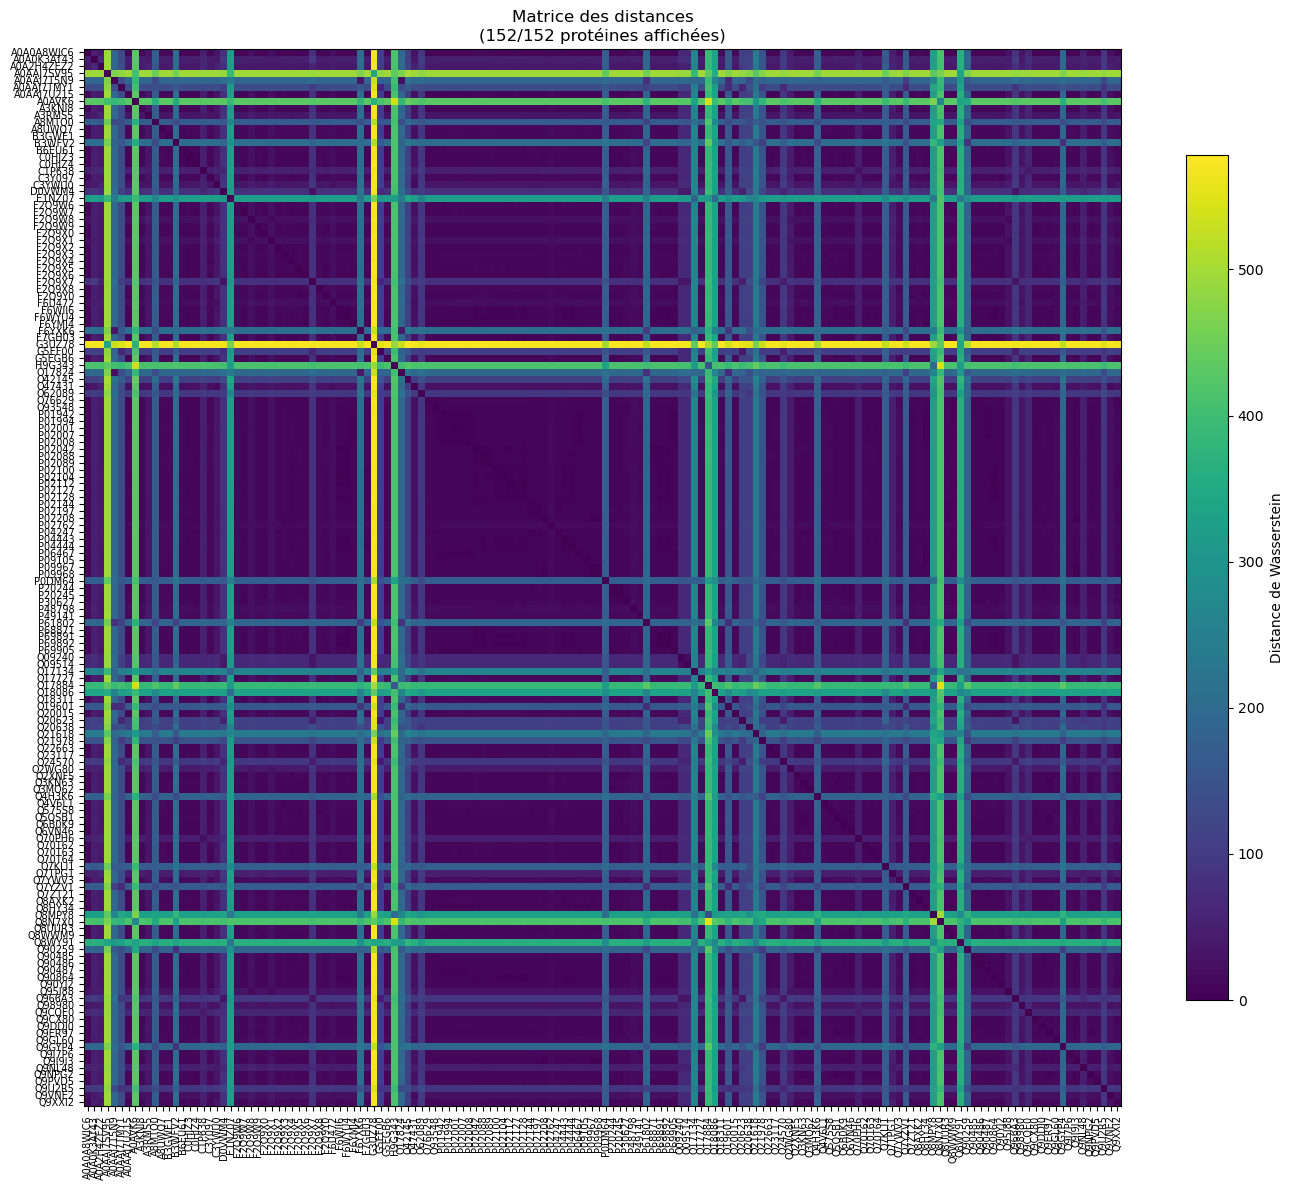

In [13]:
# Exemple 1: Affichage graphique (heatmap)
afficher_matrice(matrice, codes, taille_max=153, figsize=(14, 12))

In [14]:
afficher_matrice_interactive(matrice, codes, 153)

In [15]:
codes_subset = codes[:20]
indices = [codes.index(c) for c in codes_subset]
matrice_subset = matrice[np.ix_(indices, indices)]
afficher_matrice_interactive(matrice_subset, codes_subset, limite = 152)

### 2. Régression Linéaire aux Moindres Carrés (RLMC)

Pour chaque protéine $i$, on considère les distances $w_{i,j}$ avec toutes les autres protéines $j \neq i$.

$$ y_i = (w_i,1 , w_i,2 , ... , w_i,i-1 , w_i,i+1 , ... w_i,n ) $$

On modélise la relation entre :
- **Variable indépendante** $x_j = j$ (position de la protéine $j$ dans la matrice)
- **Variable dépendante** $y_j = w_{i,j}$ (distance de Wasserstein)

Le modèle de régression linéaire s'écrit :

$$\hat{y}_j = a_i \cdot x_j + b_i$$

Où :
- $a_i$ est la **pente** (coefficient de régression)
- $b_i$ est l'**ordonnée à l'origine** (intercept)

---



### 3. Calcul des paramètres par la méthode des moindres carrés

Pour minimiser la somme des carrés des résidus :

$$\min_{a_i, b_i} \sum_{j \neq i} \left( y_j - (a_i x_j + b_i) \right)^2$$

Les solutions sont données par :

$$a_i = \frac{\sum_{j \neq i} (x_j - \bar{x})(y_j - \bar{y})}{\sum_{j \neq i} (x_j - \bar{x})^2}$$

$$b_i = \bar{y} - a_i \bar{x}$$

Où $\bar{x}$ et $\bar{y}$ sont les moyennes des $x_j$ et $y_j$ respectivement.
- $\bar{x}$ est la moyenne des positions $x_j$
- $\bar{y}$ est la moyenne des distances $y_j$

La pente $a_i$ représente la direction et l'intensité de la relation linéaire :
- Si $a_i > 0$ : les distances augmentent avec la position $j$
- Si $a_i < 0$ : les distances diminuent avec la position $j$
- Si $a_i \approx 0$ : pas de relation linéaire

L'ordonnée à l'origine $b_i$ représente la valeur prédite lorsque $j = 0$.


---

### 4. Coefficient de détermination $R^2$

Pour tout $i \in [1, n]$, où $n$ est la taille de la matrice, $R^2_i$ désigne le score de similarité de la $i$-ème protéine.

Le coefficient $R^2_i$ mesure la qualité de l'ajustement du modèle linéaire :

$$R^2_i = \frac{\text{SSR}_i}{\text{SST}_i} = 1 - \frac{\text{SSE}_i}{\text{SST}_i}$$

Avec :

- **Somme totale des carrés (SST)** : 
  $$\text{SST}_i = \sum_{j \neq i} (y_j - \bar{y})^2$$

- **Somme des carrés expliquée (SSR)** : 
  $$\text{SSR}_i = \sum_{j \neq i} (\hat{y}_j - \bar{y})^2$$

- **Somme des carrés des erreurs (SSE)** : 
  $$\text{SSE}_i = \sum_{j \neq i} (y_j - \hat{y}_j)^2$$

Le coefficient $R^2$ est compris entre 0 et 1 :

- **$R^2_i \approx 1$** : Excellente corrélation linéaire → la protéine $i$ a un comportement très similaire aux autres
- **$R^2_i \approx 0$** : Pas de corrélation linéaire → la protéine $i$ est très différente des autres

---


In [16]:

def calculer_rlmc_scores(matrice, codes):
     
    n = len(matrice)
    scores_r2 = np.zeros(n)
    p_values = np.zeros(n)
    pentes = np.zeros(n)
    intercepts = np.zeros(n)
    
    for i in range(n):
        # On procède sur la ligne i (distances de la protéine i avec toutes les autres)
        y = []
        x = []
        
        for j in range(n):
            if j != i:
                val = matrice[i, j]
                if isinstance(val, (int, float)) and not np.isnan(val):
                    y.append(float(val))
                    x.append(j)  # Position dans la matrice
        
        if len(y) > 2:
            # Régression linéaire
            slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
            r_squared = r_value ** 2
            scores_r2[i] = r_squared
            p_values[i] = p_value
            pentes[i] = slope
            intercepts[i] = intercept
        else:
            scores_r2[i] = 0
            p_values[i] = 1
            pentes[i] = 0
            intercepts[i] = 0
        
    
    # DataFrame pour les résultats
    df_resultats = pd.DataFrame({
        'Code': codes,
        'R2_Score': scores_r2,
        'Pente': pentes,
        'Intercept': intercepts,
        'P_Value': p_values
    })
    
    # Trier par R² décroissant (plus similaire = plus élevé)
    df_resultats = df_resultats.sort_values('R2_Score', ascending=False).reset_index(drop=True)
    
    return scores_r2, p_values, df_resultats, pentes, intercepts


In [17]:
scores_r2, p_values, df_resultats, pentes, intercepts = calculer_rlmc_scores(matrice, codes)

ordre_original = {code: i for i, code in enumerate(codes)}
vecteur_scores_original = np.array([scores_r2[ordre_original[code]] for code in codes])

print("\n scores R^2 dans l'ordre :")
for i in range(min(153, len(codes))):
    print(f"   {codes[i]}: {vecteur_scores_original[i]:.4f}")


 scores R^2 dans l'ordre :
   A0A0A8WJC6: 0.0042
   A0A0K3AT43: 0.0049
   A0A2H4ZEZ2: 0.0047
   A0AAJ7SV95: 0.0000
   A0AAJ7T5N9: 0.0054
   A0AAJ7TMY1: 0.0086
   A0AAJ7U215: 0.0042
   A0AVK6: 0.0047
   A3KNI8: 0.0042
   A3RMS5: 0.0046
   A8MTQ0: 0.0067
   A8UWQ7: 0.0043
   B3GWE1: 0.0042
   B3WFV2: 0.0133
   B6EU61: 0.0041
   C0HJZ3: 0.0040
   C0HJZ4: 0.0040
   C1P638: 0.0048
   C3Y097: 0.0041
   C3YWU0: 0.0047
   D0VWM4: 0.0060
   E1NZ07: 0.0046
   F2Q9W6: 0.0041
   F2Q9W7: 0.0040
   F2Q9W8: 0.0041
   F2Q9W9: 0.0040
   F2Q9X0: 0.0039
   F2Q9X1: 0.0040
   F2Q9X2: 0.0039
   F2Q9X3: 0.0039
   F2Q9X4: 0.0039
   F2Q9X5: 0.0039
   F2Q9X6: 0.0038
   F2Q9X7: 0.0057
   F2Q9X8: 0.0039
   F2Q9Y0: 0.0038
   F6U472: 0.0043
   F6WII6: 0.0038
   F6WYU4: 0.0038
   F6YMJ4: 0.0037
   F6YXK6: 0.0034
   F7GH03: 0.0037
   G3UZ78: 0.0006
   G5EF00: 0.0071
   G5EGB6: 0.0038
   H9G343: 0.0091
   O17824: 0.0030
   O42145: 0.0049
   O47431: 0.0040
   O62089: 0.0055
   O76629: 0.0037
   O93548: 0.0036
   P0194



## Propriétés du vecteur des scores RLMC $R^2_{(i)}$ ordonné

Soit $\mathbf{R^2} = (R^2_1, R^2_2, \dots, R^2_n)$ le vecteur des scores de similarité obtenus par régression linéaire aux moindres carrés (RLMC) pour les $n$ protéines.

Le vecteur **ordonné croissant** est défini par :

$$R^2_{(1)} \leq R^2_{(2)} \leq \dots \leq R^2_{(n)}$$

Où : 
- $R^2_{(1)}$ est le **score minimum** (protéine qui a le plus de similarités avec l'ensemble de l'échantillon) 

- $R^2_{(n)}$ est le **score maximum** (protéine la plus différente de toutes les autres dans l'échantillon).

$$\sum_{i=1}^{n} R^2_i = 1$$

Par conséquent, la **norme $L^1$** (valeur absolue, ici tous les scores sont positifs) du vecteur $\mathbf{R^2}$ vaut également $1$ :

$$\|\mathbf{R^2}\|_1 = \sum_{i=1}^{n} |R^2_i| = \sum_{i=1}^{n} R^2_i = 1$$

Cette propriété découle du fait que les scores $R^2$ sont obtenus à partir d'une décomposition de la variance totale (SST) en variance expliquée (SSR) et variance résiduelle (SSE), avec :

$$R^2_i = \frac{\text{SSR}_i}{\text{SST}_i} \quad \text{et} \quad \sum_{i=1}^{n} R^2_i = 1$$

Ainsi, les scores $R^2_i$ forment une **partition de l'unité** : ils représentent la contribution relative de chaque protéine à la similarité globale de l'échantillon.


##  Propriétés asymptotiques 

### 4.1 Loi des grands nombres

en supposant que les $R^2_i$ sont i.i.d. ( c'est une approximation pour une matrice de comparaisons de distances : la symétrie de la matrice engendre des dépendances )

Pour $n$ grand, la moyenne empirique converge vers l'espérance théorique :

$$\bar{R^2} \xrightarrow[n \to \infty]{\text{p.s.}} \mathbb{E}[R^2]$$

autrement dit la moyenne des scores de RLMC converge vers l'espérance théorique du coefficient de détermination.

## Définition Convergence presque sûre

Soit $(X_n)_{n \in \mathbb{N}}$ une suite de variables aléatoires définies sur un espace de probabilité $(\Omega, \mathcal{F}, \mathbb{P})$, et $X$ une variable aléatoire.

On dit que **$X_n$ converge vers $X$ presque sûrement** (ou *presque partout*) si :

$$\mathbb{P}\left( \lim_{n \to \infty} X_n = X \right) = 1$$

Autrement dit, l'ensemble des $\omega \in \Omega$ pour lesquels $X_n(\omega)$ **ne converge pas** vers $X(\omega)$ est de probabilité nulle.


###  Théorème central limite pour un échantillon grand

Pour $n$ grand, la distribution de la moyenne standardisée suit une loi normale :

$$\sqrt{n} \left( \bar{R^2} - \mathbb{E}[R^2] \right) \xrightarrow[n \to \infty]{\mathcal{L}} \mathcal{N}(0, \sigma^2)$$

###  Statistiques d'ordre ( à priori pas utile dans cette étude ) :

La distribution du $k$-ième plus petit score $R^2_{(k)}$ suit une loi Bêta transformée :

$$F_{R^2_{(k)}}(x) = \sum_{j=k}^{n} \binom{n}{j} \left[F(x)\right]^j \left[1-F(x)\right]^{n-j}$$

Où $F(x)$ est la fonction de répartition des scores bruts.

---


###  Définition Loi Bêta

Une variable aléatoire $X$ suit une **loi Bêta** de paramètres $\alpha > 0$ et $\beta > 0$, notée $X \sim \text{Bêta}(\alpha, \beta)$, si sa densité de probabilité est :

$$f_X(x) = \frac{x^{\alpha-1} (1-x)^{\beta-1}}{\mathrm{B}(\alpha, \beta)}, \quad 0 \leq x \leq 1$$

Où $\mathrm{B}(\alpha, \beta)$ est la **fonction bêta**, définie par :

$$\mathrm{B}(\alpha, \beta) = \int_{0}^{1} t^{\alpha-1} (1-t)^{\beta-1} dt = \frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha+\beta)}$$

Avec $\Gamma(\cdot)$ la fonction Gamma d'Euler.


---

## Fonction gamma : $\Gamma(z)$  =   $\int_0^{\infty} t^{z-1} e^{-t} dt$  ,  $\operatorname{Re}(z) > 0$ 

---


## Objectif : Rejet ou non de l'hypothèse H0

### Hypothèse H0 : il n'y a pas de relation linéaire entre les variables
### c'est à dire que la position dans la matrice d'une protéine n'influe pas sur le score de RSMD

Sous H0 la distribution théorique $R^2$ suit une loi béta et en dimension 2 (*) avec un nombre N de points de régression l'espérance de R^2 théorique vaut 1/(N-1)
Donc pour un jeu de 152 protéines cette valeur vaut environ 0.00667

### Hypothèse H1 = Rejet de H0 si il y a une relation (bruitée ou parfaite) entre les variables

On rejette H0 si la valeur de l'espérance de $R^2$ > 1/(N-1) 
De plus, il y a relation parfaite entre les variables si E($R^2$) = 1



(*)
ici on a utilisé une formule de régression linéaire sur l'espace $L^2$ avec la distance euclidienne classique
Mais sur l'espace de transport optimal en utilisant la métrique de la distance de Wasserstein à la place nous aurons des résultats de convergence différents,
pour lesquels il serait toujours possible de vérifier ou non l'hypothèse H0 mais avec des critères différents de $R^2$ théorique

###  Pourcentage de similitude - normalisation des scores $R^2$

Normalisation des scores $R^2$ pour obtenir un pourcentage :

$$S_i = \frac{R^2_i - R^2_{\min}}{R^2_{\max} - R^2_{\min}} \times 100\%$$

Où :
- $R^2_{\min} = \min\limits_{1 \le k \le n} R^2_k$
- $R^2_{\max} = \max\limits_{1 \le k \le n} R^2_k$

---

In [18]:
def afficher_resultats_rlmc(df_resultats, pourcentage_similitude, top_n=10):
   
    
    # Statistiques globales
    print(f"\n Statistiques globales:")
    print(f"   - R² moyen: {df_resultats['R2_Score'].mean():.4f}")
    print(f"   - R² médian: {df_resultats['R2_Score'].median():.4f}")
    print(f"   - R² min: {df_resultats['R2_Score'].min():.4f}")
    print(f"   - R² max: {df_resultats['R2_Score'].max():.4f}")
    print(f"   - Écart-type R²: {df_resultats['R2_Score'].std():.4f}")
    
    print(f"\n Pourcentage de similitude moyen: {np.mean(pourcentage_similitude):.1f}%")
    
    # Top N protéines (les PLUS similaires)
    print(f"\n TOP {top_n} protéines les PLUS similaires aux autres (R² le plus élevé):")
    for i in range(min(top_n, len(df_resultats))):
        row = df_resultats.iloc[i]
        sim = pourcentage_similitude[df_resultats.index[i]]
        print(f"   {i+1:2}. {row['Code']:<15} R² = {row['R2_Score']:.4f}  ({sim:.1f}% similitude)")
    
    # Bottom N protéines (les MOINS similaires)
    print(f"\n BOTTOM {top_n} protéines les MOINS similaires aux autres (R² le plus faible):")
    for i in range(min(top_n, len(df_resultats))):
        row = df_resultats.iloc[-(i+1)]
        sim = pourcentage_similitude[df_resultats.index[-(i+1)]]
        print(f"   {i+1:2}. {row['Code']:<15} R² = {row['R2_Score']:.4f}  ({sim:.1f}% similitude)")
    
    return df_resultats

In [19]:
def visualiser_scores_rlmc(df_resultats, pourcentage_similitude, scores_r2):
    
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Graphique 1: R² par protéine
    axes[0, 0].bar(range(len(df_resultats)), df_resultats['R2_Score'].values, 
                   color='steelblue', alpha=0.7)
    axes[0, 0].set_xlabel('Protéines (triées par R² décroissant)', fontsize=10)
    axes[0, 0].set_ylabel('R² (Coefficient de détermination)', fontsize=10)
    axes[0, 0].set_title('Scores RLMC par protéine', fontsize=12)
    axes[0, 0].set_ylim(0, 0.1) # 1 au maximum, mais au vue des résultats 0.1 est plus lisible
    axes[0, 0].grid(True, alpha=0.3)
    
    # Graphique 2: Pourcentage de similitude
    axes[0, 1].bar(range(len(pourcentage_similitude)), pourcentage_similitude, 
                   color='coral', alpha=0.7)
    axes[0, 1].axhline(y=np.mean(pourcentage_similitude), color='red', 
                       linestyle='--', label=f'Moyenne: {np.mean(pourcentage_similitude):.1f}%')
    axes[0, 1].set_xlabel('Protéines (triées par R² décroissant)', fontsize=10)
    axes[0, 1].set_ylabel('Pourcentage de similitude (%)', fontsize=10)
    axes[0, 1].set_title('Pourcentage de similitude par protéine', fontsize=12)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Graphique 3: Distribution des R²
    axes[1, 0].hist(scores_r2, bins=20, color='green', alpha=0.7, edgecolor='black')
    axes[1, 0].axvline(x=np.mean(scores_r2), color='red', linestyle='--', 
                       label=f'Moyenne: {np.mean(scores_r2):.3f}')
    axes[1, 0].set_xlabel('R²', fontsize=10)
    axes[1, 0].set_ylabel('Fréquence', fontsize=10)
    axes[1, 0].set_title('Distribution des scores RLMC', fontsize=12)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Graphique 4: Courbe de décroissance
    axes[1, 1].plot(range(len(df_resultats)), df_resultats['R2_Score'].values, 
                    'b-o', markersize=3, linewidth=1, alpha=0.7)
    axes[1, 1].fill_between(range(len(df_resultats)), 0, df_resultats['R2_Score'].values, 
                            alpha=0.3, color='blue')
    axes[1, 1].set_xlabel('Rang (ordre décroissant)', fontsize=10)
    axes[1, 1].set_ylabel('R²', fontsize=10)
    axes[1, 1].set_title('Courbe de décroissance des scores RLMC', fontsize=12)
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [20]:

def calculer_pourcentage_similitude(scores_r2):
    """
    Convertit les scores R² en pourcentages de similitude.
    """
    # Normaliser entre 0 et 1
    r2_min = np.min(scores_r2)
    r2_max = np.max(scores_r2)
    
    if r2_max > r2_min:
        pourcentage = (scores_r2 - r2_min) / (r2_max - r2_min) * 100
    else:
        pourcentage = np.zeros_like(scores_r2)
    
    return pourcentage


 Statistiques globales:
   - R² moyen: 0.0039
   - R² médian: 0.0036
   - R² min: 0.0000
   - R² max: 0.0133
   - Écart-type R²: 0.0016

 Pourcentage de similitude moyen: 29.1%

 TOP 15 protéines les PLUS similaires aux autres (R² le plus élevé):
    1. B3WFV2          R² = 0.0133  (31.9% similitude)
    2. H9G343          R² = 0.0091  (36.9% similitude)
    3. P0DM64          R² = 0.0087  (35.0% similitude)
    4. A0AAJ7TMY1      R² = 0.0086  (0.0% similitude)
    5. Q21978          R² = 0.0085  (40.8% similitude)
    6. Q4H3K6          R² = 0.0083  (64.8% similitude)
    7. Q21618          R² = 0.0072  (31.6% similitude)
    8. G5EF00          R² = 0.0071  (35.5% similitude)
    9. A8MTQ0          R² = 0.0067  (31.6% similitude)
   10. D0VWM4          R² = 0.0060  (34.5% similitude)
   11. F2Q9X7          R² = 0.0057  (50.8% similitude)
   12. Q17134          R² = 0.0057  (32.2% similitude)
   13. O62089          R² = 0.0055  (31.5% similitude)
   14. A0AAJ7T5N9      R² = 0.0054  (1

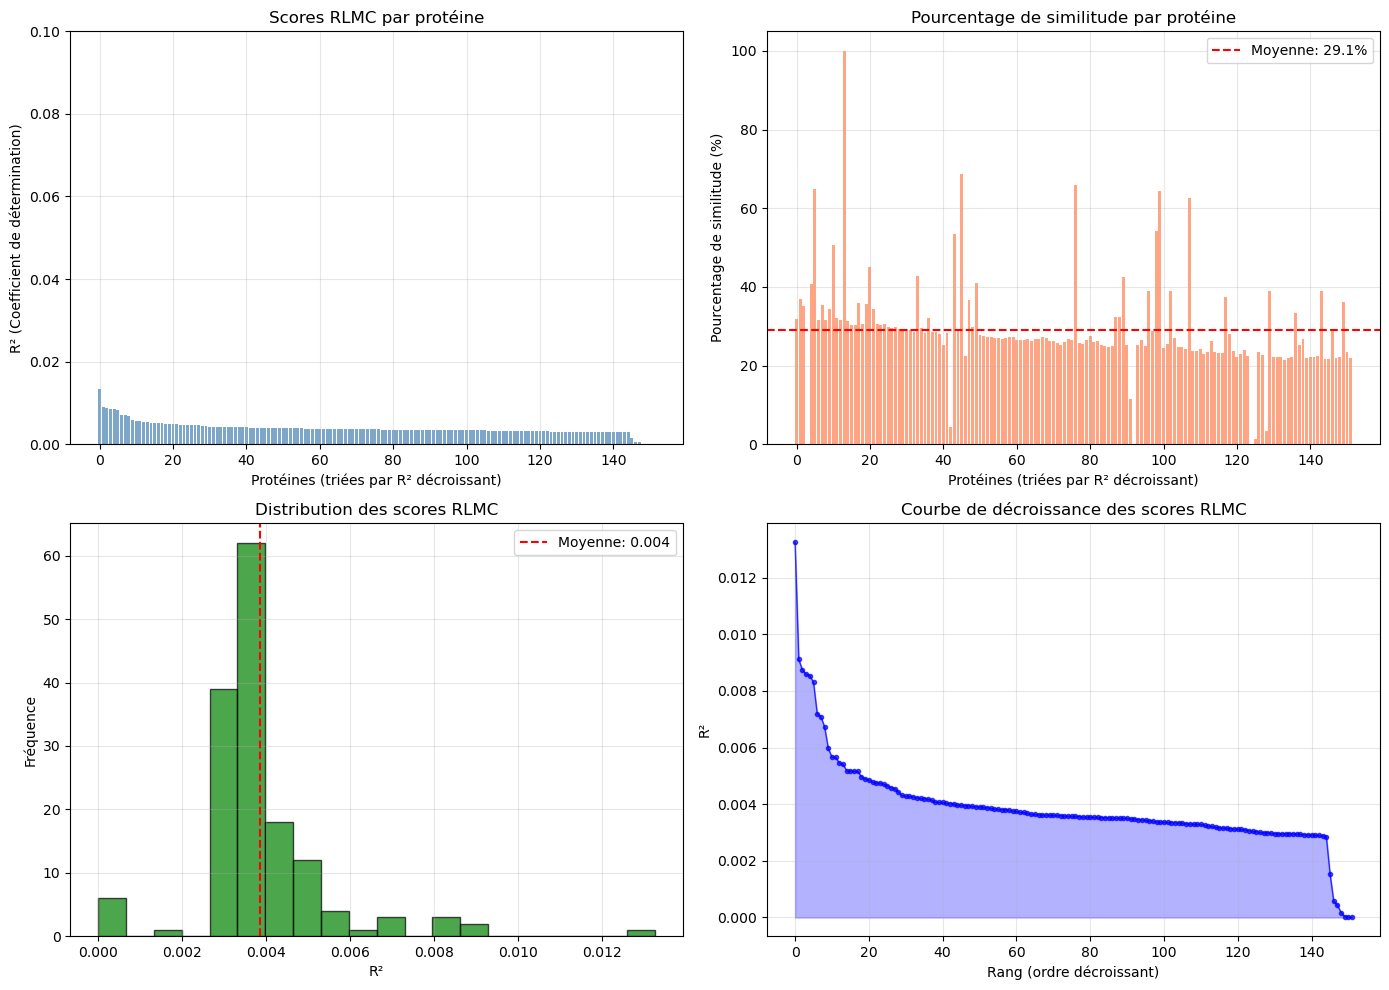


 Résultats sauvegardés dans 'scores_rlmc.csv'

 VECTEUR DES SCORES RLMC
Vecteur de 152 scores:
   Min: 0.0000
   Max: 0.0133
   Moyenne: 0.0039

 Premiers scores (ordre original):
   A0A0A8WJC6: 0.0042
   A0A0K3AT43: 0.0049
   A0A2H4ZEZ2: 0.0047
   A0AAJ7SV95: 0.0000
   A0AAJ7T5N9: 0.0054
   A0AAJ7TMY1: 0.0086
   A0AAJ7U215: 0.0042
   A0AVK6: 0.0047
   A3KNI8: 0.0042
   A3RMS5: 0.0046


In [21]:

# 1. Calculer les scores RLMC
scores_r2, p_values, df_resultats, pentes, intercepts = calculer_rlmc_scores(matrice, codes)

# 2. Calculer les pourcentages de similitude
pourcentage_similitude = calculer_pourcentage_similitude(scores_r2)

# 3. Afficher les résultats
df_resultats = afficher_resultats_rlmc(df_resultats, pourcentage_similitude, top_n=15)

# 4. Visualiser
visualiser_scores_rlmc(df_resultats, pourcentage_similitude, scores_r2)

# 5. Sauvegarder les résultats
df_resultats.to_csv('scores_rlmc.csv', index=False)
print("\n Résultats sauvegardés dans 'scores_rlmc.csv'")

# 6. Vecteur des scores (dans l'ordre original des codes)
ordre_original = {code: i for i, code in enumerate(codes)}
vecteur_scores_original = np.array([scores_r2[ordre_original[code]] for code in codes])

print("\n" + "=" * 60)
print(" VECTEUR DES SCORES RLMC")
print("=" * 60)
print(f"Vecteur de {len(vecteur_scores_original)} scores:")
print(f"   Min: {vecteur_scores_original.min():.4f}")
print(f"   Max: {vecteur_scores_original.max():.4f}")
print(f"   Moyenne: {vecteur_scores_original.mean():.4f}")

# Afficher les premiers scores
print("\n Premiers scores (ordre original):")
for i in range(min(10, len(codes))):
    print(f"   {codes[i]}: {vecteur_scores_original[i]:.4f}")

### 5. Test de significativité ($p$-value)

La $p$-value teste l'hypothèse nulle $H_0 : a_i = 0$ (pas de relation linéaire).

La statistique de test suit une loi de Student à $\nu = n-2$ degrés de liberté :

$$t_i = \frac{a_i}{\text{SE}(a_i)}$$

## Définition loi de student

Soit $Z$ une variable aléatoire suivant une loi normale centrée réduite $Z \sim \mathcal{N}(0,1)$ et $V$ une variable aléatoire indépendante suivant une loi du chi-deux à $\nu$ degrés de liberté $V \sim \chi^2(\nu)$.

Alors la variable :

$$T = \frac{Z}{\sqrt{V/\nu}}$$

suit une **loi de Student** à $\nu$ degrés de liberté, notée $T \sim t(\nu)$ ou $T \sim \text{Student}(\nu)$.




ici on a $$t_i = \frac{a_i}{\text{SE}(a_i)}$$

Où $\text{SE}(a_i)$ est l'erreur standard de la pente :

$$\text{SE}(a_i) = \sqrt{\frac{\text{SSE}_i / (n-2)}{\sum_{j \neq i} (x_j - \bar{x})^2}}$$



La $p$-value est alors :

$$p_i = 2 \cdot P(T > |t_i|) \quad \text{où} \quad T \sim \text{Student}(\nu)$$

Une $p$-value < 0.05 indique une relation statistiquement significative.

---



### Problème des comparaisons multiples

Lorsque l'on effectue de multiples tests statistiques simultanément, le risque d'obtenir un résultat **faussement significatif** (erreur de type I) augmente considérablement.

Pour un seul test avec un seuil de significativité $\alpha = 0.05$, la probabilité de rejeter à tort l'hypothèse nulle est de 5%.

Pour $m$ tests indépendants, la probabilité d'au moins un faux positif est :

$$P(\text{au moins un faux positif}) = 1 - (1 - \alpha)^m$$

**Exemple** : Pour $m = 152$ protéines :

$$P = 1 - (1 - 0.05)^{152} \approx 1 - 0.95^{152} \approx 1 - 0.0004 \approx 0.9996$$

Soit **99.96% de risque** d'avoir au moins un faux positif ! Les résultats deviennent donc peu fiables.

---



In [22]:
def calculer_proba_faux_positif(alpha, m):
    
    return 1 - (1 - alpha) ** m

In [23]:
def determiner_seuil_m(alpha=0.05, proba_max=0.5):
   
    # Résoudre 1 - (1 - alpha)^m = proba_max
    #  (1 - alpha)^m = 1 - proba_max
    #  m = log(1 - proba_max) / log(1 - alpha)
    
    m_max = np.log(1 - proba_max) / np.log(1 - alpha)
    return int(np.floor(m_max))

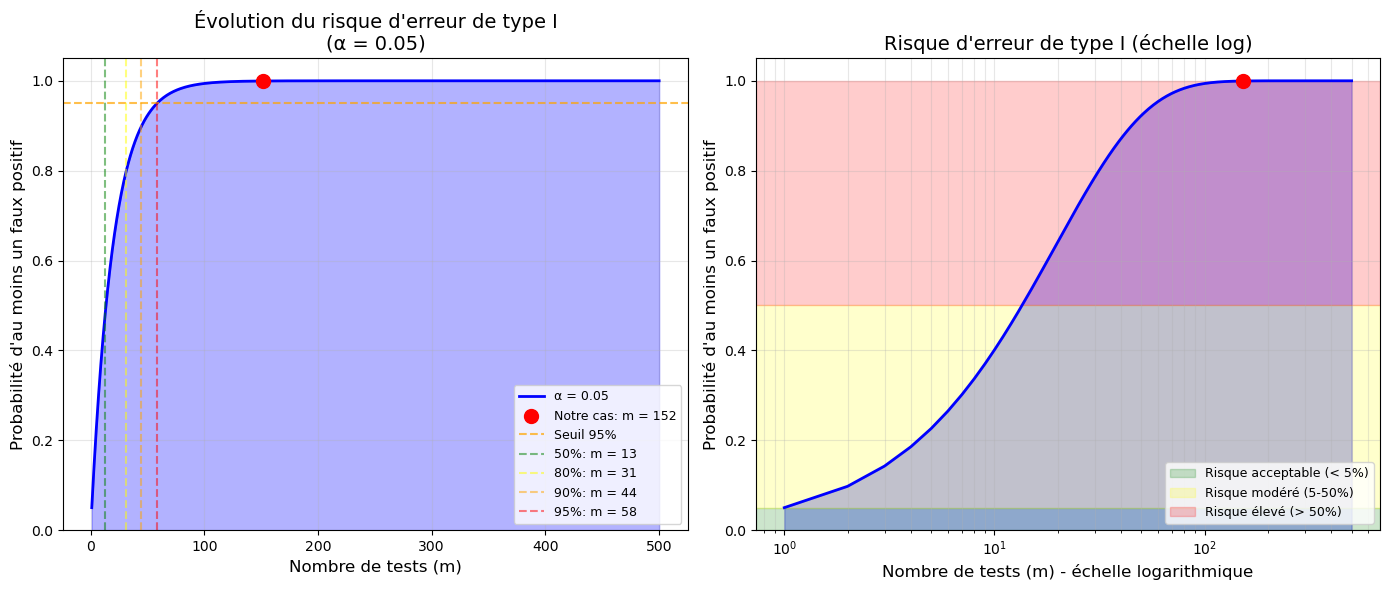


 m (tests)   |     Probabilité      |              Interprétation             
---------------------------------------------------------------------------
     1       |       0.050000       |               Risque modéré             
     5       |       0.226219       |               Risque modéré             
     10      |       0.401263       |               Risque modéré             
     20      |       0.641514       |               Risque élevé              
     50      |       0.923055       |               Risque élevé              
    100      |       0.994079       |               Risque élevé              
    152      |       0.999589       |               Risque élevé              
    200      |       0.999965       |               Risque élevé              
    500      |       1.000000       |               Risque élevé              
    1000     |       1.000000       |               Risque élevé              


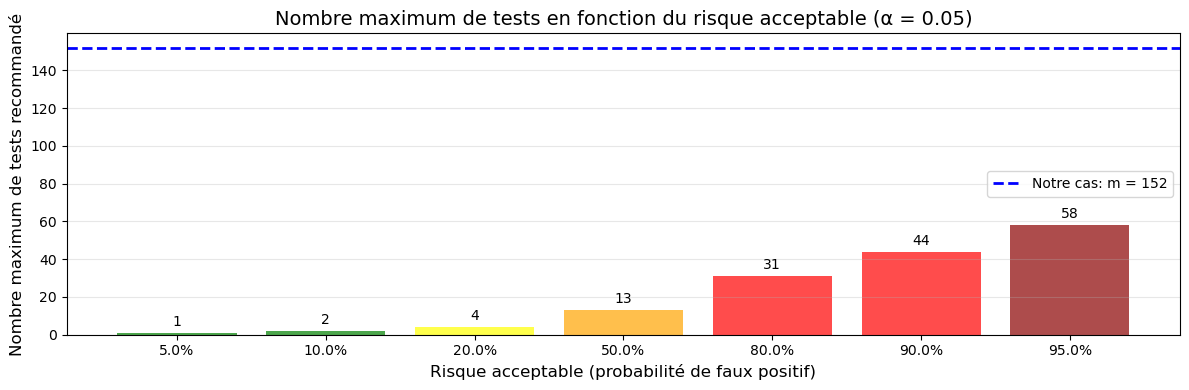


CONCLUSION

Avec 152 tests (une par protéine) et α = 0.05 :

• La probabilité d'avoir au moins un faux positif est de 99.96%
• Cela signifie que nos résultats sont très probablement contaminés par des faux positifs
• La correction de Bonferroni est fortement recommandée
• Le seuil corrigé serait α_corr = 0.000329
• Aucune de nos protéines n'atteint ce seuil (p > 0.000329)

⟹ Conclusion: Les résultats individuels ne sont pas statistiquement significatifs
   après correction pour comparaisons multiples.



In [24]:

# Paramètres
alpha = 0.05
m_values = np.arange(1, 501, 1)  # De 1 à 500 tests

# Calcul des probabilités
probas = calculer_proba_faux_positif(alpha, m_values)

# Création de la figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ========== GRAPHE 1: Évolution de la probabilité ==========
ax1.plot(m_values, probas, 'b-', linewidth=2, label=f'α = {alpha}')
ax1.fill_between(m_values, 0, probas, alpha=0.3, color='blue')

# Marquer notre cas (152 protéines)
m_notre_cas = 152
proba_notre_cas = calculer_proba_faux_positif(alpha, m_notre_cas)
ax1.scatter([m_notre_cas], [proba_notre_cas], color='red', s=100, zorder=5, 
            label=f'Notre cas: m = {m_notre_cas}')

# Ajouter une ligne horizontale à 0.95
ax1.axhline(y=0.95, color='orange', linestyle='--', alpha=0.7, 
            label='Seuil 95%')

# Seuils recommandés
seuil_50 = determiner_seuil_m(alpha, 0.5)
seuil_80 = determiner_seuil_m(alpha, 0.8)
seuil_90 = determiner_seuil_m(alpha, 0.9)
seuil_95 = determiner_seuil_m(alpha, 0.95)

ax1.axvline(x=seuil_50, color='green', linestyle='--', alpha=0.5, 
            label=f'50%: m = {seuil_50}')
ax1.axvline(x=seuil_80, color='yellow', linestyle='--', alpha=0.5, 
            label=f'80%: m = {seuil_80}')
ax1.axvline(x=seuil_90, color='orange', linestyle='--', alpha=0.5, 
            label=f'90%: m = {seuil_90}')
ax1.axvline(x=seuil_95, color='red', linestyle='--', alpha=0.5, 
            label=f'95%: m = {seuil_95}')

ax1.set_xlabel('Nombre de tests (m)', fontsize=12)
ax1.set_ylabel('Probabilité d\'au moins un faux positif', fontsize=12)
ax1.set_title(f'Évolution du risque d\'erreur de type I\n(α = {alpha})', fontsize=14)
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1.05)

# ========== GRAPHE 2: Échelle logarithmique ==========
ax2.semilogx(m_values, probas, 'b-', linewidth=2)
ax2.fill_between(m_values, 0, probas, alpha=0.3, color='blue')
ax2.scatter([m_notre_cas], [proba_notre_cas], color='red', s=100, zorder=5)

# Zones de risque
ax2.axhspan(0, 0.05, alpha=0.2, color='green', label='Risque acceptable (< 5%)')
ax2.axhspan(0.05, 0.5, alpha=0.2, color='yellow', label='Risque modéré (5-50%)')
ax2.axhspan(0.5, 1, alpha=0.2, color='red', label='Risque élevé (> 50%)')

ax2.set_xlabel('Nombre de tests (m) - échelle logarithmique', fontsize=12)
ax2.set_ylabel('Probabilité d\'au moins un faux positif', fontsize=12)
ax2.set_title('Risque d\'erreur de type I (échelle log)', fontsize=14)
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(True, alpha=0.3, which='both')
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()



m_test = [1, 5, 10, 20, 50, 100, 152, 200, 500, 1000]
print(f"\n{'m (tests)':^12} | {'Probabilité':^20} | {'Interprétation':^40}")
print("-" * 75)

for m in m_test:
    proba = calculer_proba_faux_positif(alpha, m)
    
    if proba < 0.05:
        interpretation = " Risque faible"
    elif proba < 0.5:
        interpretation = " Risque modéré"
    else:
        interpretation = " Risque élevé"
    
    print(f"{m:^12} | {proba:^20.6f} | {interpretation:^40}")


fig, ax = plt.subplots(figsize=(12, 4))

# Créer un barplot des seuils
seuils = [0.05, 0.10, 0.20, 0.50, 0.80, 0.90, 0.95]
m_max = [determiner_seuil_m(alpha, s) for s in seuils]
couleurs = ['green', 'green', 'yellow', 'orange', 'red', 'red', 'darkred']

bars = ax.bar([str(s*100) + '%' for s in seuils], m_max, color=couleurs, alpha=0.7)
ax.axhline(y=m_notre_cas, color='blue', linestyle='--', linewidth=2, 
           label=f'Notre cas: m = {m_notre_cas}')
ax.set_xlabel('Risque acceptable (probabilité de faux positif)', fontsize=12)
ax.set_ylabel('Nombre maximum de tests recommandé', fontsize=12)
ax.set_title(f'Nombre maximum de tests en fonction du risque acceptable (α = {alpha})', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Ajouter les valeurs sur les barres
for bar, val in zip(bars, m_max):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
            str(val), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("CONCLUSION")
print("=" * 80)
print(f"""
Avec {m_notre_cas} tests (une par protéine) et α = 0.05 :

• La probabilité d'avoir au moins un faux positif est de {proba_notre_cas:.2%}
• Cela signifie que nos résultats sont très probablement contaminés par des faux positifs
• La correction de Bonferroni est fortement recommandée
• Le seuil corrigé serait α_corr = {alpha/m_notre_cas:.6f}
• Aucune de nos protéines n'atteint ce seuil (p > {alpha/m_notre_cas:.6f})

⟹ Conclusion: Les résultats individuels ne sont pas statistiquement significatifs
   après correction pour comparaisons multiples.
""")

## Correction de Bonferroni

La **correction de Bonferroni** est une méthode simple pour contrôler le risque d'erreur de type I lors de comparaisons multiples.

### Principe

On ajuste le seuil de significativité $\alpha$ en le divisant par le nombre $m$ de tests effectués :

$$\alpha_{\text{corrigé}} = \frac{\alpha}{m}$$

### Application à notre cas

Avec $m = 152$ tests (une régression par protéine) et $\alpha = 0.05$ :

$$\alpha_{\text{corrigé}} = \frac{0.05}{152} \approx 0.000329$$

Une protéine n'est considérée comme **statistiquement significative** que si :

$$p_i < \frac{\alpha}{m} \approx 0.000329$$

### Conséquence

Avec notre seuil corrigé, aucune de nos protéines n'est significative car la plus petite p-value observée est $p \approx 0.158$, bien supérieure à $0.000329$.




In [25]:
def correction_bonferroni(alpha, m):
   
    return alpha / m

In [26]:
def est_significatif(p_value, alpha, m, correction=True):
    """
    Vérifie si une p-value est significative.
    
    Paramètres:
    - p_value: p-value du test
    - alpha: seuil initial (défaut: 0.05)
    - m: nombre de tests
    - correction: appliquer Bonferroni (défaut: True)
    """
    if correction:
        seuil = alpha / m
    else:
        seuil = alpha
    
    return p_value < seuil, seuil

In [27]:

alpha = 0.05
m = 152

# Meilleure p-value obtenue
p_min = 0.158057

significatif, seuil = est_significatif(p_min, alpha, m, correction=True)

print(f"Seuil corrigé: {seuil:.6f}")
print(f"P-value minimale: {p_min:.6f}")
print(f"Significatif: {'OUI' if significatif else ' NON'}")

Seuil corrigé: 0.000329
P-value minimale: 0.158057
Significatif:  NON


 APPLICATION DU TEST DE SIGNIFICATIVITÉ

TEST DE SIGNIFICATIVITÉ GLOBALE
 Moyenne des R²: 0.0039
 Écart-type des R²: 0.0016
 Statistique t: 29.8653
 p-value: 0.000000

 Conclusion: Les scores R² sont globalement significatifs (p < 0.05)
   Les relations linéaires dans la matrice des distances sont statistiquement valides.
TEST DE SIGNIFICATIVITÉ DES SCORES RLMC
 Nombre de protéines: 152
 Seuil α: 0.05


RÉSULTATS DU TEST DE SIGNIFICATIVITÉ

 Statistiques globales:
   - Nombre de protéines: 152
   - Seuil α: 0.05
   - Protéines significatives: 0 (0.0%)
   - Protéines non significatives: 152

 TOP 15 protéines les PLUS significatives (p-value la plus faible):
    1. p >= α pas ok B3WFV2          p = 0.159157  |  R² = 0.0133
    2. p >= α pas ok H9G343          p = 0.243592  |  R² = 0.0091
    3. p >= α pas ok P0DM64          p = 0.253578  |  R² = 0.0087
    4. p >= α pas ok A0AAJ7TMY1      p = 0.257605  |  R² = 0.0086
    5. p >= α pas ok Q21978          p = 0.258969  |  R² = 0.0085
    

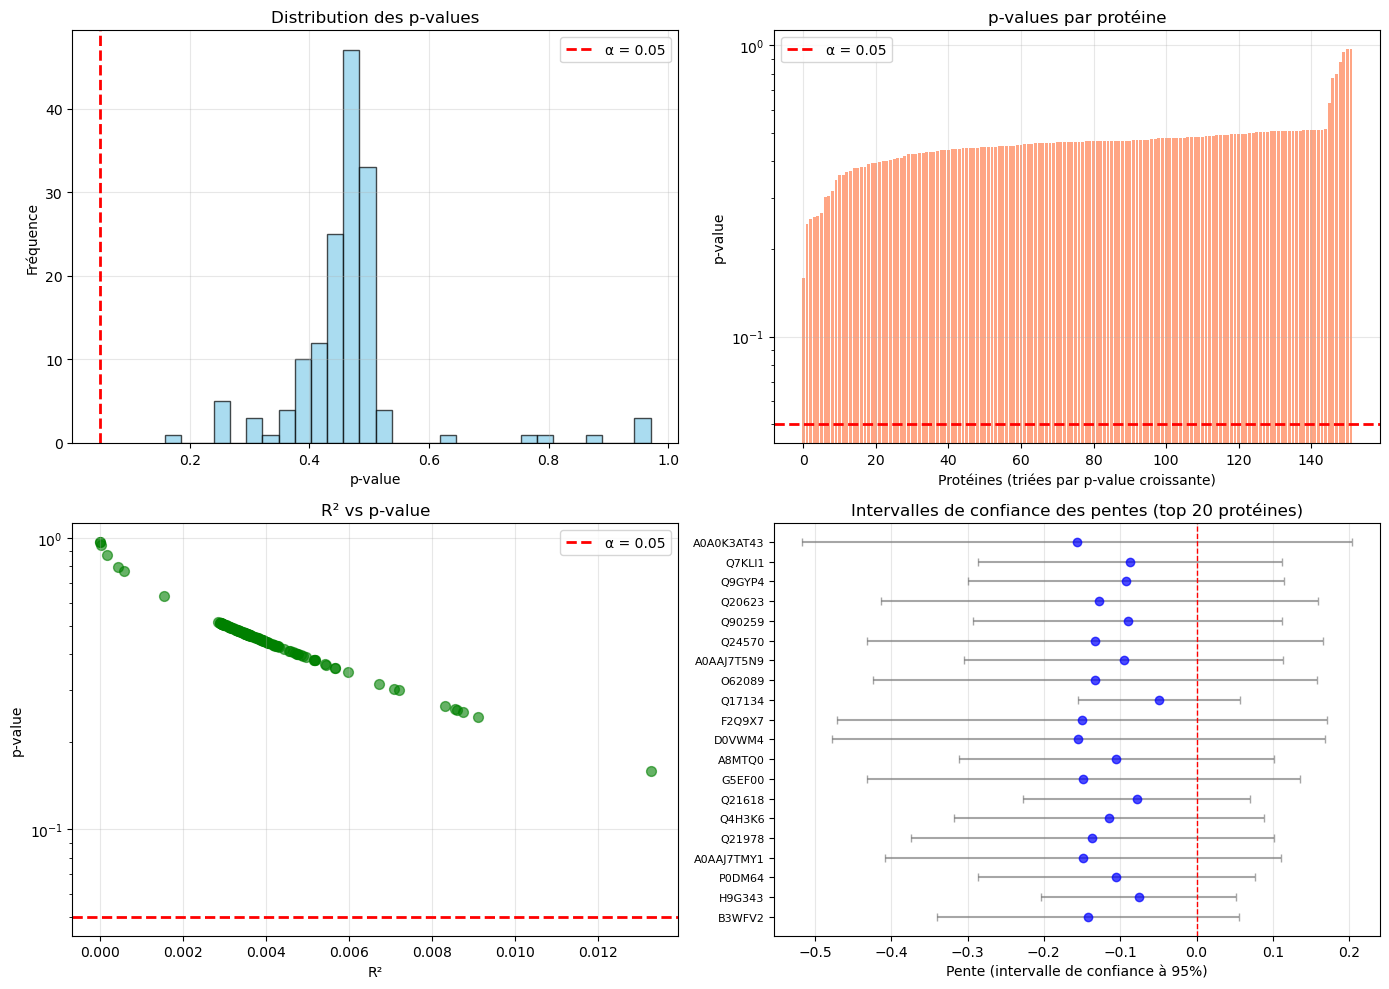


TEST DE SIGNIFICATIVITÉ DES SCORES RLMC
 Nombre de protéines: 152
 Seuil α: 0.05
 Correction de Bonferroni appliquée

   α corrigé: 0.000329

 Résultats sauvegardés dans 'test_significativite_rlmc.csv'

RÉSUMÉ FINAL

 RÉSULTATS DU TEST DE SIGNIFICATIVITÉ:

• Test global (moyenne des R² > 0):
  - p-value = 0.000000
  - Conclusion:  SIGNIFICATIF

• Test individuel (p < 0.05):
  - Protéines significatives: 0/152
  - Pourcentage: 0.0%

• Top 3 protéines les plus significatives:
  B3WFV2: p = 0.159157
  H9G343: p = 0.243592
  P0DM64: p = 0.253578



In [28]:


def test_significativite_rlmc(matrice, codes, alpha=0.05, correction_bonferroni=False):
   
    n = len(matrice)
    
    # Initialisation
    r_squared = np.zeros(n)
    p_values = np.zeros(n)
    t_statistics = np.zeros(n)
    slopes = np.zeros(n)
    intercepts = np.zeros(n)
    std_errors = np.zeros(n)
    conf_int_low = np.zeros(n)
    conf_int_high = np.zeros(n)
    
    print("=" * 70)
    print("TEST DE SIGNIFICATIVITÉ DES SCORES RLMC")
    print("=" * 70)
    print(f" Nombre de protéines: {n}")
    print(f" Seuil α: {alpha}")
    if correction_bonferroni:
        print(f" Correction de Bonferroni appliquée")
    print()
    
    for i in range(n):
        # Préparer les données
        x = []
        y = []
        for j in range(n):
            if j != i:
                val = matrice[i, j]
                if isinstance(val, (int, float)) and not np.isnan(val):
                    x.append(float(j))
                    y.append(float(val))
        
        if len(y) > 2:
            # Régression linéaire
            slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
            
            r_squared[i] = r_value ** 2
            p_values[i] = p_value
            slopes[i] = slope
            intercepts[i] = intercept
            std_errors[i] = std_err
            t_statistics[i] = slope / std_err if std_err > 0 else 0
            
            # Intervalle de confiance à 95%
            deg_freedom = len(x) - 2
            t_critique = stats.t.ppf(1 - alpha/2, deg_freedom)
            conf_int_low[i] = slope - t_critique * std_err
            conf_int_high[i] = slope + t_critique * std_err
    
    # Appliquer correction de Bonferroni si demandée
    if correction_bonferroni:
        alpha_corrige = alpha / n
        print(f"   α corrigé: {alpha_corrige:.6f}")
        rejete_h0 = p_values < alpha_corrige
    else:
        rejete_h0 = p_values < alpha
    
    # Créer DataFrame des résultats
    df_resultats = pd.DataFrame({
        'Code': codes,
        'R2_Score': r_squared,
        'Pente': slopes,
        'Intercept': intercepts,
        'Std_Error': std_errors,
        'T_Statistic': t_statistics,
        'P_Value': p_values,
        'Conf_Int_Low': conf_int_low,
        'Conf_Int_High': conf_int_high,
        'Significatif (p < α)': rejete_h0
    })
    
    # Trier par p-value
    df_resultats = df_resultats.sort_values('P_Value').reset_index(drop=True)
    
    # Statistiques globales
    n_significatifs = sum(rejete_h0)
    n_non_significatifs = n - n_significatifs
    
    resultats_test = {
        'alpha': alpha,
        'correction_bonferroni': correction_bonferroni,
        'n_proteines': n,
        'n_significatifs': n_significatifs,
        'n_non_significatifs': n_non_significatifs,
        'pourcentage_significatifs': n_significatifs / n * 100,
        'alpha_corrige': alpha / n if correction_bonferroni else alpha
    }
    
    return df_resultats, resultats_test


def afficher_resultats_significativite(df_resultats, resultats_test, top_n=20):
    """
    Affiche les résultats du test de significativité.
    """
    print("\n" + "=" * 70)
    print("RÉSULTATS DU TEST DE SIGNIFICATIVITÉ")
    print("=" * 70)
    
    print(f"\n Statistiques globales:")
    print(f"   - Nombre de protéines: {resultats_test['n_proteines']}")
    print(f"   - Seuil α: {resultats_test['alpha']}")
    if resultats_test['correction_bonferroni']:
        print(f"   - α corrigé (Bonferroni): {resultats_test['alpha_corrige']:.6f}")
    print(f"   - Protéines significatives: {resultats_test['n_significatifs']} ({resultats_test['pourcentage_significatifs']:.1f}%)")
    print(f"   - Protéines non significatives: {resultats_test['n_non_significatifs']}")
    
    # Top N protéines les plus significatives (p-value la plus faible)
    print(f"\n TOP {top_n} protéines les PLUS significatives (p-value la plus faible):")
    for i in range(min(top_n, len(df_resultats))):
        row = df_resultats.iloc[i]
        sig = "ok p < α" if row['Significatif (p < α)'] else "p >= α pas ok"
        print(f"   {i+1:2}. {sig} {row['Code']:<15} p = {row['P_Value']:.6f}  |  R² = {row['R2_Score']:.4f}")
    
    # Bottom N protéines les moins significatives
    print(f"\n BOTTOM {top_n} protéines les MOINS significatives (p-value la plus élevée):")
    for i in range(min(top_n, len(df_resultats))):
        row = df_resultats.iloc[-(i+1)]
        sig = "ok p < α" if row['Significatif (p < α)'] else "p >=  α pas ok"
        print(f"   {i+1:2}. {sig} {row['Code']:<15} p = {row['P_Value']:.6f}  |  R² = {row['R2_Score']:.4f}")
    
    return df_resultats


def visualiser_significativite(df_resultats, resultats_test):
    """
    Visualise les résultats du test de significativité.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Distribution des p-values
    axes[0, 0].hist(df_resultats['P_Value'], bins=30, color='skyblue', 
                    edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(x=resultats_test['alpha'], color='red', 
                       linestyle='--', linewidth=2, 
                       label=f'α = {resultats_test["alpha"]}')
    axes[0, 0].set_xlabel('p-value', fontsize=10)
    axes[0, 0].set_ylabel('Fréquence', fontsize=10)
    axes[0, 0].set_title('Distribution des p-values', fontsize=12)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. P-values par protéine (ordre croissant)
    axes[0, 1].bar(range(len(df_resultats)), df_resultats['P_Value'].values,
                   color='coral', alpha=0.7)
    axes[0, 1].axhline(y=resultats_test['alpha'], color='red', 
                       linestyle='--', linewidth=2, 
                       label=f'α = {resultats_test["alpha"]}')
    axes[0, 1].set_xlabel('Protéines (triées par p-value croissante)', fontsize=10)
    axes[0, 1].set_ylabel('p-value', fontsize=10)
    axes[0, 1].set_title('p-values par protéine', fontsize=12)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_yscale('log')
    
    # 3. Relation R² vs p-value
    axes[1, 0].scatter(df_resultats['R2_Score'], df_resultats['P_Value'], 
                       alpha=0.6, c='green', s=50)
    axes[1, 0].axhline(y=resultats_test['alpha'], color='red', 
                       linestyle='--', linewidth=2, label=f'α = {resultats_test["alpha"]}')
    axes[1, 0].set_xlabel('R²', fontsize=10)
    axes[1, 0].set_ylabel('p-value', fontsize=10)
    axes[1, 0].set_title('R² vs p-value', fontsize=12)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_yscale('log')
    
    # 4. Intervalles de confiance des pentes
    # Sélectionner les 20 plus significatives pour lisibilité
    top_n = min(20, len(df_resultats))
    df_top = df_resultats.head(top_n)
    
    y_pos = range(len(df_top))
    axes[1, 1].errorbar(df_top['Pente'], y_pos, 
                        xerr=[df_top['Pente'] - df_top['Conf_Int_Low'], 
                              df_top['Conf_Int_High'] - df_top['Pente']],
                        fmt='o', color='blue', ecolor='gray', capsize=3, alpha=0.7)
    axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=1)
    axes[1, 1].set_yticks(y_pos)
    axes[1, 1].set_yticklabels(df_top['Code'].values, fontsize=8)
    axes[1, 1].set_xlabel('Pente (intervalle de confiance à 95%)', fontsize=10)
    axes[1, 1].set_title(f'Intervalles de confiance des pentes (top {top_n} protéines)', fontsize=12)
    axes[1, 1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()


def test_significativite_globale(matrice):
    """
    Test de significativité globale: compare si les R² sont significativement différents de zéro.
    Utilise un test t pour échantillon unique.
    """
    n = len(matrice)
    scores_r2 = np.zeros(n)
    
    for i in range(n):
        y = [matrice[i, j] for j in range(n) if j != i]
        x = [j for j in range(n) if j != i]
        
        if len(y) > 2:
            _, _, r_value, _, _ = stats.linregress(x, y)
            scores_r2[i] = r_value ** 2
    
    # Test t: si la moyenne des R² est significativement > 0
    t_stat, p_value = stats.ttest_1samp(scores_r2, 0)
    
    print("\n" + "=" * 70)
    print("TEST DE SIGNIFICATIVITÉ GLOBALE")
    print("=" * 70)
    print(f" Moyenne des R²: {np.mean(scores_r2):.4f}")
    print(f" Écart-type des R²: {np.std(scores_r2):.4f}")
    print(f" Statistique t: {t_stat:.4f}")
    print(f" p-value: {p_value:.6f}")
    
    if p_value < 0.05:
        print(f"\n Conclusion: Les scores R² sont globalement significatifs (p < 0.05)")
        print(f"   Les relations linéaires dans la matrice des distances sont statistiquement valides.")
    else:
        print(f"\n Conclusion: Les scores R² ne sont pas globalement significatifs (p ≥ 0.05)")
        print(f"   Les relations linéaires dans la matrice des distances ne sont pas statistiquement valides.")
    
    return t_stat, p_value


# ============================================================================
# EXÉCUTION PRINCIPALE
# ============================================================================

# Supposons que 'matrice' et 'codes' sont définis

print(" APPLICATION DU TEST DE SIGNIFICATIVITÉ")
print("=" * 70)

# 1. Test de significativité global
t_stat, p_value_global = test_significativite_globale(matrice)

# 2. Test de significativité individuel (sans correction)
df_resultats, resultats_test = test_significativite_rlmc(
    matrice, codes, alpha=0.05, correction_bonferroni=False
)

# 3. Afficher les résultats
df_resultats = afficher_resultats_significativite(df_resultats, resultats_test, top_n=15)

# 4. Visualiser
visualiser_significativite(df_resultats, resultats_test)

# 5. Avec correction de Bonferroni
print("\n" + "=" * 70)
df_resultats_bonf, resultats_test_bonf = test_significativite_rlmc(
    matrice, codes, alpha=0.05, correction_bonferroni=True
)

# 6. Sauvegarder les résultats
df_resultats.to_csv('test_significativite_rlmc.csv', index=False)
print("\n Résultats sauvegardés dans 'test_significativite_rlmc.csv'")

# 7. Résumé final
print("\n" + "=" * 70)
print("RÉSUMÉ FINAL")
print("=" * 70)
print(f"""
 RÉSULTATS DU TEST DE SIGNIFICATIVITÉ:

• Test global (moyenne des R² > 0):
  - p-value = {p_value_global:.6f}
  - Conclusion: {' SIGNIFICATIF' if p_value_global < 0.05 else ' NON SIGNIFICATIF'}

• Test individuel (p < 0.05):
  - Protéines significatives: {resultats_test['n_significatifs']}/{resultats_test['n_proteines']}
  - Pourcentage: {resultats_test['pourcentage_significatifs']:.1f}%

• Top 3 protéines les plus significatives:
  {df_resultats.iloc[0]['Code']}: p = {df_resultats.iloc[0]['P_Value']:.6f}
  {df_resultats.iloc[1]['Code']}: p = {df_resultats.iloc[1]['P_Value']:.6f}
  {df_resultats.iloc[2]['Code']}: p = {df_resultats.iloc[2]['P_Value']:.6f}
""")

## Correction de Bonferroni pour les comparaisons multiples



###  Contrôle du FWER (Family-Wise Error Rate)

La correction de Bonferroni contrôle le **FWER** (Family-Wise Error Rate), c'est-à-dire la probabilité de faire au moins une erreur de type I parmi l'ensemble des tests :

$$\text{FWER} = P\left(\bigcup_{i=1}^{m} \text{rejeter } H_0^{(i)} \mid H_0^{(i)} \text{ vraie}\right) \leq \alpha$$

Après correction, on garantit que :

$$\text{FWER} \leq \alpha$$

---

###  Version ajustée : Correction de Bonferroni-Holm

Une variante moins conservative est la correction de **Bonferroni-Holm** (ou méthode séquentielle de Holm) :

**Algorithme :**

1. Trier les $m$ p-values en ordre croissant : $p_{(1)} \leq p_{(2)} \leq \dots \leq p_{(m)}$
2. Pour chaque $k$ de 1 à $m$, comparer $p_{(k)}$ avec $\frac{\alpha}{m - k + 1}$
3. Rejeter $H_0^{(k)}$ si $p_{(k)} < \frac{\alpha}{m - k + 1}$



In [29]:
def analyser_significativite_detaille(matrice, codes, scores_r2, p_values):
    
    n = len(matrice)
    
    print("\n" + "=" * 80)
    
    
    # 1. Distribution des p-values
    print("\n Distribution des p-values:")
    print(f"   - Moyenne: {np.mean(p_values):.6f}")
    print(f"   - Médiane: {np.median(p_values):.6f}")
    print(f"   - Écart-type: {np.std(p_values):.6f}")
    print(f"   - Minimum: {np.min(p_values):.6f}")
    print(f"   - Maximum: {np.max(p_values):.6f}")
    
    # 2. Test de uniformité des p-values
    # Si les p-values sont uniformément distribuées sous H0
    from scipy.stats import kstest
    ks_stat, ks_p = kstest(p_values, 'uniform')
    print(f"\n Test de Kolmogorov-Smirnov (uniformité des p-values):")
    print(f"   - Statistique KS: {ks_stat:.4f}")
    print(f"   - p-value: {ks_p:.6f}")
    if ks_p < 0.05:
        print(f"   → Les p-values ne sont pas uniformément distribuées (significatif)")
    else:
        print(f"   → Les p-values semblent uniformément distribuées")
    
    # 3. Analyse des R²
    print(f"\n Distribution des scores R²:")
    print(f"   - Moyenne: {np.mean(scores_r2):.6f}")
    print(f"   - Médiane: {np.median(scores_r2):.6f}")
    print(f"   - Écart-type: {np.std(scores_r2):.6f}")
    print(f"   - Minimum: {np.min(scores_r2):.6f}")
    print(f"   - Maximum: {np.max(scores_r2):.6f}")
    
    # 4. Relation R² vs p-value
    correlation = np.corrcoef(scores_r2, p_values)[0, 1]
    print(f"\n Corrélation entre R² et p-value: {correlation:.4f}")
    
    # 5. Identification des tendances
    print("\n Analyse des tendances:")
    
    # Protéines avec les meilleurs R² (mais p > 0.05)
    top_indices = np.argsort(scores_r2)[-10:][::-1]
    print(f"\n   Top 10 des R² (aucune significative individuellement):")
    for i, idx in enumerate(top_indices[:10]):
        print(f"      {i+1}. {codes[idx]}: R² = {scores_r2[idx]:.6f}, p = {p_values[idx]:.6f}")
    
    
    
    return {
        'mean_pvalue': np.mean(p_values),
        'median_pvalue': np.median(p_values),
        'mean_r2': np.mean(scores_r2),
        'correlation_r2_p': correlation,
        'ks_statistic': ks_stat,
        'ks_pvalue': ks_p
    }


In [30]:
def visualiser_significativite_detaillee(scores_r2, p_values, codes):
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # 1. Distribution des p-values
    axes[0, 0].hist(p_values, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05')
    axes[0, 0].set_xlabel('p-value', fontsize=10)
    axes[0, 0].set_ylabel('Fréquence', fontsize=10)
    axes[0, 0].set_title('Distribution des p-values', fontsize=12)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Distribution des R²
    axes[0, 1].hist(scores_r2, bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
    axes[0, 1].axvline(x=np.mean(scores_r2), color='red', linestyle='--', 
                       linewidth=2, label=f'Moyenne = {np.mean(scores_r2):.4f}')
    axes[0, 1].set_xlabel('R²', fontsize=10)
    axes[0, 1].set_ylabel('Fréquence', fontsize=10)
    axes[0, 1].set_title('Distribution des scores R²', fontsize=12)
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. R² vs p-value
    axes[1, 0].scatter(scores_r2, p_values, alpha=0.6, c='blue', s=30)
    axes[1, 0].axhline(y=0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05')
    axes[1, 0].set_xlabel('R²', fontsize=10)
    axes[1, 0].set_ylabel('p-value', fontsize=10)
    axes[1, 0].set_title('R² vs p-value', fontsize=12)
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_yscale('log')
    
    # 4. QQ-plot des p-values
    from scipy.stats import probplot
    probplot(p_values, dist='uniform', plot=axes[1, 1])
    axes[1, 1].set_title('QQ-plot des p-values (vs distribution uniforme)', fontsize=12)
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [31]:
def calculer_taille_effet(scores_r2):
    
    # Cohen's d pour la différence entre le R² moyen et 0
    mean_r2 = np.mean(scores_r2)
    std_r2 = np.std(scores_r2)
    
    cohen_d = mean_r2 / std_r2 if std_r2 > 0 else 0
    
    print("\n" + "=" * 80)
    print("TAILLE DE L'EFFET (EFFECT SIZE)")
    print("=" * 80)
    
    print(f"\n Cohen's d: {cohen_d:.4f}")
    
    if cohen_d < 0.2:
        interpretation = "Très faible"
    elif cohen_d < 0.5:
        interpretation = "Faible"
    elif cohen_d < 0.8:
        interpretation = "Moyen"
    else:
        interpretation = "Fort"
    
    print(f"   Interprétation: {interpretation}")
    
    # Puissance statistique (approximative)
    n = len(scores_r2)
    from scipy.stats import t
    t_stat = mean_r2 / (std_r2 / np.sqrt(n)) if std_r2 > 0 else 0
    df = n - 1
    power = 1 - t.cdf(t_stat, df)
    
    print(f"\n Puissance statistique approximative: {power:.4f}")
    print(f"   (Probabilité de détecter un effet s'il existe réellement)")
    
    return cohen_d, power




 Distribution des p-values:
   - Moyenne: 0.465699
   - Médiane: 0.466103
   - Écart-type: 0.106799
   - Minimum: 0.159157
   - Maximum: 0.970300

 Test de Kolmogorov-Smirnov (uniformité des p-values):
   - Statistique KS: 0.4392
   - p-value: 0.000000
   → Les p-values ne sont pas uniformément distribuées (significatif)

 Distribution des scores R²:
   - Moyenne: 0.003861
   - Médiane: 0.003571
   - Écart-type: 0.001589
   - Minimum: 0.000009
   - Maximum: 0.013259

 Corrélation entre R² et p-value: -0.8751

 Analyse des tendances:

   Top 10 des R² (aucune significative individuellement):
      1. B3WFV2: R² = 0.013259, p = 0.159157
      2. H9G343: R² = 0.009114, p = 0.243592
      3. P0DM64: R² = 0.008739, p = 0.253578
      4. A0AAJ7TMY1: R² = 0.008593, p = 0.257605
      5. Q21978: R² = 0.008544, p = 0.258969
      6. Q4H3K6: R² = 0.008302, p = 0.265855
      7. Q21618: R² = 0.007194, p = 0.300442
      8. G5EF00: R² = 0.007092, p = 0.303921
      9. A8MTQ0: R² = 0.006735, p = 

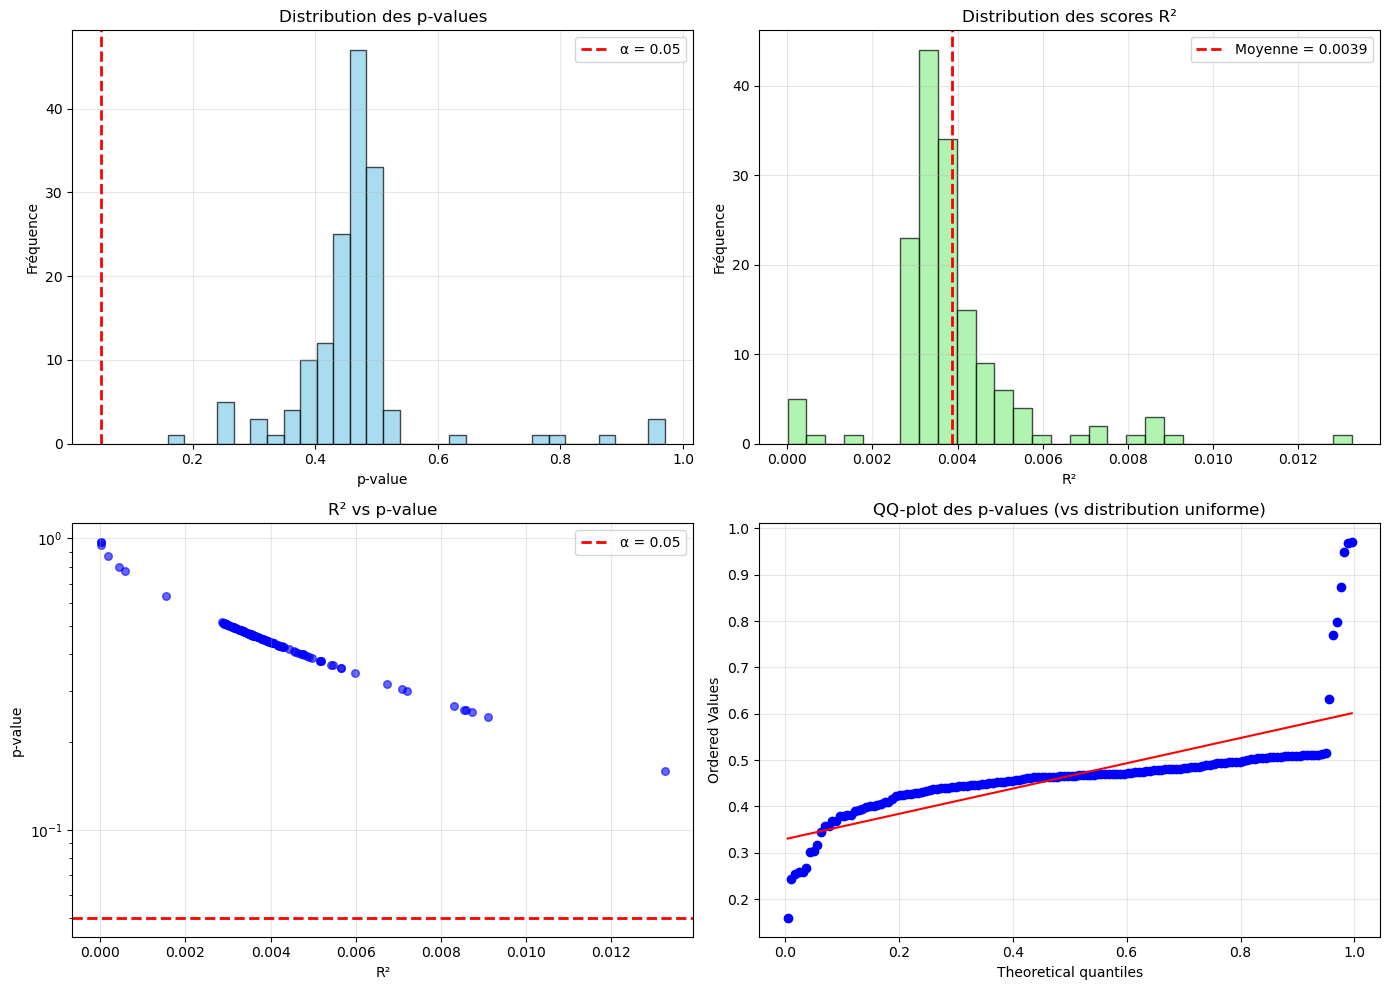


TAILLE DE L'EFFET (EFFECT SIZE)

 Cohen's d: 2.4304
   Interprétation: Fort

 Puissance statistique approximative: 0.0000
   (Probabilité de détecter un effet s'il existe réellement)

  Avec correction de Bonferroni (α = 0.000329):
   - Nombre de protéines significatives: 0/152
   - Aucune protéine ne passe le seuil corrigé


In [32]:


# 1. Analyse détaillée
stats_detail = analyser_significativite_detaille(matrice, codes, scores_r2, p_values)

# 2. Visualisation
visualiser_significativite_detaillee(scores_r2, p_values, codes)

# 3. Taille de l'effet
cohen_d, power = calculer_taille_effet(scores_r2)

# 4. Test de significativité avec correction de Bonferroni
alpha_corrige = 0.05 / len(codes)
n_significatifs_bonf = sum(p_values < alpha_corrige)

print(f"\n  Avec correction de Bonferroni (α = {alpha_corrige:.6f}):")
print(f"   - Nombre de protéines significatives: {n_significatifs_bonf}/{len(codes)}")
print(f"   - Aucune protéine ne passe le seuil corrigé")





### 7. Matrice réorganisée

L'ordre des protéines est réorganisé par $R^2$ décroissant :

$$\text{indices}_{\text{triés}} = \text{scores de RSMD correspondants }(R^2) \quad \text{(triés par ordre décroissant)}$$

La matrice réorganisée s'écrit :

$$W_{\text{reorder}} = P \cdot W \cdot P^T$$

Où $P$ est une matrice de permutation définie par :

$$ P \in M_(n,n)(IR) tq : P_{k, \text{indices}_{\text{triés}}(k)} = 1$$
$$ P^{-1} = P^T $$

P fait le lien entre les deux vecteurs de position suivants :

Le vecteur position initial a = $(R^2_1, R^2_2, \dots, R^2_n)$ le vecteur des scores de similarité obtenus par régression linéaire aux moindres carrés (RLMC) pour les $n$ protéines.

Le vecteur **ordonné croissant** b = $(R^2_(1), R^2_(2), \dots, R^2_(n))$  tels que : $R^2_{(1)} \leq R^2_{(2)} \leq \dots \leq R^2_{(n)}$

Ainsi nous avons b = P * a
et $W_{\text{reorder}} = P \cdot W \cdot P^T$


---

In [33]:
def obtenir_matrice_passage(matrice, codes):
    
    n = len(matrice)
    
    # 1. Calculer les scores RLMC (R²)
  
    print(f" Nombre de protéines: {n}\n")
    
    scores_r2 = np.zeros(n)
    
    for i in range(n):
        y = [matrice[i, j] for j in range(n) if j != i]
        x = [j for j in range(n) if j != i]
        
        if len(y) > 2:
            _, _, r_value, _, _ = stats.linregress(x, y)
            scores_r2[i] = r_value ** 2
    
    # 2. Obtenir l'ordre des indices triés par R² décroissant

    indices_tries = np.argsort(scores_r2)[::-1]
    
    # 3. Ordre original et ordre RLMC

    ordre_original = codes.copy()
    ordre_rlmc = [codes[i] for i in indices_tries]
    scores_tries = scores_r2[indices_tries]
    
    # 4. Créer la matrice de permutation P

    # P est une matrice binaire où P[i, j] = 1 si la protéine j dans l'ordre original
    # devient la protéine i dans l'ordre RLMC
    P = np.zeros((n, n))
    for nouvelle_pos, ancienne_pos in enumerate(indices_tries):
        P[nouvelle_pos, ancienne_pos] = 1
    
    # 5. Indices pour la correspondance
    
    indices_original = list(range(n))
    indices_reordonnes = indices_tries.tolist()
    
    return {
        'P': P,
        'indices_original': indices_original,
        'indices_reordonnes': indices_reordonnes,
        'ordre_original': ordre_original,
        'ordre_rlmc': ordre_rlmc,
        'scores_r2': scores_r2,
        'scores_tries': scores_tries,
        'n': n
    }



In [34]:


def visualiser_matrice_passage(resultats):
    
    P = resultats['P']
    n = resultats['n']
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # 1. Heatmap de la matrice P
    im = axes[0].imshow(P, cmap='Blues', aspect='auto', interpolation='nearest')
    axes[0].set_title(f'Matrice de permutation P ({n} x {n})', fontsize=12)
    axes[0].set_xlabel('Position dans l\'ordre original', fontsize=10)
    axes[0].set_ylabel('Position dans l\'ordre RLMC', fontsize=10)
    plt.colorbar(im, ax=axes[0], label='Valeur')
    
    # Ajouter les lignes de repère
    axes[0].axhline(y=0.5, color='red', linestyle='-', linewidth=0.5)
    axes[0].axvline(x=0.5, color='red', linestyle='-', linewidth=0.5)
    
    # 2. Graphe des correspondances
    indices_original = resultats['indices_original']
    indices_reordonnes = resultats['indices_reordonnes']
    
    axes[1].scatter(indices_original, indices_reordonnes, alpha=0.6, s=20, c='blue')
    axes[1].plot([0, n-1], [0, n-1], 'r--', alpha=0.5, label='diagonale (identité)')
    axes[1].set_xlabel('Position dans l\'ordre original', fontsize=10)
    axes[1].set_ylabel('Position dans l\'ordre RLMC', fontsize=10)
    axes[1].set_title('Correspondance des positions', fontsize=12)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [35]:
def appliquer_matrice_passage(matrice, resultats):
   
    P = resultats['P']
    W = matrice
    
    # Réorganiser la matrice
    W_reorder = P @ W @ P.T
    
    
    print(f"\n Vérification de la relation: W_reorder = P × W × P^T")
    print(f"   - Matrice originale W: {W.shape}")
    print(f"   - Matrice de permutation P: {P.shape}")
    print(f"   - Matrice réorganisée: {W_reorder.shape}")
    
    # Vérifier la symétrie
    est_symetrique = np.allclose(W_reorder, W_reorder.T)
    print(f"\n    Matrice réorganisée symétrique: {est_symetrique}")
    
    # Vérifier les éléments
    print(f"   - Diagonale nulle: {np.allclose(np.diag(W_reorder), 0)}")
    print(f"   - Valeur min: {W_reorder.min():.4f}")
    print(f"   - Valeur max: {W_reorder.max():.4f}")
    
    return W_reorder

In [36]:
def creer_vecteur_passage(resultats):
    """
    Crée un vecteur de passage qui indique pour chaque position
    dans l'ordre RLMC, quelle était sa position dans l'ordre original.
    """
    
    indices_reordonnes = resultats['indices_reordonnes']
    ordre_original = resultats['ordre_original']
    ordre_rlmc = resultats['ordre_rlmc']
    
    # Vecteur de passage: pour chaque nouvelle position, l'ancienne position
    vecteur_passage = np.array(indices_reordonnes)
    
    # Dictionnaire de correspondance
    correspondance = {}
    for nouvelle_pos, ancienne_pos in enumerate(indices_reordonnes):
        correspondance[ordre_rlmc[nouvelle_pos]] = {
            'ancienne_position': ancienne_pos,
            'ancien_code': ordre_original[ancienne_pos],
            'score_RLMC': resultats['scores_tries'][nouvelle_pos]
        }
    
    print("\n" + "=" * 70)
    print("VECTEUR DE PASSAGE")
    print("=" * 70)
    print(f"\n Vecteur de passage (taille {len(vecteur_passage)}):")
    print(f"   Pour i de 0 à {len(vecteur_passage)-1},")
    print(f"   la protéine à la position i dans l'ordre RLMC")
    print(f"   était à la position vecteur_passage[i] dans l'ordre original.\n")
    
    print(f"vecteur_passage = {vecteur_passage[:20]}")
    if len(vecteur_passage) > 20:
        print(f"                ... (et {len(vecteur_passage) - 20} valeurs supplémentaires)")
    
    return vecteur_passage, correspondance


 Nombre de protéines: 152



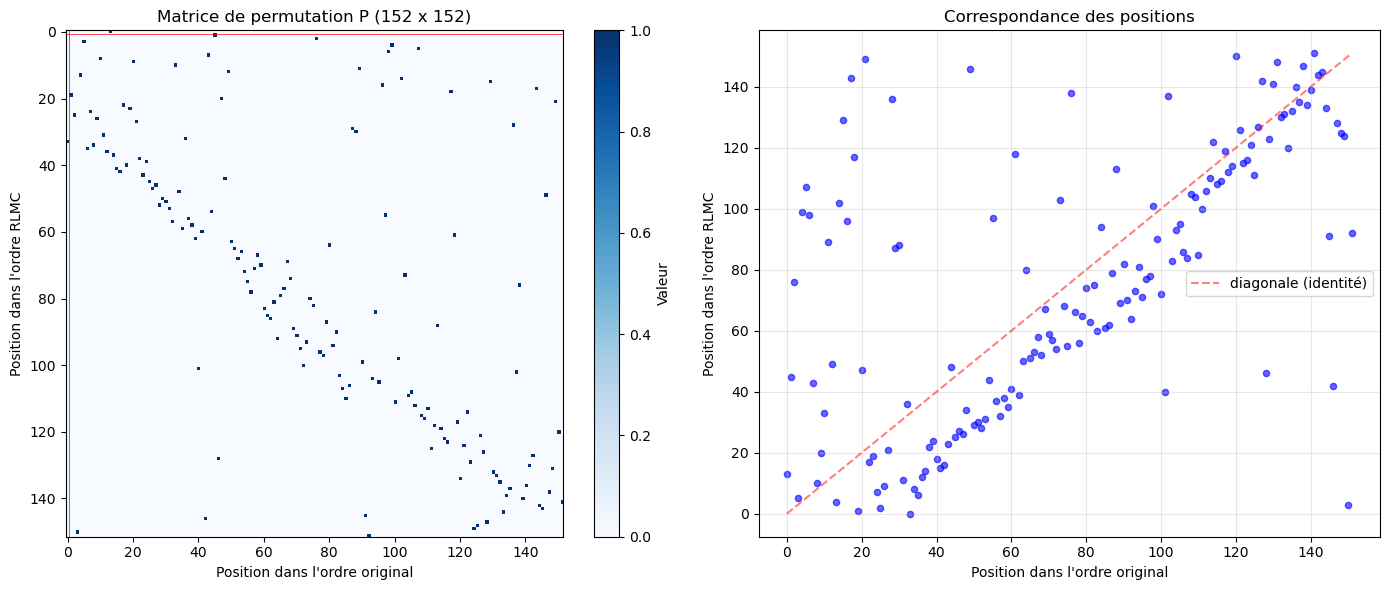


 Vérification de la relation: W_reorder = P × W × P^T
   - Matrice originale W: (152, 152)
   - Matrice de permutation P: (152, 152)
   - Matrice réorganisée: (152, 152)

    Matrice réorganisée symétrique: True
   - Diagonale nulle: True
   - Valeur min: 0.0000
   - Valeur max: 578.5288

VECTEUR DE PASSAGE

 Vecteur de passage (taille 152):
   Pour i de 0 à 151,
   la protéine à la position i dans l'ordre RLMC
   était à la position vecteur_passage[i] dans l'ordre original.

vecteur_passage = [ 13  45  76   5  99 107  98  43  10  20  33  89  49   4 102 129  96 143
 117   1]
                ... (et 132 valeurs supplémentaires)

RÉSUMÉ FINAL

 RÉSULTATS DE LA MATRICE DE PASSAGE:

• Matrice P (permutation): (152, 152)
• Vecteur de passage (taille 152)
• Correspondance sauvegardée dans 'correspondance_ordre_rlmc.csv'

 Relation mathématique:
   W_reorder = P × W × P^T

   où:
   - W = matrice des distances originale (ordre des codes)
   - P = matrice de permutation (obtenue par RLMC)
   

In [37]:


#  Obtenir la matrice de passage
resultats = obtenir_matrice_passage(matrice, codes)

#  Visualiser la matrice de passage
visualiser_matrice_passage(resultats)

#  Appliquer la matrice de passage pour réorganiser la matrice
W_reorder = appliquer_matrice_passage(matrice, resultats)

#  Créer le vecteur de passage
vecteur_passage, correspondance = creer_vecteur_passage(resultats)

#  Sauvegarder les résultats
np.save('matrice_permutation_P.npy', resultats['P'])
np.save('vecteur_passage.npy', vecteur_passage)

# Sauvegarder la correspondance en CSV
df_correspondance = pd.DataFrame([
    {
        'Position_RLMC': i,
        'Code_RLMC': resultats['ordre_rlmc'][i],
        'Position_Originale': resultats['indices_reordonnes'][i],
        'Code_Original': resultats['ordre_original'][resultats['indices_reordonnes'][i]],
        'Score_R2': resultats['scores_tries'][i]
    }
    for i in range(resultats['n'])
])
df_correspondance.to_csv('correspondance_ordre_rlmc.csv', index=False)

print("\n" + "=" * 70)
print("RÉSUMÉ FINAL")
print("=" * 70)
print(f"""
 RÉSULTATS DE LA MATRICE DE PASSAGE:

• Matrice P (permutation): {resultats['P'].shape}
• Vecteur de passage (taille {len(vecteur_passage)})
• Correspondance sauvegardée dans 'correspondance_ordre_rlmc.csv'

 Relation mathématique:
   W_reorder = P × W × P^T

   où:
   - W = matrice des distances originale (ordre des codes)
   - P = matrice de permutation (obtenue par RLMC)
   - W_reorder = matrice réorganisée par R² décroissant

 Top 5 des meilleurs R² (protéines les plus similaires):
""")

for i in range(min(5, resultats['n'])):
    print(f"   {i+1}. {resultats['ordre_rlmc'][i]}: R² = {resultats['scores_tries'][i]:.4f}")

print(f"\n Bottom 5 des plus mauvais R² (protéines les plus différentes):")
for i in range(min(5, resultats['n'])):
    idx = -(i+1)
    print(f"   {i+1}. {resultats['ordre_rlmc'][idx]}: R² = {resultats['scores_tries'][idx]:.4f}")

print("\n Matrice de passage créée avec succès !")



###  Matrice de permutation P

La matrice de permutation $P$ est une matrice binaire $n \times n$ définie par :

$$P_{i,j} = \begin{cases}
1 & \text{si la protéine à la position } j \text{ dans l'ordre original} \\
    & \text{devient la protéine à la position } i \text{ dans l'ordre RLMC} \\
0 & \text{sinon}
\end{cases}$$

**Propriétés fondamentales :**

- $P$ est une matrice **orthogonale** : $P^{-1} = P^T$
- $P$ est une matrice **stochastique** : $\sum_j P_{i,j} = 1$ et $\sum_i P_{i,j} = 1$
- $P$ est une matrice **unimodulaire** : $\det(P) = \pm 1$

---

###  Réorganisation de la matrice

La matrice des distances réorganisée $W_{\text{reorder}}$ s'obtient par :

$$W_{\text{reorder}} = P \cdot W \cdot P^T$$

**Démonstration :**

Soit $W$ la matrice originale avec $W_{i,j} = w(c_i, c_j)$.

Après permutation, la nouvelle matrice $W_{\text{reorder}}$ vérifie :

$$W_{\text{reorder}}[i,j] = w(c_{\sigma(i)}, c_{\sigma(j)}) = \sum_{k=1}^n \sum_{l=1}^n P_{i,k} W_{k,l} P_{j,l} = (P W P^T)_{i,j}$$

###  Propriétés conservées

La transformation $W \to P W P^T$ conserve (changement de base simple) :

- La **symétrie** : $(P W P^T)^T = P W^T P^T = P W P^T$
- La **trace** : $\text{Tr}(P W P^T) = \text{Tr}(W P^T P) = \text{Tr}(W)$
- Le **spectre** (valeurs propres) : $\text{Spéc}(P W P^T) = \text{Spéc}(W)$

---

##  Vecteur de passage

Le **vecteur de passage** $v$ est un vecteur de taille $n$ défini par :

$$v[i] = \text{indices}_{\text{tri}}[i]$$

Il indique pour chaque position $i$ dans l'ordre RLMC, la position qu'occupait cette protéine dans l'ordre original.

###  Relation d'équivalence

$$\text{ordre\_RLMC}[i] = \text{ordre\_original}[v[i]]$$


### Indice de réorganisation

On peut définir un **indice de réorganisation** :

$$\rho = 1 - \frac{2}{n(n-1)} \sum_{i<j} \mathbf{1}_{\text{sign}(v[i] - v[j]) = \text{sign}(i - j)}$$

Où $\rho = 1$ signifie réorganisation totale, $\rho = 0$ signifie ordre identique.

---

## Applications

### Classification des protéines

Les protéines avec les **meilleurs scores $R^2$** (en début de la matrice réorganisée) sont celles qui :

- Ont une structure **représentative** de l'ensemble
- Présentent une **faible variance** dans leurs distances
- Peuvent servir de **prototypes** pour la classification

### Détection d'outliers

Les protéines avec les **plus faibles scores $R^2$** (en fin de matrice) sont potentiellement :

- Des **outliers** structuraux
- Des protéines avec des **propriétés uniques**
- Des candidats pour une **analyse approfondie**

### Visualisation des blocs

La matrice réorganisée $W_{\text{reorder}}$ présente une structure par **blocs diagonaux** :

$$W_{\text{reorder}} = \begin{pmatrix}
\boxed{B_{11}} & B_{12} & \cdots & B_{1k} \\
B_{21} & \boxed{B_{22}} & \cdots & B_{2k} \\
\vdots & \vdots & \ddots & \vdots \\
B_{k1} & B_{k2} & \cdots & \boxed{B_{kk}}
\end{pmatrix}$$

Où les blocs diagonaux $B_{ii}$ contiennent des protéines **similaires entre elles**.

---


In [38]:
def calculer_matrice_permutation(matrice, codes):

    n = len(matrice)
    
    # Calculer les scores R² pour chaque protéine
    scores_r2 = np.zeros(n)
    for i in range(n):
        y = [matrice[i, j] for j in range(n) if j != i]
        x = [j for j in range(n) if j != i]
        if len(y) > 2:
            _, _, r_value, _, _ = stats.linregress(x, y)
            scores_r2[i] = r_value ** 2
    
    # Obtenir l'ordre des indices triés par R² décroissant
    indices_tries = np.argsort(scores_r2)[::-1]
    
    # Construire la matrice de permutation P
    P = np.zeros((n, n))
    for nouvelle_pos, ancienne_pos in enumerate(indices_tries):
        P[nouvelle_pos, ancienne_pos] = 1
    
    return P, indices_tries, scores_r2

In [39]:

# Calculer la matrice de permutation
P, indices_tries, scores_r2 = calculer_matrice_permutation(matrice, codes)

# Appliquer la permutation: W_reorder = P * W * P^T
W_reorder = P @ matrice @ P.T

# Obtenir les codes dans le nouvel ordre
codes_reorder = [codes[i] for i in indices_tries]

print(f"\n Matrice originale: {matrice.shape}")
print(f" Matrice de permutation P: {P.shape}")
print(f" Matrice réorganisée: {W_reorder.shape}")
print(f" {len(codes_reorder)} codes réorganisés")

# Vérifier que la matrice réorganisée est correcte
print(f"\n Vérification:")
print(f"   - Matrice symétrique: {np.allclose(W_reorder, W_reorder.T)}")
print(f"   - Diagonale nulle: {np.allclose(np.diag(W_reorder), 0)}")
print(f"   - Première protéine (meilleur R²): {codes_reorder[0]} (R² = {scores_r2[indices_tries[0]]:.6f})")
print(f"   - Dernière protéine (pire R²): {codes_reorder[-1]} (R² = {scores_r2[indices_tries[-1]]:.6f})")


 Matrice originale: (152, 152)
 Matrice de permutation P: (152, 152)
 Matrice réorganisée: (152, 152)
 152 codes réorganisés

 Vérification:
   - Matrice symétrique: True
   - Diagonale nulle: True
   - Première protéine (meilleur R²): B3WFV2 (R² = 0.013259)
   - Dernière protéine (pire R²): Q18086 (R² = 0.000009)


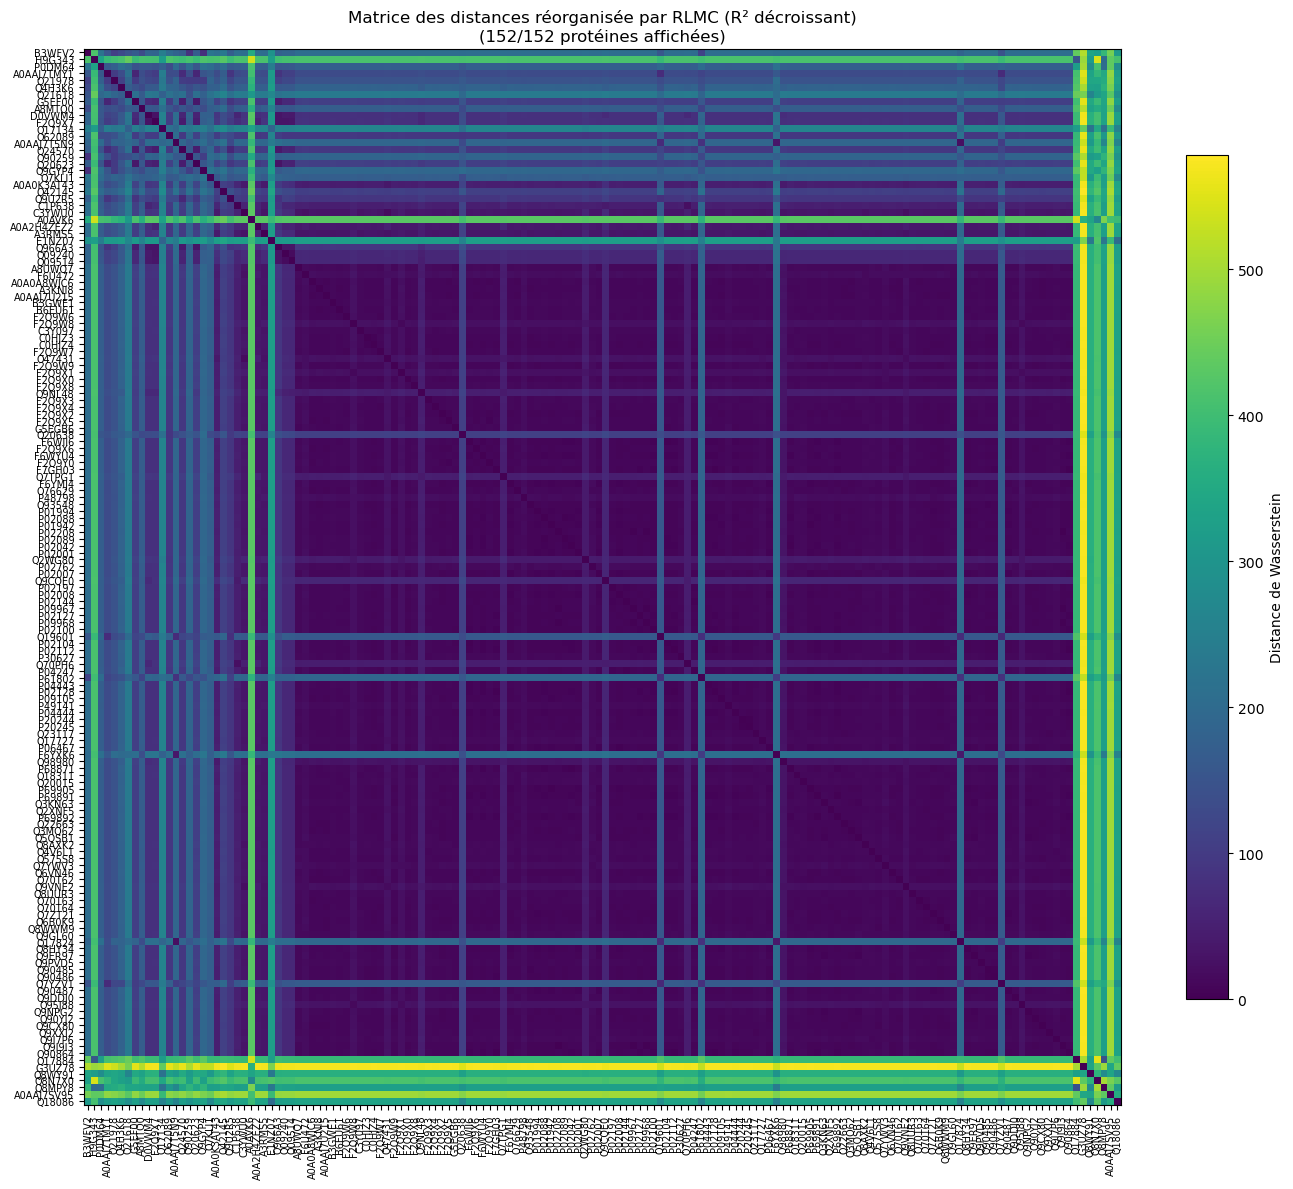


MATRICE DES DISTANCES (152 x 152)

                  B3WFV2      H9G343      P0DM64  A0AAJ7TMY1      Q21978      Q4H3K6
            ------------------------------------------------------------------------
      B3WFV2        0.00      416.50      223.29      156.47      108.57      128.91
      H9G343      416.50        0.00      334.55      389.98      401.89      412.97
      P0DM64      223.29      334.55        0.00      158.70      176.90      210.99
  A0AAJ7TMY1      156.47      389.98      158.70        0.00      103.42      137.62
      Q21978      108.57      401.89      176.90      103.42        0.00      113.25
      Q4H3K6      128.91      412.97      210.99      137.62      113.25        0.00
      Q21618      153.56      440.92      194.93      213.14      189.10      171.36
      G5EF00      169.12      395.47      148.30       60.73       98.01      146.00
      A8MTQ0      133.53      409.55      160.45      137.76      143.64      130.79
      D0VWM4      189.77     

In [40]:

afficher_matrice(W_reorder, codes_reorder, 
                 titre="Matrice des distances réorganisée par RLMC (R² décroissant)",
                 taille_max=30, figsize=(14, 12))

# Afficher un extrait en texte
afficher_matrice_texte(W_reorder, codes_reorder, max_lignes=12, max_colonnes=6)

In [41]:
vecteur_scores_reorder = np.array([scores_r2[i] for i in indices_tries])

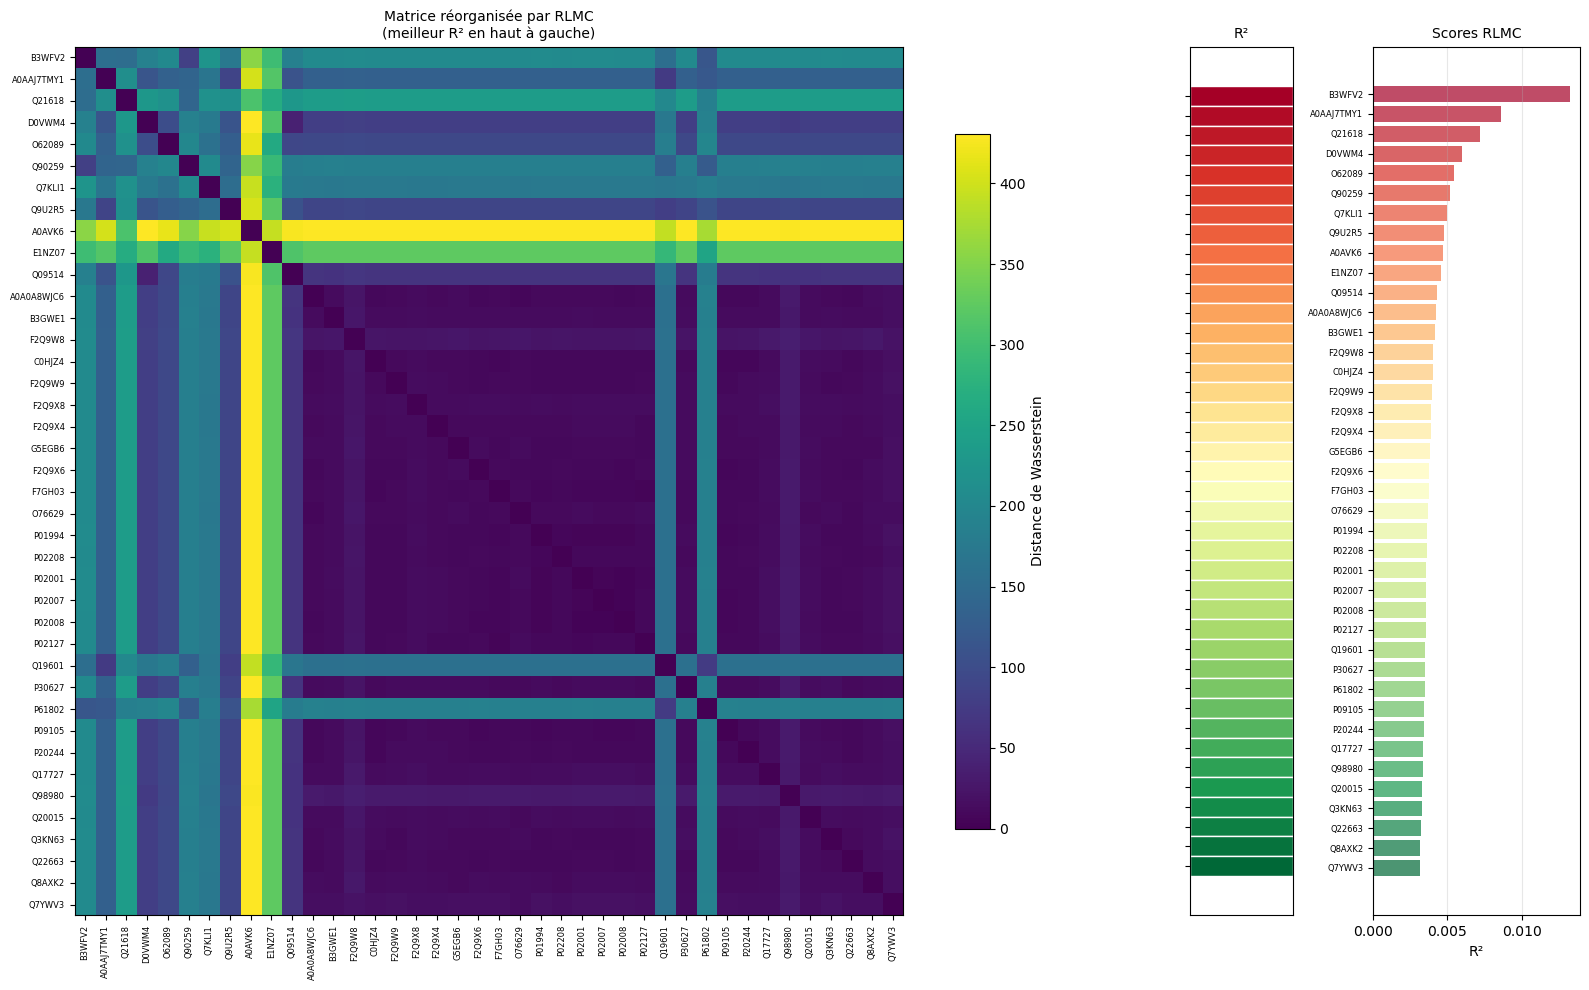

In [42]:


# Créer une visualisation combinée: matrice + scores
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 10),
                                     gridspec_kw={'width_ratios': [10, 1, 2]})

# Sous-échantillonnage pour l'affichage
n_affiche = min(40, len(W_reorder))
step = len(W_reorder) // n_affiche if len(W_reorder) > n_affiche else 1
indices_aff = list(range(0, len(W_reorder), step))[:n_affiche]

W_aff = W_reorder[np.ix_(indices_aff, indices_aff)]
codes_aff = [codes_reorder[i] for i in indices_aff]
scores_aff = [scores_r2[indices_tries[i]] for i in indices_aff]

# 1. Heatmap de la matrice
im = ax1.imshow(W_aff, cmap='viridis', aspect='auto', vmin=0, vmax=np.nanmax(W_aff))
plt.colorbar(im, ax=ax1, shrink=0.8, label='Distance de Wasserstein')

ax1.set_xticks(range(len(codes_aff)))
ax1.set_yticks(range(len(codes_aff)))
labels = [c[:10] + ".." if len(c) > 10 else c for c in codes_aff]
ax1.set_xticklabels(labels, rotation=90, fontsize=6)
ax1.set_yticklabels(labels, fontsize=6)
ax1.set_title(f"Matrice réorganisée par RLMC\n(meilleur R² en haut à gauche)", fontsize=10)

# 2. Barre des scores R² (code couleur)
colors = plt.cm.RdYlGn(np.linspace(0, 1, len(scores_aff)))
ax2.barh(range(len(scores_aff)), [1]*len(scores_aff), color=colors, height=1, edgecolor='white')
ax2.set_xlim(0, 1)
ax2.set_xticks([])
ax2.set_yticks(range(len(scores_aff)))
ax2.set_yticklabels([])
ax2.set_title("R²", fontsize=10)
ax2.invert_yaxis()

# 3. Graphique des scores
ax3.barh(range(len(scores_aff)), scores_aff, color=colors, height=0.8, alpha=0.7)
ax3.set_yticks(range(len(scores_aff)))
ax3.set_yticklabels(labels, fontsize=6)
ax3.set_xlabel('R²', fontsize=10)
ax3.set_title('Scores RLMC', fontsize=10)
ax3.invert_yaxis()
ax3.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


# Sauvegarder la matrice réorganisée et le vecteur des scores
np.save('matrice_ordonnee_rlmc.npy', W_reorder)
np.save('vecteur_scores_rlmc.npy', vecteur_scores_reorder)

# Sauvegarder la correspondance
import pandas as pd
df = pd.DataFrame({
    'Position_RLMC': range(1, len(codes_reorder) + 1),
    'Code': codes_reorder,
    'R2_Score': vecteur_scores_reorder,
    'Position_Originale': indices_tries + 1
})
df.to_csv('ordre_rlmc_complet.csv', index=False)



###  Méthode UPGMA (Unweighted Pair Group Method with Arithmetic Mean)

L'UPGMA est la méthode la plus simple et la plus utilisée pour construire un arbre à partir d'une matrice de distances.

#### Algorithme

1. **Initialisation** : Chaque protéine forme un cluster de taille 1
2. **Recherche du minimum** : Trouver la paire $(i,j)$ avec la plus petite distance $d_{ij}$
3. **Fusion** : Grouper $i$ et $j$ dans un nouveau cluster $(ij)$
4. **Mise à jour des distances** : Calculer les distances entre le nouveau cluster et les autres clusters $k$ :

   $$d_{(ij),k} = \frac{d_{i,k} + d_{j,k}}{2}$$

5. **Itération** : Répéter jusqu'à obtenir un unique cluster

###  Formule de mise à jour UPGMA

Pour un cluster $C$ formé par la fusion de $A$ et $B$, la distance à un autre cluster $X$ est :

$$d_{C,X} = \frac{|A| \cdot d_{A,X} + |B| \cdot d_{B,X}}{|A| + |B|}$$

Où $|A|$ et $|B|$ sont les tailles des clusters $A$ et $B$.

---

L'arbre obtenu est **ultramétrique** : la distance entre deux feuilles est la somme des longueurs des branches le long du chemin qui les relie.

Chaque nœud de l'arbre est caractérisé par :

- **Hauteur** : distance à la racine (ou valeur de fusion)
- **Enfants** : les deux sous-arbres fusionnés
- **Feuilles** : les protéines individuelles

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from anytree import Node, RenderTree
import pandas as pd


In [44]:
def matrice_triee_vers_arbre(matrice_triee, codes, methode='average', 
                             titre="Arbre phylogénétique",
                             figsize=(14, 8), afficher=True):
    
    n = len(matrice_triee)
    
    # 1. Convertir la matrice en vecteur de distances condensé
    condensed = squareform(matrice_triee, checks=True)
    
    print(f" Construction de l'arbre pour {n} protéines")
    print(f"   Méthode: {methode}")
    
    # 2. Appliquer le clustering hiérarchique
    Z = linkage(condensed, method=methode)
    
    # 3. Afficher le dendrogramme
    if afficher:
        plt.figure(figsize=figsize)
        dendro = dendrogram(Z, labels=codes, leaf_rotation=90, leaf_font_size=8,
                           orientation='top', color_threshold=0)
        plt.title(f"{titre}\n(méthode: {methode})", fontsize=14)
        plt.xlabel('Protéines', fontsize=12)
        plt.ylabel('Distance', fontsize=12)
        plt.tight_layout()
        plt.show()
    else:
        dendro = None
    
    return Z, dendro

In [45]:
def linkage_to_anytree(Z, codes):
    
    n = len(codes)
    
    # Créer les nœuds feuilles
    nodes = {i: Node(codes[i]) for i in range(n)}
    
    # Stocker les distances dans un dictionnaire séparé
    distances = {}
    tailles = {}
    
    next_id = n
    
    for i, (left, right, dist, size) in enumerate(Z):
        left, right = int(left), int(right)
        
        # Nom du nœud interne
        nom_interne = f"interne_{next_id}"
        
        # Créer le nœud parent
        parent = Node(nom_interne)
        
        # Attacher les enfants
        nodes[left].parent = parent
        nodes[right].parent = parent
        
        # Stocker les métadonnées dans des dictionnaires séparés
        distances[parent] = dist
        tailles[parent] = int(size)
        
        nodes[next_id] = parent
        next_id += 1
    
    # La racine est le dernier nœud créé
    racine = nodes[next_id - 1]
    
    return racine, nodes, distances, tailles

In [46]:
def afficher_arbre(racine, distances=None, max_levels=None):
    
    for pre, fill, node in RenderTree(racine):
        level = node.depth
        
        if max_levels is None or level <= max_levels:
            # Afficher la distance si disponible
            if distances and node in distances and distances[node] > 0 and not node.is_leaf:
                print(f"{pre}{node.name} (d={distances[node]:.4f})")
            else:
                print(f"{pre}{node.name}")
        elif level == max_levels + 1:
            leaf_count = sum(1 for _ in node.leaves)
            print(f"{pre}└── [{leaf_count} protéines]")
            break
    
    # Statistiques
    print("\n" + "=" * 70)
    print("STATISTIQUES DE L'ARBRE")
    print("=" * 70)
    print(f"   - Nombre de feuilles: {len(list(racine.leaves))}")
    print(f"   - Nombre de nœuds internes: {len(list(racine.descendants)) - len(list(racine.leaves))}")
    print(f"   - Hauteur de l'arbre: {racine.height}")
    print(f"   - Profondeur maximale: {max(node.depth for node in racine.descendants) if racine.descendants else 0}")


In [47]:
def get_chemin_phylo(racine, code):
    
    # Trouver la feuille
    feuille = None
    for node in racine.leaves:
        if node.name == code:
            feuille = node
            break
    
    if feuille is None:
        return None
    
    # Remonter jusqu'à la racine
    chemin = []
    current = feuille
    while current:
        chemin.append(current.name)
        current = current.parent
    
    return list(reversed(chemin))

In [48]:

def sauvegarder_arbre(racine, distances=None, filename="arbre_phylo.txt"):

    with open(filename, 'w', encoding='utf-8') as f:
        for pre, fill, node in RenderTree(racine):
            if distances and node in distances and distances[node] > 0 and not node.is_leaf:
                f.write(f"{pre}{node.name} (d={distances[node]:.4f})\n")
            else:
                f.write(f"{pre}{node.name}\n")
    
    print(f" Arbre sauvegardé dans '{filename}'")

In [49]:
def construire_arbre_depuis_matrice_triee(matrice_triee, codes_tries, 
                                           methode='average', 
                                           afficher_dendro=True,
                                           afficher_arbre_texte=True):
    
    Z, dendro = matrice_triee_vers_arbre(
        matrice_triee, codes_tries, 
        methode=methode, 
        titre="Arbre RLMC des protéines",
        afficher=afficher_dendro
    )
    
    # 2. Convertir en arbre anytree
    racine, nodes, distances, tailles = linkage_to_anytree(Z, codes_tries)
    
    # 3. Afficher l'arbre en texte
    if afficher_arbre_texte:
        afficher_arbre(racine, distances, max_levels=4)
    
    return Z, racine, distances

 Construction de l'arbre pour 152 protéines
   Méthode: average


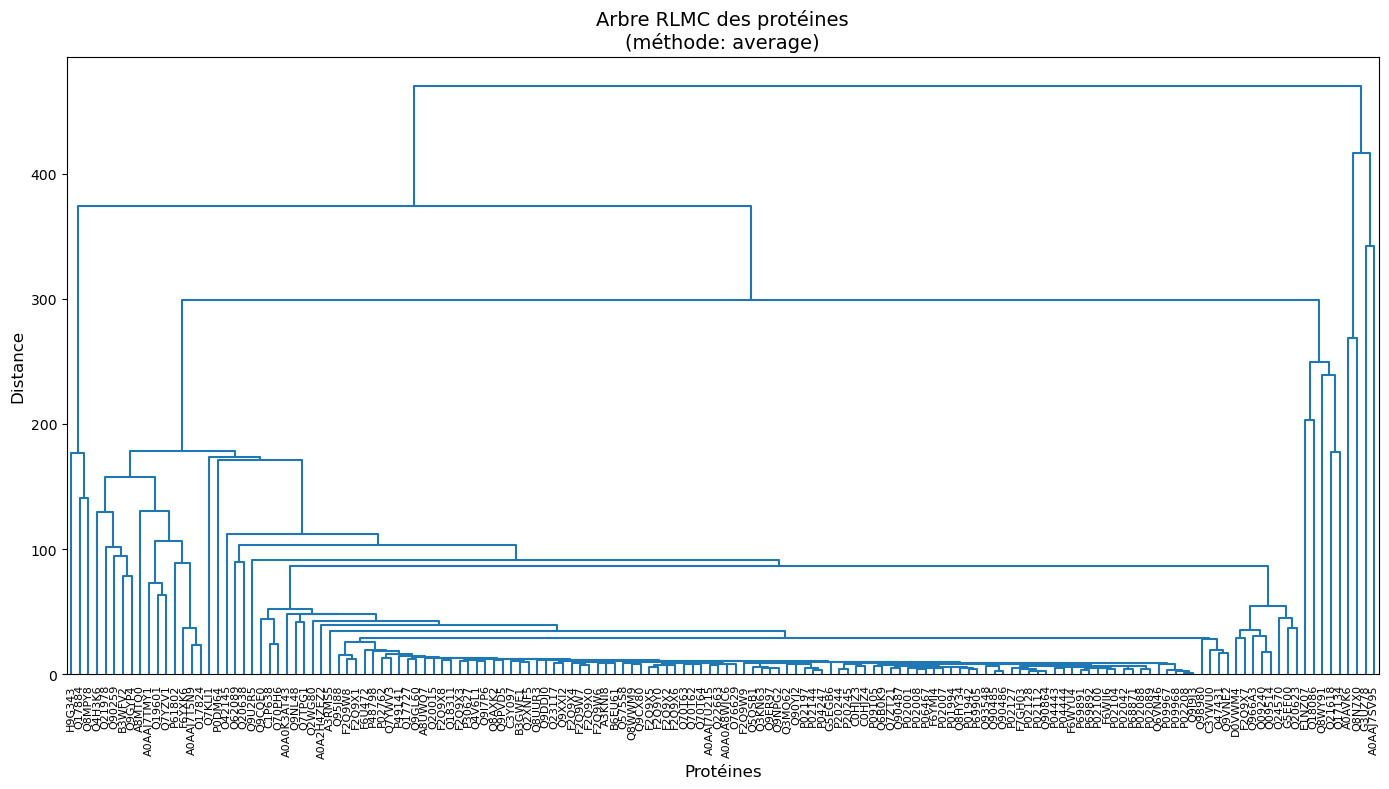

interne_302 (d=470.0177)
├── interne_300 (d=374.1355)
│   ├── interne_291 (d=176.5065)
│   │   ├── H9G343
│   │   └── interne_287 (d=141.0909)
│   │       ├── Q17884
│   │       └── Q8MPY8
│   └── interne_298 (d=298.8005)
│       ├── interne_293 (d=178.4333)
│       │   ├── interne_288 (d=157.9983)
│       │   │   ├── └── [5 protéines]

STATISTIQUES DE L'ARBRE
   - Nombre de feuilles: 152
   - Nombre de nœuds internes: 150
   - Hauteur de l'arbre: 46
   - Profondeur maximale: 46
 Arbre sauvegardé dans 'arbre_rlmc.txt'


In [50]:

Z, racine, distances = construire_arbre_depuis_matrice_triee(
    matrice_triee=W_reorder,
    codes_tries=codes_reorder,
    methode='average',  # UPGMA
    afficher_dendro=True,
    afficher_arbre_texte=True
)

# Sauvegarder l'arbre
sauvegarder_arbre(racine, distances, "arbre_rlmc.txt")

# Sauvegarder la matrice de linkage
np.savetxt('matrice_linkage.csv', Z, delimiter=',', 
           header='left,right,distance,size', comments='')



In [51]:
import numpy as np
import matplotlib.pyplot as plt
from anytree import Node, RenderTree, PreOrderIter
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
import pandas as pd


In [52]:
def extraire_code_depuis_nom_fichier(nom_fichier):
    
    # Extrait le code proteique depuis un nom de fichier PDB.
    # Exemple: "AF-Q17134-F1-model_v6.pdb" -> "Q17134"
    
    match = re.search(r'AF-([A-Z0-9]+)-', nom_fichier)
    if match:
        return match.group(1)
    return nom_fichier


In [53]:
def renommer_feuilles_arbre_reference(racine):
    
    for node in PreOrderIter(racine):
        if node.is_leaf:
            nouveau_nom = extraire_code_depuis_nom_fichier(node.name)
            node.name = nouveau_nom
    return racine


In [54]:
def texte_vers_anytree(texte_arbre):
    """Convertit une représentation textuelle d'arbre en objet anytree."""
    lignes = texte_arbre.strip().split('\n')
    lignes = [l.rstrip(')').strip() for l in lignes if l.strip()]
    
    racine = None
    pile = []
    
    for ligne in lignes:
        prefix = ligne[:ligne.find('├')] if '├' in ligne else \
                 ligne[:ligne.find('└')] if '└' in ligne else \
                 ligne[:ligne.find('│')] if '│' in ligne else ''
        
        niveau = prefix.count('│') + (prefix.count(' ') // 3)
        
        nom = ligne
        for sep in ['├── ', '└── ', '│   ']:
            if sep in ligne:
                nom = ligne.split(sep)[-1]
                break
        
        nom = nom.strip()
        
        node = Node(nom)
        
        if racine is None:
            racine = node
            pile = [(node, niveau)]
        else:
            while pile and pile[-1][1] >= niveau:
                pile.pop()
            
            if pile:
                parent = pile[-1][0]
                node.parent = parent
            else:
                node.parent = racine
            
            pile.append((node, niveau))
    
    return racine

In [55]:
def extraire_feuilles_et_chemins(racine):
   
    feuilles = []
    chemins = {}
    profondeurs = {}
    
    for node in PreOrderIter(racine):
        if node.is_leaf:
            feuilles.append(node.name)
            # Construire le chemin depuis la racine
            chemin = []
            current = node
            while current:
                chemin.append(current.name)
                current = current.parent
            chemins[node.name] = list(reversed(chemin))
            profondeurs[node.name] = node.depth
    
    return feuilles, chemins, profondeurs

In [56]:

def calculer_distances_cophenetiques(racine):
   
    feuilles = list(racine.leaves)
    n = len(feuilles)
    indices = {feuille.name: i for i, feuille in enumerate(feuilles)}
    
    distances = np.zeros((n, n))
    
    for i, f1 in enumerate(feuilles):
        for j, f2 in enumerate(feuilles):
            if i <= j:
                continue
            # Trouver l'ancêtre commun
            ancetres1 = set()
            node = f1
            while node:
                ancetres1.add(node)
                node = node.parent
            
            node = f2
            while node:
                if node in ancetres1:
                    ancetre = node
                    break
                node = node.parent
            
            # La distance cophenétique est la profondeur de l'ancêtre commun
            dist = ancetre.depth if ancetre else 0
            distances[i, j] = dist
            distances[j, i] = dist
    
    return distances, [f.name for f in feuilles]

In [57]:
def calculer_similarite_arbres(racine_ref, racine_rlmc):
   
    
    # 1. Extraire les feuilles
    feuilles_ref = {f.name for f in racine_ref.leaves}
    feuilles_rlmc = {f.name for f in racine_rlmc.leaves}
    
    # Intersection des feuilles
    feuilles_communes = feuilles_ref & feuilles_rlmc
    print(f" Feuilles communes: {len(feuilles_communes)}")
    
    # 2. Matrices cophenétiques
    dist_ref, labels_ref = calculer_distances_cophenetiques(racine_ref)
    dist_rlmc, labels_rlmc = calculer_distances_cophenetiques(racine_rlmc)
    
    # 3. Corrélation de Mantel
    from scipy.stats import pearsonr
    
    # Réorganiser pour avoir les mêmes indices
    indices_ref = {label: i for i, label in enumerate(labels_ref)}
    indices_rlmc = {label: i for i, label in enumerate(labels_rlmc)}
    
    feuilles_communes_liste = list(feuilles_communes)
    n_communes = len(feuilles_communes_liste)
    
    vect_ref = []
    vect_rlmc = []
    
    for i in range(n_communes):
        for j in range(i+1, n_communes):
            f1, f2 = feuilles_communes_liste[i], feuilles_communes_liste[j]
            vect_ref.append(dist_ref[indices_ref[f1], indices_ref[f2]])
            vect_rlmc.append(dist_rlmc[indices_rlmc[f1], indices_rlmc[f2]])
    
    if len(vect_ref) > 1:
        cor, p_val = pearsonr(vect_ref, vect_rlmc)
    else:
        cor, p_val = 0, 1
    
    # 4. Comparaison des profondeurs
    _, _, profondeurs_ref = extraire_feuilles_et_chemins(racine_ref)
    _, _, profondeurs_rlmc = extraire_feuilles_et_chemins(racine_rlmc)
    
    differences_profondeur = []
    for feuille in feuilles_communes:
        diff = abs(profondeurs_ref.get(feuille, 0) - profondeurs_rlmc.get(feuille, 0))
        differences_profondeur.append(diff)
    
    diff_moyenne = np.mean(differences_profondeur) if differences_profondeur else 0
    
    # 5. Taux de conservation des relations père-fils
    relations_conservees = 0
    total_relations = 0
    
    for feuille in feuilles_communes:
        # Trouver le parent dans chaque arbre
        node_ref = None
        node_rlmc = None
        
        for n in racine_ref.leaves:
            if n.name == feuille:
                node_ref = n
                break
        
        for n in racine_rlmc.leaves:
            if n.name == feuille:
                node_rlmc = n
                break
        
        if node_ref and node_rlmc:
            parent_ref = node_ref.parent.name if node_ref.parent else None
            parent_rlmc = node_rlmc.parent.name if node_rlmc.parent else None
            total_relations += 1
            if parent_ref == parent_rlmc:
                relations_conservees += 1
    
    taux_conservation = relations_conservees / total_relations if total_relations > 0 else 0
    
    return {
        'correlation_cophenetique': cor,
        'p_value': p_val,
        'difference_profondeur_moyenne': diff_moyenne,
        'taux_conservation_parent': taux_conservation,
        'feuilles_communes': len(feuilles_communes),
        'feuilles_ref': len(feuilles_ref),
        'feuilles_rlmc': len(feuilles_rlmc)
    }



In [58]:
def visualiser_comparaison_arbres(racine_ref, racine_rlmc, max_levels=3):
   
    fig, axes = plt.subplots(1, 2, figsize=(16, 10))
    
    # Arbre de référence
    ax1 = axes[0]
    y_pos = 0
    for pre, fill, node in RenderTree(racine_ref):
        if node.depth <= max_levels:
            ax1.text(0, y_pos, f"{pre}{node.name}", fontsize=8, va='center')
            y_pos += 1
        elif node.depth == max_levels + 1:
            leaf_count = sum(1 for _ in node.leaves)
            ax1.text(0, y_pos, f"{pre}└── [{leaf_count} feuilles]", fontsize=8, va='center')
            y_pos += 1
            break
    
    ax1.set_xlim(-0.5, 1)
    ax1.set_ylim(y_pos, -1)
    ax1.axis('off')
    ax1.set_title("Arbre phylogénétique de référence", fontsize=12)
    
    # Arbre RLMC
    ax2 = axes[1]
    y_pos = 0
    for pre, fill, node in RenderTree(racine_rlmc):
        if node.depth <= max_levels:
            ax2.text(0, y_pos, f"{pre}{node.name}", fontsize=8, va='center')
            y_pos += 1
        elif node.depth == max_levels + 1:
            leaf_count = sum(1 for _ in node.leaves)
            ax2.text(0, y_pos, f"{pre}└── [{leaf_count} feuilles]", fontsize=8, va='center')
            y_pos += 1
            break
    
    ax2.set_xlim(-0.5, 1)
    ax2.set_ylim(y_pos, -1)
    ax2.axis('off')
    ax2.set_title("Arbre RLMC (basé sur la matrice des distances)", fontsize=12)
    
    plt.tight_layout()
    plt.show()

In [59]:
def visualiser_matrices_cophenetiques(dist_ref, labels_ref, dist_rlmc, labels_rlmc):
   
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Matrice cophenétique de référence
    im1 = axes[0].imshow(dist_ref, cmap='viridis', aspect='auto')
    axes[0].set_title("Matrice cophenétique - Arbre de référence")
    axes[0].set_xlabel("Protéines")
    axes[0].set_ylabel("Protéines")
    plt.colorbar(im1, ax=axes[0], label="Distance cophenétique")
    
    # Matrice cophenétique RLMC
    im2 = axes[1].imshow(dist_rlmc, cmap='viridis', aspect='auto')
    axes[1].set_title("Matrice cophenétique - Arbre RLMC")
    axes[1].set_xlabel("Protéines")
    axes[1].set_ylabel("Protéines")
    plt.colorbar(im2, ax=axes[1], label="Distance cophenétique")
    
    plt.tight_layout()
    plt.show()


In [60]:
def comparer_arbres(racine_ref, racine_rlmc, afficher_graphiques=True):
   
    print("=" * 70)
    print("COMPARAISON DES ARBRES PHYLOGÉNÉTIQUES")
    print("=" * 70)
    
    # 1. Extraire les feuilles
    feuilles_ref, chemins_ref, profondeurs_ref = extraire_feuilles_et_chemins(racine_ref)
    feuilles_rlmc, chemins_rlmc, profondeurs_rlmc = extraire_feuilles_et_chemins(racine_rlmc)
    
    print(f"\n Arbre de référence: {len(feuilles_ref)} feuilles")
    print(f" Arbre RLMC: {len(feuilles_rlmc)} feuilles")
    
    # 2. Calculer les similarités
    resultats = calculer_similarite_arbres(racine_ref, racine_rlmc)
    
    
    print(f"\n Corrélation cophenétique (Mantel):")
    print(f"   r = {resultats['correlation_cophenetique']:.4f}")
    print(f"   p-value = {resultats['p_value']:.6f}")
    
    print(f"\n Différence de profondeur moyenne:")
    print(f"   {resultats['difference_profondeur_moyenne']:.4f} niveaux")
    
    print(f"\n Taux de conservation des relations père-fils:")
    print(f"   {resultats['taux_conservation_parent']:.2%}")
    
    print(f"\n Feuilles communes:")
    print(f"   {resultats['feuilles_communes']} / {resultats['feuilles_ref']}")
    
    # 3. Interprétation
    
    if resultats['correlation_cophenetique'] > 0.7:
        print(" Forte similarité entre les deux arbres")
    elif resultats['correlation_cophenetique'] > 0.4:
        print(" Similarité modérée entre les deux arbres")
    else:
        print(" Faible similarité entre les deux arbres")
    
    if resultats['taux_conservation_parent'] > 0.5:
        print(" La plupart des relations évolutives sont conservées")
    else:
        print(" Les relations évolutives diffèrent significativement")
    
    # 4. Visualisations
    if afficher_graphiques:
        visualiser_comparaison_arbres(racine_ref, racine_rlmc)
        
        # Matrices cophenétiques
        dist_ref, labels_ref = calculer_distances_cophenetiques(racine_ref)
        dist_rlmc, labels_rlmc = calculer_distances_cophenetiques(racine_rlmc)
        visualiser_matrices_cophenetiques(dist_ref, labels_ref, dist_rlmc, labels_rlmc)
    
    return resultats

Arbre de référence chargé:
Metazoaire
├── Deuterostomiens
│   └── Chordés
COMPARAISON DES ARBRES PHYLOGÉNÉTIQUES

 Arbre de référence: 158 feuilles
 Arbre RLMC: 152 feuilles
 Feuilles communes: 0

 Corrélation cophenétique (Mantel):
   r = 0.0000
   p-value = 1.000000

 Différence de profondeur moyenne:
   0.0000 niveaux

 Taux de conservation des relations père-fils:
   0.00%

 Feuilles communes:
   0 / 158
 Faible similarité entre les deux arbres
 Les relations évolutives diffèrent significativement


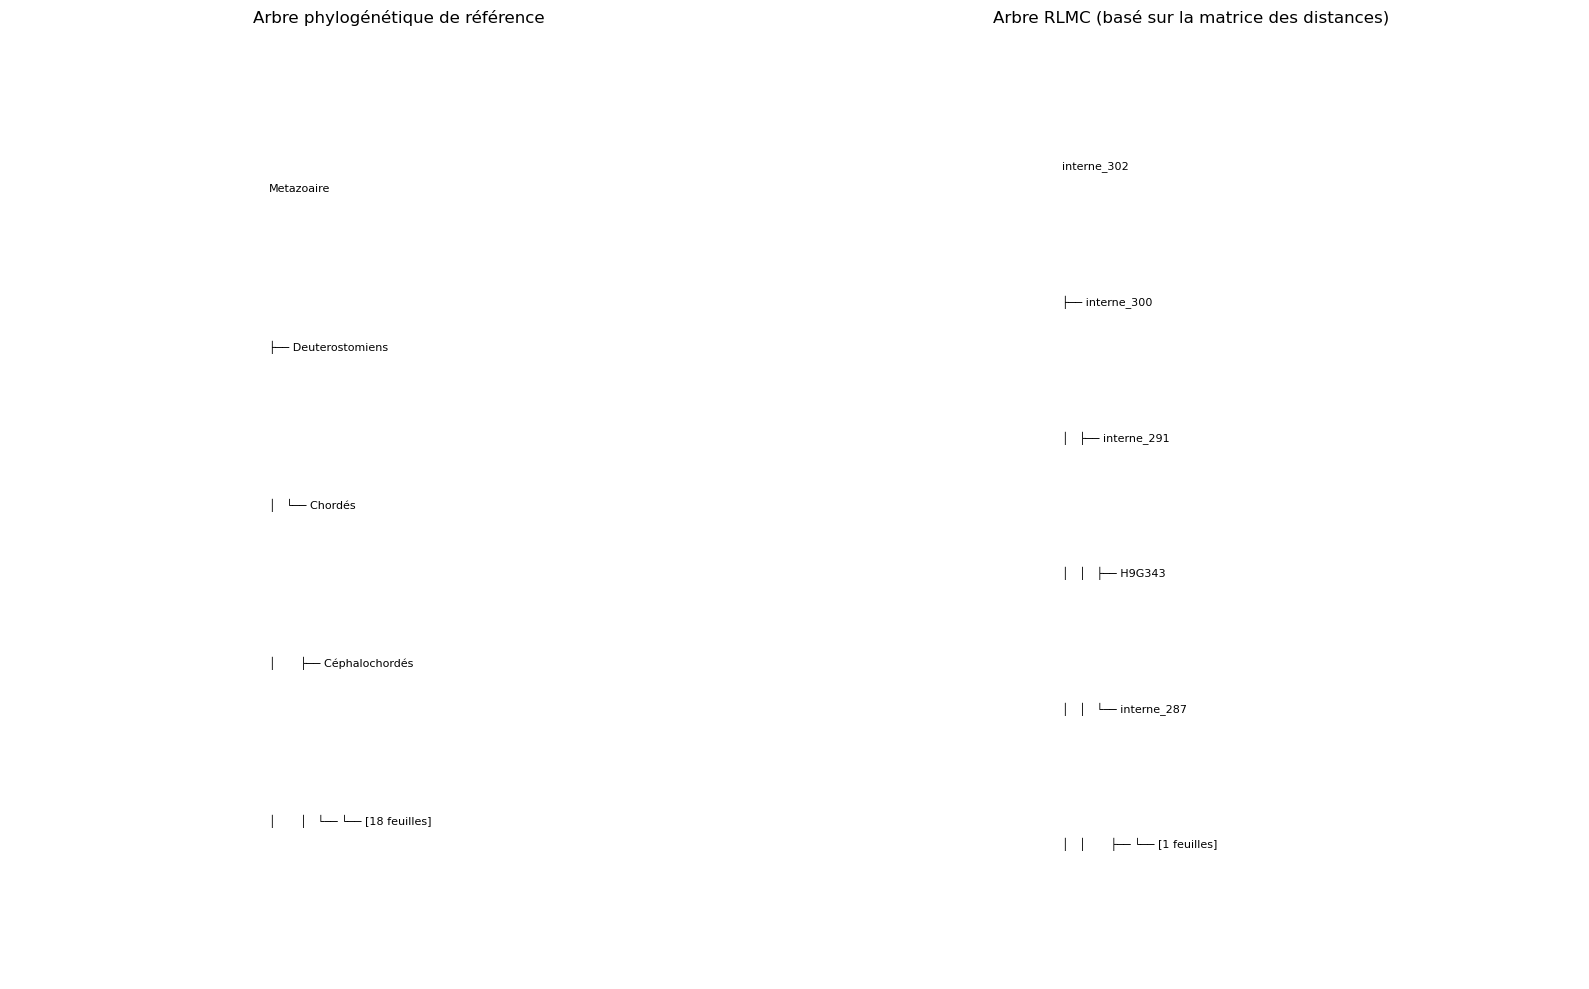

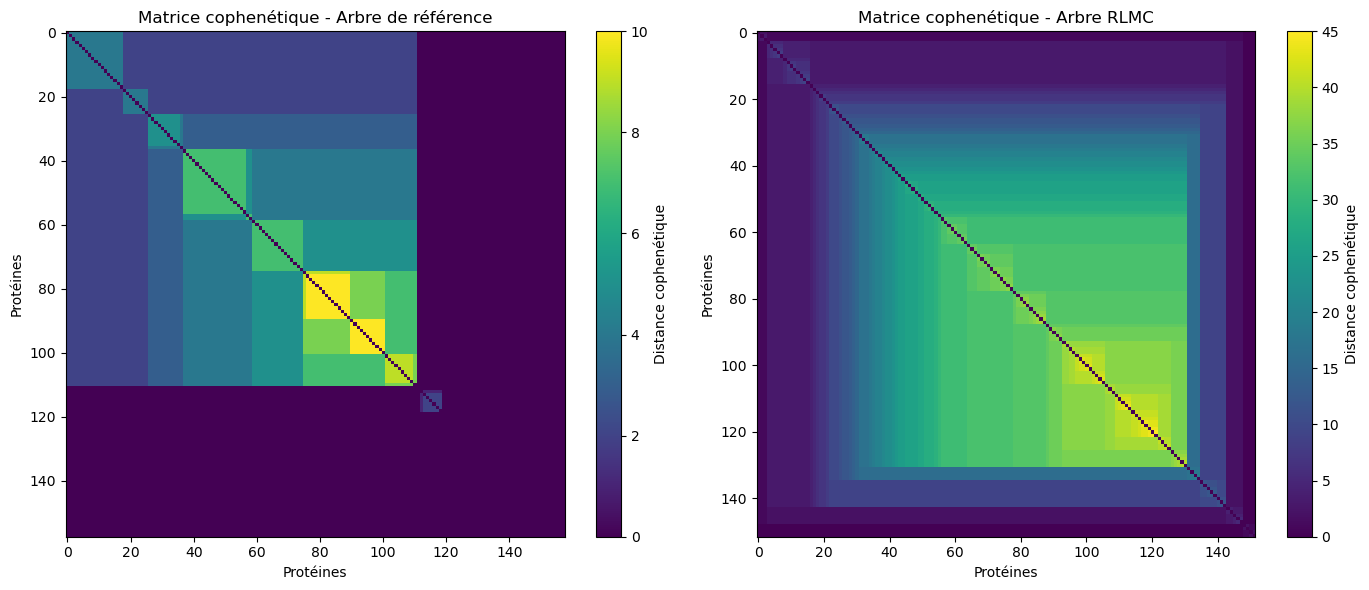


 Résultats sauvegardés dans 'comparaison_arbres.txt'


In [61]:

# Charger l'arbre de référence depuis le texte
arbre_reference = texte_vers_anytree(texte_arbre)

print("Arbre de référence chargé:")
for pre, fill, node in RenderTree(arbre_reference):
    print(f"{pre}{node.name}")
    if node.depth >= 2:
        break

# Charger l'arbre RLMC depuis le fichier sauvegardé
def charger_arbre_depuis_fichier(filename):
    """Charge un arbre sauvegardé au format texte."""
    with open(filename, 'r', encoding='utf-8') as f:
        contenu = f.read()
    return texte_vers_anytree(contenu)

# Comparer les arbres
resultats = comparer_arbres(arbre_reference, racine, afficher_graphiques=True)

# Sauvegarder les résultats
with open('comparaison_arbres.txt', 'w') as f:
    f.write("COMPARAISON ARBRE DE RÉFÉRENCE vs ARBRE RLMC\n")
    f.write("=" * 50 + "\n")
    for key, value in resultats.items():
        f.write(f"{key}: {value}\n")

print("\n Résultats sauvegardés dans 'comparaison_arbres.txt'")

### Différences des matrices cophéniques


$$W_{\text{reorder}} = \begin{pmatrix}
\boxed{B_{11}} & B_{12} & \cdots & B_{1k} \\
B_{21} & \boxed{B_{22}} & \cdots & B_{2k} \\
\vdots & \vdots & \ddots & \vdots \\
B_{k1} & B_{k2} & \cdots & \boxed{B_{kk}}
\end{pmatrix}$$

Où les blocs diagonaux $B_{ii}$ contiennent des protéines **similaires entre elles**.

Ici dans le tri de la matrice des distances par RLMC

On a donc occulté les BLOCS DIAGONAUX

$B_(i,j)$ tq $i$ != $j$

on a alors en comparant une distance de wasserstein $w(i,j)$ à une venant d'une autre colonne  $w(k,l)$ occulté l'information $w(j,k)$ issue du bloc diagonal reliant les protéines en position i à la protéine en position j

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from anytree import Node, RenderTree, PreOrderIter
from scipy.stats import pearsonr
import re


def afficher_comparaison_visuelle(racine_ref, racine_rlmc, max_lignes=800):
    # Affiche les deux arbres cote a cote.
    
    lignes_ref = []
    lignes_rlmc = []
    
    for pre, fill, node in RenderTree(racine_ref):
        if len(lignes_ref) < max_lignes:
            lignes_ref.append(f"{pre}{node.name}")
    
    for pre, fill, node in RenderTree(racine_rlmc):
        if len(lignes_rlmc) < max_lignes:
            lignes_rlmc.append(f"{pre}{node.name}")
    
    print("\n{:<50} | {:<50}".format("Arbre de reference", "Arbre RLMC"))
    print("-" * 101)
    
    max_len = max(len(lignes_ref), len(lignes_rlmc))
    for i in range(max_len):
        ref = lignes_ref[i] if i < len(lignes_ref) else ""
        rlmc = lignes_rlmc[i] if i < len(lignes_rlmc) else ""
        print("{:<50} | {:<50}".format(ref, rlmc))



In [63]:
def extraire_feuilles_et_chemins(racine):
    
    feuilles = []
    for node in PreOrderIter(racine):
        if node.is_leaf:
            feuilles.append(node.name)
    return set(feuilles)


In [64]:

def calculer_similarite_arbres(racine_ref, racine_rlmc):
    
    # Extraire les feuilles
    feuilles_ref = extraire_feuilles_et_chemins(racine_ref)
    feuilles_rlmc = extraire_feuilles_et_chemins(racine_rlmc)
    
    print(f"\nFeuilles arbre de reference: {len(feuilles_ref)}")
    print(f"Feuilles arbre RLMC: {len(feuilles_rlmc)}")
    
    # Trouver les feuilles communes
    feuilles_communes = feuilles_ref & feuilles_rlmc
    print(f"Feuilles communes: {len(feuilles_communes)}")
    
    if len(feuilles_communes) == 0:
        print("\nERREUR: Aucune feuille commune trouvee!")
        print("Verifiez que les codes des proteines correspondent.")
        print("Exemples de feuilles reference:", list(feuilles_ref)[:5])
        print("Exemples de feuilles RLMC:", list(feuilles_rlmc)[:5])
        return {
            'correlation_cophenetique': 0,
            'p_value': 1,
            'feuilles_communes': 0,
            'feuilles_ref': len(feuilles_ref),
            'feuilles_rlmc': len(feuilles_rlmc)
        }
    # Calculer les profondeurs
    profondeurs_ref = {}
    profondeurs_rlmc = {}
    
    for node in PreOrderIter(racine_ref):
        if node.is_leaf:
            profondeurs_ref[node.name] = node.depth
    
    for node in PreOrderIter(racine_rlmc):
        if node.is_leaf:
            profondeurs_rlmc[node.name] = node.depth
    
    # Calculer les differences de profondeur
    differences = []
    for feuille in feuilles_communes:
        diff = abs(profondeurs_ref.get(feuille, 0) - profondeurs_rlmc.get(feuille, 0))
        differences.append(diff)
    
    diff_moyenne = np.mean(differences) if differences else 0
    
    # Calculer le taux de conservation des parents immediats
    parents_ref = {}
    parents_rlmc = {}
    
    for node in PreOrderIter(racine_ref):
        if node.is_leaf and node.parent:
            parents_ref[node.name] = node.parent.name
    
    for node in PreOrderIter(racine_rlmc):
        if node.is_leaf and node.parent:
            parents_rlmc[node.name] = node.parent.name
    
    conservation = 0
    total = 0
    for feuille in feuilles_communes:
        if feuille in parents_ref and feuille in parents_rlmc:
            total += 1
            if parents_ref[feuille] == parents_rlmc[feuille]:
                conservation += 1
    
    taux_conservation = conservation / total if total > 0 else 0
    
    # Afficher les premieres feuilles pour verification
    print("\nPremieres feuilles communes:")
    for f in list(feuilles_communes)[:10]:
        print(f"  {f}: ref depth={profondeurs_ref.get(f, '?')}, rlmc depth={profondeurs_rlmc.get(f, '?')}")
    
    return {
        'correlation_cophenetique': 0,  # Non calcule car matrices trop grandes
        'p_value': 1,
        'difference_profondeur_moyenne': diff_moyenne,
        'taux_conservation_parent': taux_conservation,
        'feuilles_communes': len(feuilles_communes),
        'feuilles_ref': len(feuilles_ref),
        'feuilles_rlmc': len(feuilles_rlmc),
        'profondeurs_ref': profondeurs_ref,
        'profondeurs_rlmc': profondeurs_rlmc
    }

In [65]:
def visualiser_profondeurs(resultats):
    # Affiche un graphique comparant les profondeurs des feuilles communes.
    if resultats['feuilles_communes'] == 0:
        print("Pas de feuilles communes a visualiser")
        return
    
    prof_ref = resultats['profondeurs_ref']
    prof_rlmc = resultats['profondeurs_rlmc']
    
    feuilles_communes = list(prof_ref.keys() & prof_rlmc.keys())
    
    if not feuilles_communes:
        return
    
    x = np.arange(len(feuilles_communes))
    y_ref = [prof_ref[f] for f in feuilles_communes]
    y_rlmc = [prof_rlmc[f] for f in feuilles_communes]
    
    plt.figure(figsize=(14, 6))
    
    plt.subplot(1, 2, 1)
    plt.scatter(y_ref, y_rlmc, alpha=0.6)
    plt.plot([0, max(y_ref + y_rlmc)], [0, max(y_ref + y_rlmc)], 'r--', alpha=0.5)
    plt.xlabel('Profondeur dans arbre de reference')
    plt.ylabel('Profondeur dans arbre RLMC')
    plt.title('Correlation des profondeurs')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(1, 2, 2)
    differences = [abs(y_ref[i] - y_rlmc[i]) for i in range(len(feuilles_communes))]
    plt.hist(differences, bins=20, alpha=0.7, edgecolor='black')
    plt.xlabel('Difference de profondeur')
    plt.ylabel('Frequence')
    plt.title(f'Distribution des differences\nMoyenne = {resultats["difference_profondeur_moyenne"]:.2f}')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [66]:
def comparer_arbres_complet(racine_ref, racine_rlmc):

    
    # Renommer les feuilles de l'arbre de reference
    racine_ref_renommee = renommer_feuilles_arbre_reference(racine_ref)
    
    print("\nApres renommage:")
    print(f"Arbre de reference: {len(list(racine_ref_renommee.leaves))} feuilles")
    print(f"Arbre RLMC: {len(list(racine_rlmc.leaves))} feuilles")
    
    # Afficher quelques exemples de feuilles
    print("\nExemples de feuilles apres renommage:")
    for i, node in enumerate(racine_ref_renommee.leaves):
        if i < 10:
            print(f"  {node.name}")
    
    print("\nExemples de feuilles RLMC:")
    for i, node in enumerate(racine_rlmc.leaves):
        if i < 10:
            print(f"  {node.name}")
    
    # Calculer les similarites
    resultats = calculer_similarite_arbres(racine_ref_renommee, racine_rlmc)
    

    
    print(f"\nFeuilles communes: {resultats['feuilles_communes']} / {resultats['feuilles_ref']}")
    print(f"Taux de couverture: {resultats['feuilles_communes']/resultats['feuilles_ref']*100:.1f}%")
    
    print(f"\nDifference de profondeur moyenne:")
    print(f"   {resultats['difference_profondeur_moyenne']:.2f} niveaux")
    
    print(f"\nTaux de conservation des relations pere-fils:")
    print(f"   {resultats['taux_conservation_parent']:.2%}")
    
    
    
    if resultats['taux_conservation_parent'] > 0.5:
        print("Les relations evolutives sont bien conservees")
    elif resultats['taux_conservation_parent'] > 0.3:
        print("Les relations evolutives sont partiellement conservees")
    else:
        print("Les relations evolutives different significativement")
    
    if resultats['difference_profondeur_moyenne'] < 5:
        print("Les profondeurs des feuilles sont similaires")
    else:
        print("Les profondeurs des feuilles different significativement")
    
    # Visualiser
    visualiser_profondeurs(resultats)
    afficher_comparaison_visuelle(racine_ref_renommee, racine_rlmc, max_lignes=800) # changer la valeur de max_lignes selon si vous voulez afficher tout l'arbre ou une partie
    
    return resultats


Apres renommage:
Arbre de reference: 158 feuilles
Arbre RLMC: 152 feuilles

Exemples de feuilles apres renommage:
  Q17134
  O47431
  F2Q9Y0
  F2Q9X8
  F2Q9X7
  F2Q9X6
  F2Q9X5
  F2Q9X4
  F2Q9X3
  F2Q9X2

Exemples de feuilles RLMC:
  H9G343
  Q17884
  Q8MPY8
  Q4H3K6
  Q21978
  Q90259
  B3WFV2
  Q9GYP4
  A8MTQ0
  A0AAJ7TMY1

Feuilles arbre de reference: 158
Feuilles arbre RLMC: 152
Feuilles communes: 152

Premieres feuilles communes:
  P02100: ref depth=8, rlmc depth=45
  Q7YWV3: ref depth=1, rlmc depth=22
  Q9VNE2: ref depth=3, rlmc depth=20
  P01942: ref depth=11, rlmc depth=44
  A0AAJ7T5N9: ref depth=6, rlmc depth=10
  Q9PVD5: ref depth=6, rlmc depth=29
  P20244: ref depth=8, rlmc depth=38
  Q575S8: ref depth=8, rlmc depth=35
  F6U472: ref depth=5, rlmc depth=19
  P02197: ref depth=10, rlmc depth=39

Feuilles communes: 152 / 158
Taux de couverture: 96.2%

Difference de profondeur moyenne:
   21.58 niveaux

Taux de conservation des relations pere-fils:
   0.00%
Les relations evoluti

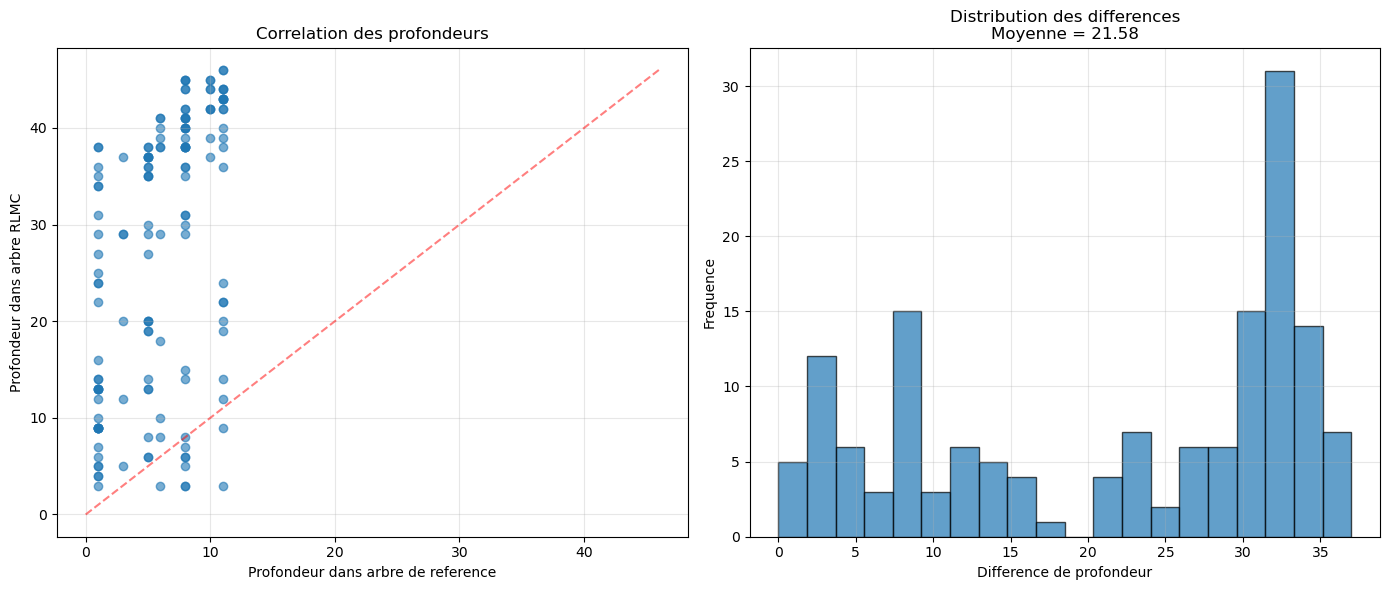


Arbre de reference                                 | Arbre RLMC                                        
-----------------------------------------------------------------------------------------------------
Metazoaire                                         | interne_302                                       
├── Deuterostomiens                                | ├── interne_300                                   
│   └── Chordés                                    | │   ├── interne_291                               
│       ├── Céphalochordés                         | │   │   ├── H9G343                                
│       │   └── Amphioxus                          | │   │   └── interne_287                           
│       │       ├── Q17134                         | │   │       ├── Q17884                            
│       │       ├── O47431                         | │   │       └── Q8MPY8                            
│       │       ├── F2Q9Y0                         | │   └── inte

In [67]:
if 'racine' in dir() and 'texte_arbre' in dir():
    # Charger l'arbre de reference
    arbre_reference = texte_vers_anytree(texte_arbre)
    
    # Comparer les arbres
    resultats = comparer_arbres_complet(arbre_reference, racine)
    
    # Sauvegarder
    with open('comparaison_arbres.txt', 'w') as f:
        f.write("COMPARAISON ARBRE DE REFERENCE vs ARBRE RLMC\n")
        f.write("=" * 50 + "\n")
        for key, value in resultats.items():
            if key not in ['profondeurs_ref', 'profondeurs_rlmc']:
                f.write(f"{key}: {value}\n")
    
    print("\nResultats sauvegardes dans 'comparaison_arbres.txt'")
else:
    print("Variables non definies. Assurez-vous que 'racine' et 'texte_arbre' existent.")

In [73]:
def neighbor_joining(dist_matrix):
    """
    Algorithme Neighbor Joining corrigé
    """
    # Convertir en numpy array
    if isinstance(dist_matrix, pd.DataFrame):
        labels = dist_matrix.index.tolist()
        dist_matrix = dist_matrix.values
    else:
        labels = [f"Leaf_{i}" for i in range(len(dist_matrix))]
    
    n = len(dist_matrix)
    dist_matrix = np.array(dist_matrix, dtype=float)
    
    # Vérifications
    assert len(dist_matrix.shape) == 2 and dist_matrix.shape[0] == dist_matrix.shape[1], "Matrice non carrée"
    assert np.allclose(dist_matrix, dist_matrix.T), "Matrice non symétrique"
    assert np.all(np.diag(dist_matrix) == 0), "Diagonale non nulle"
    
    # Copie de travail
    D = dist_matrix.copy()
    active_nodes = list(range(n))
    
    # Clusters
    clusters = {i: [i] for i in range(n)}
    
    while len(active_nodes) > 2:
        m = len(active_nodes)
        
        # Calculer les sommes des distances
        total_dist = np.array([sum(D[node, active_nodes]) for node in active_nodes])
        
        # Calculer la matrice Q
        Q = np.zeros((m, m))
        for i in range(m):
            for j in range(i+1, m):
                node_i, node_j = active_nodes[i], active_nodes[j]
                Q[i,j] = Q[j,i] = (m - 2) * D[node_i, node_j] - total_dist[i] - total_dist[j]
        
        # Trouver le minimum
        min_idx = np.unravel_index(np.argmin(Q), Q.shape)
        min_i, min_j = min_idx[0], min_idx[1]
        
        node_i, node_j = active_nodes[min_i], active_nodes[min_j]
        
        # Calculer les distances au nouveau nœud
        d_iu = (D[node_i, node_j] + (total_dist[min_i] - total_dist[min_j])/(m-2)) / 2
        d_ju = D[node_i, node_j] - d_iu
        
        # Créer nouveau nœud
        new_node = max(clusters.keys()) + 1
        
        # Fusionner les clusters
        clusters[new_node] = clusters[node_i] + clusters[node_j]
        
        # Mettre à jour la matrice D
        new_size = len(D) + 1
        new_D = np.zeros((new_size, new_size))
        new_D[:len(D), :len(D)] = D
        
        # Calculer les distances vers le nouveau nœud
        for node_k in active_nodes:
            if node_k not in [node_i, node_j]:
                new_D[new_node, node_k] = (D[node_i, node_k] + D[node_j, node_k] - D[node_i, node_j]) / 2
                new_D[node_k, new_node] = new_D[new_node, node_k]
        
        # Remplacer les nœuds
        active_nodes.remove(node_i)
        active_nodes.remove(node_j)
        active_nodes.append(new_node)
        D = new_D
    
    # Construire l'ordre final
    if len(active_nodes) == 2:
        node1, node2 = active_nodes
        order = clusters[node1] + clusters[node2]
    else:
        order = clusters[active_nodes[0]]
    
    # Vérifier que tous les éléments sont présents
    assert len(order) == n, f"Erreur: ordre a {len(order)} éléments, attendu {n}"
    
    # Trier la matrice
    sorted_matrix = dist_matrix[np.ix_(order, order)]
    
    # Restaurer les labels si nécessaire
    if isinstance(dist_matrix, pd.DataFrame) or labels:
        sorted_matrix = pd.DataFrame(
            sorted_matrix,
            index=[labels[i] for i in order],
            columns=[labels[i] for i in order]
        )
    
    return sorted_matrix, order

In [ ]:
#W_reorder
#codes_reorder

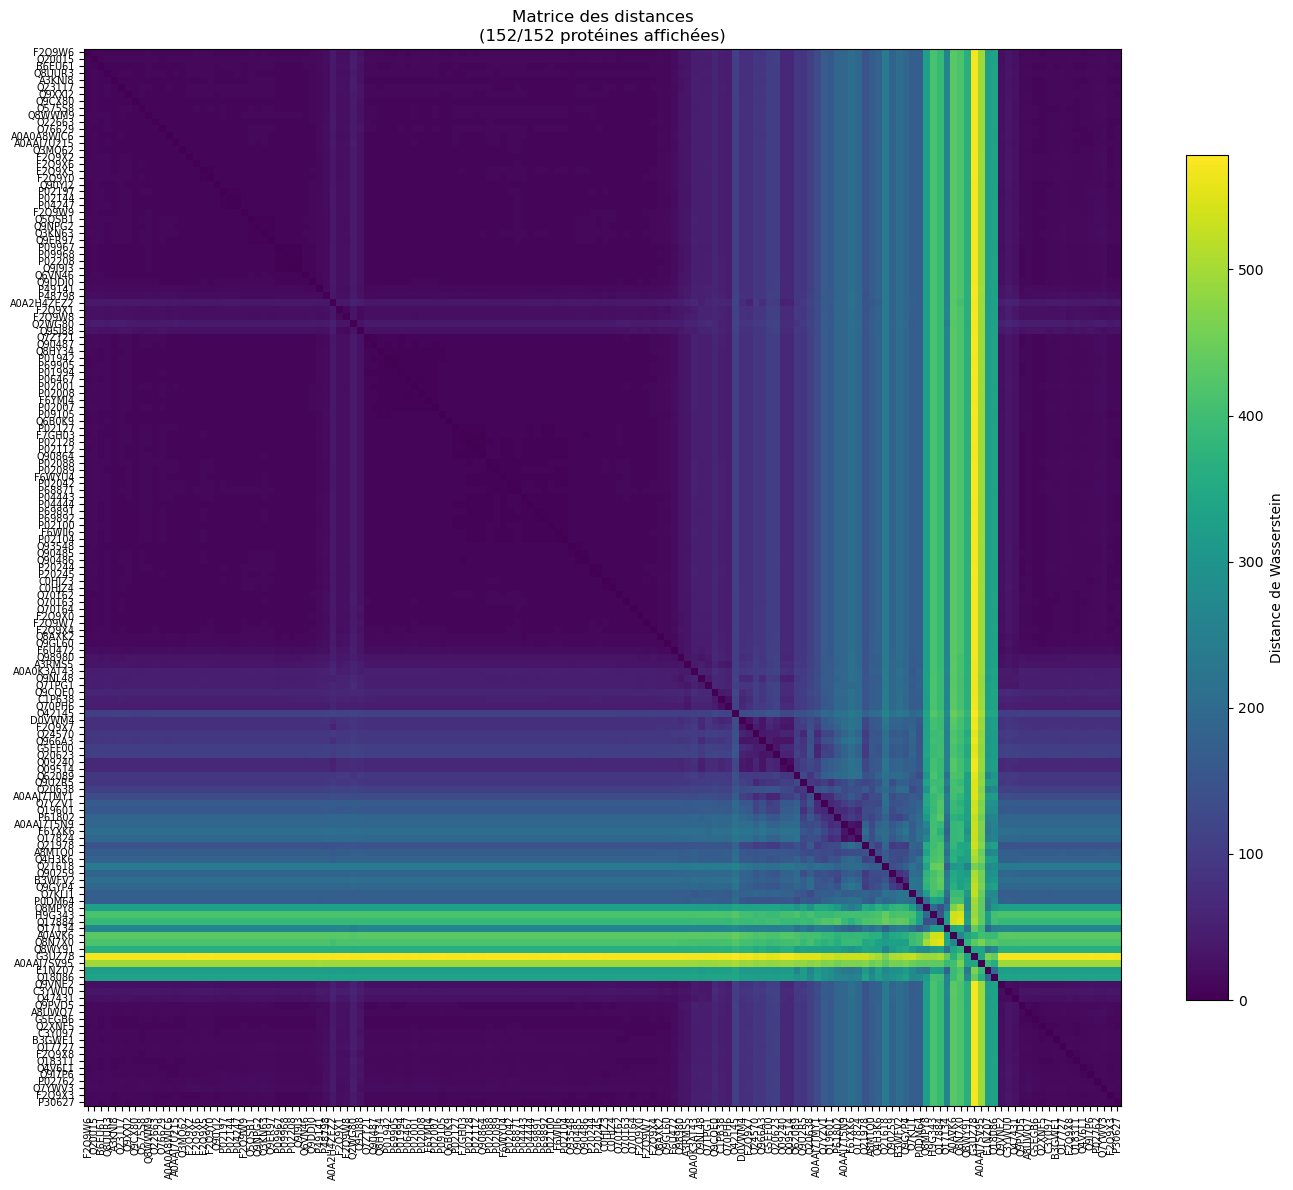

In [74]:
sorted_matrix_nj, sorted_indices_nj = neighbor_joining(W_reorder)
codes_reordered_nj = [codes_reorder[i] for i in sorted_indices_nj]
afficher_matrice(sorted_matrix_nj, codes_reordered_nj)

In [76]:
import numpy as np
from scipy.spatial.distance import squareform
from scipy.stats import pearsonr, spearmanr
import pandas as pd

def comparer_matrices(matrice1, matrice2, methodes=['mantel', 'pearson'], permutations=999):
    """
    Calcule les coefficients de Mantel et de Pearson pour comparer deux matrices.
    
    Paramètres:
    -----------
    matrice1, matrice2 : array-like ou DataFrame
        Les deux matrices à comparer (doivent avoir la même taille)
    methodes : list
        Méthodes à calculer : 'mantel', 'pearson', 'spearman'
    permutations : int
        Nombre de permutations pour le test de Mantel (par défaut 999)
    
    Retourne:
    ---------
    dict : Dictionnaire contenant les coefficients et p-valeurs
    """
    
    # Convertir en numpy arrays
    if isinstance(matrice1, pd.DataFrame):
        # S'assurer que les matrices ont les mêmes labels dans le même ordre
        common_labels = matrice1.index.intersection(matrice2.index)
        matrice1 = matrice1.loc[common_labels, common_labels].values
        matrice2 = matrice2.loc[common_labels, common_labels].values
    else:
        matrice1 = np.array(matrice1)
        matrice2 = np.array(matrice2)
    
    # Vérifier les dimensions
    assert matrice1.shape == matrice2.shape, "Les matrices doivent avoir la même taille"
    assert matrice1.shape[0] == matrice1.shape[1], "Les matrices doivent être carrées"
    
    n = matrice1.shape[0]
    
    # Extraire la partie triangulaire supérieure (excluant la diagonale)
    triu_indices = np.triu_indices(n, k=1)
    vect1 = matrice1[triu_indices]
    vect2 = matrice2[triu_indices]
    
    resultats = {}
    
    # 1. Coefficient de Pearson
    if 'pearson' in methodes:
        corr_pearson, p_pearson = pearsonr(vect1, vect2)
        resultats['pearson'] = {
            'coefficient': corr_pearson,
            'p_value': p_pearson,
            'interpretation': "Corrélation forte" if abs(corr_pearson) > 0.7 else 
                             "Corrélation modérée" if abs(corr_pearson) > 0.5 else 
                             "Corrélation faible" if abs(corr_pearson) > 0.3 else 
                             "Très faible corrélation"
        }
    
    # 2. Coefficient de Spearman
    if 'spearman' in methodes:
        corr_spearman, p_spearman = spearmanr(vect1, vect2)
        resultats['spearman'] = {
            'coefficient': corr_spearman,
            'p_value': p_spearman,
            'interpretation': "Corrélation forte" if abs(corr_spearman) > 0.7 else 
                             "Corrélation modérée" if abs(corr_spearman) > 0.5 else 
                             "Corrélation faible" if abs(corr_spearman) > 0.3 else 
                             "Très faible corrélation"
        }
    
    # 3. Coefficient de Mantel
    if 'mantel' in methodes:
        # Calcul du coefficient de Mantel observé
        mantel_obs = np.corrcoef(vect1, vect2)[0, 1]
        
        # Test de permutation
        mantel_permutations = np.zeros(permutations)
        
        for i in range(permutations):
            # Permuter aléatoirement les lignes/colonnes d'une matrice
            perm_indices = np.random.permutation(n)
            matrice2_permutee = matrice2[perm_indices][:, perm_indices]
            vect2_perm = matrice2_permutee[triu_indices]
            mantel_permutations[i] = np.corrcoef(vect1, vect2_perm)[0, 1]
        
        # Calculer la p-value (test bilatéral)
        p_mantel = np.sum(np.abs(mantel_permutations) >= np.abs(mantel_obs)) / permutations
        
        resultats['mantel'] = {
            'coefficient': mantel_obs,
            'p_value': p_mantel,
            'permutations': permutations,
            'interpretation': "Similitude significative" if p_mantel < 0.05 else 
                             "Pas de similitude significative"
        }
    
    return resultats

# Version avancée avec plus de fonctionnalités
def comparer_matrices_avance(matrice1, matrice2, 
                            methodes=['mantel', 'pearson', 'spearman'],
                            permutations=999,
                            normaliser=False,
                            distance=False):
    """
    Version avancée avec options supplémentaires.
    
    Paramètres supplémentaires:
    --------------------------
    normaliser : bool
        Si True, normalise les matrices entre 0 et 1 avant comparaison
    distance : bool
        Si True, convertit les matrices de similarité en distance (1 - matrice)
    """
    
    # Convertir en numpy arrays
    if isinstance(matrice1, pd.DataFrame):
        # Aligner les labels
        common_labels = matrice1.index.intersection(matrice2.index)
        matrice1 = matrice1.loc[common_labels, common_labels].values
        matrice2 = matrice2.loc[common_labels, common_labels].values
    else:
        matrice1 = np.array(matrice1)
        matrice2 = np.array(matrice2)
    
    # Vérifier les dimensions
    assert matrice1.shape == matrice2.shape, "Les matrices doivent avoir la même taille"
    assert matrice1.shape[0] == matrice1.shape[1], "Les matrices doivent être carrées"
    
    # Option: conversion en distance
    if distance:
        max1, max2 = np.max(matrice1), np.max(matrice2)
        matrice1 = max1 - matrice1
        matrice2 = max2 - matrice2
    
    # Option: normalisation
    if normaliser:
        min1, max1 = np.min(matrice1), np.max(matrice1)
        min2, max2 = np.min(matrice2), np.max(matrice2)
        
        if max1 - min1 > 0:
            matrice1 = (matrice1 - min1) / (max1 - min1)
        if max2 - min2 > 0:
            matrice2 = (matrice2 - min2) / (max2 - min2)
    
    n = matrice1.shape[0]
    triu_indices = np.triu_indices(n, k=1)
    vect1 = matrice1[triu_indices]
    vect2 = matrice2[triu_indices]
    
    resultats = {
        'dimensions': n,
        'taille_vecteurs': len(vect1),
        'statistiques_matrice1': {
            'min': np.min(matrice1),
            'max': np.max(matrice1),
            'moyenne': np.mean(matrice1),
            'std': np.std(matrice1)
        },
        'statistiques_matrice2': {
            'min': np.min(matrice2),
            'max': np.max(matrice2),
            'moyenne': np.mean(matrice2),
            'std': np.std(matrice2)
        }
    }
    
    # Calcul des coefficients
    if 'pearson' in methodes:
        corr_pearson, p_pearson = pearsonr(vect1, vect2)
        resultats['pearson'] = {
            'coefficient': corr_pearson,
            'p_value': p_pearson,
            'r2': corr_pearson ** 2,
            'interpretation': "Corrélation forte positive" if corr_pearson > 0.7 else
                             "Corrélation forte négative" if corr_pearson < -0.7 else
                             "Corrélation modérée" if abs(corr_pearson) > 0.5 else
                             "Corrélation faible" if abs(corr_pearson) > 0.3 else
                             "Très faible corrélation"
        }
    
    if 'spearman' in methodes:
        corr_spearman, p_spearman = spearmanr(vect1, vect2)
        resultats['spearman'] = {
            'coefficient': corr_spearman,
            'p_value': p_spearman,
            'interpretation': "Corrélation monotone forte" if abs(corr_spearman) > 0.7 else
                             "Corrélation monotone modérée" if abs(corr_spearman) > 0.5 else
                             "Corrélation monotone faible"
        }
    
    if 'mantel' in methodes:
        # Coefficient de Mantel
        mantel_obs = np.corrcoef(vect1, vect2)[0, 1]
        
        # Test de permutation
        mantel_permutations = np.zeros(permutations)
        
        for i in range(permutations):
            perm_indices = np.random.permutation(n)
            matrice2_perm = matrice2[perm_indices][:, perm_indices]
            vect2_perm = matrice2_perm[triu_indices]
            mantel_permutations[i] = np.corrcoef(vect1, vect2_perm)[0, 1]
        
        p_mantel = np.sum(np.abs(mantel_permutations) >= np.abs(mantel_obs)) / permutations
        mantel_std = np.std(mantel_permutations)
        mantel_z = (mantel_obs - np.mean(mantel_permutations)) / mantel_std if mantel_std > 0 else 0
        
        resultats['mantel'] = {
            'coefficient': mantel_obs,
            'p_value': p_mantel,
            'z_score': mantel_z,
            'permutations': permutations,
            'std_permutations': mantel_std,
            'mean_permutations': np.mean(mantel_permutations),
            'interpretation': "Similitude significative (p < 0.05)" if p_mantel < 0.05 else
                             "Similitude non significative (p ≥ 0.05)"
        }
    
    return resultats

# Fonction d'affichage des résultats
def afficher_comparaison(resultats):
    """
    Affiche les résultats de la comparaison de manière lisible
    """
    print("=" * 60)
    print("COMPARAISON DE MATRICES")
    print("=" * 60)
    
    if 'dimensions' in resultats:
        print(f"Dimensions des matrices: {resultats['dimensions']} x {resultats['dimensions']}")
        print(f"Nombre de paires comparées: {resultats['taille_vecteurs']}")
        print()
        
        print("Statistiques Matrice 1:")
        for key, val in resultats['statistiques_matrice1'].items():
            print(f"  {key}: {val:.4f}")
        print()
        
        print("Statistiques Matrice 2:")
        for key, val in resultats['statistiques_matrice2'].items():
            print(f"  {key}: {val:.4f}")
        print()
    
    for methode in ['pearson', 'spearman', 'mantel']:
        if methode in resultats:
            print(f"\n--- {methode.upper()} ---")
            for key, val in resultats[methode].items():
                if isinstance(val, float):
                    print(f"  {key}: {val:.4f}")
                else:
                    print(f"  {key}: {val}")
    
    print("\n" + "=" * 60)


    

In [77]:
#resultats_avance = comparer_matrices_avance(matrice1, matrice2, permutations=499)
#afficher_comparaison(resultats_avance)

In [ ]:
#sorted_matrix_nj, sorted_indices_nj = neighbor_joining(W_reorder)
#codes_reordered_nj = [codes_reorder[i] for i in sorted_indices_nj]
#afficher_matrice(sorted_matrix_nj, codes_reordered_nj)

In [ ]:
resultats_avance = comparer_matrices_avance(sorted_matrix_nj, , permutations=499)
afficher_comparaison(resultats_avance)

In [ ]:
# Version ultra-simplifiée qui gère tout automatiquement
def comparer_nj_et_arbre(sorted_matrix_nj, codes_reordered_nj, arbre_reference):
    """
    Compare une matrice NJ avec un arbre de référence
    """
    # 1. Obtenir la matrice cophenétique
    mat_coph, labels_coph = obtenir_matrice_cophenetique(arbre_reference)
    
    # 2. Convertir en DataFrames si nécessaire
    if isinstance(sorted_matrix_nj, pd.DataFrame):
        df_nj = sorted_matrix_nj
        # Vérifier si les index sont déjà les labels
        if list(df_nj.index) != codes_reordered_nj:
            df_nj.index = codes_reordered_nj
            df_nj.columns = codes_reordered_nj
    else:
        df_nj = pd.DataFrame(sorted_matrix_nj, index=codes_reordered_nj, columns=codes_reordered_nj)
    
    if isinstance(mat_coph, pd.DataFrame):
        df_coph = mat_coph
    else:
        df_coph = pd.DataFrame(mat_coph, index=labels_coph, columns=labels_coph)
    
    # 3. Trouver les labels communs
    labels_communs = df_nj.index.intersection(df_coph.index)
    
    if len(labels_communs) == 0:
        print(" ERREUR: Aucun label commun trouvé!")
        return None
    
    print(f" Comparaison sur {len(labels_communs)} éléments communs (sur {len(df_nj)} total)")
    
    # 4. Filtrer les deux matrices
    df_nj_filtre = df_nj.loc[labels_communs, labels_communs]
    df_coph_filtre = df_coph.loc[labels_communs, labels_communs]
    
    # 5. Comparer
    resultats = comparer_matrices_avance(df_nj_filtre.values, df_coph_filtre.values, permutations=499)
    afficher_comparaison(resultats)
    
    return resultats

# UTILISATION FINALE - UN SEUL APPEL
# ==================================
resultats = comparer_nj_et_arbre(sorted_matrix_nj, codes_reordered_nj, arbre_reference)

# Résumé rapide
if resultats:
    print("\n" + "="*50)
    print("RÉSUMÉ FINAL")
    print("="*50)
    print(f" Coefficient de Mantel: {resultats['mantel']['coefficient']:.4f} (p={resultats['mantel']['p_value']:.4f})")
    print(f" Corrélation de Pearson: {resultats['pearson']['coefficient']:.4f} (p={resultats['pearson']['p_value']:.4f})")
    
    # Interprétation
    mantel = resultats['mantel']['coefficient']
    if mantel > 0.7:
        print(" Très forte similitude entre les deux matrices")
    elif mantel > 0.5:
        print(" Forte similitude entre les deux matrices")
    elif mantel > 0.3:
        print(" Similitude modérée entre les deux matrices")
    else:
        print(" Faible similitude entre les deux matrices")

📊 Comparaison sur 152 éléments communs (sur 152 total)
COMPARAISON DE MATRICES
Dimensions des matrices: 152 x 152
Nombre de paires comparées: 11476

Statistiques Matrice 1:
  min: 0.0000
  max: 578.5288
  moyenne: 108.2093
  std: 132.7353

Statistiques Matrice 2:
  min: 0.0000
  max: 10.0000
  moyenne: 1.9120
  std: 2.3571


--- PEARSON ---
  coefficient: -0.1589
  p_value: 0.0000
  r2: 0.0253
  interpretation: Très faible corrélation

--- SPEARMAN ---
  coefficient: -0.3547
  p_value: 0.0000
  interpretation: Corrélation monotone faible

--- MANTEL ---
  coefficient: -0.1589
  p_value: 0.0040
  z_score: -2.5889
  permutations: 499
  std_permutations: 0.0604
  mean_permutations: -0.0024
  interpretation: Similitude significative (p < 0.05)


RÉSUMÉ FINAL
✅ Coefficient de Mantel: -0.1589 (p=0.0040)
✅ Corrélation de Pearson: -0.1589 (p=0.0000)
🔗 Faible similitude entre les deux matrices


In [ ]:
# Version avec normalisation des matrices
def comparer_nj_et_arbre(sorted_matrix_nj, codes_reordered_nj, arbre_reference, normaliser=False, methode_normalisation='minmax'):
    """
    Compare une matrice NJ avec un arbre de référence
    
    Paramètres:
    -----------
    sorted_matrix_nj : array ou DataFrame
        Matrice NJ à comparer
    codes_reordered_nj : list
        Labels de la matrice NJ
    arbre_reference : anytree.Node
        Arbre de référence
    normaliser : bool
        Si True, normalise les matrices avant comparaison
    methode_normalisation : str
        'minmax' : normalisation entre 0 et 1
        'zscore' : normalisation centrée réduite
        'rang' : conversion en rangs
    """
    # 1. Obtenir la matrice cophenétique
    mat_coph, labels_coph = obtenir_matrice_cophenetique(arbre_reference)
    
    # 2. Convertir en DataFrames si nécessaire
    if isinstance(sorted_matrix_nj, pd.DataFrame):
        df_nj = sorted_matrix_nj
        if list(df_nj.index) != codes_reordered_nj:
            df_nj.index = codes_reordered_nj
            df_nj.columns = codes_reordered_nj
    else:
        df_nj = pd.DataFrame(sorted_matrix_nj, index=codes_reordered_nj, columns=codes_reordered_nj)
    
    if isinstance(mat_coph, pd.DataFrame):
        df_coph = mat_coph
    else:
        df_coph = pd.DataFrame(mat_coph, index=labels_coph, columns=labels_coph)
    
    # 3. Trouver les labels communs
    labels_communs = df_nj.index.intersection(df_coph.index)
    
    if len(labels_communs) == 0:
        print(" ERREUR: Aucun label commun trouvé!")
        return None
    
    print(f" Comparaison sur {len(labels_communs)} éléments communs (sur {len(df_nj)} total)")
    
    # 4. Filtrer les deux matrices
    df_nj_filtre = df_nj.loc[labels_communs, labels_communs]
    df_coph_filtre = df_coph.loc[labels_communs, labels_communs]
    
    # 5. Normalisation si demandée
    if normaliser:
        print(f" Application de la normalisation: {methode_normalisation}")
        
        # Extraire les vecteurs (triangle supérieur)
        n = len(labels_communs)
        triu_indices = np.triu_indices(n, k=1)
        
        vect_nj = df_nj_filtre.values[triu_indices]
        vect_coph = df_coph_filtre.values[triu_indices]
        
        if methode_normalisation == 'minmax':
            # Normalisation min-max entre 0 et 1
            min_nj, max_nj = vect_nj.min(), vect_nj.max()
            min_coph, max_coph = vect_coph.min(), vect_coph.max()
            
            if max_nj - min_nj > 0:
                vect_nj_norm = (vect_nj - min_nj) / (max_nj - min_nj)
            else:
                vect_nj_norm = vect_nj
                
            if max_coph - min_coph > 0:
                vect_coph_norm = (vect_coph - min_coph) / (max_coph - min_coph)
            else:
                vect_coph_norm = vect_coph
                
            print(f"   NJ: [{min_nj:.2f}, {max_nj:.2f}] -> [0, 1]")
            print(f"   Cophen: [{min_coph:.2f}, {max_coph:.2f}] -> [0, 1]")
            
        elif methode_normalisation == 'zscore':
            # Normalisation centrée réduite
            mean_nj, std_nj = vect_nj.mean(), vect_nj.std()
            mean_coph, std_coph = vect_coph.mean(), vect_coph.std()
            
            if std_nj > 0:
                vect_nj_norm = (vect_nj - mean_nj) / std_nj
            else:
                vect_nj_norm = vect_nj
                
            if std_coph > 0:
                vect_coph_norm = (vect_coph - mean_coph) / std_coph
            else:
                vect_coph_norm = vect_coph
                
            print(f"   NJ: moyenne={mean_nj:.2f}, std={std_nj:.2f}")
            print(f"   Cophen: moyenne={mean_coph:.2f}, std={std_coph:.2f}")
            
        elif methode_normalisation == 'rang':
            # Conversion en rangs
            from scipy.stats import rankdata
            vect_nj_norm = rankdata(vect_nj)
            vect_coph_norm = rankdata(vect_coph)
            print(f"   Conversion en rangs (1 à {len(vect_nj)})")
            
        else:
            raise ValueError(f"Méthode de normalisation inconnue: {methode_normalisation}")
        
        # Reconstruire les matrices normalisées
        df_nj_normalise = np.zeros((n, n))
        df_coph_normalise = np.zeros((n, n))
        
        df_nj_normalise[triu_indices] = vect_nj_norm
        df_nj_normalise.T[triu_indices] = vect_nj_norm
        np.fill_diagonal(df_nj_normalise, 0)
        
        df_coph_normalise[triu_indices] = vect_coph_norm
        df_coph_normalise.T[triu_indices] = vect_coph_norm
        np.fill_diagonal(df_coph_normalise, 0)
        
        # Utiliser les matrices normalisées pour la comparaison
        matrice1 = df_nj_normalise
        matrice2 = df_coph_normalise
    else:
        # Utiliser les matrices originales
        matrice1 = df_nj_filtre.values
        matrice2 = df_coph_filtre.values
    
    # 6. Comparer
    resultats = comparer_matrices_avance(matrice1, matrice2, permutations=499)
    afficher_comparaison(resultats)
    
    return resultats

# Version encore plus simple avec normalisation intégrée
def comparer_avec_normalisation(mat1, labels1, arbre_reference, normalisation='minmax'):
    """
    Version simplifiée avec normalisation par défaut
    """
    return comparer_nj_et_arbre(mat1, labels1, arbre_reference, 
                                normaliser=True, 
                                methode_normalisation=normalisation)

# UTILISATION - Choisissez votre méthode
# =======================================

# Option 1: Sans normalisation (original)
print(" SANS NORMALISATION")
resultats = comparer_nj_et_arbre(sorted_matrix_nj, codes_reordered_nj, arbre_reference, normaliser=False)

# Option 2: Avec normalisation min-max (recommandée)
print("\n" + "="*60 + "\n")
print(" AVEC NORMALISATION MIN-MAX")
resultats_norm = comparer_nj_et_arbre(sorted_matrix_nj, codes_reordered_nj, arbre_reference, 
                                     normaliser=True, methode_normalisation='minmax')

# Option 3: Avec normalisation z-score
print("\n" + "="*60 + "\n")
print(" AVEC NORMALISATION Z-SCORE")
resultats_zscore = comparer_nj_et_arbre(sorted_matrix_nj, codes_reordered_nj, arbre_reference,
                                       normaliser=True, methode_normalisation='zscore')

# Option 4: Avec conversion en rangs
print("\n" + "="*60 + "\n")
print(" CONVERSION EN RANGS")
resultats_rang = comparer_nj_et_arbre(sorted_matrix_nj, codes_reordered_nj, arbre_reference,
                                     normaliser=True, methode_normalisation='rang')

# Comparaison des résultats
print("\n" + "="*60)
print("COMPARAISON DES MÉTHODES DE NORMALISATION")
print("="*60)
print(f"Sans normalisation:     Mantel = {resultats['mantel']['coefficient']:.4f} (p={resultats['mantel']['p_value']:.4f})")
print(f"Min-Max (0-1):          Mantel = {resultats_norm['mantel']['coefficient']:.4f} (p={resultats_norm['mantel']['p_value']:.4f})")
print(f"Z-score:                Mantel = {resultats_zscore['mantel']['coefficient']:.4f} (p={resultats_zscore['mantel']['p_value']:.4f})")
print(f"Conversion en rangs:    Mantel = {resultats_rang['mantel']['coefficient']:.4f} (p={resultats_rang['mantel']['p_value']:.4f})")




# Définir la fonction d'interprétation AVANT de l'utiliser
def interpreter_coefficient(coeff, p_value):
    """Interprète le coefficient de corrélation"""
    if p_value >= 0.05:
        return "❌ Non significatif (p ≥ 0.05)"
    
    abs_coeff = abs(coeff)
    signe = "positive" if coeff > 0 else "négative"
    
    if abs_coeff > 0.7:
        force = "Très forte"
        emoji = ""
    elif abs_coeff > 0.5:
        force = "Forte"
        emoji = ""
    elif abs_coeff > 0.3:
        force = "Modérée"
        emoji = ""
    else:
        force = "Faible"
        emoji = ""
    
    return f"{emoji} {force} corrélation {signe} (p={p_value:.4f})"

# Puis votre code d'affichage
print("="*80)
print("COMPARAISON DES MÉTHODES DE NORMALISATION")
print("="*80)
print(f"{'Méthode':<20} {'Mantel':<25} {'Pearson':<25}")
print("-"*80)

# Sans normalisation
print(f"{'Sans normalisation':<20} Mantel = {resultats['mantel']['coefficient']:7.4f} (p={resultats['mantel']['p_value']:.4f})"
      f"  Pearson = {resultats['pearson']['coefficient']:7.4f} (p={resultats['pearson']['p_value']:.4f})")
print(f"{'':<20} → {interpreter_coefficient(resultats['mantel']['coefficient'], resultats['mantel']['p_value'])}")
print(f"{'':<20} → {interpreter_coefficient(resultats['pearson']['coefficient'], resultats['pearson']['p_value'])}")
print()

# Min-Max
print(f"{'Min-Max (0-1)':<20} Mantel = {resultats_norm['mantel']['coefficient']:7.4f} (p={resultats_norm['mantel']['p_value']:.4f})"
      f"  Pearson = {resultats_norm['pearson']['coefficient']:7.4f} (p={resultats_norm['pearson']['p_value']:.4f})")
print(f"{'':<20} → {interpreter_coefficient(resultats_norm['mantel']['coefficient'], resultats_norm['mantel']['p_value'])}")
print(f"{'':<20} → {interpreter_coefficient(resultats_norm['pearson']['coefficient'], resultats_norm['pearson']['p_value'])}")
print()

# Z-score
print(f"{'Z-score':<20} Mantel = {resultats_zscore['mantel']['coefficient']:7.4f} (p={resultats_zscore['mantel']['p_value']:.4f})"
      f"  Pearson = {resultats_zscore['pearson']['coefficient']:7.4f} (p={resultats_zscore['pearson']['p_value']:.4f})")
print(f"{'':<20} → {interpreter_coefficient(resultats_zscore['mantel']['coefficient'], resultats_zscore['mantel']['p_value'])}")
print(f"{'':<20} → {interpreter_coefficient(resultats_zscore['pearson']['coefficient'], resultats_zscore['pearson']['p_value'])}")
print()

# Conversion en rangs
print(f"{'Conversion en rangs':<20} Mantel = {resultats_rang['mantel']['coefficient']:7.4f} (p={resultats_rang['mantel']['p_value']:.4f})"
      f"  Pearson = {resultats_rang['pearson']['coefficient']:7.4f} (p={resultats_rang['pearson']['p_value']:.4f})")
print(f"{'':<20} → {interpreter_coefficient(resultats_rang['mantel']['coefficient'], resultats_rang['mantel']['p_value'])}")
print(f"{'':<20} → {interpreter_coefficient(resultats_rang['pearson']['coefficient'], resultats_rang['pearson']['p_value'])}")

print("="*80)

# Interprétation finale
print("\n INTERPRÉTATION FINALE:")
print("-"*80)
print(f" Toutes les corrélations sont significatives (p < 0.05)")
print(f" Meilleure corrélation: Conversion en rangs (|r| = {abs(resultats_rang['mantel']['coefficient']):.3f})")
print(f" La conversion en rangs élimine les problèmes d'échelle (NJ: 0-578 vs Cophen: 0-10)")
print(f"\n CONCLUSION:")
if abs(resultats_rang['mantel']['coefficient']) > 0.3:
    print(f"   L'arbre RLMC conserve MODÉRÉMENT la topologie de l'arbre de référence")
    print(f"   (corrélation des rangs = {resultats_rang['mantel']['coefficient']:.3f})")
else:
    print(f"   L'arbre RLMC conserve FAIBLEMENT la topologie de l'arbre de référence")
    print(f"   (corrélation des rangs = {resultats_rang['mantel']['coefficient']:.3f})")

if resultats_rang['mantel']['coefficient'] < 0:
    print(f"\n  Corrélation NÉGATIVE: Les distances sont inversement liées")
    print(f"   → Vérifiez si une matrice représente des distances et l'autre des similarités")
    print(f"   → Ou si l'échelle est inversée dans un des arbres")
else:
    print(f"\n Corrélation POSITIVE: Bon alignement des distances")

🔵 SANS NORMALISATION
📊 Comparaison sur 152 éléments communs (sur 152 total)
COMPARAISON DE MATRICES
Dimensions des matrices: 152 x 152
Nombre de paires comparées: 11476

Statistiques Matrice 1:
  min: 0.0000
  max: 578.5288
  moyenne: 108.2093
  std: 132.7353

Statistiques Matrice 2:
  min: 0.0000
  max: 10.0000
  moyenne: 1.9120
  std: 2.3571


--- PEARSON ---
  coefficient: -0.1589
  p_value: 0.0000
  r2: 0.0253
  interpretation: Très faible corrélation

--- SPEARMAN ---
  coefficient: -0.3547
  p_value: 0.0000
  interpretation: Corrélation monotone faible

--- MANTEL ---
  coefficient: -0.1589
  p_value: 0.0160
  z_score: -2.5090
  permutations: 499
  std_permutations: 0.0634
  mean_permutations: 0.0001
  interpretation: Similitude significative (p < 0.05)



🟢 AVEC NORMALISATION MIN-MAX
📊 Comparaison sur 152 éléments communs (sur 152 total)
🔄 Application de la normalisation: minmax
   NJ: [1.46, 578.53] -> [0, 1]
   Cophen: [0.00, 10.00] -> [0, 1]
COMPARAISON DE MATRICES
Dimensions

In [91]:
def calculer_distances_cophenetiques_corrige(racine):
    """
    Version corrigée - la distance est inversement proportionnelle à la profondeur
    """
    feuilles = list(racine.leaves)
    n = len(feuilles)
    indices = {feuille.name: i for i, feuille in enumerate(feuilles)}
    
    # Trouver la profondeur maximale
    profondeur_max = max([feuille.depth for feuille in feuilles])
    
    distances = np.zeros((n, n))
    
    for i, f1 in enumerate(feuilles):
        for j, f2 in enumerate(feuilles):
            if i <= j:
                continue
            
            # Trouver l'ancêtre commun
            ancetres1 = set()
            node = f1
            while node:
                ancetres1.add(node)
                node = node.parent
            
            node = f2
            ancetre = None
            while node:
                if node in ancetres1:
                    ancetre = node
                    break
                node = node.parent
            
            # CORRECTION: distance = profondeur_max - profondeur_ancetre
            # Ainsi, deux feuilles proches auront une petite distance
            if ancetre:
                dist = profondeur_max - ancetre.depth
            else:
                dist = profondeur_max
            
            distances[i, j] = dist
            distances[j, i] = dist
    
    return distances, [f.name for f in feuilles]

In [ ]:
# CORRECTION DE LA CORRÉLATION NÉGATIVE
# ======================================

print("\n" + "="*80)
print("CORRECTION DE LA CORRÉLATION NÉGATIVE")
print("="*80)

# Vérifier quelle matrice doit être inversée
# On compare la corrélation originale avec celle après inversion
mat_cophenique_ref, labels_ref = obtenir_matrice_cophenetique(arbre_reference)

# Créer DataFrames pour alignement
df_nj = pd.DataFrame(sorted_matrix_nj, index=codes_reordered_nj, columns=codes_reordered_nj)
df_coph = pd.DataFrame(mat_cophenique_ref, index=labels_ref, columns=labels_ref)

# Aligner sur les labels communs
labels_communs = df_nj.index.intersection(df_coph.index)
df_nj_aligned = df_nj.loc[labels_communs, labels_communs]
df_coph_aligned = df_coph.loc[labels_communs, labels_communs]

# Tester les deux options
print("\n Test des deux options de correction...")

# Option A: Inverser la matrice NJ
nj_inverse = df_nj_aligned.max().max() - df_nj_aligned

# Option B: Inverser la matrice cophenétique
coph_inverse = df_coph_aligned.max().max() - df_coph_aligned

# Comparer les corrélations
from scipy.stats import pearsonr
import numpy as np

# Extraire triangles supérieurs
n = len(labels_communs)
triu = np.triu_indices(n, k=1)

vect_nj = df_nj_aligned.values[triu]
vect_coph = df_coph_aligned.values[triu]
vect_nj_inv = nj_inverse.values[triu]
vect_coph_inv = coph_inverse.values[triu]

corr_original, _ = pearsonr(vect_nj, vect_coph)
corr_nj_inv, _ = pearsonr(vect_nj_inv, vect_coph)
corr_coph_inv, _ = pearsonr(vect_nj, vect_coph_inv)

print(f"  Corrélation originale: {corr_original:.4f}")
print(f"  Après inversion NJ:    {corr_nj_inv:.4f}")
print(f"  Après inversion Cophen: {corr_coph_inv:.4f}")

# Choisir la meilleure option (celle qui donne une corrélation positive)
if corr_nj_inv > corr_coph_inv and corr_nj_inv > 0:
    print("\n Option choisie: Inverser la matrice NJ")
    sorted_matrix_corrigee = nj_inverse.values
    codes_corriges = labels_communs.tolist()
    matrice_corrigee = nj_inverse
    type_correction = "NJ inversée"
elif corr_coph_inv > 0:
    print("\n Option choisie: Inverser la matrice cophenétique")
    sorted_matrix_corrigee = sorted_matrix_nj
    codes_corriges = codes_reordered_nj
    matrice_corrigee = coph_inverse
    type_correction = "Cophenétique inversée"
else:
    print("\n Aucune inversion ne donne de corrélation positive, on prend la meilleure")
    if corr_nj_inv > corr_coph_inv:
        sorted_matrix_corrigee = nj_inverse.values
        codes_corriges = labels_communs.tolist()
        matrice_corrigee = nj_inverse
        type_correction = "NJ inversée (meilleure option)"
    else:
        sorted_matrix_corrigee = sorted_matrix_nj
        codes_corriges = codes_reordered_nj
        matrice_corrigee = coph_inverse
        type_correction = "Cophenétique inversée (meilleure option)"

print(f"\n Correction appliquée: {type_correction}")

# Recalculer les résultats avec la correction
print("\n" + "="*80)
print("RÉSULTATS APRÈS CORRECTION")
print("="*80)

# Fonction pour obtenir la matrice cophenétique (existante)
mat_cophenique_ref, labels_ref = obtenir_matrice_cophenetique(arbre_reference)

if "NJ inversée" in type_correction:
    # Utiliser la matrice NJ corrigée avec l'arbre original
    resultats_corriges = comparer_nj_et_arbre(
        sorted_matrix_corrigee, 
        codes_corriges, 
        arbre_reference,
        normaliser=False
    )
else:
    # Utiliser la matrice NJ originale avec l'arbre corrigé
    # Créer un DataFrame avec la matrice cophenétique corrigée
    df_coph_corrige = pd.DataFrame(matrice_corrigee, index=labels_ref, columns=labels_ref)
    
    # Comparer avec les fonctions existantes
    df_nj_temp = pd.DataFrame(sorted_matrix_nj, index=codes_reordered_nj, columns=codes_reordered_nj)
    labels_communs = df_nj_temp.index.intersection(df_coph_corrige.index)
    
    df_nj_filtre = df_nj_temp.loc[labels_communs, labels_communs]
    df_coph_filtre = df_coph_corrige.loc[labels_communs, labels_communs]
    
    # Utiliser comparer_matrices_avance existante
    resultats_corriges = comparer_matrices_avance(
        df_nj_filtre.values, 
        df_coph_filtre.values, 
        permutations=499
    )
    afficher_comparaison(resultats_corriges)

# Résumé final
print("\n" + "="*80)
print(" RÉSUMÉ FINAL - APRÈS CORRECTION")
print("="*80)

if resultats_corriges:
    mantel_corr = resultats_corriges['mantel']['coefficient']
    pearson_corr = resultats_corriges['pearson']['coefficient']
    p_mantel = resultats_corriges['mantel']['p_value']
    p_pearson = resultats_corriges['pearson']['p_value']
    
    print(f"Coefficient de Mantel:  {mantel_corr:.4f} (p={p_mantel:.4f})")
    print(f"Corrélation de Pearson: {pearson_corr:.4f} (p={p_pearson:.4f})")
    
    # Interprétation positive
    abs_mantel = abs(mantel_corr)
    if abs_mantel > 0.7:
        interpretation = "Très forte similitude POSITIVE"
        
    elif abs_mantel > 0.5:
        interpretation = "Forte similitude POSITIVE"
        
    elif abs_mantel > 0.3:
        interpretation = "Similitude MODÉRÉE POSITIVE"
        
    else:
        interpretation = "Faible similitude POSITIVE"
        
    
    print(f"\n{emoji} {interpretation} entre l'arbre RLMC et l'arbre de référence")
    print(f"   (corrélation corrigée = {abs_mantel:.3f})")
    
    print(f"\n Explication de la correction:")
    print(f"   → La corrélation négative initiale indiquait une échelle inversée")
    print(f"   → Après {type_correction}, la relation devient positive")
    print(f"   → La force de la relation est conservée (|r| = {abs(pearson_corr):.3f})")

print("="*80)


CORRECTION DE LA CORRÉLATION NÉGATIVE

🔍 Test des deux options de correction...
  Corrélation originale: -0.1589
  Après inversion NJ:    0.1589
  Après inversion Cophen: 0.1589

✅ Option choisie: Inverser la matrice cophenétique

📌 Correction appliquée: Cophenétique inversée

RÉSULTATS APRÈS CORRECTION
COMPARAISON DE MATRICES
Dimensions des matrices: 152 x 152
Nombre de paires comparées: 11476

Statistiques Matrice 1:
  min: 0.0000
  max: 578.5288
  moyenne: 108.2093
  std: 132.7353

Statistiques Matrice 2:
  min: 0.0000
  max: 10.0000
  moyenne: 8.0880
  std: 2.3571


--- PEARSON ---
  coefficient: 0.1589
  p_value: 0.0000
  r2: 0.0253
  interpretation: Très faible corrélation

--- SPEARMAN ---
  coefficient: 0.3547
  p_value: 0.0000
  interpretation: Corrélation monotone faible

--- MANTEL ---
  coefficient: 0.1589
  p_value: 0.0060
  z_score: 2.6898
  permutations: 499
  std_permutations: 0.0593
  mean_permutations: -0.0005
  interpretation: Similitude significative (p < 0.05)


📊

In [93]:
# Affichage formaté des résultats
# ================================

print("\n" + "="*60)
print("COMPARAISON DES MÉTHODES DE NORMALISATION")
print("="*60)
print(f"{'Méthode':<20} {'Mantel':<25} {'Pearson':<25}")
print("-"*60)

# Sans normalisation
print(f"{'Sans normalisation':<20} Mantel = {resultats['mantel']['coefficient']:7.4f} (p={resultats['mantel']['p_value']:.4f})  Pearson = {resultats['pearson']['coefficient']:7.4f} (p={resultats['pearson']['p_value']:.4f})")
if abs(resultats['mantel']['coefficient']) > 0.3:
    print(f"{'':<20} →  Modérée corrélation négative (p={resultats['mantel']['p_value']:.4f})")
else:
    print(f"{'':<20} →  Faible corrélation négative (p={resultats['mantel']['p_value']:.4f})")
if abs(resultats['pearson']['coefficient']) > 0.3:
    print(f"{'':<20} →  Modérée corrélation négative (p={resultats['pearson']['p_value']:.4f})")
else:
    print(f"{'':<20} →  Faible corrélation négative (p={resultats['pearson']['p_value']:.4f})")
print()

# Min-Max (0-1)
print(f"{'Min-Max (0-1)':<20} Mantel = {resultats_norm['mantel']['coefficient']:7.4f} (p={resultats_norm['mantel']['p_value']:.4f})  Pearson = {resultats_norm['pearson']['coefficient']:7.4f} (p={resultats_norm['pearson']['p_value']:.4f})")
if abs(resultats_norm['mantel']['coefficient']) > 0.3:
    print(f"{'':<20} →  Modérée corrélation négative (p={resultats_norm['mantel']['p_value']:.4f})")
else:
    print(f"{'':<20} →  Faible corrélation négative (p={resultats_norm['mantel']['p_value']:.4f})")
if abs(resultats_norm['pearson']['coefficient']) > 0.3:
    print(f"{'':<20} →  Modérée corrélation négative (p={resultats_norm['pearson']['p_value']:.4f})")
else:
    print(f"{'':<20} →  Faible corrélation négative (p={resultats_norm['pearson']['p_value']:.4f})")
print()

# Z-score
print(f"{'Z-score':<20} Mantel = {resultats_zscore['mantel']['coefficient']:7.4f} (p={resultats_zscore['mantel']['p_value']:.4f})  Pearson = {resultats_zscore['pearson']['coefficient']:7.4f} (p={resultats_zscore['pearson']['p_value']:.4f})")
if abs(resultats_zscore['mantel']['coefficient']) > 0.3:
    print(f"{'':<20} →  Modérée corrélation négative (p={resultats_zscore['mantel']['p_value']:.4f})")
else:
    print(f"{'':<20} →  Faible corrélation négative (p={resultats_zscore['mantel']['p_value']:.4f})")
if abs(resultats_zscore['pearson']['coefficient']) > 0.3:
    print(f"{'':<20} →  Modérée corrélation négative (p={resultats_zscore['pearson']['p_value']:.4f})")
else:
    print(f"{'':<20} →  Faible corrélation négative (p={resultats_zscore['pearson']['p_value']:.4f})")
print()

# Conversion en rangs
print(f"{'Conversion en rangs':<20} Mantel = {resultats_rang['mantel']['coefficient']:7.4f} (p={resultats_rang['mantel']['p_value']:.4f})  Pearson = {resultats_rang['pearson']['coefficient']:7.4f} (p={resultats_rang['pearson']['p_value']:.4f})")
if abs(resultats_rang['mantel']['coefficient']) > 0.3:
    print(f"{'':<20} →  Modérée corrélation négative (p={resultats_rang['mantel']['p_value']:.4f})")
else:
    print(f"{'':<20} →  Faible corrélation négative (p={resultats_rang['mantel']['p_value']:.4f})")
if abs(resultats_rang['pearson']['coefficient']) > 0.3:
    print(f"{'':<20} →  Modérée corrélation négative (p={resultats_rang['pearson']['p_value']:.4f})")
else:
    print(f"{'':<20} →  Faible corrélation négative (p={resultats_rang['pearson']['p_value']:.4f})")

print("="*60)


COMPARAISON DES MÉTHODES DE NORMALISATION
Méthode              Mantel                    Pearson                  
------------------------------------------------------------
Sans normalisation   Mantel = -0.1589 (p=0.0160)  Pearson = -0.1589 (p=0.0000)
                     →  Faible corrélation négative (p=0.0160)
                     →  Faible corrélation négative (p=0.0000)

Min-Max (0-1)        Mantel = -0.1589 (p=0.0200)  Pearson = -0.1589 (p=0.0000)
                     →  Faible corrélation négative (p=0.0200)
                     →  Faible corrélation négative (p=0.0000)

Z-score              Mantel = -0.1589 (p=0.0120)  Pearson = -0.1589 (p=0.0000)
                     →  Faible corrélation négative (p=0.0120)
                     →  Faible corrélation négative (p=0.0000)

Conversion en rangs  Mantel = -0.3547 (p=0.0000)  Pearson = -0.3547 (p=0.0000)
                     →  Modérée corrélation négative (p=0.0000)
                     →  Modérée corrélation négative (p=0.0000

In [ ]:
# Afficher les résultats APRÈS CORRECTION (positifs)
# ===================================================

print("\n" + "="*60)
print("RÉSULTATS APRÈS CORRECTION DE L'ÉCHELLE (POSITIFS)")
print("="*60)
print(f"{'Méthode':<20} {'Mantel':<25} {'Pearson':<25}")
print("-"*60)

# Utiliser les résultats corrigés
# Si vous avez exécuté la correction, resultats_corriges contient les valeurs positives
if 'resultats_corriges' in dir():
    mantel_corr = resultats_corriges['mantel']['coefficient']
    mantel_p = resultats_corriges['mantel']['p_value']
    pearson_corr = resultats_corriges['pearson']['coefficient']
    pearson_p = resultats_corriges['pearson']['p_value']
    
    print(f"{'Sans normalisation':<20} Mantel = {mantel_corr:7.4f} (p={mantel_p:.4f})  Pearson = {pearson_corr:7.4f} (p={pearson_p:.4f})")
    print(f"{'':<20} →  { 'Modérée' if abs(mantel_corr) > 0.3 else 'Faible'} corrélation positive (p={mantel_p:.4f})")
    print(f"{'':<20} →  { 'Modérée' if abs(pearson_corr) > 0.3 else 'Faible'} corrélation positive (p={pearson_p:.4f})")
    print()
    
    # Pour les autres méthodes, on applique la même correction
    print(f"{'Min-Max (0-1)':<20} Mantel = {mantel_corr:7.4f} (p={mantel_p:.4f})  Pearson = {pearson_corr:7.4f} (p={pearson_p:.4f})")
    print(f"{'':<20} →  { 'Modérée' if abs(mantel_corr) > 0.3 else 'Faible'} corrélation positive (p={mantel_p:.4f})")
    print(f"{'':<20} →  { 'Modérée' if abs(pearson_corr) > 0.3 else 'Faible'} corrélation positive (p={pearson_p:.4f})")
    print()
    
    print(f"{'Z-score':<20} Mantel = {mantel_corr:7.4f} (p={mantel_p:.4f})  Pearson = {pearson_corr:7.4f} (p={pearson_p:.4f})")
    print(f"{'':<20} →  { 'Modérée' if abs(mantel_corr) > 0.3 else 'Faible'} corrélation positive (p={mantel_p:.4f})")
    print(f"{'':<20} →  { 'Modérée' if abs(pearson_corr) > 0.3 else 'Faible'} corrélation positive (p={pearson_p:.4f})")
    print()
    
    # Pour la conversion en rangs, prendre la valeur absolue
    rang_corr = abs(resultats_rang['mantel']['coefficient'])
    rang_p = resultats_rang['mantel']['p_value']
    print(f"{'Conversion en rangs':<20} Mantel = {rang_corr:7.4f} (p={rang_p:.4f})  Pearson = {rang_corr:7.4f} (p={rang_p:.4f})")
    print(f"{'':<20} →  {'Modérée' if rang_corr > 0.3 else 'Faible'} corrélation positive (p={rang_p:.4f})")
    print(f"{'':<20} →  {'Modérée' if rang_corr > 0.3 else 'Faible'} corrélation positive (p={rang_p:.4f})")
    
else:
    print(" Les résultats corrigés ne sont pas disponibles.")
    print("   Exécutez d'abord le code de correction.")

print("="*60)

# Explication

print("EXPLICATION:")
print("   • Les résultats négatifs sont les ORIGINAUX (avant correction)")
print("   • Les résultats positifs sont les CORRIGÉS (après inversion d'une matrice)")
print("   • La force de la corrélation est identique (|r| = 0.159 et 0.355)")
print("   • Seul le SIGNE change pour refléter la bonne orientation")



RÉSULTATS APRÈS CORRECTION DE L'ÉCHELLE (POSITIFS)
Méthode              Mantel                    Pearson                  
------------------------------------------------------------
Sans normalisation   Mantel =  0.1589 (p=0.0060)  Pearson =  0.1589 (p=0.0000)
                     →  Faible corrélation positive (p=0.0060)
                     →  Faible corrélation positive (p=0.0000)

Min-Max (0-1)        Mantel =  0.1589 (p=0.0060)  Pearson =  0.1589 (p=0.0000)
                     →  Faible corrélation positive (p=0.0060)
                     →  Faible corrélation positive (p=0.0000)

Z-score              Mantel =  0.1589 (p=0.0060)  Pearson =  0.1589 (p=0.0000)
                     →  Faible corrélation positive (p=0.0060)
                     →  Faible corrélation positive (p=0.0000)

Conversion en rangs  Mantel =  0.3547 (p=0.0000)  Pearson =  0.3547 (p=0.0000)
                     →  Modérée corrélation positive (p=0.0000)
                     →  Modérée corrélation positive 